# Pregunta de negoci:
## Analisis de Màrqueting i Estratègia Comercial: 
- Quines característiques dels allotjaments (equipaments, capacitat i ubicació) estan més relacionades amb els preus a cada ciutat?

### Details
* identificar el preu mitjà per tipus d’allotjament a cada ciutat 
* detectar oportunitats comercials 
* definir estratègies de pricing 

### Tools

#### Libraries

In [174]:
#_____________________________________________________
from dotenv import load_dotenv
import os 
load_dotenv()  # reads .env file
#_____________________________________________________
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import pearsonr, spearmanr, chi2_contingency, boxcox, kruskal
import math

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

import plotly.express as px

from IPython.display import HTML, Image as IPyImage
try:
    from IPython.display import display
except ImportError:
    display = print

# --------------------------------------------------
# Paths
# Notebook expected in ~/Scripts/
# Results required in ~/Results/
# --------------------------------------------------
RESULTS_DIR = Path("~/Results").expanduser()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
# --------------------------------------------------


#### Functions

In [175]:
def get_notebook_dir():
    """
    Devuelve el directorio que contiene el cuaderno de Jupyter o el script de Python actual.

    En las sesiones de Jupyter de VS Code, utiliza la ruta del cuaderno; en caso contrario, 
    recurre al directorio del script o al directorio de trabajo actual.

    Devuelve
    -------
    Path
        Ruta del directorio como un objeto ``pathlib.Path``.
    """
    try:
        # Specific variable available in VS Code Jupyter environment
        return Path(__vsc_ipynb_file__).parent
    except NameError:
        # Fallback for standard .py scripts or other environments
        return Path(__file__).parent if '__file__' in globals() else Path.cwd()

#############################    
#Statistical reporting Block#
#############################
def classify_series_type(s: pd.Series, ordinal_threshold: int = 10) -> str:
    """
    Clasifica el tipo de una serie pandas (numeric, ordinal, categorical, datetime)
    para seleccionar la prueba de correlación adecuada.

    Tipos devueltos:
        - 'numeric': numérico continuo.
        - 'ordinal': entero-like o numérico de baja cardinalidad (≤ 'threshold').
        - 'categorical': objeto, categoría o booleano.
        - 'datetime': tipo fecha/hora.

    Parámetros
    ----------
    s : pd.Series
        Serie a clasificar.
    ordinal_threshold : int, default=10
        Umbral de cardinalidad máxima para considerar una serie numérica como ordinal.

    Retorna
    -------
    str
        Tipo clasificado: 'numeric', 'ordinal', 'categorical' o 'datetime'.
    """
    if pd.api.types.is_datetime64_any_dtype(s):
        return "datetime"

    if pd.api.types.is_bool_dtype(s):
        return "categorical"

    if pd.api.types.is_numeric_dtype(s):
        non_null = s.dropna()
        nunique = non_null.nunique()
        if pd.api.types.is_integer_dtype(s) and nunique <= ordinal_threshold:
            return "ordinal"
        return "numeric"

    return "categorical"


def skew_interpretation(skew_value: float) -> str:
    """
    Interpreta el grado de asimetría de una distribución según su valor de skewness.

    Parámetros
    ----------
    skew_value : float
        Valor de coeficiente de asimetría (skewness).

    Retorna
    -------
    str
        Descripción del grado de asimetría:
        - "Approximately symmetric." si |skew| < 0.5
        - "Moderately skewed." si 0.5 ≤ |skew| < 1.0
        - "Highly skewed." si |skew| ≥ 1.0
    """
    a = abs(skew_value)
    if a < 0.5:
        return "Approximately symmetric."
    elif a < 1.0:
        return "Moderately skewed."
    else:
        return "Highly skewed."


def normality_improvement_text(original_skew: float, transformed_skew: float) -> str:
    """
    Devuelve una descripción breve del cambio en la asimetría tras una transformación.

    Parámetros
    ----------
    original_skew : float
        Coeficiente de asimetría original.
    transformed_skew : float
        Coeficiente de asimetría tras la transformación.

    Retorna
    -------
    str
        Mensaje que indica si:
        - la normalidad mejoró ("Improved strongly; distribution is closer to symmetric." 
        o "Improved strongly; distribution is closer to symmetric."),
        - cambió poco ("Little change in skewness.") o 
        - empeoró ("Did not improve normality; skewness increased.").
    """
    orig_abs = abs(original_skew)
    trans_abs = abs(transformed_skew)

    if np.isnan(trans_abs):
        return "Transformation not available."

    if trans_abs < orig_abs - 0.1:
        if trans_abs < 0.5:
            return "Improved strongly; distribution is closer to symmetric."
        return "Improved; skewness decreased."
    elif abs(trans_abs - orig_abs) <= 0.1:
        return "Little change in skewness."
    else:
        return "Did not improve normality; skewness increased."


def prepare_numeric_series(df: pd.DataFrame, target_col: str) -> pd.Series:
    """
    Convierte una columna del DataFrame en una Serie numérica limpia.

    Convierte la columna especificada a numérico, elimina valores no válidos (NaN)
    y asegura el tipo float. Lanza ValueError si no quedan valores numéricos usable.

    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame con los datos.
    target_col : str
        Nombre de la columna a convertir.

    Retorna
    -------
    pd.Series
        Serie numérica (float) sin valores nulos.

    Lanza
    -----
    ValueError
        Si la columna no contiene valores numéricos utilizables tras la conversión.
    """
    s = pd.to_numeric(df[target_col], errors="coerce")
    s = s.dropna().astype(float)
    if s.empty:
        raise ValueError(f"Column '{target_col}' has no usable numeric values after coercion.")
    return s


def summarize_distribution(s: pd.Series) -> dict:
    """
    Calcula un resumen estadístico de la distribución de una serie numérica.

    Parámetros
    ----------
    s : pd.Series
        Serie de Pandas con valores numéricos.

    Retorna
    -------
    dict
        Diccionario con las siguientes métricas:
        - n: número de observaciones.
        - mean: media aritmética.
        - median: mediana.
        - std: desviación estándar (muestra, ddof=1).
        - se: error estándar de la media.
        - ci95_low, ci95_high: límites del intervalo de confianza al 95% de la media.
        - q1, q3: cuartiles 1 y 3.
        - iqr: rango intercuartílico (Q3 - Q1).
        - lower_fence, upper_fence: cercas inferiores y superiores para detectar valores atípicos (método 1.5×IQR).
        - outlier_count: número de valores atípicos detectados.
        - skewness: coeficiente de asimetría.
        - skewness_interpretación: interpretación cualitativa de la asimetría (negativa, simétrica o positiva).
        - outliers: serie con los valores atípicos detectados.
    """
    n = len(s)
    mean_val = s.mean()
    median_val = s.median()
    std_val = s.std(ddof=1)
    se = std_val / np.sqrt(n) if n > 1 else np.nan
    ci95 = stats.t.ppf(0.975, df=n-1) * se if n > 1 else np.nan

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    skew_val = s.skew()

    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr
    outliers = s[(s < lower_fence) | (s > upper_fence)]

    return {
        "n": int(n),
        "mean": float(mean_val),
        "median": float(median_val),
        "std": float(std_val),
        "se": float(se) if pd.notna(se) else np.nan,
        "ci95_low": float(mean_val - ci95) if pd.notna(ci95) else np.nan,
        "ci95_high": float(mean_val + ci95) if pd.notna(ci95) else np.nan,
        "q1": float(q1),
        "q3": float(q3),
        "iqr": float(iqr),
        "lower_fence": float(lower_fence),
        "upper_fence": float(upper_fence),
        "outlier_count": int(len(outliers)),
        "skewness": float(skew_val),
        "skewness_interpretation": skew_interpretation(skew_val),
        "outliers": outliers.copy()
    }


def create_value_counts_table(series: pd.Series, column_name: str) -> pd.DataFrame:
    """
    Crea una tabla con recuentos y frecuencias de valores de una serie.

    Parámetros
    ----------
    series : pd.Series
    Serie de pandas a analizar.
    column_name : str
    Nombre del columna para incluir en la tabla.

    Retorna
    -------
    pd.DataFrame
    Tabla con columnas: 'column', 'value', 'count', 'frequency_non_null'.
    Los atributos del DataFrame incluyen 'number_non_null' y 'number_unique'.
    """
    non_null = series.dropna()
    counts = non_null.value_counts(dropna=False, sort=False)

    try:
        counts = counts.sort_index()
    except Exception:
        counts = counts.sort_index(key=lambda idx: idx.astype(str))

    freq = counts / non_null.shape[0] if non_null.shape[0] > 0 else np.nan

    tbl = pd.DataFrame({
        "column": column_name,
        "value": counts.index.astype(str),
        "count": counts.values,
        "frequency_non_null": np.round(freq.values, 6)
    })

    tbl.attrs["number_non_null"] = int(non_null.shape[0])
    tbl.attrs["number_unique"] = int(non_null.nunique(dropna=True))
    return tbl


def create_transformation_skewness_table(s: pd.Series) -> pd.DataFrame:
    """
    Crea una tabla de comparación de transformaciones para reducir la asimetría (skewness) de una serie numérica.

    Evalúa la asimetría original y tras aplicar transformaciones logarítmica, raíz cuadrada y Box-Cox,
    registrando el nuevo coeficiente de asimetría, su interpretación y la mejora respecto a la normalidad.

    Parámetros

    s : pd.Series
    Serie de datos numéricos a analizar.

    Devuelve

    pd.DataFrame
    Tabla con columnas:
    - method: nombre del método (Original, Log, Raíz Cuadrada, Box-Cox).
    - skewness: coeficiente de asimetría resultante.
    - interpretation: interpretación cualitativa de la asimetría.
    - normality_improvement: descripción del cambio en la normalidad.
    """
    rows = []
    original_skew = s.skew()

    rows.append({
        "method": "Original",
        "skewness": original_skew,
        "interpretation": skew_interpretation(original_skew),
        "normality_improvement": "Baseline."
    })

    # Log transformation
    if (s > 0).all():
        log_s = np.log(s)
        log_skew = pd.Series(log_s).skew()
    else:
        shift = 1 - s.min() if s.min() <= 0 else 0
        log_s = np.log(s + shift)
        log_skew = pd.Series(log_s).skew()

    rows.append({
        "method": "Log Transformation",
        "skewness": log_skew,
        "interpretation": skew_interpretation(log_skew),
        "normality_improvement": normality_improvement_text(original_skew, log_skew)
    })

    # Square root transformation
    if (s >= 0).all():
        sqrt_s = np.sqrt(s)
        sqrt_skew = pd.Series(sqrt_s).skew()
    else:
        shift = -s.min()
        sqrt_s = np.sqrt(s + shift)
        sqrt_skew = pd.Series(sqrt_s).skew()

    rows.append({
        "method": "Square Root Transformation",
        "skewness": sqrt_skew,
        "interpretation": skew_interpretation(sqrt_skew),
        "normality_improvement": normality_improvement_text(original_skew, sqrt_skew)
    })

    # Box-Cox transformation
    try:
        if (s > 0).all():
            bc_input = s.copy()
        else:
            shift = 1 - s.min()
            bc_input = s + shift

        bc_values, bc_lambda = boxcox(bc_input)
        bc_skew = pd.Series(bc_values).skew()
        bc_note = f"Improved using lambda={bc_lambda:.4f}." if abs(bc_skew) < abs(original_skew) else f"Lambda={bc_lambda:.4f} did not improve enough."
    except Exception:
        bc_skew = np.nan
        bc_note = "Box-Cox could not be computed."

    rows.append({
        "method": "Box-Cox Transformation",
        "skewness": bc_skew,
        "interpretation": skew_interpretation(bc_skew) if pd.notna(bc_skew) else "Not available.",
        "normality_improvement": normality_improvement_text(original_skew, bc_skew) + f" {bc_note}"
    })

    return pd.DataFrame(rows)


def correlation_table(
    df: pd.DataFrame,
    target_col: str,
    ordinal_threshold: int = 10,
    max_categories: int = 50,
    alpha: float = 0.05
) -> pd.DataFrame:
    """
    Genera una tabla de asociación estadística entre una variable objetivo y el resto de columnas del DataFrame.

    Selecciona automáticamente la prueba según los tipos de variable (numérica, ordinal o categórica):
    Pearson para numérico-numérico, Spearman para ordinal-numérico/ordinal-ordinal, y Chi-cuadrado para
    comparaciones con variables categóricas (binando por cuantiles si es necesario).

    Parámetros
    ----------
    df : pd.DataFrame
    DataFrame con las variables a analizar.
    target_col : str
    Nombre de la columna objetivo (target).
    ordinal_threshold : int, default=10
    Umbral de categorías únicas para considerar una variable como ordinal en lugar de categórica.
    max_categories : int, default=50
    Límite máximo de categorías permitidas para calcular la tabla de contingencia (Chi-cuadrado).
    alpha : float, default=0.05
    Nivel de significancia estadística para interpretar el p-valor.

    Retorna
    -------
    pd.DataFrame
    Tabla con columns: target_column, target_type, other_column, other_type, test,
    statistic, p_value, significance, significance_interpretation, note.

    """
    target_raw = df[target_col]
    target_type = classify_series_type(target_raw, ordinal_threshold=ordinal_threshold)

    results = []

    for col in df.columns:
        if col == target_col:
            continue

        other = df[col]
        other_type = classify_series_type(other, ordinal_threshold=ordinal_threshold)

        test_name = None
        stat = np.nan
        pval = np.nan
        note = ""

        # Numeric target
        if target_type == "numeric":
            target_num = pd.to_numeric(target_raw, errors="coerce")

            if other_type == "numeric":
                other_num = pd.to_numeric(other, errors="coerce")
                tmp = pd.DataFrame({"x": target_num, "y": other_num}).dropna()
                if len(tmp) >= 3:
                    stat, pval = pearsonr(tmp["x"], tmp["y"])
                    test_name = "Pearson"
                else:
                    note = "Not enough paired non-null values."

            elif other_type == "ordinal":
                other_num = pd.to_numeric(other, errors="coerce")
                tmp = pd.DataFrame({"x": target_num, "y": other_num}).dropna()
                if len(tmp) >= 3:
                    stat, pval = spearmanr(tmp["x"], tmp["y"])
                    test_name = "Spearman"
                else:
                    note = "Not enough paired non-null values."

            elif other_type == "categorical":
                tmp = pd.DataFrame({"target": target_num, "group": other}).dropna()
                if tmp["group"].nunique() > 1:
                    try:
                        tmp["target_bin"] = pd.qcut(
                            tmp["target"],
                            q=min(5, tmp["target"].nunique()),
                            duplicates="drop"
                        )
                        if tmp["group"].nunique() <= max_categories and tmp["target_bin"].nunique() > 1:
                            ct = pd.crosstab(tmp["target_bin"], tmp["group"])
                            chi2, pval, _, _ = chi2_contingency(ct)
                            stat = chi2
                            test_name = "Chi-square"
                        else:
                            note = "Too many categories or insufficient bins."
                    except Exception:
                        note = "Could not bin target for chi-square."
                else:
                    note = "Not enough category variation."

            else:
                note = "Unsupported comparison type."

        # Ordinal target
        elif target_type == "ordinal":
            target_ord = pd.to_numeric(target_raw, errors="coerce")

            if other_type in ["numeric", "ordinal"]:
                other_num = pd.to_numeric(other, errors="coerce")
                tmp = pd.DataFrame({"x": target_ord, "y": other_num}).dropna()
                if len(tmp) >= 3:
                    stat, pval = spearmanr(tmp["x"], tmp["y"])
                    test_name = "Spearman"
                else:
                    note = "Not enough paired non-null values."

            elif other_type == "categorical":
                tmp = pd.DataFrame({"target": target_ord, "group": other}).dropna()
                try:
                    tmp["target_bin"] = pd.qcut(
                        tmp["target"],
                        q=min(5, tmp["target"].nunique()),
                        duplicates="drop"
                    )
                    if tmp["group"].nunique() <= max_categories and tmp["target_bin"].nunique() > 1:
                        ct = pd.crosstab(tmp["target_bin"], tmp["group"])
                        chi2, pval, _, _ = chi2_contingency(ct)
                        stat = chi2
                        test_name = "Chi-square"
                    else:
                        note = "Too many categories or insufficient bins."
                except Exception:
                    note = "Could not bin ordinal target for chi-square."

            else:
                note = "Unsupported comparison type."

        # Categorical target
        elif target_type == "categorical":
            if other_type == "categorical":
                tmp = pd.DataFrame({"x": target_raw, "y": other}).dropna()
                if tmp["x"].nunique() <= max_categories and tmp["y"].nunique() <= max_categories:
                    ct = pd.crosstab(tmp["x"], tmp["y"])
                    if ct.shape[0] > 1 and ct.shape[1] > 1:
                        chi2, pval, _, _ = chi2_contingency(ct)
                        stat = chi2
                        test_name = "Chi-square"
                    else:
                        note = "Contingency table too small."
                else:
                    note = "Too many categories."

            elif other_type in ["numeric", "ordinal"]:
                tmp = pd.DataFrame({
                    "target": target_raw,
                    "x": pd.to_numeric(other, errors="coerce")
                }).dropna()
                try:
                    tmp["x_bin"] = pd.qcut(
                        tmp["x"],
                        q=min(5, tmp["x"].nunique()),
                        duplicates="drop"
                    )
                    if tmp["target"].nunique() <= max_categories and tmp["x_bin"].nunique() > 1:
                        ct = pd.crosstab(tmp["target"], tmp["x_bin"])
                        chi2, pval, _, _ = chi2_contingency(ct)
                        stat = chi2
                        test_name = "Chi-square"
                    else:
                        note = "Too many categories or insufficient bins."
                except Exception:
                    note = "Could not bin numeric comparison variable."

            else:
                note = "Unsupported comparison type."

        else:
            note = "Datetime target not handled for this table."

        # Significance interpretation
        if pd.notna(pval):
            if pval < alpha:
                significance = "Significant"
                significance_interpretation = f"Statistically significant at p < {alpha}."
            else:
                significance = "Not significant"
                significance_interpretation = f"Not statistically significant at p < {alpha}."
        else:
            significance = "Not available"
            significance_interpretation = "P-value not available."

        results.append({
            "target_column": target_col,
            "target_type": target_type,
            "other_column": col,
            "other_type": other_type,
            "test": test_name,
            "statistic": stat,
            "p_value": pval,
            "significance": significance,
            "significance_interpretation": significance_interpretation,
            "note": note
        })

    return pd.DataFrame(results)


def plot_violin_and_histogram(df: pd.DataFrame, target_col: str, results_dir: Path = RESULTS_DIR, show_in_notebook: bool = True):
    """
    Genera un diagrama de violín y un histograma para distribuir una variable numérica,
    con estadísticas resumidas y marcaje de mediana, cuartiles, desviación estándar e intervalos de confianza.

    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame de entrada.
    target_col : str
        Nombre de la columna numérica a analizar.
    results_dir : Path, opcional
        Directorio donde se guardarán las imágenes (por defecto RESULTS_DIR).
    show_in_notebook : bool, opcional
        Si True, muestra las imágenes en el notebook (por defecto True).

    Retorna
    -------
    dict
        Diccionario con:
            - "violin_path": ruta al PNG del diagrama de violín.
            - "hist_path": ruta al PNG del histograma.
            - "summary_stats": diccionario con estadísticas (mediana, media, SD, Q1, Q3, IQR, outliers, CI 95%).
    """
    s = prepare_numeric_series(df, target_col)
    stats_dict = summarize_distribution(s)

    median_val = stats_dict["median"]
    mean_val = stats_dict["mean"]
    std_val = stats_dict["std"]
    q1 = stats_dict["q1"]
    q3 = stats_dict["q3"]
    iqr = stats_dict["iqr"]
    outliers = stats_dict["outliers"]
    ci95_low = stats_dict["ci95_low"]
    ci95_high = stats_dict["ci95_high"]

    df_plot = pd.DataFrame({
        "category": ["All"] * len(s),
        "value": s.values
    })

    ordered = ["All"]

    violin_path = results_dir / f"violin_{target_col}.png"
    hist_path = results_dir / f"histogram_{target_col}.png"

    # Violin plot
    fig, ax = plt.subplots(figsize=(6, 6))

    sns.violinplot(
        x="category",
        y="value",
        data=df_plot,
        cut=0,
        density_norm="width",
        inner=None,
        linewidth=1,
        color="#DDDDDD",
        saturation=1,
        order=ordered,
        bw_method=0.2,
        ax=ax
    )

    sns.stripplot(
        x="category",
        y="value",
        data=df_plot.sample(min(len(df_plot), 1500), random_state=42) if len(df_plot) > 1500 else df_plot,
        jitter=True,
        linewidth=0.5,
        order=ordered,
        color="gray",
        alpha=0.30,
        size=3,
        ax=ax
    )

    marker_df = pd.DataFrame({
        "category": ["All", "All", "All"],
        "value": [median_val, q1, q3],
        "label": ["Median", "Q1", "Q3"]
    })

    sns.scatterplot(
        data=marker_df[marker_df["label"] == "Median"],
        x="category", y="value",
        color="blue", edgecolor="black", s=120, ax=ax, legend=False
    )

    sns.scatterplot(
        data=marker_df[marker_df["label"].isin(["Q1", "Q3"])],
        x="category", y="value",
        color="green", edgecolor="black", s=100, ax=ax, legend=False
    )

    if len(outliers) > 0:
        out_df = pd.DataFrame({"category": ["All"] * len(outliers), "value": outliers.values})
        sns.scatterplot(
            data=out_df,
            x="category", y="value",
            color="red", edgecolor="black", linewidth=0.4, s=35, alpha=0.8, ax=ax, legend=False
        )

    ax.set_title(
        f"Violin plot of {target_col}\nBlue=Median | Green=Q1,Q3 | Red=Outliers | IQR={iqr:.2f}",
        fontsize=13, fontweight="bold"
    )
    ax.set_xlabel("")
    ax.set_ylabel(target_col)
    sns.despine(left=True, ax=ax)
    plt.tight_layout()
    fig.savefig(violin_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    # Histogram
    fig2, ax2 = plt.subplots(figsize=(6, 6))

    ax2.hist(s, bins=40, color="#DDDDDD", edgecolor="black", linewidth=1, alpha=0.9)
    ax2.axvline(mean_val, color="black", linestyle="-", linewidth=2, label=f"Mean = {mean_val:.2f}")
    ax2.axvline(median_val, color="blue", linestyle="-", linewidth=2, label=f"Median = {median_val:.2f}")
    ax2.axvline(mean_val - std_val, color="gray", linestyle="--", linewidth=1.5, label=f"Mean - SD = {mean_val - std_val:.2f}")
    ax2.axvline(mean_val + std_val, color="gray", linestyle="--", linewidth=1.5, label=f"Mean + SD = {mean_val + std_val:.2f}")
    ax2.axvline(ci95_low, color="green", linestyle="--", linewidth=1.5, label=f"95% CI low = {ci95_low:.2f}")
    ax2.axvline(ci95_high, color="green", linestyle="--", linewidth=1.5, label=f"95% CI high = {ci95_high:.2f}")

    ax2.set_title(
        f"Histogram of {target_col}\nBlack=Mean | Blue=Median | Gray=±1 SD | Green=95% CI",
        fontsize=13, fontweight="bold"
    )
    ax2.set_xlabel(target_col)
    ax2.set_ylabel("Frequency")
    ax2.legend(loc="upper right", fontsize=9)
    plt.tight_layout()
    fig2.savefig(hist_path, dpi=300, bbox_inches="tight")
    plt.close(fig2)

    if show_in_notebook:
        display(IPyImage(filename=str(violin_path)))
        display(IPyImage(filename=str(hist_path)))

    return {
        "violin_path": violin_path,
        "hist_path": hist_path,
        "summary_stats": stats_dict
    }


def analyze_single_field(df: pd.DataFrame, target_col: str, results_dir: Path = RESULTS_DIR, show_in_notebook: bool = True):
    """
    Flujo de trabajo completo para un campo:
    1) gráficos
    2) tabla de estadísticas resumidas
    3) tabla de valores únicos
    4) tabla de correlaciones con todos los demás campos
    5) tabla de asimetría de la transformación
    6) guarda los resultados en formato CSV
    """
    result = plot_violin_and_histogram(df, target_col, results_dir=results_dir, show_in_notebook=show_in_notebook)

    s_num = prepare_numeric_series(df, target_col)
    dist = summarize_distribution(s_num)

    summary_table = pd.DataFrame([{
        "column": target_col,
        "n_non_null_numeric": dist["n"],
        "mean": dist["mean"],
        "median": dist["median"],
        "std": dist["std"],
        "ci95_low": dist["ci95_low"],
        "ci95_high": dist["ci95_high"],
        "q1": dist["q1"],
        "q3": dist["q3"],
        "iqr": dist["iqr"],
        "lower_fence": dist["lower_fence"],
        "upper_fence": dist["upper_fence"],
        "outlier_count": dist["outlier_count"],
        "skewness": dist["skewness"],
        "skewness_interpretation": dist["skewness_interpretation"]
    }])

    unique_table = create_value_counts_table(df[target_col], target_col)
    corr_tbl = correlation_table(df, target_col)
    transform_tbl = create_transformation_skewness_table(s_num)

    summary_path = results_dir / f"summary_{target_col}.csv"
    unique_path = results_dir / f"unique_values_{target_col}.csv"
    corr_path = results_dir / f"correlations_{target_col}.csv"
    trans_path = results_dir / f"transformations_skewness_{target_col}.csv"

    summary_table.to_csv(summary_path, index=False)
    unique_table.to_csv(unique_path, index=False)
    corr_tbl.to_csv(corr_path, index=False)
    transform_tbl.to_csv(trans_path, index=False)

    print(f"All files saved locally")

    print("\nSummary statistics")
    display(summary_table)

    print("\nUnique values table")
    print(f"Number of non-nulls: {unique_table.attrs.get('number_non_null')}")
    print(f"Number of unique values: {unique_table.attrs.get('number_unique')}")
    display(unique_table)

    print("\nCorrelation table")
    display(corr_tbl)

    print("\nTransformation skewness table")
    display(transform_tbl)

    return {
        "plots": result,
        "summary_table": summary_table,
        "unique_table": unique_table,
        "correlation_table": corr_tbl,
        "transformation_table": transform_tbl,
        "saved_files": {
            "summary_csv": summary_path,
            "unique_csv": unique_path,
            "correlations_csv": corr_path,
            "transformations_csv": trans_path,
            "violin_png": result["violin_path"],
            "histogram_png": result["hist_path"]
        }
    }


# Price analysis reporting function

def price_analysis_report(
    alojamentos_df,
    price_col='price_log',
    raw_price_col='price',
    split_cols=('room_type', 'city'),
    output_dir='outputs',
    max_numeric_plots=None,
    max_categorical_plots=None,
    min_group_size=5,
    dpi=140
):
    """
    Genera estadísticas descriptivas, tablas de asociación y gráficos para la columna `price_log`, 
    desglosada por `room_type` y `city`.

    Parámetros
    ----------
    alojamentos_df : pd.DataFrame
    price_col : str, por defecto “price_log”
        Columna de precios transformada logarítmicamente.
    raw_price_col : str, por defecto “price”
        Columna de precios original.
    split_cols : tupla, por defecto (“room_type”, “city”)
        Columnas de agrupación.
    output_dir : str, por defecto “outputs”
        Carpeta donde guardar las tablas CSV y los gráficos PNG.
    max_numeric_plots : int o None
        Limita el número de gráficos numéricos si hay demasiados.
    max_categorical_plots : int o None
        Limita el número de gráficos categóricos si hay demasiados.
    min_group_size : int, por defecto 5
        Número mínimo de filas por nivel para los gráficos de Kruskal/violín.
    dpi : int, por defecto 140

    Devuelve
    -------
    diccionario con tablas
    """

    df = alojamentos_df.copy()
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    required_cols = [price_col, raw_price_col] + list(split_cols)
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df[price_col] = pd.to_numeric(df[price_col], errors='coerce')
    df[raw_price_col] = pd.to_numeric(df[raw_price_col], errors='coerce')

    def sanitize_filename(text):
        """
        Limpia y normaliza un texto para usarlo como nombre de archivo.

        Convierte el texto a string, sustituye caracteres inválidos
        ('/', '\', ':', '*', '?', '"', '<', '>', '|', ' ') por guiones bajos
        y recorta el resultado a un máximo de 180 caracteres.

        Parámetros
        ----------
        text : str
        Texto de entrada que se convertirá en nombre de archivo.

        Retorna
        -------
        str
        Nombre de archivo limpio y seguro, con longitud máxima de 180 caracteres.
        """
        text = str(text)
        for ch in ['/', '\\', ':', '*', '?', '"', '<', '>', '|', ' ']:
            text = text.replace(ch, '_')
        return text[:180]

    def ci95(series):
        """
        Calcula el intervalo de confianza al 95% (CI95%) para una serie numérica.

        Parámetros
        ----------
        series : array-like
        Serie de datos a analizar.

        Returns
        -------
        tuple
        Tupla con los límites inferior y superior del intervalo de confianza
        (low, high). Si la serie está vacía o es inválida, devuelve
        (np.nan, np.nan). Si solo hay un valor, devuelve (media, media).
        """
        s = pd.to_numeric(series, errors='coerce').dropna()
        n = len(s)
        if n == 0:
            return (np.nan, np.nan)
        if n == 1:
            return (s.mean(), s.mean())
        mean = s.mean()
        sem = stats.sem(s, nan_policy='omit')
        low, high = stats.t.interval(0.95, df=n-1, loc=mean, scale=sem)
        return low, high

    def summarize(series):
        """
        Calcula estadísticas descriptivas de una serie numérica.

        Convierte la serie a numérica, elimina valores nulos y devuelve un diccionario
        con: tamaño de muestra (n), media, intervalo de confianza al 95% (ci95_low, ci95_high),
        desviación estándar (sd), mediana, cuartiles (q1, q3), rango intercuartílico (iqr),
        mínimo y máximo. Si no hay datos válidos, retorna NaN en las métricas numéricas y n=0.

        Parámetros
        ----------
        series : array-like
            Serie de datos (puede contener valores no numéricos o nulos).

        Retorna
        -------
        dict
            Diccionario con las estadísticas descritas arriba.
        """
        s = pd.to_numeric(series, errors='coerce').dropna()
        if len(s) == 0:
            return {
                'n': 0,
                'mean': np.nan,
                'ci95_low': np.nan,
                'ci95_high': np.nan,
                'sd': np.nan,
                'median': np.nan,
                'q1': np.nan,
                'q3': np.nan,
                'iqr': np.nan,
                'min': np.nan,
                'max': np.nan
            }

        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        low, high = ci95(s)

        return {
            'n': len(s),
            'mean': s.mean(),
            'ci95_low': low,
            'ci95_high': high,
            'sd': s.std(ddof=1),
            'median': s.median(),
            'q1': q1,
            'q3': q3,
            'iqr': q3 - q1,
            'min': s.min(),
            'max': s.max()
        }

    # --------------------------------------------------
    # 1. Summary table by room_type and city
    # --------------------------------------------------
    summary_rows = []

    for keys, g in df.groupby(list(split_cols), dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)

        row = {col: val for col, val in zip(split_cols, keys)}

        log_stats = summarize(g[price_col])
        raw_stats = summarize(g[raw_price_col])

        row.update({f'{price_col}_{k}': v for k, v in log_stats.items()})
        row.update({f'{raw_price_col}_{k}': v for k, v in raw_stats.items()})

        summary_rows.append(row)

    stats_table = pd.DataFrame(summary_rows).sort_values(list(split_cols)).reset_index(drop=True)
    stats_table.to_csv(output_path / 'price_stats_by_room_type_city.csv', index=False)

    print("\nDescriptive statistics by room_type and city")
    display(stats_table)

    # --------------------------------------------------
    # 2. Association tests
    # --------------------------------------------------
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_features = [c for c in numeric_cols if c != price_col]
    categorical_features = [c for c in df.columns if c not in numeric_cols and c != price_col]

    if max_numeric_plots is not None:
        numeric_features = numeric_features[:max_numeric_plots]
    if max_categorical_plots is not None:
        categorical_features = categorical_features[:max_categorical_plots]

    pearson_results = []
    spearman_results = []
    kruskal_results = []

    # Pearson for numeric
    for feature in numeric_features:
        tmp = df[[price_col, feature]].dropna()
        if len(tmp) >= 3 and tmp[feature].nunique() > 1 and tmp[price_col].nunique() > 1:
            try:
                r, p = pearsonr(tmp[price_col], tmp[feature])
            except Exception:
                r, p = np.nan, np.nan

            pearson_results.append({
                'target': price_col,
                'feature': feature,
                'n': len(tmp),
                'pearson_r': r,
                'p_value': p
            })

    pearson_df = pd.DataFrame(pearson_results).sort_values('p_value', na_position='last')
    pearson_df.to_csv(output_path / 'price_log_numeric_pearson.csv', index=False)

    print("\nPearson correlations with numeric features")
    display(pearson_df)

    # Spearman + Kruskal for categorical
    for feature in categorical_features:
        tmp = df[[price_col, feature]].dropna()
        if len(tmp) == 0:
            continue

        # Spearman using category codes
        try:
            codes = tmp[feature].astype('category').cat.codes
            if codes.nunique() > 1 and tmp[price_col].nunique() > 1:
                rho, p = spearmanr(tmp[price_col], codes)
                spearman_results.append({
                    'target': price_col,
                    'feature': feature,
                    'n': len(tmp),
                    'spearman_rho': rho,
                    'p_value': p
                })
        except Exception:
            pass

        # Kruskal-Wallis across categories
        groups = []
        for _, sub in tmp.groupby(feature):
            vals = sub[price_col].dropna()
            if len(vals) >= min_group_size:
                groups.append(vals.values)

        if len(groups) >= 2:
            try:
                h, pkw = kruskal(*groups)
            except Exception:
                h, pkw = np.nan, np.nan

            kruskal_results.append({
                'target': price_col,
                'feature': feature,
                'groups_tested': len(groups),
                'n_total': int(sum(len(g) for g in groups)),
                'kruskal_h': h,
                'p_value': pkw
            })

    spearman_df = pd.DataFrame(spearman_results).sort_values('p_value', na_position='last')
    kruskal_df = pd.DataFrame(kruskal_results).sort_values('p_value', na_position='last')

    spearman_df.to_csv(output_path / 'price_log_categorical_spearman.csv', index=False)
    kruskal_df.to_csv(output_path / 'price_log_categorical_kruskal.csv', index=False)

    print("\nSpearman correlations with categorical features")
    display(spearman_df)

    print("\nKruskal-Wallis tests for categorical features")
    display(kruskal_df)

    # --------------------------------------------------
    # 3. Plots
    # --------------------------------------------------
    sns.set_theme(style='whitegrid')

    # Numeric plots: scatterplot + jointplot
    for feature in numeric_features:
        if feature == raw_price_col:
            continue

        tmp = df[[price_col, feature]].dropna()
        if len(tmp) < 3 or tmp[feature].nunique() <= 1:
            continue

        # Scatterplot
        plt.figure(figsize=(7, 5))
        sns.scatterplot(data=tmp, x=feature, y=price_col, alpha=0.55, s=35)
        sns.regplot(data=tmp, x=feature, y=price_col, scatter=False, color='crimson')
        plt.title(f'{price_col} vs {feature} - scatterplot')
        plt.tight_layout()
        scatter_file = output_path / f'scatter_{sanitize_filename(feature)}.png'
        plt.savefig(scatter_file, dpi=dpi, bbox_inches='tight')
        plt.show()

        # Jointplot
        jp = sns.jointplot(data=tmp, x=feature, y=price_col, kind='scatter', height=6, alpha=0.5)
        jp.fig.suptitle(f'{price_col} vs {feature} - jointplot', y=1.02)
        joint_file = output_path / f'jointplot_{sanitize_filename(feature)}.png'
        jp.fig.savefig(joint_file, dpi=dpi, bbox_inches='tight')
        plt.show()

    # Categorical plots: violinplot
    for feature in categorical_features:
        tmp = df[[price_col, feature]].dropna().copy()
        if tmp.empty or tmp[feature].nunique() < 2:
            continue

        # keep only levels with enough data
        counts = tmp[feature].value_counts()
        keep = counts[counts >= min_group_size].index
        tmp = tmp[tmp[feature].isin(keep)]

        if tmp.empty or tmp[feature].nunique() < 2:
            continue

        order = (
            tmp.groupby(feature)[price_col]
            .median()
            .sort_values()
            .index
        )

        plt.figure(figsize=(10, 5))
        sns.violinplot(data=tmp, x=feature, y=price_col, order=order, inner='box', cut=0)
        plt.title(f'{price_col} by {feature} - violinplot')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        violin_file = output_path / f'violin_{sanitize_filename(feature)}.png'
        plt.savefig(violin_file, dpi=dpi, bbox_inches='tight')
        plt.show()

    print(f"\nAll tables and figures were saved")

    return {
        'stats_table': stats_table,
        'pearson_table': pearson_df,
        'spearman_table': spearman_df,
        'kruskal_table': kruskal_df
    }

###################
# Price classifyer#
###################
def round_half_up(n, decimals=0):
    """
    Redondea un número hacia arriba en caso de empate (0.5).

    Cuando la parte fraccionaria es exactamente 0.5, se redondea
    hacia el entero siguiente (hacia +infinito para positivos,
    hacia -infinito para negativos).

    Parámetros
    ----------
    n : float
        Número a redondear.
    decimals : int, opcional
        Número de decimales del resultado. Por defecto es 0.

    Retorna
    -------
    float
        Número redondeado según la regla "round half up".
    """
    multiplier = 10 ** decimals
    return math.floor(n * multiplier + 0.5) / multiplier

def plot_city_price_classification(
    df,
    room_type,
    classifyer='Median price (€)',
    n_classes=3,
    figsize=(10, 6),
    palette=None,
    stat_details=True
):
    """
    Representa gráficamente las clases de precios por ciudad para un «room_type» seleccionado 
    utilizando umbrales de diferencia natural basados en datos.

    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame similar a price_profles.
    room_type : str
        Valor de la columna "room_type".
    classifyer : str, por defecto 'Median price (€)'
        Columna utilizada para la clasificación y la altura de las barras.
        Valores permitidos: 'Median price (€)', 'Mean price (€)'.
    n_classes : int, por defecto 3
        Número de clases.
    figsize : tupla, por defecto (10, 6)
        Tamaño de la figura.
    palette : diccionario o None
        Paleta personalizada opcional.

    Devuelve
    -------
    city_df : pd.DataFrame
        Dataframe filtrado con asignaciones de clases.
    bins : lista de tuplas
        Intervalos de clases.
    """

    allowed_classifier_cols = ['Median price (€)', 'Mean price (€)']
    if classifyer not in allowed_classifier_cols:
        raise ValueError(f"classifyer must be one of {allowed_classifier_cols}")

    required_cols = [
        'room_type',
        'City',
        'Number of accommodations',
        'Mean price (€)',
        'Median price (€)'
    ]
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns in dataframe: {missing_cols}")

    if n_classes < 2:
        raise ValueError("n_classes must be at least 2")

    city_df = df[df['room_type'] == room_type].copy()

    if city_df.empty:
        raise ValueError(f"No rows found for room_type = '{room_type}'")

    city_df = city_df.dropna(subset=[classifyer]).copy()

    if len(city_df) < n_classes:
        raise ValueError(f"Not enough rows to create {n_classes} classes")

    # Sort by classifier descending for plotting, ascending for gap detection
    sorted_vals = np.sort(city_df[classifyer].values)

    # Largest-gap threshold estimation
    gaps = np.diff(sorted_vals)
    if len(gaps) < (n_classes - 1):
        raise ValueError("Not enough distinct values to estimate thresholds")

    gap_idx = np.argsort(gaps)[-(n_classes - 1):]
    gap_idx = np.sort(gap_idx)

    thresholds = []
    for idx in gap_idx:
        thr = (sorted_vals[idx] + sorted_vals[idx + 1]) / 2
        thresholds.append(thr)

    thresholds = sorted(thresholds)
    thresholds = list(map(round_half_up, thresholds))

    if n_classes == 3:
        class_labels = ['Budget', 'Mid-range', 'Premium']
    else:
        class_labels = [f'Class {i+1}' for i in range(n_classes)]

    def assign_class(value):
        for i, thr in enumerate(thresholds):
            if value <= thr:
                return class_labels[i]
        return class_labels[-1]

    city_df['Price class'] = city_df[classifyer].apply(assign_class)

    city_df = city_df.sort_values(classifyer, ascending=False).reset_index(drop=True)

    if palette is None:
        if n_classes == 3:
            palette = {
                'Premium': '#c0392b',
                'Mid-range': '#f39c12',
                'Budget': '#27ae60'
            }
        else:
            colors = sns.color_palette('viridis', n_classes)
            palette = dict(zip(class_labels, colors))

    city_df['bar_color'] = city_df['Price class'].map(palette)

    fig, ax = plt.subplots(figsize=figsize)

    x = np.arange(len(city_df))
    heights = city_df[classifyer].values
    colors = city_df['bar_color'].values

    bars = ax.bar(x, heights, color=colors, edgecolor='black', linewidth=0.8)

    # Plot threshold lines
    for i, thr in enumerate(thresholds, start=1):
        ax.axhline(
            y=thr,
            color='gray' if i < len(thresholds) else 'firebrick',
            linestyle='--',
            linewidth=1.5,
            label=f'Threshold {i}: {thr:.1f} €'
        )

    ax.set_title(f'City classification based on {classifyer} ({room_type})')
    ax.set_ylabel(classifyer)
    ax.set_xlabel('City')
    ax.set_xticks(x)
    ax.set_xticklabels(city_df['City'], rotation=45, ha='right')

    y_max = city_df[classifyer].max()
    top_offset = y_max * 0.02

    for bar, (_, row) in zip(bars, city_df.iterrows()):
        height = bar.get_height()
        x_center = bar.get_x() + bar.get_width() / 2

        ax.text(
            x_center,
            height + top_offset,
            f"{row[classifyer]:.0f}",
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold',
            color='black'
        )

        inside_color = 'white' if height > (0.45 * y_max) else 'black'
        ax.text(
            x_center,
            height / 2,
            f"n={int(row['Number of accommodations'])}",
            ha='center',
            va='center',
            fontsize=9,
            fontweight='bold',
            color=inside_color
        )

    class_handles = [
        plt.Rectangle((0, 0), 1, 1, color=palette[label])
        for label in class_labels if label in city_df['Price class'].unique()
    ]
    class_names = [
        label for label in class_labels if label in city_df['Price class'].unique()
    ]

    threshold_handles, threshold_labels = ax.get_legend_handles_labels()
    ax.legend(
        class_handles + threshold_handles,
        class_names + threshold_labels,
        title='Class / thresholds',
        loc='best'
    )

    plt.tight_layout()
    plt.show()

    # Human-readable bins
    limits = [city_df[classifyer].min()] + thresholds + [city_df[classifyer].max()]
    bins = list(zip(limits[:-1], limits[1:]))

    print(f"\nEstimated thresholds for {room_type} using '{classifyer}':")
    for label, (lo, hi) in zip(class_labels, bins):
        print(f"{label}: {lo:.2f} to {hi:.2f}")

    if stat_details:
        return city_df, bins
    else:
        print("Done")


#### Data

In [176]:
# 1. Get the directory where the notebook is located (Equip_29/Scripts)
notebook_dir = get_notebook_dir()

# 2. Navigate to the 'Data' folder
# Structure: ../Data/
raw_dir = notebook_dir.parent / 'Data'

# 3. Find necessary _limpio.parquet file in that directory
parquet_files = list(raw_dir.glob('*2026_06_01_pisos_turisticos_limpio.parquet'))

if not parquet_files:
    raise FileNotFoundError(f"No _limpio.parquet files found in: {raw_dir}")

# If you expect only one .parquet file, use the first (and only) one
parquet_path = parquet_files[0]

# 4. Load the data
alojamentos_df = pd.read_parquet(parquet_path)

print(f"Successfully loaded data")

Successfully loaded data


In [177]:
# Data structure preview
alojamentos_profile_df = alojamentos_df[[
    "apartment_id",
    "host_id",
    "insert_date",
    "price",
    "room_type",
    "city",
    "neighbourhood_name",
    "neighbourhood_district",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "amenities_list",
]]
print(alojamentos_profile_df.head(2))

   apartment_id  host_id insert_date  price     room_type    city  \
0         11964    45553  2018-07-31  400.0  Private room  malaga   
1         21853    83531  2020-01-10  170.0  Private room  madrid   

  neighbourhood_name neighbourhood_district  accommodates  bathrooms  \
0             Centro                   None             2        2.0   
1           C�rmenes                 Latina             1        1.0   

   bedrooms  beds                                     amenities_list  
0       2.0   1.0  TV,Internet,Wifi,Air conditioning,Elevator,Buz...  
1       1.0   1.0  TV,Internet,Wifi,Air conditioning,Kitchen,Free...  


In [178]:
# Price values transformation using log(2)
alojamentos_profile_df["price_log2"] = np.log2(alojamentos_profile_df["price"])

In [179]:
alojamentos_profile_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7693 entries, 0 to 7692
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   apartment_id            7693 non-null   int64         
 1   host_id                 7693 non-null   int64         
 2   insert_date             7693 non-null   datetime64[ns]
 3   price                   7693 non-null   float64       
 4   room_type               7693 non-null   object        
 5   city                    7693 non-null   object        
 6   neighbourhood_name      7693 non-null   object        
 7   neighbourhood_district  4669 non-null   object        
 8   accommodates            7693 non-null   int64         
 9   bathrooms               7693 non-null   float64       
 10  bedrooms                7693 non-null   float64       
 11  beds                    7693 non-null   float64       
 12  amenities_list          7677 non-null   object       

In [180]:
!pip install rapidfuzz
import pandas as pd
import re
from rapidfuzz import process, fuzz

# ============================================================
# 1. Clean amenity text
# ============================================================
INVALID_AMENITIES = {
    "translation missing: en.hosting_amenity_49",
    "translation missing: en.hosting_amenity_50",
    "flat"
}

def clean_amenity(a):
    if a in INVALID_AMENITIES:
        return ""
    if not isinstance(a, str):
        return ""
    a = a.lower().strip()
    a = re.sub(r'^[^\w]+|[^\w]+$', '', a)
    a = re.sub(r'[–—−/\\|:;,_]+', ' ', a)
    a = re.sub(r'\s+', ' ', a).strip()

    return a

# ============================================================
# 2. Build long table of all amenities
# ============================================================
rows = []
for _, r in alojamentos_profile_df[['apartment_id', 'host_id', 'insert_date', 'amenities_list']].iterrows():
    s = r['amenities_list']
    if isinstance(s, str):
        for raw in s.split(','):
            original = raw.strip()
            cleaned = clean_amenity(original)
            if cleaned:
                rows.append({
                    'apartment_id': r['apartment_id'],
                    'host_id': r['host_id'],
                    'insert_date': r['insert_date'],
                    'amenity_original': original,
                    'amenity_clean': cleaned
                })

amenities_long = pd.DataFrame(rows)

# ============================================================
# 3. Explicit canonical mappings
# ============================================================
explicit_map = {
    'wifi 100 mbps': 'wifi',
    'washer in unit': 'washer',
    '40 hdtv': 'tv',
    '43 hdtv with netflix': 'tv',
    'free driveway parking on premises 1 space': 'free parking on premises',
    'free parking street': 'free parking on street',
    'paid parking garage on premises': 'paid parking on premises',
    'parking': 'parking',
    'clothing storage closet': 'clothing storage',
    'rituals shampoo': 'shampoo',
    'rituals body soap': 'body soap',
    'cat(s': 'cat',
    'dog(s': 'dog',
    'childrenu2019s books and toys': "children's books and toys",
    'childrenu2019s dinnerware': "children's dinnerware",
    'childrenï¿½s books and toys': "children's books and toys",
    'childrenï¿½s dinnerware': "children's dinnerware",
    'fixed grab bars for shower': 'fixed grab bars for shower & toilet',
    'fixed grab bars for toilet': 'fixed grab bars for shower & toilet',
    'free driveway parking on premises u2013 1 space': 'free driveway parking on premises',
    'formal dining area': 'dining area',
    'laptop-friendly workspace': 'laptop friendly workspace',
    'ikea nearby bluetooth sound system': 'bluetooth sound system',
    'other pet(s': 'other pet',
    'pack u2019n play travel crib': "pack 'n play travel crib",
    'pack ï¿½n play travel crib': "pack 'n play travel crib",
    'pour-over coffee': 'pour over coffee',
    'pillow-top mattress': 'pillow top mattress',
    'room-darkening shades': 'room darkening shades',
    'self check-in': 'self check in',
    'ski-in ski-out': 'ski in ski out',
    'step-free access': 'step free access',
    'step-free shower': 'step free shower',
    '40 hdtv': 'hdtv',
    '43 hdtv with netflix': 'hdtv',
    'walk-in shower': 'walk in shower',
    'washer u2013u00a0in unit': 'washer',
    'wifi u2013 100 mbps': 'wifi',
    'wireless internet': 'wifi',
    'wide entrance for guests': 'wide entrance',
    'wide entryway': 'wide entrance',
    'carbon monoxide detector': 'carbon monoxide alarm',
    'nespresso machine': 'espresso machine',
    'paid parking garage off premises': 'paid parking off premises',
    'paid parking garage on premises': 'paid parking on premises',
    'smoke detector': 'smoke alarm',
    'rituals shampoo': 'shampoo',
    'rituals body soap': 'body soap',
    'stainless steel electric stove': 'electric stove',
    'stainless steel oven': 'oven',
    'stainless steel stove': 'stove',
    'elevator in building': 'elevator',
}

# ============================================================
# 4. Fuzzy matching dictionary
#    Creates one canonical name per cleaned amenity
# ============================================================
unique_clean = sorted(amenities_long['amenity_clean'].dropna().unique().tolist())

canonical_map = {}
canonical_list = []
threshold = 92

for a in unique_clean:
    if a in explicit_map:
        canonical = explicit_map[a]
    else:
        if not canonical_list:
            canonical = a
        else:
            m = process.extractOne(a, canonical_list, scorer=fuzz.token_sort_ratio)
            if m and m[1] >= threshold:
                canonical = m[0]
            else:
                canonical = a
    canonical_map[a] = canonical
    if canonical not in canonical_list:
        canonical_list.append(canonical)

amenities_long['amenity_matched'] = amenities_long['amenity_clean'].map(canonical_map)

amenities_dictionary = (
    amenities_long[['amenity_original', 'amenity_clean', 'amenity_matched']]
    .drop_duplicates()
    .sort_values(['amenity_matched', 'amenity_clean', 'amenity_original'])
    .reset_index(drop=True)
)

# ============================================================
# 5. Amenities classification into categories
# ============================================================
category_rules = {
    "Digital/Tech": [
        "wifi", "pocket wifi", "ethernet connection", "internet",
        "amazon echo", "bluetooth sound system", "sound system"
    ],
    "In-Room Essentials & Comfort": [
        "air conditioning", "central air conditioning", "heating",
        "central heating", "portable heater", "ceiling fan",
        "essentials", "bed linens", "extra pillows and blankets",
        "bathroom essentials", "toilet paper", "toilet",
        "shampoo", "conditioner", "body soap", "shower gel",
        "hot water", "hair dryer", "bath towel", "soap",
        "firm mattress", 
        "room-darkening shades", "room darkening shades",
        "trash can", "day bed", "clothing storage", "standing valet", 
        "portable fans", "hot water kettle", "bedroom comforts", "bidet", 
        "mosquito net", "hangers", "beach essentials", "touchless faucets"
    ],
    "Kitchen & Dining": [
        "kitchen", "full kitchen", "kitchenette", 
        "cooking basics", "dishes and silverware", "coffee maker",
        "espresso machine", "nespresso machine", "pour over coffee",
        "refrigerator", "freezer", "microwave",
        "oven", "double oven", "gas oven", "electric oven",
        "convection oven", "steam oven", "stove", "electric stove",
        "rice maker", "toaster", "baking sheet", "bread maker",
        "dishwasher", "breakfast", "breakfast table", "dining table",
        "dining area", "formal dining area", "wine glasses", "stainless steel stove", 
        "stainless steel oven", "stainless steel electric stove", "warming drawer"
    ],
    "Laundry & Housekeeping": [
        "washer", "dryer", "drying rack for clothing", "iron",
        "ironing board", "cleaning products", "cleaning before checkout",
        "laundromat nearby", "long term stays allowed"
    ],
    "Parking & Transport": [
        "parking", "free parking on premises", "free parking on street",
        "free street parking", "paid parking on premises",
        "paid parking garage on premises", "paid parking off premises",
        "paid parking garage off premises", "free driveway parking on premises",
        "disabled parking spot", "valet parking", "airport shuttle"
    ],
    "Safety & Security": [
        "first aid kit", "fire extinguisher", "carbon monoxide alarm",
        "carbon monoxide detector", "smoke alarm", "smoke detector",
        "security system", "safety card", "fireplace guards",
        "baby safety gates", "stair gates", "window guards",
        "outlet covers", "lock on bedroom door", "smart lock",
        "buzzer wireless intercom", "table corner guards"
    ],
    "Accessibility": [
        "elevator", "elevator in building", "doorman entry",
        "flat path to front door",
        "flat path to guest entrance", "ground floor access", "no stairs or steps to enter",
        "step-free access", "step free access", "wide doorway", "wide doorway to guest bathroom",
        "wide hallway clearance", "wide hallways", "accessible-height bed",
        "accessible-height toilet", "roll-in shower", "step-free shower",
        "walk-in shower", "shower chair", "handheld shower head",
        "fixed grab bars for shower & toilet", "wide clearance to bed",
        "wide clearance to shower", "wide clearance to shower & toilet",
        "wide entrance", "wide entrance for guests", "wide entryway", "smooth pathway to front door", 
        "ski in ski out", "single level home", "well-lit path to entrance", "wheelchair accessible"
    ],
    "Entertainment & Media": [
        "tv", "hdtv", "smart tv", "cable tv", "netflix", "hbo go",
        "dvd player", "game console"
    ],
    "Wellness & Recreation": [
        "gym", "exercise equipment", "pool", "shared pool",
        "shared outdoor pool", "hot tub", "sauna", 
        "spa", "spa services", "hammock",
        "outdoor shower", "sun loungers", "pool toys", "pool with pool hoist", "hot tub",
    ],
    "Outdoor & Views": [
        "balcony", "terrace", "patio", "patio or balcony",
        "garden or backyard", "shared garden or backyard",
        "beachfront", "beach view", "waterfront", "lake access",
        "mountain view", "outdoor dining area", "outdoor furniture",
        "outdoor seating", "barbecue utensils", "bbq grill"
    ],
    "Business & Work": [
        "dedicated workspace", "laptop friendly workspace",
        "laptop-friendly workspace", "office", "desk", "printer",
        "lobby"
    ],
    "Family & Pets": [
        "family kid friendly", "high chair", "crib", "pack 'n play travel crib",
        "changing table", "baby bath", "baby monitor", "babysitter recommendations",
        "children's dinnerware", "children's books and toys",
        "pets allowed", "cat", "dog", "other pet", "pets live on this property"
    ],
    "Service & Operations": [
        "24-hour check-in", "host greets you", "building staff",
        "front desk doorperson", "doorman", "concierge",
        "keypad", "lockbox", "self check in", "self-check-in",
        "luggage dropoff allowed", "long term stays allowed",
        "cleaning before checkout", "room service", "daily cleaning",
        "turndown service", "airport shuttle", "long term stays allowed"
    ],
    "Luxury & Premium": [
        "private entrance", "private living room", "bathtub",
        "bathtub with bath chair", "soaking tub", "en suite bathroom",
        "extra space around bed", "extra space around shower and toilet",
        "electric profiling bed", "memory foam mattress",
        "pillow top mattress", "chef's kitchen", "welcome snacks",
        "mini fridge", "minibar", "bath robes", "slippers", "ev charger", "rain shower", "pillow top mattress",
        "heated floors", "heated towel rack",
    ],
    "Other": [
        "other", "building staff", "mudroom", "suitable for events", "murphy bed", "indoor fireplace"
    ]
}

def assign_category(amenity):
    for cat, kws in category_rules.items():
        for kw in kws:
            if kw in amenity:
                return cat
    return 'Other'

amenity_to_category = {a: assign_category(a) for a in canonical_list}
amenities_long['category_name'] = amenities_long['amenity_matched'].map(amenity_to_category)

# ============================================================
# 6. Create amenities_matrix (True/False)
# ============================================================
amenities_matrix = (
    amenities_long.assign(value=True)
    .pivot_table(
        index=['apartment_id', 'host_id', 'insert_date'],
        columns='amenity_matched',
        values='value',
        aggfunc='max',
        fill_value=False
    )
    .reset_index()
)

# ============================================================
# 7. Create amenities_summary
# ============================================================
base_summary = (
    amenities_long.groupby(['apartment_id', 'host_id', 'insert_date'])
    .agg(total_number_units=('amenity_original', 'size'))
    .reset_index()
)

cat_lists = (
    amenities_long.groupby(['apartment_id', 'host_id', 'insert_date', 'category_name'])['amenity_matched']
    .agg(list)
    .reset_index()
)

cat_counts = (
    amenities_long.groupby(['apartment_id', 'host_id', 'insert_date', 'category_name'])
    .size()
    .reset_index(name='count')
)

cat_list_wide = cat_lists.pivot_table(
    index=['apartment_id', 'host_id', 'insert_date'],
    columns='category_name',
    values='amenity_matched',
    aggfunc='first',
    fill_value=None
).reset_index()

cat_count_wide = cat_counts.pivot_table(
    index=['apartment_id', 'host_id', 'insert_date'],
    columns='category_name',
    values='count',
    aggfunc='first',
    fill_value=0
).reset_index()

cat_count_wide.columns = [
    c if isinstance(c, str) else f'{c[1]}_total'
    for c in cat_count_wide.columns
]

amenities_summary = (
    base_summary
    .merge(cat_list_wide, on=['apartment_id', 'host_id', 'insert_date'], how='left')
    .merge(cat_count_wide, on=['apartment_id', 'host_id', 'insert_date'], how='left')
)

# ============================================================
# 8. Optional save
# ============================================================
amenities_dictionary.to_csv('amenities_dictionary.csv', index=False)
amenities_matrix.to_csv('amenities_matrix.csv', index=False)
amenities_summary.to_csv('amenities_summary.csv', index=False)

In [294]:
amenities_summary.columns = amenities_summary.columns.str.replace(r'_x$', '_name', regex=True)
amenities_summary.columns = amenities_summary.columns.str.replace(r'_y$', '_counts', regex=True)
amenities_summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7668 entries, 0 to 7667
Data columns (total 34 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   apartment_id                         7668 non-null   int64         
 1   host_id                              7668 non-null   int64         
 2   insert_date                          7668 non-null   datetime64[ns]
 3   total_number_units                   7668 non-null   int64         
 4   Accessibility_name                   3938 non-null   object        
 5   Business & Work_name                 9 non-null      object        
 6   Digital/Tech_name                    7005 non-null   object        
 7   Entertainment & Media_name           6413 non-null   object        
 8   Family & Pets_name                   5078 non-null   object        
 9   In-Room Essentials & Comfort_name    7566 non-null   object        
 10  Kitchen & Di

In [182]:
# Check the difference between initial dataframe and resulting dataframes about amenities ('amenities_matrix' or 'amenities_summary')
# Concatenate DataFrames
cols = ["apartment_id", "host_id", "insert_date"]
combined = pd.concat([alojamentos_profile_df, amenities_summary])

# Keep only rows that are not duplicated (i.e., unique to one DataFrame)
# subset specifies the columns to consider for uniqueness
unique_diffs = combined.drop_duplicates(subset=cols, keep=False)
print(unique_diffs)
#unique_diffs.to_csv("unique_diffs.csv")  

      apartment_id    host_id insert_date   price        room_type       city  \
58          378998    1903257  2017-06-05   200.0     Private room  barcelona   
573        2341293      71615  2017-08-06  1350.0  Entire home/apt  barcelona   
711        3080652     977031  2018-04-22   400.0     Private room     malaga   
864        3826233    3741501  2017-10-07   750.0  Entire home/apt  barcelona   
876        3888649   20116128  2019-05-30   400.0     Private room    menorca   
1055       5121791   26471057  2020-08-24   750.0     Private room  barcelona   
1072       5210987    2563986  2020-03-17   300.0     Private room     madrid   
1440       7127848   37334057  2018-09-11   400.0  Entire home/apt     madrid   
1450       7164589   37525983  2020-10-17   300.0     Private room     madrid   
1593       7948633   41916589  2019-06-27  1425.0  Entire home/apt   mallorca   
1781       9557814   42942777  2017-02-09   220.0     Private room  barcelona   
1922      10749658   5557807

In [206]:
keys = ["apartment_id", "host_id", "insert_date"]

df = (
    amenities_matrix
    .merge(amenities_summary, on=keys, how="left", validate="one_to_one")
    .merge(alojamentos_profile_df, on=keys, how="left", validate="one_to_one")
)

front = keys + list(alojamentos_profile_df.columns.difference(keys))
rest = [c for c in df.columns if c not in front]
df = df[front + rest]
df = df.drop(columns=['amenities_list'])

In [207]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7668 entries, 0 to 7667
Columns: 259 entries, apartment_id to Wellness & Recreation_counts
dtypes: bool(215), datetime64[ns](1), float64(5), int64(19), object(19)
memory usage: 4.1+ MB


In [185]:
list_cols = [
    c for c in df.columns
    if df[c].apply(lambda x: isinstance(x, list)).any()
]
list_cols

['Accessibility_name',
 'Business & Work_name',
 'Digital/Tech_name',
 'Entertainment & Media_name',
 'Family & Pets_name',
 'In-Room Essentials & Comfort_name',
 'Kitchen & Dining_name',
 'Laundry & Housekeeping_name',
 'Luxury & Premium_name',
 'Other_name',
 'Outdoor & Views_name',
 'Parking & Transport_name',
 'Safety & Security_name',
 'Service & Operations_name',
 'Wellness & Recreation_name']

In [186]:
amenity_cols = [
    'Accessibility_name',
    'Business & Work_name',
    'Digital/Tech_name',
    'Entertainment & Media_name',
    'Family & Pets_name',
    'In-Room Essentials & Comfort_name',
    'Kitchen & Dining_name',
    'Laundry & Housekeeping_name',
    'Luxury & Premium_name',
    'Other_name',
    'Outdoor & Views_name',
    'Parking & Transport_name',
    'Safety & Security_name',
    'Service & Operations_name',
    'Wellness & Recreation_name'
]
for col in amenity_cols:
    df[col] = df[col].apply(lambda x: int(isinstance(x, list) and len(x) > 0))

### Step by Step analysis and modelling

In [187]:
#%pip install statsmodels

import numpy as np
import pandas as pd
import time
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

outdir = Path("output")
outdir.mkdir(exist_ok=True)

def log(msg):
    print(f"[{time.strftime('%H:%M:%S')}] {msg}")

In [188]:
log("Starting data preparation")

price_orig = "price"
target = "price_log2"
id_cols = ["apartment_id", "host_id", "insert_date"]
location = ["city", "neighbourhood_district", "neighbourhood_name"]
df_model = df.copy()

X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
y = df_model[target].astype(float)

list_cols = [c for c in X.columns if X[c].apply(lambda v: isinstance(v, list)).any()]
if list_cols:
    log(f"Dropping list-valued columns: {list_cols}")
    X = X.drop(columns=list_cols)

num_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

X[num_cols] = X[num_cols].apply(lambda s: s.astype(float) if s.dtype == "bool" else s)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")
log(f"Numeric cols: {len(num_cols)}, Categorical cols: {len(cat_cols)}")

[15:14:32] Starting data preparation
[15:14:38] Train rows: 6134, Test rows: 1534
[15:14:38] Numeric cols: 250, Categorical cols: 1


In [189]:
log("Building preprocessors")

preprocess_rf = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

preprocess_enet = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

log("Preprocessors ready")

[15:14:46] Building preprocessors
[15:14:46] Preprocessors ready


In [190]:
log("Fitting Random Forest")

rf = Pipeline(steps=[
    ("preprocess", preprocess_rf),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        max_depth=12,
        min_samples_leaf=5,
        max_features="sqrt"
    ))
])

t0 = time.time()
rf.fit(X_train, y_train)
log(f"Random Forest fit completed in {time.time() - t0:.1f}s")

rf_pred = rf.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
log(f"RF test RMSE={rf_rmse:.4f}, R2={rf_r2:.4f}")

[15:14:50] Fitting Random Forest
[15:15:04] Random Forest fit completed in 13.5s
[15:15:05] RF test RMSE=0.7136, R2=0.5575


In [191]:
log("Computing permutation importance")

X_test_trans = rf.named_steps["preprocess"].transform(X_test)
feature_names = rf.named_steps["preprocess"].get_feature_names_out()

t0 = time.time()
perm = permutation_importance(
    rf.named_steps["model"],
    X_test_trans,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)
log(f"Permutation importance completed in {time.time() - t0:.1f}s")

rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

rf_importance.to_csv(outdir / "rf_permutation_importance.csv", index=False)
log("Saved RF importance to output/rf_permutation_importance.csv")

display(rf_importance.head(20))

[15:15:09] Computing permutation importance


[15:22:20] Permutation importance completed in 431.0s
[15:22:20] Saved RF importance to output/rf_permutation_importance.csv


,feature,importance_mean,importance_std
250,room_type_Entire home/apt,0.061248,0.007334
0,accommodates,0.059289,0.002870
252,room_type_Private room,0.043772,0.007303
3,beds,0.027639,0.000803
1,bathrooms,0.023629,0.002718
2,bedrooms,0.022340,0.002218
154,pool,0.014258,0.001730
7,air conditioning,0.005576,0.001628
58,dishwasher,0.003746,0.001119
78,family kid friendly,0.003736,0.000782


In [192]:
log("Fitting Elastic Net")

enet_pipe = Pipeline(steps=[
    ("preprocess", preprocess_enet),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9],
        alphas=np.logspace(-4, 1, 30),
        cv=5,
        random_state=42,
        max_iter=10000
    ))
])

t0 = time.time()
enet_pipe.fit(X_train, y_train)
log(f"Elastic Net fit completed in {time.time() - t0:.1f}s")

enet = enet_pipe.named_steps["model"]
enet_pred = enet_pipe.predict(X_test)
enet_rmse = np.sqrt(mean_squared_error(y_test, enet_pred))

enet_r2 = r2_score(y_test, enet_pred)

enet_features = enet_pipe.named_steps["preprocess"].get_feature_names_out()
enet_coefs = pd.DataFrame({
    "feature": enet_features,
    "coef": enet.coef_
})
enet_coefs["abs_coef"] = enet_coefs["coef"].abs()
enet_selected = enet_coefs[enet_coefs["coef"] != 0].sort_values("abs_coef", ascending=False)

enet_coefs.to_csv(outdir / "elastic_net_coefficients.csv", index=False)
log("Saved Elastic Net coefficients to output/elastic_net_coefficients.csv")

log(f"Elastic Net chosen alpha={enet.alpha_:.6f}, l1_ratio={enet.l1_ratio_}")
log(f"EN test RMSE={enet_rmse:.4f}, R2={enet_r2:.4f}")

display(enet_selected.head(30))

[15:22:56] Fitting Elastic Net


[15:23:42] Elastic Net fit completed in 46.4s
[15:23:42] Saved Elastic Net coefficients to output/elastic_net_coefficients.csv
[15:23:42] Elastic Net chosen alpha=0.002395, l1_ratio=0.9
[15:23:42] EN test RMSE=0.7248, R2=0.5435


,feature,coef,abs_coef
250,room_type_Entire home/apt,0.609776,0.609776
253,room_type_Shared room,-0.535678,0.535678
0,accommodates,0.321691,0.321691
252,room_type_Private room,-0.197259,0.197259
251,room_type_Hotel room,0.175741,0.175741
154,pool,0.126510,0.126510
164,refrigerator,-0.108869,0.108869
58,dishwasher,0.090865,0.090865
89,free parking on street,-0.078101,0.078101
117,kitchen,-0.072015,0.072015


In [194]:
log("Preparing VIF check")

top_rf = rf_importance["feature"].head(25).tolist()
top_en = enet_selected["feature"].head(25).tolist()

candidate_features = list(dict.fromkeys(top_rf + top_en))
log(f"Initial candidate features from RF + EN: {len(candidate_features)}")

base_cols = []
for f in candidate_features:
    base = f.split("_")[0] if "_" in f else f
    if base in X_train.columns:
        base_cols.append(base)

base_cols = list(dict.fromkeys(base_cols))
log(f"Base columns kept for VIF: {base_cols}")

X_vif = X_train[base_cols].copy()
X_vif = pd.get_dummies(X_vif, drop_first=True)

for c in X_vif.columns:
    if X_vif[c].dtype == "bool":
        X_vif[c] = X_vif[c].astype(int)

X_vif = X_vif.fillna(X_vif.median(numeric_only=True))

log(f"VIF matrix shape: {X_vif.shape}")

vif_data = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

vif_data.to_csv(outdir / "vif_results.csv", index=False)
log("Saved VIF results to output/vif_results.csv")

display(vif_data.head(30))

[15:25:05] Preparing VIF check
[15:25:05] Initial candidate features from RF + EN: 38
[15:25:05] Base columns kept for VIF: ['accommodates', 'beds', 'bathrooms', 'bedrooms', 'pool', 'air conditioning', 'dishwasher', 'family kid friendly', 'free parking on street', 'elevator', 'crib', 'indoor fireplace', 'hair dryer', 'high chair', 'dryer', 'dishes and silverware', 'lock on bedroom door', 'shampoo', 'refrigerator', 'kitchen', 'microwave', 'oven', 'cooking basics', 'extra pillows and blankets', 'step free access', 'private entrance', 'tv', 'breakfast']
[15:25:05] VIF matrix shape: (6134, 28)
[15:25:07] Saved VIF results to output/vif_results.csv


,feature,VIF
3,bedrooms,inf
2,bathrooms,inf
0,accommodates,19.311719
18,refrigerator,14.718923
1,beds,12.444099
15,dishes and silverware,11.885138
19,kitchen,8.980213
20,microwave,7.220070
26,tv,7.156764
22,cooking basics,7.001337


In [195]:
log("Fitting Gamma GLM with log link")

glm_X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
glm_list_cols = [c for c in glm_X.columns if glm_X[c].apply(lambda v: isinstance(v, list)).any()]
if glm_list_cols:
    log(f"Dropping list-valued columns from GLM: {glm_list_cols}")
    glm_X = glm_X.drop(columns=glm_list_cols)

glm_num_cols = glm_X.select_dtypes(include=["number", "bool"]).columns.tolist()
glm_cat_cols = glm_X.select_dtypes(include=["object", "category"]).columns.tolist()

glm_preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), glm_num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), glm_cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

t0 = time.time()
X_glm = glm_preprocess.fit_transform(glm_X)
log(f"GLM preprocessing completed in {time.time() - t0:.1f}s")

glm_feature_names = glm_preprocess.get_feature_names_out()
X_glm_df = pd.DataFrame(X_glm, columns=glm_feature_names, index=df_model.index)
X_glm_df = sm.add_constant(X_glm_df, has_constant="add")

y_glm = df_model[target].astype(float)

t0 = time.time()
gamma_model = sm.GLM(
    y_glm,
    X_glm_df,
    family=sm.families.Gamma(link=sm.families.links.log())
).fit()
log(f"Gamma GLM fit completed in {time.time() - t0:.1f}s")

with open(outdir / "gamma_glm_summary.txt", "w", encoding="utf-8") as f:
    f.write(gamma_model.summary().as_text())

log("Saved Gamma GLM summary to output/gamma_glm_summary.txt")
print(gamma_model.summary())

[15:25:13] Fitting Gamma GLM with log link
[15:25:15] GLM preprocessing completed in 0.6s
[15:25:23] Gamma GLM fit completed in 7.2s
[15:25:23] Saved Gamma GLM summary to output/gamma_glm_summary.txt
                 Generalized Linear Model Regression Results                  
Dep. Variable:             price_log2   No. Observations:                 7668
Model:                            GLM   Df Residuals:                     7452
Model Family:                   Gamma   Df Model:                          215
Link Function:                    log   Scale:                       0.0054724
Method:                          IRLS   Log-Likelihood:                -8057.6
Date:                Sun, 07 Jun 2026   Deviance:                       40.501
Time:                        15:25:23   Pearson chi2:                     40.8
No. Iterations:                     9   Pseudo R-squ. (CS):             0.7483
Covariance Type:            nonrobust                                         
          

In [196]:
log("Fitting OLS on log(price)")

if "price" in df_model.columns:
    y_lin = np.log(df_model["price"].astype(float))
    X_lin = X_glm_df.copy()

    t0 = time.time()
    lin_model = sm.OLS(y_lin, X_lin).fit()
    log(f"OLS fit completed in {time.time() - t0:.1f}s")

    with open(outdir / "ols_logprice_summary.txt", "w", encoding="utf-8") as f:
        f.write(lin_model.summary().as_text())

    log("Saved OLS summary to output/ols_logprice_summary.txt")
    print(lin_model.summary())
else:
    lin_model = None
    log("No raw price column found; skipping OLS on log(price)")

[15:25:29] Fitting OLS on log(price)
[15:25:30] OLS fit completed in 0.8s
[15:25:30] Saved OLS summary to output/ols_logprice_summary.txt
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.589
Model:                            OLS   Adj. R-squared:                  0.577
Method:                 Least Squares   F-statistic:                     49.57
Date:                Sun, 07 Jun 2026   Prob (F-statistic):               0.00
Time:                        15:25:30   Log-Likelihood:                -5234.2
No. Observations:                7668   AIC:                         1.090e+04
Df Residuals:                    7452   BIC:                         1.240e+04
Df Model:                         215                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t   

In [197]:
log("Building comparison table")

results = pd.DataFrame([
    {"model": "Random Forest", "rmse": rf_rmse, "r2": rf_r2},
    {"model": "Elastic Net", "rmse": enet_rmse, "r2": enet_r2},
])

if lin_model is not None:
    results = pd.concat([
        results,
        pd.DataFrame([{
            "model": "OLS log(price)",
            "rmse": np.nan,
            "r2": lin_model.rsquared
        }])
    ], ignore_index=True)

results.to_csv(outdir / "model_comparison.csv", index=False)
log("Saved comparison table to output/model_comparison.csv")
display(results)

[15:26:02] Building comparison table
[15:26:02] Saved comparison table to output/model_comparison.csv


,model,rmse,r2
0,Random Forest,0.713568,0.557514
1,Elastic Net,0.724792,0.543483
2,OLS log(price),NaN,0.588506


##### **Results interpretation - General**

From three modelling approaches, Ordinary Least Squares (OLS) regression demonstrated the highest r2 = 0.588506.
Based on VIF estimation, the following features had highest collinearity:
    feature	VIF
3	bedrooms	inf
2	bathrooms	inf
0	accommodates	19.311719
18	refrigerator	14.718923
1	beds	12.444099
15	dishes and silverware	11.885138
19	kitchen	8.980213
20	microwave	7.220070
26	tv	7.156764
22	cooking basics	7.001337

"accommodates", "bedrooms", "bathrooms" and "beds" represent Capacity characteristics of the accommodation, being highly colinear. It is proposed to use for further estimations **"accommodates"** only.
"dishes and silverware", "refrigerator", "microwave" may be omitted from modelling, as being colinear with another features, and estimated with p>0.05 in OLS model.

Features with accepted VIF and p<0.05 were:
#--------------------------------------------------------------------------------------------------------
                                           coef    std err          t      P>|t|      [0.025      0.975]
#--------------------------------------------------------------------------------------------------------
const                                    4.6698      0.050     94.072      0.000       4.572       4.767
accommodates                             0.0830      0.005     15.899      0.000       0.073       0.093
bathrooms                                0.0283      0.004      6.753      0.000       0.020       0.037
bedrooms                                 0.0283      0.004      6.753      0.000       0.020       0.037
cable tv                                 0.1005      0.050      2.003      0.045       0.002       0.199
crib                                     0.0459      0.021      2.171      0.030       0.004       0.087
dishwasher                               0.1792      0.078      2.307      0.021       0.027       0.332
dvd player                               1.5312      0.673      2.275      0.023       0.212       2.851
family kid friendly                      0.0581      0.020      2.957      0.003       0.020       0.097
free parking on premises                 0.1953      0.080      2.430      0.015       0.038       0.353
high chair                               0.0500      0.025      2.023      0.043       0.002       0.098
kitchen                                 -0.1814      0.083     -2.197      0.028      -0.343      -0.020
kitchenette                             -0.4454      0.188     -2.368      0.018      -0.814      -0.077
paid parking off premises                0.2163      0.080      2.691      0.007       0.059       0.374
paid parking on premises                 0.1940      0.081      2.401      0.016       0.036       0.352
pool                                     0.3031      0.113      2.681      0.007       0.082       0.525
safety card                              0.0629      0.030      2.094      0.036       0.004       0.122
wide entrance                            0.1646      0.057      2.891      0.004       0.053       0.276
Kitchen & Dining_name                    0.1584      0.045      3.523      0.000       0.070       0.247
Luxury & Premium_name                   -0.0672      0.030     -2.208      0.027      -0.127      -0.008
Other_name                              -0.0605      0.030     -2.000      0.046      -0.120      -0.001
Wellness & Recreation_name              -0.0554      0.027     -2.071      0.038      -0.108      -0.003
room_type_Entire home/apt                1.5723      0.027     59.078      0.000       1.520       1.625
room_type_Hotel room                     1.5478      0.059     26.328      0.000       1.433       1.663
room_type_Private room                   1.0052      0.025     40.102      0.000       0.956       1.054
room_type_Shared room                    0.5445      0.060      9.136      0.000       0.428       0.661

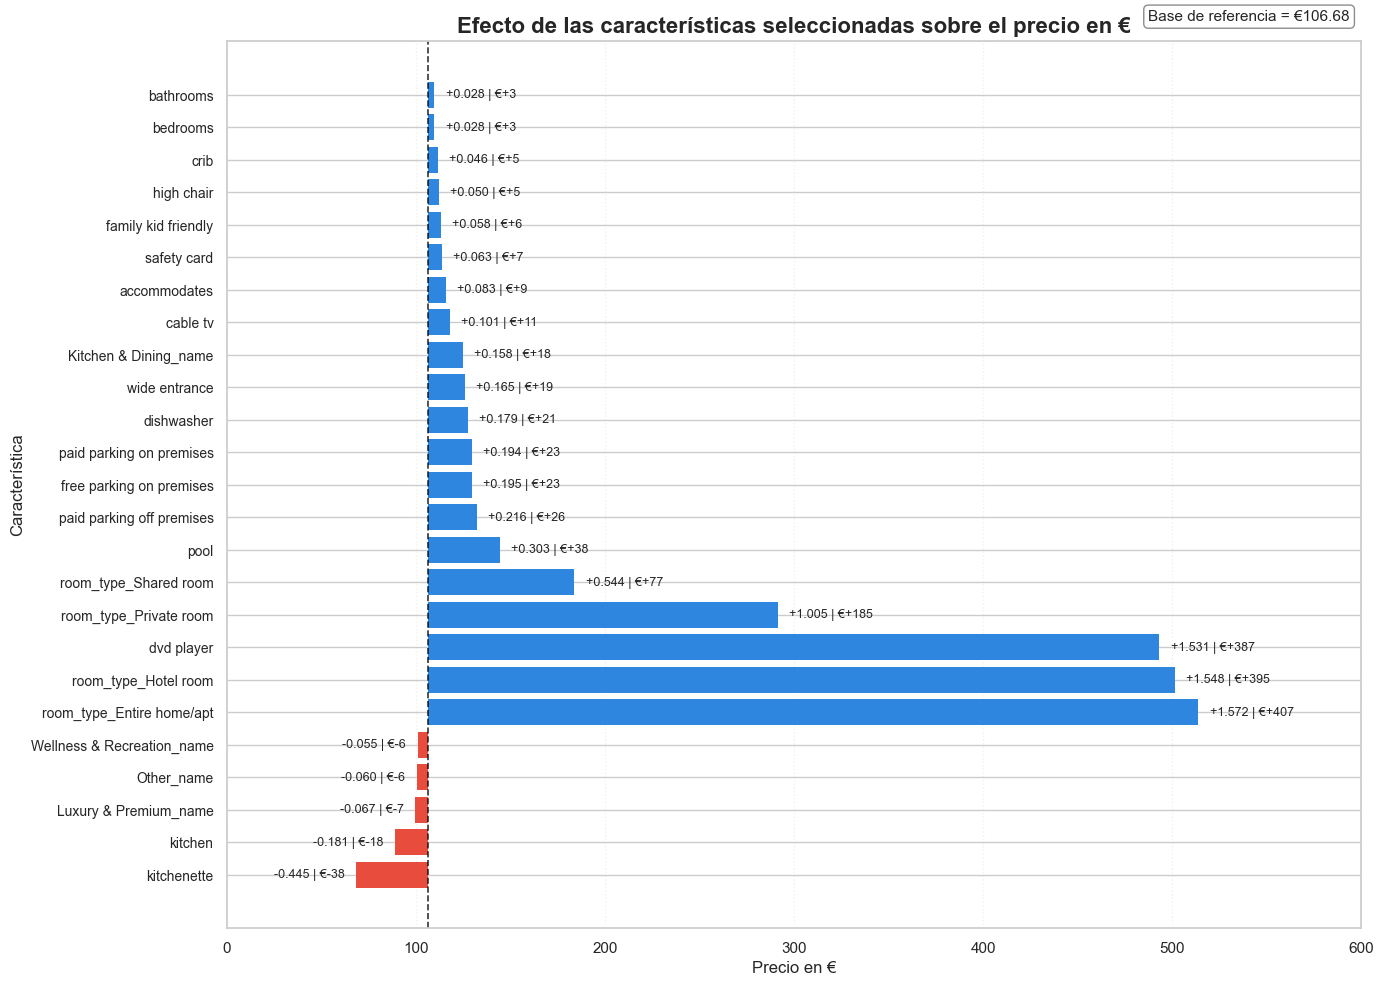

In [208]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------
# Input data
# -------------------------------------------------
data = [
    ("accommodates", 0.0830),
    ("bathrooms", 0.0283),
    ("bedrooms", 0.0283),
    ("cable tv", 0.1005),
    ("crib", 0.0459),
    ("dishwasher", 0.1792),
    ("dvd player", 1.5312),
    ("family kid friendly", 0.0581),
    ("free parking on premises", 0.1953),
    ("high chair", 0.0500),
    ("kitchen", -0.1814),
    ("kitchenette", -0.4454),
    ("paid parking off premises", 0.2163),
    ("paid parking on premises", 0.1940),
    ("pool", 0.3031),
    ("safety card", 0.0629),
    ("wide entrance", 0.1646),
    ("Kitchen & Dining_name", 0.1584),
    ("Luxury & Premium_name", -0.0672),
    ("Other_name", -0.0605),
    ("Wellness & Recreation_name", -0.0554),
    ("room_type_Entire home/apt", 1.5723),
    ("room_type_Hotel room", 1.5478),
    ("room_type_Private room", 1.0052),
    ("room_type_Shared room", 0.5445),
]

intercept = 4.6698

# -------------------------------------------------
# Data prep
# -------------------------------------------------
features_df = pd.DataFrame(data, columns=["feature", "coef"])

# Baseline price in euro from intercept
baseline_eur = np.exp(intercept)

# Euro effect of each feature relative to baseline
# Interpretation: price change in € when feature is present
features_df["euro_delta"] = baseline_eur * (np.exp(features_df["coef"]) - 1)

features_df["effect"] = np.where(features_df["euro_delta"] >= 0, "positive", "negative")
features_df["abs_euro_delta"] = features_df["euro_delta"].abs()

# Order by signed euro effect, positives first, negatives after
df_pos = features_df[features_df["euro_delta"] >= 0].sort_values("euro_delta", ascending=True)
df_neg = features_df[features_df["euro_delta"] < 0].sort_values("euro_delta", ascending=False)
plot_df = pd.concat([df_pos, df_neg], ignore_index=True)

# X positions centered on intercept in euro
plot_df["x_left"] = np.where(
    plot_df["euro_delta"] >= 0,
    baseline_eur,
    baseline_eur + plot_df["euro_delta"]
)
plot_df["bar_width"] = plot_df["euro_delta"].abs()

# Labels
plot_df["label"] = plot_df.apply(
    lambda r: f'{r["coef"]:+.3f} | €{r["euro_delta"]:+.0f}',
    axis=1
)

# Colors
colors = plot_df["euro_delta"].apply(lambda x: "#2E86DE" if x >= 0 else "#E74C3C")

# -------------------------------------------------
# Plot
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 10))

y = np.arange(len(plot_df))

ax.barh(
    y,
    plot_df["bar_width"],
    left=plot_df["x_left"],
    color=colors,
    edgecolor="none"
)

# Reference line at intercept in euro, not at zero
ax.axvline(baseline_eur, color="black", linewidth=1.2, linestyle="--", alpha=0.8)

# Y labels
ax.set_yticks(y)
ax.set_yticklabels(plot_df["feature"], fontsize=10)

# Value labels
for i, row in plot_df.iterrows():
    x_end = row["x_left"] + row["bar_width"] if row["euro_delta"] >= 0 else row["x_left"]
    if row["euro_delta"] >= 0:
        ax.text(x_end + 6, i, row["label"], va="center", ha="left", fontsize=9)
    else:
        ax.text(x_end - 6, i, row["label"], va="center", ha="right", fontsize=9)

# Title and axes
ax.set_title(
    "Efecto de las características seleccionadas sobre el precio en €",
    fontsize=16,
    weight="bold"
)
ax.set_xlabel("Precio en €")
ax.set_ylabel("Característica")

# X axis fixed range
ax.set_xlim(0, 600)

# Intercept annotation
ax.text(
    0.99, 1.02,
    f"Base de referencia = €{baseline_eur:.2f}",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.9)
)

# Style
ax.invert_yaxis()
ax.grid(axis="x", linestyle=":", alpha=0.3)

plt.tight_layout()
plt.show()

In [45]:
alojamentos_profile_df["room_type"].value_counts()

room_type
Entire home/apt    5453
Private room       2138
Hotel room           53
Shared room          49
Name: count, dtype: int64

#### **BARCELONA**

##### **Analysis Barcelona ~ General**

In [202]:
outdir = Path("output_BCN_general")
outdir.mkdir(exist_ok=True)

In [209]:
log("Starting data preparation")

price_orig = "price"
target = "price_log2"
id_cols = ["apartment_id", "host_id", "insert_date"]
location = ["city", "neighbourhood_district", "neighbourhood_name"]
df_model = df[df["city"] == 'barcelona'].copy()

X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
y = df_model[target].astype(float)

list_cols = [c for c in X.columns if X[c].apply(lambda v: isinstance(v, list)).any()]
if list_cols:
    log(f"Dropping list-valued columns: {list_cols}")
    X = X.drop(columns=list_cols)

num_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

X[num_cols] = X[num_cols].apply(lambda s: s.astype(float) if s.dtype == "bool" else s)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")
log(f"Numeric cols: {len(num_cols)}, Categorical cols: {len(cat_cols)}")

[16:01:50] Starting data preparation
[16:01:51] Dropping list-valued columns: ['Accessibility_name', 'Business & Work_name', 'Digital/Tech_name', 'Entertainment & Media_name', 'Family & Pets_name', 'In-Room Essentials & Comfort_name', 'Kitchen & Dining_name', 'Laundry & Housekeeping_name', 'Luxury & Premium_name', 'Other_name', 'Outdoor & Views_name', 'Parking & Transport_name', 'Safety & Security_name', 'Service & Operations_name', 'Wellness & Recreation_name']
[16:01:52] Train rows: 1799, Test rows: 450
[16:01:52] Numeric cols: 235, Categorical cols: 1


In [210]:
log("Building preprocessors")

preprocess_rf = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

preprocess_enet = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

log("Preprocessors ready")

[16:02:03] Building preprocessors
[16:02:03] Preprocessors ready


In [211]:
log("Fitting Random Forest")

rf = Pipeline(steps=[
    ("preprocess", preprocess_rf),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        max_depth=12,
        min_samples_leaf=5,
        max_features="sqrt"
    ))
])

t0 = time.time()
rf.fit(X_train, y_train)
log(f"Random Forest fit completed in {time.time() - t0:.1f}s")

rf_pred = rf.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
log(f"RF test RMSE={rf_rmse:.4f}, R2={rf_r2:.4f}")

[16:02:15] Fitting Random Forest
[16:02:16] Random Forest fit completed in 0.7s
[16:02:16] RF test RMSE=0.7228, R2=0.5389


In [212]:
log("Computing permutation importance")

X_test_trans = rf.named_steps["preprocess"].transform(X_test)
feature_names = rf.named_steps["preprocess"].get_feature_names_out()

t0 = time.time()
perm = permutation_importance(
    rf.named_steps["model"],
    X_test_trans,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)
log(f"Permutation importance completed in {time.time() - t0:.1f}s")

rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

rf_importance.to_csv(outdir / "rf_permutation_importance.csv", index=False)
log("Saved RF importance to output/rf_permutation_importance.csv")

display(rf_importance.head(20))

[16:02:24] Computing permutation importance
[16:03:57] Permutation importance completed in 93.1s
[16:03:57] Saved RF importance to output/rf_permutation_importance.csv


,feature,importance_mean,importance_std
235,room_type_Entire home/apt,0.090055,0.011596
0,accommodates,0.056334,0.005744
237,room_type_Private room,0.055647,0.006364
3,beds,0.023773,0.005952
7,air conditioning,0.015794,0.004494
78,family kid friendly,0.008366,0.003078
224,Family & Pets_counts,0.006888,0.003052
2,bedrooms,0.006196,0.000941
201,tv,0.005054,0.002300
1,bathrooms,0.004148,0.001684


In [213]:
log("Fitting Elastic Net")

enet_pipe = Pipeline(steps=[
    ("preprocess", preprocess_enet),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9],
        alphas=np.logspace(-4, 1, 30),
        cv=5,
        random_state=42,
        max_iter=10000
    ))
])

t0 = time.time()
enet_pipe.fit(X_train, y_train)
log(f"Elastic Net fit completed in {time.time() - t0:.1f}s")

enet = enet_pipe.named_steps["model"]
enet_pred = enet_pipe.predict(X_test)
enet_rmse = np.sqrt(mean_squared_error(y_test, enet_pred))

enet_r2 = r2_score(y_test, enet_pred)

enet_features = enet_pipe.named_steps["preprocess"].get_feature_names_out()
enet_coefs = pd.DataFrame({
    "feature": enet_features,
    "coef": enet.coef_
})
enet_coefs["abs_coef"] = enet_coefs["coef"].abs()
enet_selected = enet_coefs[enet_coefs["coef"] != 0].sort_values("abs_coef", ascending=False)

enet_coefs.to_csv(outdir / "elastic_net_coefficients.csv", index=False)
log("Saved Elastic Net coefficients to output/elastic_net_coefficients.csv")

log(f"Elastic Net chosen alpha={enet.alpha_:.6f}, l1_ratio={enet.l1_ratio_}")
log(f"EN test RMSE={enet_rmse:.4f}, R2={enet_r2:.4f}")

display(enet_selected.head(30))

[16:04:55] Fitting Elastic Net
[16:05:07] Elastic Net fit completed in 11.6s
[16:05:07] Saved Elastic Net coefficients to output/elastic_net_coefficients.csv
[16:05:07] Elastic Net chosen alpha=0.017433, l1_ratio=0.9
[16:05:07] EN test RMSE=0.7472, R2=0.5072


,feature,coef,abs_coef
235,room_type_Entire home/apt,0.607026,0.607026
0,accommodates,0.357560,0.357560
7,air conditioning,0.105120,0.105120
58,dishwasher,0.063300,0.063300
201,tv,0.056433,0.056433
171,shampoo,0.053315,0.053315
191,stove,-0.040184,0.040184
60,doorman,0.039277,0.039277
78,family kid friendly,0.039175,0.039175
181,smoke alarm,0.034649,0.034649


In [214]:
log("Preparing VIF check")

top_rf = rf_importance["feature"].head(25).tolist()
top_en = enet_selected["feature"].head(25).tolist()

candidate_features = list(dict.fromkeys(top_rf + top_en))
log(f"Initial candidate features from RF + EN: {len(candidate_features)}")

base_cols = []
for f in candidate_features:
    base = f.split("_")[0] if "_" in f else f
    if base in X_train.columns:
        base_cols.append(base)

base_cols = list(dict.fromkeys(base_cols))
log(f"Base columns kept for VIF: {base_cols}")

X_vif = X_train[base_cols].copy()
X_vif = pd.get_dummies(X_vif, drop_first=True)

for c in X_vif.columns:
    if X_vif[c].dtype == "bool":
        X_vif[c] = X_vif[c].astype(int)

X_vif = X_vif.fillna(X_vif.median(numeric_only=True))

log(f"VIF matrix shape: {X_vif.shape}")

vif_data = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

vif_data.to_csv(outdir / "vif_results.csv", index=False)
log("Saved VIF results to output/vif_results.csv")

display(vif_data.head(30))

[16:05:10] Preparing VIF check
[16:05:10] Initial candidate features from RF + EN: 41
[16:05:10] Base columns kept for VIF: ['accommodates', 'beds', 'air conditioning', 'family kid friendly', 'bedrooms', 'tv', 'bathrooms', 'crib', 'high chair', '24-hour check-in', 'long term stays allowed', 'hot water', 'cable tv', 'iron', 'extra pillows and blankets', 'hangers', 'elevator', 'heating', 'dishwasher', 'shampoo', 'stove', 'doorman', 'smoke alarm', 'host greets you', 'indoor fireplace', 'hair dryer', 'baking sheet', 'kitchenette', 'free parking on street', 'coffee maker', 'safety card', 'suitable for events', 'kitchen']
[16:05:10] VIF matrix shape: (1799, 33)
[16:05:11] Saved VIF results to output/vif_results.csv


,feature,VIF
4,bedrooms,inf
6,bathrooms,inf
0,accommodates,17.206142
1,beds,11.800279
32,kitchen,6.750202
25,hair dryer,5.718819
15,hangers,5.692055
13,iron,5.417865
17,heating,5.005550
5,tv,4.794684


In [215]:
log("Fitting Gamma GLM with log link")

glm_X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
glm_list_cols = [c for c in glm_X.columns if glm_X[c].apply(lambda v: isinstance(v, list)).any()]
if glm_list_cols:
    log(f"Dropping list-valued columns from GLM: {glm_list_cols}")
    glm_X = glm_X.drop(columns=glm_list_cols)

glm_num_cols = glm_X.select_dtypes(include=["number", "bool"]).columns.tolist()
glm_cat_cols = glm_X.select_dtypes(include=["object", "category"]).columns.tolist()

glm_preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), glm_num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), glm_cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

t0 = time.time()
X_glm = glm_preprocess.fit_transform(glm_X)
log(f"GLM preprocessing completed in {time.time() - t0:.1f}s")

glm_feature_names = glm_preprocess.get_feature_names_out()
X_glm_df = pd.DataFrame(X_glm, columns=glm_feature_names, index=df_model.index)
X_glm_df = sm.add_constant(X_glm_df, has_constant="add")

y_glm = df_model[target].astype(float)

t0 = time.time()
gamma_model = sm.GLM(
    y_glm,
    X_glm_df,
    family=sm.families.Gamma(link=sm.families.links.log())
).fit()
log(f"Gamma GLM fit completed in {time.time() - t0:.1f}s")

with open(outdir / "gamma_glm_summary.txt", "w", encoding="utf-8") as f:
    f.write(gamma_model.summary().as_text())

log("Saved Gamma GLM summary to output/gamma_glm_summary.txt")
print(gamma_model.summary())

[16:05:16] Fitting Gamma GLM with log link
[16:05:16] Dropping list-valued columns from GLM: ['Accessibility_name', 'Business & Work_name', 'Digital/Tech_name', 'Entertainment & Media_name', 'Family & Pets_name', 'In-Room Essentials & Comfort_name', 'Kitchen & Dining_name', 'Laundry & Housekeeping_name', 'Luxury & Premium_name', 'Other_name', 'Outdoor & Views_name', 'Parking & Transport_name', 'Safety & Security_name', 'Service & Operations_name', 'Wellness & Recreation_name']
[16:05:16] GLM preprocessing completed in 0.1s
[16:05:25] Gamma GLM fit completed in 9.1s
[16:05:26] Saved Gamma GLM summary to output/gamma_glm_summary.txt
                 Generalized Linear Model Regression Results                  
Dep. Variable:             price_log2   No. Observations:                 2249
Model:                            GLM   Df Residuals:                     2081
Model Family:                   Gamma   Df Model:                          167
Link Function:                    log   Scale

In [216]:
log("Fitting OLS on log(price)")

if "price" in df_model.columns:
    y_lin = np.log(df_model["price"].astype(float))
    X_lin = X_glm_df.copy()

    t0 = time.time()
    lin_model = sm.OLS(y_lin, X_lin).fit()
    log(f"OLS fit completed in {time.time() - t0:.1f}s")

    with open(outdir / "ols_logprice_summary.txt", "w", encoding="utf-8") as f:
        f.write(lin_model.summary().as_text())

    log("Saved OLS summary to output/ols_logprice_summary.txt")
    print(lin_model.summary())
else:
    lin_model = None
    log("No raw price column found; skipping OLS on log(price)")

[16:05:29] Fitting OLS on log(price)
[16:05:29] OLS fit completed in 0.3s
[16:05:30] Saved OLS summary to output/ols_logprice_summary.txt
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.602
Model:                            OLS   Adj. R-squared:                  0.570
Method:                 Least Squares   F-statistic:                     18.85
Date:                Sun, 07 Jun 2026   Prob (F-statistic):          1.39e-308
Time:                        16:05:30   Log-Likelihood:                -1485.2
No. Observations:                2249   AIC:                             3306.
Df Residuals:                    2081   BIC:                             4267.
Df Model:                         167                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t   

In [217]:
log("Building comparison table")

results = pd.DataFrame([
    {"model": "Random Forest", "rmse": rf_rmse, "r2": rf_r2},
    {"model": "Elastic Net", "rmse": enet_rmse, "r2": enet_r2},
])

if lin_model is not None:
    results = pd.concat([
        results,
        pd.DataFrame([{
            "model": "OLS log(price)",
            "rmse": np.nan,
            "r2": lin_model.rsquared
        }])
    ], ignore_index=True)

results.to_csv(outdir / "model_comparison.csv", index=False)
log("Saved comparison table to output/model_comparison.csv")
display(results)

[16:05:34] Building comparison table
[16:05:34] Saved comparison table to output/model_comparison.csv


,model,rmse,r2
0,Random Forest,0.722803,0.538882
1,Elastic Net,0.747206,0.507220
2,OLS log(price),NaN,0.602057


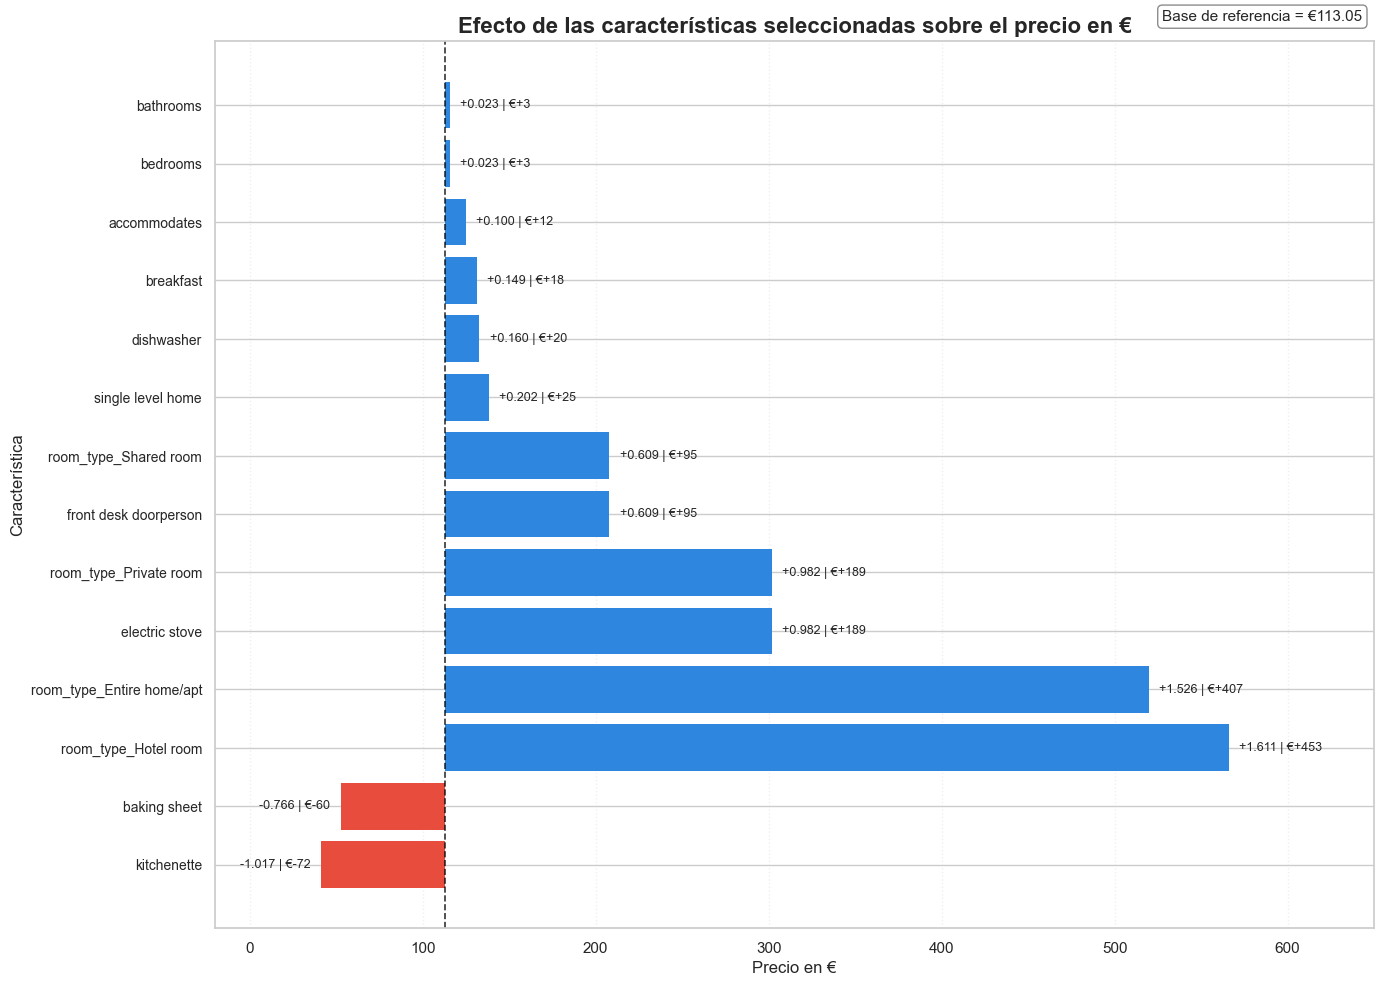

In [219]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------
# Input data
# -------------------------------------------------
data = [
    ("accommodates", 0.0996),
    ("bathrooms", 0.0229),
    ("bedrooms", 0.0229),
    ("baking sheet", -0.7656),
    ("breakfast", 0.1492),
    ("dishwasher", 0.1601),
    ("electric stove", 0.9820),
    ("front desk doorperson", 0.6094),
    ("kitchenette", -1.0168),
    ("single level home", 0.2016),
    ("room_type_Entire home/apt", 1.5259),
    ("room_type_Hotel room", 1.6111),
    ("room_type_Private room", 0.9817),
    ("room_type_Shared room", 0.6091),
]

intercept = 4.7278                  

# -------------------------------------------------
# Data prep
# -------------------------------------------------
features_df = pd.DataFrame(data, columns=["feature", "coef"])

# Baseline price in euro from intercept
baseline_eur = np.exp(intercept)

# Euro effect of each feature relative to baseline
# Interpretation: price change in € when feature is present
features_df["euro_delta"] = baseline_eur * (np.exp(features_df["coef"]) - 1)

features_df["effect"] = np.where(features_df["euro_delta"] >= 0, "positive", "negative")
features_df["abs_euro_delta"] = features_df["euro_delta"].abs()

# Order by signed euro effect, positives first, negatives after
df_pos = features_df[features_df["euro_delta"] >= 0].sort_values("euro_delta", ascending=True)
df_neg = features_df[features_df["euro_delta"] < 0].sort_values("euro_delta", ascending=False)
plot_df = pd.concat([df_pos, df_neg], ignore_index=True)

# X positions centered on intercept in euro
plot_df["x_left"] = np.where(
    plot_df["euro_delta"] >= 0,
    baseline_eur,
    baseline_eur + plot_df["euro_delta"]
)
plot_df["bar_width"] = plot_df["euro_delta"].abs()

# Labels
plot_df["label"] = plot_df.apply(
    lambda r: f'{r["coef"]:+.3f} | €{r["euro_delta"]:+.0f}',
    axis=1
)

# Colors
colors = plot_df["euro_delta"].apply(lambda x: "#2E86DE" if x >= 0 else "#E74C3C")

# -------------------------------------------------
# Plot
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 10))

y = np.arange(len(plot_df))

ax.barh(
    y,
    plot_df["bar_width"],
    left=plot_df["x_left"],
    color=colors,
    edgecolor="none"
)

# Reference line at intercept in euro, not at zero
ax.axvline(baseline_eur, color="black", linewidth=1.2, linestyle="--", alpha=0.8)

# Y labels
ax.set_yticks(y)
ax.set_yticklabels(plot_df["feature"], fontsize=10)

# Value labels
for i, row in plot_df.iterrows():
    x_end = row["x_left"] + row["bar_width"] if row["euro_delta"] >= 0 else row["x_left"]
    if row["euro_delta"] >= 0:
        ax.text(x_end + 6, i, row["label"], va="center", ha="left", fontsize=9)
    else:
        ax.text(x_end - 6, i, row["label"], va="center", ha="right", fontsize=9)

# Title and axes
ax.set_title(
    "Efecto de las características seleccionadas sobre el precio en €",
    fontsize=16,
    weight="bold"
)
ax.set_xlabel("Precio en €")
ax.set_ylabel("Característica")

# X axis fixed range
ax.set_xlim(-20, 650)

# Intercept annotation
ax.text(
    0.99, 1.02,
    f"Base de referencia = €{baseline_eur:.2f}",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.9)
)

# Style
ax.invert_yaxis()
ax.grid(axis="x", linestyle=":", alpha=0.3)

plt.tight_layout()
plt.show()

##### **Results Barcelona ~ General**

From three modelling approaches, Ordinary Least Squares (OLS) regression demonstrated the highest r2 = 0.602057.
Based on VIF estimation, the following features had highest collinearity:
    feature	VIF
4	bedrooms	inf
6	bathrooms	inf
0	accommodates	17.206142
1	beds	11.800279
32	kitchen	6.750202
25	hair dryer	5.718819
15	hangers	5.692055
13	iron	5.417865
17	heating	5.005550

"accommodates", "bedrooms", "bathrooms" and "beds" represent Capacity characteristics of the accommodation, being highly colinear. It is proposed to use for further estimations **"accommodates"** only.
"kitchen", "hair dryer", "hangers", "iron", "heating" may be omitted from modelling, as being colinear with another features, and estimated with p>0.05 in OLS model.

Features with accepted VIF and p<0.05 were:
#--------------------------------------------------------------------------------------------------------
                                           coef    std err          t      P>|t|      [0.025      0.975]
#--------------------------------------------------------------------------------------------------------
const                                    4.7278      0.075     63.034      0.000       4.581       4.875
accommodates                             0.0996      0.012      8.581      0.000       0.077       0.122
bathrooms                                0.0229      0.010      2.262      0.024       0.003       0.043
bedrooms                                 0.0229      0.010      2.262      0.024       0.003       0.043
baking sheet                            -0.7656      0.313     -2.450      0.014      -1.379      -0.153
breakfast                                0.1492      0.073      2.034      0.042       0.005       0.293
dishwasher                               0.1601      0.075      2.132      0.033       0.013       0.307
electric stove                           0.9820      0.467      2.104      0.035       0.067       1.897
front desk doorperson                    0.6094      0.305      1.999      0.046       0.011       1.207
kitchenette                             -1.0168      0.486     -2.092      0.037      -1.970      -0.063
single level home                        0.2016      0.089      2.258      0.024       0.027       0.377
room_type_Entire home/apt                1.5259      0.049     30.977      0.000       1.429       1.622
room_type_Hotel room                     1.6111      0.126     12.744      0.000       1.363       1.859
room_type_Private room                   0.9817      0.045     21.925      0.000       0.894       1.069
room_type_Shared room                    0.6091      0.099      6.160      0.000       0.415       0.803

##### **Analysis Barcelona ~ Entire home/apt**

In [46]:
outdir = Path("output_BCN_Entire")
outdir.mkdir(exist_ok=True)

In [47]:
log("Starting data preparation")

price_orig = "price"
target = "price_log2"
id_cols = ["apartment_id", "host_id", "insert_date"]
location = ["city", "neighbourhood_district", "neighbourhood_name"]
df_model = df[(df["city"] == 'barcelona') & (df["room_type"] == "Entire home/apt")].copy()

X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
y = df_model[target].astype(float)

list_cols = [c for c in X.columns if X[c].apply(lambda v: isinstance(v, list)).any()]
if list_cols:
    log(f"Dropping list-valued columns: {list_cols}")
    X = X.drop(columns=list_cols)

num_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

X[num_cols] = X[num_cols].apply(lambda s: s.astype(float) if s.dtype == "bool" else s)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")
log(f"Numeric cols: {len(num_cols)}, Categorical cols: {len(cat_cols)}")

[13:01:27] Starting data preparation
[13:01:27] Train rows: 846, Test rows: 212
[13:01:27] Numeric cols: 250, Categorical cols: 1


In [48]:
log("Building preprocessors")

preprocess_rf = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

preprocess_enet = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

log("Preprocessors ready")

[13:01:27] Building preprocessors
[13:01:27] Preprocessors ready


In [49]:
log("Fitting Random Forest")

rf = Pipeline(steps=[
    ("preprocess", preprocess_rf),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        max_depth=12,
        min_samples_leaf=5,
        max_features="sqrt"
    ))
])

t0 = time.time()
rf.fit(X_train, y_train)
log(f"Random Forest fit completed in {time.time() - t0:.1f}s")

rf_pred = rf.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
log(f"RF test RMSE={rf_rmse:.4f}, R2={rf_r2:.4f}")

[13:01:27] Fitting Random Forest
[13:01:28] Random Forest fit completed in 0.7s
[13:01:28] RF test RMSE=0.6613, R2=0.3000


In [50]:
log("Computing permutation importance")

X_test_trans = rf.named_steps["preprocess"].transform(X_test)
feature_names = rf.named_steps["preprocess"].get_feature_names_out()

t0 = time.time()
perm = permutation_importance(
    rf.named_steps["model"],
    X_test_trans,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)
log(f"Permutation importance completed in {time.time() - t0:.1f}s")

rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

rf_importance.to_csv(outdir / "rf_permutation_importance.csv", index=False)
log("Saved RF importance to output/rf_permutation_importance.csv")

display(rf_importance.head(20))

[13:01:28] Computing permutation importance
[13:02:11] Permutation importance completed in 43.0s
[13:02:12] Saved RF importance to output/rf_permutation_importance.csv


,feature,importance_mean,importance_std
2,bedrooms,0.044290,0.014164
3,beds,0.029014,0.011892
1,bathrooms,0.026966,0.011150
0,accommodates,0.026155,0.009668
78,family kid friendly,0.011038,0.004926
239,Family & Pets_counts,0.009062,0.002511
224,Family & Pets_name,0.007554,0.002203
238,Entertainment & Media_counts,0.007359,0.005215
219,total_number_units,0.007356,0.001508
171,shampoo,0.005257,0.003328


In [51]:
log("Fitting Elastic Net")

enet_pipe = Pipeline(steps=[
    ("preprocess", preprocess_enet),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9],
        alphas=np.logspace(-4, 1, 30),
        cv=5,
        random_state=42,
        max_iter=10000
    ))
])

t0 = time.time()
enet_pipe.fit(X_train, y_train)
log(f"Elastic Net fit completed in {time.time() - t0:.1f}s")

enet = enet_pipe.named_steps["model"]
enet_pred = enet_pipe.predict(X_test)
enet_rmse = np.sqrt(mean_squared_error(y_test, enet_pred))

enet_r2 = r2_score(y_test, enet_pred)

enet_features = enet_pipe.named_steps["preprocess"].get_feature_names_out()
enet_coefs = pd.DataFrame({
    "feature": enet_features,
    "coef": enet.coef_
})
enet_coefs["abs_coef"] = enet_coefs["coef"].abs()
enet_selected = enet_coefs[enet_coefs["coef"] != 0].sort_values("abs_coef", ascending=False)

enet_coefs.to_csv(outdir / "elastic_net_coefficients.csv", index=False)
log("Saved Elastic Net coefficients to output/elastic_net_coefficients.csv")

log(f"Elastic Net chosen alpha={enet.alpha_:.6f}, l1_ratio={enet.l1_ratio_}")
log(f"EN test RMSE={enet_rmse:.4f}, R2={enet_r2:.4f}")

display(enet_selected.head(30))

[13:02:12] Fitting Elastic Net
[13:02:24] Elastic Net fit completed in 12.8s
[13:02:24] Saved Elastic Net coefficients to output/elastic_net_coefficients.csv
[13:02:24] Elastic Net chosen alpha=0.188739, l1_ratio=0.1
[13:02:24] EN test RMSE=0.6566, R2=0.3101


,feature,coef,abs_coef
0,accommodates,0.136802,0.136802
3,beds,0.094384,0.094384
1,bathrooms,0.074187,0.074187
2,bedrooms,0.074173,0.074173
75,extra pillows and blankets,-0.064043,0.064043
124,long term stays allowed,-0.062570,0.062570
58,dishwasher,0.047898,0.047898
63,dryer,0.044351,0.044351
68,elevator,0.041208,0.041208
168,safety card,0.038451,0.038451


In [52]:
log("Preparing VIF check")

top_rf = rf_importance["feature"].head(25).tolist()
top_en = enet_selected["feature"].head(25).tolist()

candidate_features = list(dict.fromkeys(top_rf + top_en))
log(f"Initial candidate features from RF + EN: {len(candidate_features)}")

base_cols = []
for f in candidate_features:
    base = f.split("_")[0] if "_" in f else f
    if base in X_train.columns:
        base_cols.append(base)

base_cols = list(dict.fromkeys(base_cols))
log(f"Base columns kept for VIF: {base_cols}")

X_vif = X_train[base_cols].copy()
X_vif = pd.get_dummies(X_vif, drop_first=True)

for c in X_vif.columns:
    if X_vif[c].dtype == "bool":
        X_vif[c] = X_vif[c].astype(int)

X_vif = X_vif.fillna(X_vif.median(numeric_only=True))

log(f"VIF matrix shape: {X_vif.shape}")

vif_data = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

vif_data.to_csv(outdir / "vif_results.csv", index=False)
log("Saved VIF results to output/vif_results.csv")

display(vif_data.head(30))

[13:02:24] Preparing VIF check
[13:02:24] Initial candidate features from RF + EN: 40
[13:02:24] Base columns kept for VIF: ['bedrooms', 'beds', 'bathrooms', 'accommodates', 'family kid friendly', 'shampoo', 'long term stays allowed', 'air conditioning', 'extra pillows and blankets', 'cable tv', 'buzzer wireless intercom', 'internet', 'high chair', 'crib', 'stove', 'pets allowed', 'dishwasher', 'dryer', 'elevator', 'safety card', 'suitable for events', '24-hour check-in', 'hair dryer', 'pack �n play travel crib', 'baking sheet', 'host greets you', 'body soap', 'wheelchair accessible', 'self check in', 'stair gates', 'private entrance']
[13:02:25] VIF matrix shape: (846, 31)
[13:02:25] Saved VIF results to output/vif_results.csv


,feature,VIF
0,bedrooms,inf
2,bathrooms,inf
3,accommodates,23.288268
1,beds,14.413239
22,hair dryer,6.473244
7,air conditioning,6.299624
4,family kid friendly,3.371546
18,elevator,3.296893
5,shampoo,2.864408
14,stove,2.847054


In [53]:
log("Fitting Gamma GLM with log link")

glm_X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
glm_list_cols = [c for c in glm_X.columns if glm_X[c].apply(lambda v: isinstance(v, list)).any()]
if glm_list_cols:
    log(f"Dropping list-valued columns from GLM: {glm_list_cols}")
    glm_X = glm_X.drop(columns=glm_list_cols)

glm_num_cols = glm_X.select_dtypes(include=["number", "bool"]).columns.tolist()
glm_cat_cols = glm_X.select_dtypes(include=["object", "category"]).columns.tolist()

glm_preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), glm_num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), glm_cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

t0 = time.time()
X_glm = glm_preprocess.fit_transform(glm_X)
log(f"GLM preprocessing completed in {time.time() - t0:.1f}s")

glm_feature_names = glm_preprocess.get_feature_names_out()
X_glm_df = pd.DataFrame(X_glm, columns=glm_feature_names, index=df_model.index)
X_glm_df = sm.add_constant(X_glm_df, has_constant="add")

y_glm = df_model[target].astype(float)

t0 = time.time()
gamma_model = sm.GLM(
    y_glm,
    X_glm_df,
    family=sm.families.Gamma(link=sm.families.links.log())
).fit()
log(f"Gamma GLM fit completed in {time.time() - t0:.1f}s")

with open(outdir / "gamma_glm_summary.txt", "w", encoding="utf-8") as f:
    f.write(gamma_model.summary().as_text())

log("Saved Gamma GLM summary to output/gamma_glm_summary.txt")
print(gamma_model.summary())

[13:02:25] Fitting Gamma GLM with log link
[13:02:25] GLM preprocessing completed in 0.1s
[13:02:32] Gamma GLM fit completed in 6.3s
[13:02:32] Saved Gamma GLM summary to output/gamma_glm_summary.txt
                 Generalized Linear Model Regression Results                  
Dep. Variable:             price_log2   No. Observations:                 1058
Model:                            GLM   Df Residuals:                      891
Model Family:                   Gamma   Df Model:                          166
Link Function:                    log   Scale:                       0.0044621
Method:                          IRLS   Log-Likelihood:                -995.58
Date:                Sun, 07 Jun 2026   Deviance:                       3.9924
Time:                        13:02:32   Pearson chi2:                     3.98
No. Iterations:                   100   Pseudo R-squ. (CS):             0.5022
Covariance Type:            nonrobust                                         
          

In [54]:
log("Fitting OLS on log(price)")

if "price" in df_model.columns:
    y_lin = np.log(df_model["price"].astype(float))
    X_lin = X_glm_df.copy()

    t0 = time.time()
    lin_model = sm.OLS(y_lin, X_lin).fit()
    log(f"OLS fit completed in {time.time() - t0:.1f}s")

    with open(outdir / "ols_logprice_summary.txt", "w", encoding="utf-8") as f:
        f.write(lin_model.summary().as_text())

    log("Saved OLS summary to output/ols_logprice_summary.txt")
    print(lin_model.summary())
else:
    lin_model = None
    log("No raw price column found; skipping OLS on log(price)")

[13:02:32] Fitting OLS on log(price)
[13:02:32] OLS fit completed in 0.1s
[13:02:32] Saved OLS summary to output/ols_logprice_summary.txt
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.456
Model:                            OLS   Adj. R-squared:                  0.355
Method:                 Least Squares   F-statistic:                     4.501
Date:                Sun, 07 Jun 2026   Prob (F-statistic):           9.47e-49
Time:                        13:02:32   Log-Likelihood:                -603.43
No. Observations:                1058   AIC:                             1541.
Df Residuals:                     891   BIC:                             2370.
Df Model:                         166                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t   

In [55]:
log("Building comparison table")

results = pd.DataFrame([
    {"model": "Random Forest", "rmse": rf_rmse, "r2": rf_r2},
    {"model": "Elastic Net", "rmse": enet_rmse, "r2": enet_r2},
])

if lin_model is not None:
    results = pd.concat([
        results,
        pd.DataFrame([{
            "model": "OLS log(price)",
            "rmse": np.nan,
            "r2": lin_model.rsquared
        }])
    ], ignore_index=True)

results.to_csv(outdir / "model_comparison.csv", index=False)
log("Saved comparison table to output/model_comparison.csv")
display(results)

[13:02:33] Building comparison table
[13:02:33] Saved comparison table to output/model_comparison.csv


,model,rmse,r2
0,Random Forest,0.661327,0.300027
1,Elastic Net,0.656563,0.310076
2,OLS log(price),NaN,0.456119


##### **Results Barcelona ~ Entire home/apt**

##### **Analysis Barcelona ~ Private room**

In [56]:
outdir = Path("output_BCN_Private")
outdir.mkdir(exist_ok=True)

In [57]:
log("Starting data preparation")

price_orig = "price"
target = "price_log2"
id_cols = ["apartment_id", "host_id", "insert_date"]
location = ["city", "neighbourhood_district", "neighbourhood_name"]
df_model = df[(df["city"] == 'barcelona') & (df["room_type"] == "Private room")].copy()

X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
y = df_model[target].astype(float)

list_cols = [c for c in X.columns if X[c].apply(lambda v: isinstance(v, list)).any()]
if list_cols:
    log(f"Dropping list-valued columns: {list_cols}")
    X = X.drop(columns=list_cols)

num_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

X[num_cols] = X[num_cols].apply(lambda s: s.astype(float) if s.dtype == "bool" else s)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")
log(f"Numeric cols: {len(num_cols)}, Categorical cols: {len(cat_cols)}")

[13:02:33] Starting data preparation
[13:02:33] Train rows: 927, Test rows: 232
[13:02:33] Numeric cols: 250, Categorical cols: 1


In [58]:
log("Building preprocessors")

preprocess_rf = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

preprocess_enet = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

log("Preprocessors ready")

[13:02:33] Building preprocessors
[13:02:33] Preprocessors ready


In [59]:
log("Fitting Random Forest")

rf = Pipeline(steps=[
    ("preprocess", preprocess_rf),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        max_depth=12,
        min_samples_leaf=5,
        max_features="sqrt"
    ))
])

t0 = time.time()
rf.fit(X_train, y_train)
log(f"Random Forest fit completed in {time.time() - t0:.1f}s")

rf_pred = rf.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
log(f"RF test RMSE={rf_rmse:.4f}, R2={rf_r2:.4f}")

[13:02:33] Fitting Random Forest
[13:02:34] Random Forest fit completed in 0.7s
[13:02:34] RF test RMSE=0.6815, R2=0.0962


In [60]:
log("Computing permutation importance")

X_test_trans = rf.named_steps["preprocess"].transform(X_test)
feature_names = rf.named_steps["preprocess"].get_feature_names_out()

t0 = time.time()
perm = permutation_importance(
    rf.named_steps["model"],
    X_test_trans,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)
log(f"Permutation importance completed in {time.time() - t0:.1f}s")

rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

rf_importance.to_csv(outdir / "rf_permutation_importance.csv", index=False)
log("Saved RF importance to output/rf_permutation_importance.csv")

display(rf_importance.head(20))

[13:02:34] Computing permutation importance
[13:03:14] Permutation importance completed in 39.5s
[13:03:14] Saved RF importance to output/rf_permutation_importance.csv


,feature,importance_mean,importance_std
0,accommodates,0.046531,0.012509
7,air conditioning,0.014853,0.004951
238,Entertainment & Media_counts,0.008883,0.007539
171,shampoo,0.008628,0.004404
3,beds,0.005740,0.002813
106,heating,0.005251,0.001757
30,breakfast,0.005029,0.002126
117,kitchen,0.004244,0.001499
181,smoke alarm,0.003789,0.001098
223,Entertainment & Media_name,0.003067,0.008255


In [61]:
log("Fitting Elastic Net")

enet_pipe = Pipeline(steps=[
    ("preprocess", preprocess_enet),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9],
        alphas=np.logspace(-4, 1, 30),
        cv=5,
        random_state=42,
        max_iter=10000
    ))
])

t0 = time.time()
enet_pipe.fit(X_train, y_train)
log(f"Elastic Net fit completed in {time.time() - t0:.1f}s")

enet = enet_pipe.named_steps["model"]
enet_pred = enet_pipe.predict(X_test)
enet_rmse = np.sqrt(mean_squared_error(y_test, enet_pred))

enet_r2 = r2_score(y_test, enet_pred)

enet_features = enet_pipe.named_steps["preprocess"].get_feature_names_out()
enet_coefs = pd.DataFrame({
    "feature": enet_features,
    "coef": enet.coef_
})
enet_coefs["abs_coef"] = enet_coefs["coef"].abs()
enet_selected = enet_coefs[enet_coefs["coef"] != 0].sort_values("abs_coef", ascending=False)

enet_coefs.to_csv(outdir / "elastic_net_coefficients.csv", index=False)
log("Saved Elastic Net coefficients to output/elastic_net_coefficients.csv")

log(f"Elastic Net chosen alpha={enet.alpha_:.6f}, l1_ratio={enet.l1_ratio_}")
log(f"EN test RMSE={enet_rmse:.4f}, R2={enet_r2:.4f}")

display(enet_selected.head(30))

[13:03:14] Fitting Elastic Net
[13:03:26] Elastic Net fit completed in 12.1s
[13:03:26] Saved Elastic Net coefficients to output/elastic_net_coefficients.csv
[13:03:26] Elastic Net chosen alpha=0.057362, l1_ratio=0.5
[13:03:26] EN test RMSE=0.6865, R2=0.0828


,feature,coef,abs_coef
0,accommodates,0.128112,0.128112
7,air conditioning,0.084021,0.084021
223,Entertainment & Media_name,0.046725,0.046725
201,tv,0.027467,0.027467
44,cleaning before checkout,-0.027361,0.027361
171,shampoo,0.023859,0.023859
89,free parking on street,-0.020617,0.020617
226,Kitchen & Dining_name,-0.019169,0.019169
13,baking sheet,-0.017753,0.017753
30,breakfast,0.017171,0.017171


In [62]:
log("Preparing VIF check")

top_rf = rf_importance["feature"].head(25).tolist()
top_en = enet_selected["feature"].head(25).tolist()

candidate_features = list(dict.fromkeys(top_rf + top_en))
log(f"Initial candidate features from RF + EN: {len(candidate_features)}")

base_cols = []
for f in candidate_features:
    base = f.split("_")[0] if "_" in f else f
    if base in X_train.columns:
        base_cols.append(base)

base_cols = list(dict.fromkeys(base_cols))
log(f"Base columns kept for VIF: {base_cols}")

X_vif = X_train[base_cols].copy()
X_vif = pd.get_dummies(X_vif, drop_first=True)

for c in X_vif.columns:
    if X_vif[c].dtype == "bool":
        X_vif[c] = X_vif[c].astype(int)

X_vif = X_vif.fillna(X_vif.median(numeric_only=True))

log(f"VIF matrix shape: {X_vif.shape}")

vif_data = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

vif_data.to_csv(outdir / "vif_results.csv", index=False)
log("Saved VIF results to output/vif_results.csv")

display(vif_data.head(30))

[13:03:26] Preparing VIF check
[13:03:26] Initial candidate features from RF + EN: 42
[13:03:26] Base columns kept for VIF: ['accommodates', 'air conditioning', 'shampoo', 'beds', 'heating', 'breakfast', 'kitchen', 'smoke alarm', 'dryer', 'smoking allowed', 'paid parking off premises', 'bed linens', 'stove', 'free parking on street', 'hot water', 'private entrance', 'dishes and silverware', 'patio or balcony', 'tv', 'cleaning before checkout', 'baking sheet', 'pocket wifi', 'doorman', 'dishwasher', 'wide hallway clearance', 'hangers', 'barbecue utensils', 'bathroom essentials', 'bedroom comforts', 'host greets you', 'high chair', 'essentials', 'building staff']
[13:03:26] VIF matrix shape: (927, 33)
[13:03:26] Saved VIF results to output/vif_results.csv


,feature,VIF
28,bedroom comforts,inf
27,bathroom essentials,inf
0,accommodates,9.945080
31,essentials,9.755401
3,beds,8.424877
6,kitchen,5.481222
14,hot water,4.786188
16,dishes and silverware,4.765965
25,hangers,4.411980
12,stove,3.427420


In [63]:
log("Fitting Gamma GLM with log link")

glm_X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
glm_list_cols = [c for c in glm_X.columns if glm_X[c].apply(lambda v: isinstance(v, list)).any()]
if glm_list_cols:
    log(f"Dropping list-valued columns from GLM: {glm_list_cols}")
    glm_X = glm_X.drop(columns=glm_list_cols)

glm_num_cols = glm_X.select_dtypes(include=["number", "bool"]).columns.tolist()
glm_cat_cols = glm_X.select_dtypes(include=["object", "category"]).columns.tolist()

glm_preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), glm_num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), glm_cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

t0 = time.time()
X_glm = glm_preprocess.fit_transform(glm_X)
log(f"GLM preprocessing completed in {time.time() - t0:.1f}s")

glm_feature_names = glm_preprocess.get_feature_names_out()
X_glm_df = pd.DataFrame(X_glm, columns=glm_feature_names, index=df_model.index)
X_glm_df = sm.add_constant(X_glm_df, has_constant="add")

y_glm = df_model[target].astype(float)

t0 = time.time()
gamma_model = sm.GLM(
    y_glm,
    X_glm_df,
    family=sm.families.Gamma(link=sm.families.links.log())
).fit()
log(f"Gamma GLM fit completed in {time.time() - t0:.1f}s")

with open(outdir / "gamma_glm_summary.txt", "w", encoding="utf-8") as f:
    f.write(gamma_model.summary().as_text())

log("Saved Gamma GLM summary to output/gamma_glm_summary.txt")
print(gamma_model.summary())

[13:03:26] Fitting Gamma GLM with log link
[13:03:27] GLM preprocessing completed in 0.1s
[13:03:33] Gamma GLM fit completed in 5.9s
[13:03:33] Saved Gamma GLM summary to output/gamma_glm_summary.txt
                 Generalized Linear Model Regression Results                  
Dep. Variable:             price_log2   No. Observations:                 1159
Model:                            GLM   Df Residuals:                     1005
Model Family:                   Gamma   Df Model:                          153
Link Function:                    log   Scale:                       0.0065026
Method:                          IRLS   Log-Likelihood:                -1137.8
Date:                Sun, 07 Jun 2026   Deviance:                       6.4631
Time:                        13:03:33   Pearson chi2:                     6.54
No. Iterations:                   100   Pseudo R-squ. (CS):             0.2317
Covariance Type:            nonrobust                                         
          

In [64]:
log("Fitting OLS on log(price)")

if "price" in df_model.columns:
    y_lin = np.log(df_model["price"].astype(float))
    X_lin = X_glm_df.copy()

    t0 = time.time()
    lin_model = sm.OLS(y_lin, X_lin).fit()
    log(f"OLS fit completed in {time.time() - t0:.1f}s")

    with open(outdir / "ols_logprice_summary.txt", "w", encoding="utf-8") as f:
        f.write(lin_model.summary().as_text())

    log("Saved OLS summary to output/ols_logprice_summary.txt")
    print(lin_model.summary())
else:
    lin_model = None
    log("No raw price column found; skipping OLS on log(price)")

[13:03:33] Fitting OLS on log(price)
[13:03:34] OLS fit completed in 0.6s
[13:03:34] Saved OLS summary to output/ols_logprice_summary.txt
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.232
Model:                            OLS   Adj. R-squared:                  0.115
Method:                 Least Squares   F-statistic:                     1.982
Date:                Sun, 07 Jun 2026   Prob (F-statistic):           6.17e-10
Time:                        13:03:34   Log-Likelihood:                -722.25
No. Observations:                1159   AIC:                             1752.
Df Residuals:                    1005   BIC:                             2531.
Df Model:                         153                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t   

In [65]:
log("Building comparison table")

results = pd.DataFrame([
    {"model": "Random Forest", "rmse": rf_rmse, "r2": rf_r2},
    {"model": "Elastic Net", "rmse": enet_rmse, "r2": enet_r2},
])

if lin_model is not None:
    results = pd.concat([
        results,
        pd.DataFrame([{
            "model": "OLS log(price)",
            "rmse": np.nan,
            "r2": lin_model.rsquared
        }])
    ], ignore_index=True)

results.to_csv(outdir / "model_comparison.csv", index=False)
log("Saved comparison table to output/model_comparison.csv")
display(results)

[13:03:34] Building comparison table
[13:03:34] Saved comparison table to output/model_comparison.csv


,model,rmse,r2
0,Random Forest,0.681515,0.096159
1,Elastic Net,0.686534,0.082797
2,OLS log(price),NaN,0.231793


##### **Results Barcelona ~ Private room**

##### **Analysis Barcelona ~ Hotel room**

In [66]:
outdir = Path("output_BCN_Hotel")
outdir.mkdir(exist_ok=True)

In [67]:
log("Starting data preparation")

price_orig = "price"
target = "price_log2"
id_cols = ["apartment_id", "host_id", "insert_date"]
location = ["city", "neighbourhood_district", "neighbourhood_name"]
df_model = df[(df["city"] == 'barcelona') & (df["room_type"] == "Hotel room")].copy()

X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
y = df_model[target].astype(float)

list_cols = [c for c in X.columns if X[c].apply(lambda v: isinstance(v, list)).any()]
if list_cols:
    log(f"Dropping list-valued columns: {list_cols}")
    X = X.drop(columns=list_cols)

num_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

X[num_cols] = X[num_cols].apply(lambda s: s.astype(float) if s.dtype == "bool" else s)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")
log(f"Numeric cols: {len(num_cols)}, Categorical cols: {len(cat_cols)}")

[13:03:34] Starting data preparation
[13:03:35] Train rows: 10, Test rows: 3
[13:03:35] Numeric cols: 250, Categorical cols: 1


##### **Results Barcelona ~ Hotel room**
- too few data for the analysis

##### **Analysis Barcelona ~ Shared room**

In [68]:
outdir = Path("output_BCN_Shared")
outdir.mkdir(exist_ok=True)

In [69]:
log("Starting data preparation")

price_orig = "price"
target = "price_log2"
id_cols = ["apartment_id", "host_id", "insert_date"]
location = ["city", "neighbourhood_district", "neighbourhood_name"]
df_model = df[(df["city"] == 'barcelona') & (df["room_type"] == "Shared room")].copy()

X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
y = df_model[target].astype(float)

list_cols = [c for c in X.columns if X[c].apply(lambda v: isinstance(v, list)).any()]
if list_cols:
    log(f"Dropping list-valued columns: {list_cols}")
    X = X.drop(columns=list_cols)

num_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

X[num_cols] = X[num_cols].apply(lambda s: s.astype(float) if s.dtype == "bool" else s)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")
log(f"Numeric cols: {len(num_cols)}, Categorical cols: {len(cat_cols)}")

[13:03:35] Starting data preparation
[13:03:35] Train rows: 15, Test rows: 4
[13:03:35] Numeric cols: 250, Categorical cols: 1


##### **Results Barcelona ~ Shared room**
- too few results for the analysis

#### **MADRID**

##### **Analysis Madrid ~ General**

In [220]:
outdir = Path("output_Madrid_general")
outdir.mkdir(exist_ok=True)

In [221]:
log("Starting data preparation")

price_orig = "price"
target = "price_log2"
id_cols = ["apartment_id", "host_id", "insert_date"]
location = ["city", "neighbourhood_district", "neighbourhood_name"]
df_model = df[df["city"] == 'madrid'].copy()

X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
y = df_model[target].astype(float)

list_cols = [c for c in X.columns if X[c].apply(lambda v: isinstance(v, list)).any()]
if list_cols:
    log(f"Dropping list-valued columns: {list_cols}")
    X = X.drop(columns=list_cols)

num_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

X[num_cols] = X[num_cols].apply(lambda s: s.astype(float) if s.dtype == "bool" else s)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")
log(f"Numeric cols: {len(num_cols)}, Categorical cols: {len(cat_cols)}")

[16:23:10] Starting data preparation
[16:23:11] Dropping list-valued columns: ['Accessibility_name', 'Business & Work_name', 'Digital/Tech_name', 'Entertainment & Media_name', 'Family & Pets_name', 'In-Room Essentials & Comfort_name', 'Kitchen & Dining_name', 'Laundry & Housekeeping_name', 'Luxury & Premium_name', 'Other_name', 'Outdoor & Views_name', 'Parking & Transport_name', 'Safety & Security_name', 'Service & Operations_name', 'Wellness & Recreation_name']
[16:23:11] Train rows: 1310, Test rows: 328
[16:23:11] Numeric cols: 235, Categorical cols: 1


In [222]:
log("Building preprocessors")

preprocess_rf = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

preprocess_enet = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

log("Preprocessors ready")

[16:23:25] Building preprocessors
[16:23:25] Preprocessors ready


In [223]:
log("Fitting Random Forest")

rf = Pipeline(steps=[
    ("preprocess", preprocess_rf),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        max_depth=12,
        min_samples_leaf=5,
        max_features="sqrt"
    ))
])

t0 = time.time()
rf.fit(X_train, y_train)
log(f"Random Forest fit completed in {time.time() - t0:.1f}s")

rf_pred = rf.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
log(f"RF test RMSE={rf_rmse:.4f}, R2={rf_r2:.4f}")

[16:23:36] Fitting Random Forest
[16:23:37] Random Forest fit completed in 0.7s
[16:23:37] RF test RMSE=0.6682, R2=0.5698


In [224]:
log("Computing permutation importance")

X_test_trans = rf.named_steps["preprocess"].transform(X_test)
feature_names = rf.named_steps["preprocess"].get_feature_names_out()

t0 = time.time()
perm = permutation_importance(
    rf.named_steps["model"],
    X_test_trans,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)
log(f"Permutation importance completed in {time.time() - t0:.1f}s")

rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

rf_importance.to_csv(outdir / "rf_permutation_importance.csv", index=False)
log("Saved RF importance to output/rf_permutation_importance.csv")

display(rf_importance.head(20))

[16:23:47] Computing permutation importance
[16:25:32] Permutation importance completed in 105.9s
[16:25:32] Saved RF importance to output/rf_permutation_importance.csv


,feature,importance_mean,importance_std
235,room_type_Entire home/apt,0.107546,0.017311
237,room_type_Private room,0.105964,0.016156
0,accommodates,0.060561,0.010155
3,beds,0.031307,0.004462
7,air conditioning,0.013716,0.005313
2,bedrooms,0.010069,0.001959
58,dishwasher,0.009427,0.001081
1,bathrooms,0.007924,0.001402
78,family kid friendly,0.006732,0.002098
201,tv,0.005561,0.002643


In [225]:
log("Fitting Elastic Net")

enet_pipe = Pipeline(steps=[
    ("preprocess", preprocess_enet),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9],
        alphas=np.logspace(-4, 1, 30),
        cv=5,
        random_state=42,
        max_iter=10000
    ))
])

t0 = time.time()
enet_pipe.fit(X_train, y_train)
log(f"Elastic Net fit completed in {time.time() - t0:.1f}s")

enet = enet_pipe.named_steps["model"]
enet_pred = enet_pipe.predict(X_test)
enet_rmse = np.sqrt(mean_squared_error(y_test, enet_pred))

enet_r2 = r2_score(y_test, enet_pred)

enet_features = enet_pipe.named_steps["preprocess"].get_feature_names_out()
enet_coefs = pd.DataFrame({
    "feature": enet_features,
    "coef": enet.coef_
})
enet_coefs["abs_coef"] = enet_coefs["coef"].abs()
enet_selected = enet_coefs[enet_coefs["coef"] != 0].sort_values("abs_coef", ascending=False)

enet_coefs.to_csv(outdir / "elastic_net_coefficients.csv", index=False)
log("Saved Elastic Net coefficients to output/elastic_net_coefficients.csv")

log(f"Elastic Net chosen alpha={enet.alpha_:.6f}, l1_ratio={enet.l1_ratio_}")
log(f"EN test RMSE={enet_rmse:.4f}, R2={enet_r2:.4f}")

display(enet_selected.head(30))

[16:47:45] Fitting Elastic Net
[16:47:51] Elastic Net fit completed in 7.0s
[16:47:52] Saved Elastic Net coefficients to output/elastic_net_coefficients.csv
[16:47:52] Elastic Net chosen alpha=0.025929, l1_ratio=0.9
[16:47:52] EN test RMSE=0.6613, R2=0.5785


,feature,coef,abs_coef
235,room_type_Entire home/apt,0.743844,0.743844
0,accommodates,0.290327,0.290327
89,free parking on street,-0.089399,0.089399
237,room_type_Private room,-0.071075,0.071075
68,elevator,0.061954,0.061954
58,dishwasher,0.060467,0.060467
7,air conditioning,0.059127,0.059127
127,microwave,-0.052038,0.052038
63,dryer,0.045248,0.045248
51,crib,0.035316,0.035316


In [226]:
log("Preparing VIF check")

top_rf = rf_importance["feature"].head(25).tolist()
top_en = enet_selected["feature"].head(25).tolist()

candidate_features = list(dict.fromkeys(top_rf + top_en))
log(f"Initial candidate features from RF + EN: {len(candidate_features)}")

base_cols = []
for f in candidate_features:
    base = f.split("_")[0] if "_" in f else f
    if base in X_train.columns:
        base_cols.append(base)

base_cols = list(dict.fromkeys(base_cols))
log(f"Base columns kept for VIF: {base_cols}")

X_vif = X_train[base_cols].copy()
X_vif = pd.get_dummies(X_vif, drop_first=True)

for c in X_vif.columns:
    if X_vif[c].dtype == "bool":
        X_vif[c] = X_vif[c].astype(int)

X_vif = X_vif.fillna(X_vif.median(numeric_only=True))

log(f"VIF matrix shape: {X_vif.shape}")

vif_data = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

vif_data.to_csv(outdir / "vif_results.csv", index=False)
log("Saved VIF results to output/vif_results.csv")

display(vif_data.head(30))

[16:47:56] Preparing VIF check
[16:47:56] Initial candidate features from RF + EN: 39
[16:47:56] Base columns kept for VIF: ['accommodates', 'beds', 'air conditioning', 'bedrooms', 'dishwasher', 'bathrooms', 'family kid friendly', 'tv', 'crib', 'iron', 'dryer', 'elevator', 'refrigerator', 'hangers', 'microwave', 'stove', 'long term stays allowed', 'free parking on street', 'first aid kit', 'kitchen', 'indoor fireplace', 'extra pillows and blankets', 'laptop friendly workspace', 'lock on bedroom door', 'host greets you', 'shampoo', 'hair dryer', 'pool', 'breakfast', 'pets allowed']
[16:47:57] VIF matrix shape: (1310, 30)
[16:47:57] Saved VIF results to output/vif_results.csv


,feature,VIF
5,bathrooms,inf
3,bedrooms,inf
0,accommodates,15.401490
12,refrigerator,12.482769
1,beds,10.052022
14,microwave,9.246660
19,kitchen,9.165580
13,hangers,8.126017
26,hair dryer,7.024111
9,iron,6.850443


In [227]:
log("Fitting Gamma GLM with log link")

glm_X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
glm_list_cols = [c for c in glm_X.columns if glm_X[c].apply(lambda v: isinstance(v, list)).any()]
if glm_list_cols:
    log(f"Dropping list-valued columns from GLM: {glm_list_cols}")
    glm_X = glm_X.drop(columns=glm_list_cols)

glm_num_cols = glm_X.select_dtypes(include=["number", "bool"]).columns.tolist()
glm_cat_cols = glm_X.select_dtypes(include=["object", "category"]).columns.tolist()

glm_preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), glm_num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), glm_cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

t0 = time.time()
X_glm = glm_preprocess.fit_transform(glm_X)
log(f"GLM preprocessing completed in {time.time() - t0:.1f}s")

glm_feature_names = glm_preprocess.get_feature_names_out()
X_glm_df = pd.DataFrame(X_glm, columns=glm_feature_names, index=df_model.index)
X_glm_df = sm.add_constant(X_glm_df, has_constant="add")

y_glm = df_model[target].astype(float)

t0 = time.time()
gamma_model = sm.GLM(
    y_glm,
    X_glm_df,
    family=sm.families.Gamma(link=sm.families.links.log())
).fit()
log(f"Gamma GLM fit completed in {time.time() - t0:.1f}s")

with open(outdir / "gamma_glm_summary.txt", "w", encoding="utf-8") as f:
    f.write(gamma_model.summary().as_text())

log("Saved Gamma GLM summary to output/gamma_glm_summary.txt")
print(gamma_model.summary())

[16:48:12] Fitting Gamma GLM with log link
[16:48:12] Dropping list-valued columns from GLM: ['Accessibility_name', 'Business & Work_name', 'Digital/Tech_name', 'Entertainment & Media_name', 'Family & Pets_name', 'In-Room Essentials & Comfort_name', 'Kitchen & Dining_name', 'Laundry & Housekeeping_name', 'Luxury & Premium_name', 'Other_name', 'Outdoor & Views_name', 'Parking & Transport_name', 'Safety & Security_name', 'Service & Operations_name', 'Wellness & Recreation_name']
[16:48:12] GLM preprocessing completed in 0.2s
[16:48:14] Gamma GLM fit completed in 1.7s
[16:48:15] Saved Gamma GLM summary to output/gamma_glm_summary.txt
                 Generalized Linear Model Regression Results                  
Dep. Variable:             price_log2   No. Observations:                 1638
Model:                            GLM   Df Residuals:                     1486
Model Family:                   Gamma   Df Model:                          151
Link Function:                    log   Scale

In [228]:
log("Fitting OLS on log(price)")

if "price" in df_model.columns:
    y_lin = np.log(df_model["price"].astype(float))
    X_lin = X_glm_df.copy()

    t0 = time.time()
    lin_model = sm.OLS(y_lin, X_lin).fit()
    log(f"OLS fit completed in {time.time() - t0:.1f}s")

    with open(outdir / "ols_logprice_summary.txt", "w", encoding="utf-8") as f:
        f.write(lin_model.summary().as_text())

    log("Saved OLS summary to output/ols_logprice_summary.txt")
    print(lin_model.summary())
else:
    lin_model = None
    log("No raw price column found; skipping OLS on log(price)")

[16:48:27] Fitting OLS on log(price)
[16:48:27] OLS fit completed in 0.2s
[16:48:28] Saved OLS summary to output/ols_logprice_summary.txt
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.643
Model:                            OLS   Adj. R-squared:                  0.607
Method:                 Least Squares   F-statistic:                     17.72
Date:                Sun, 07 Jun 2026   Prob (F-statistic):          2.71e-240
Time:                        16:48:28   Log-Likelihood:                -864.10
No. Observations:                1638   AIC:                             2032.
Df Residuals:                    1486   BIC:                             2853.
Df Model:                         151                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t   

In [229]:
log("Building comparison table")

results = pd.DataFrame([
    {"model": "Random Forest", "rmse": rf_rmse, "r2": rf_r2},
    {"model": "Elastic Net", "rmse": enet_rmse, "r2": enet_r2},
])

if lin_model is not None:
    results = pd.concat([
        results,
        pd.DataFrame([{
            "model": "OLS log(price)",
            "rmse": np.nan,
            "r2": lin_model.rsquared
        }])
    ], ignore_index=True)

results.to_csv(outdir / "model_comparison.csv", index=False)
log("Saved comparison table to output/model_comparison.csv")
display(results)

[16:48:33] Building comparison table
[16:48:33] Saved comparison table to output/model_comparison.csv


,model,rmse,r2
0,Random Forest,0.668159,0.569801
1,Elastic Net,0.661336,0.578542
2,OLS log(price),NaN,0.642952


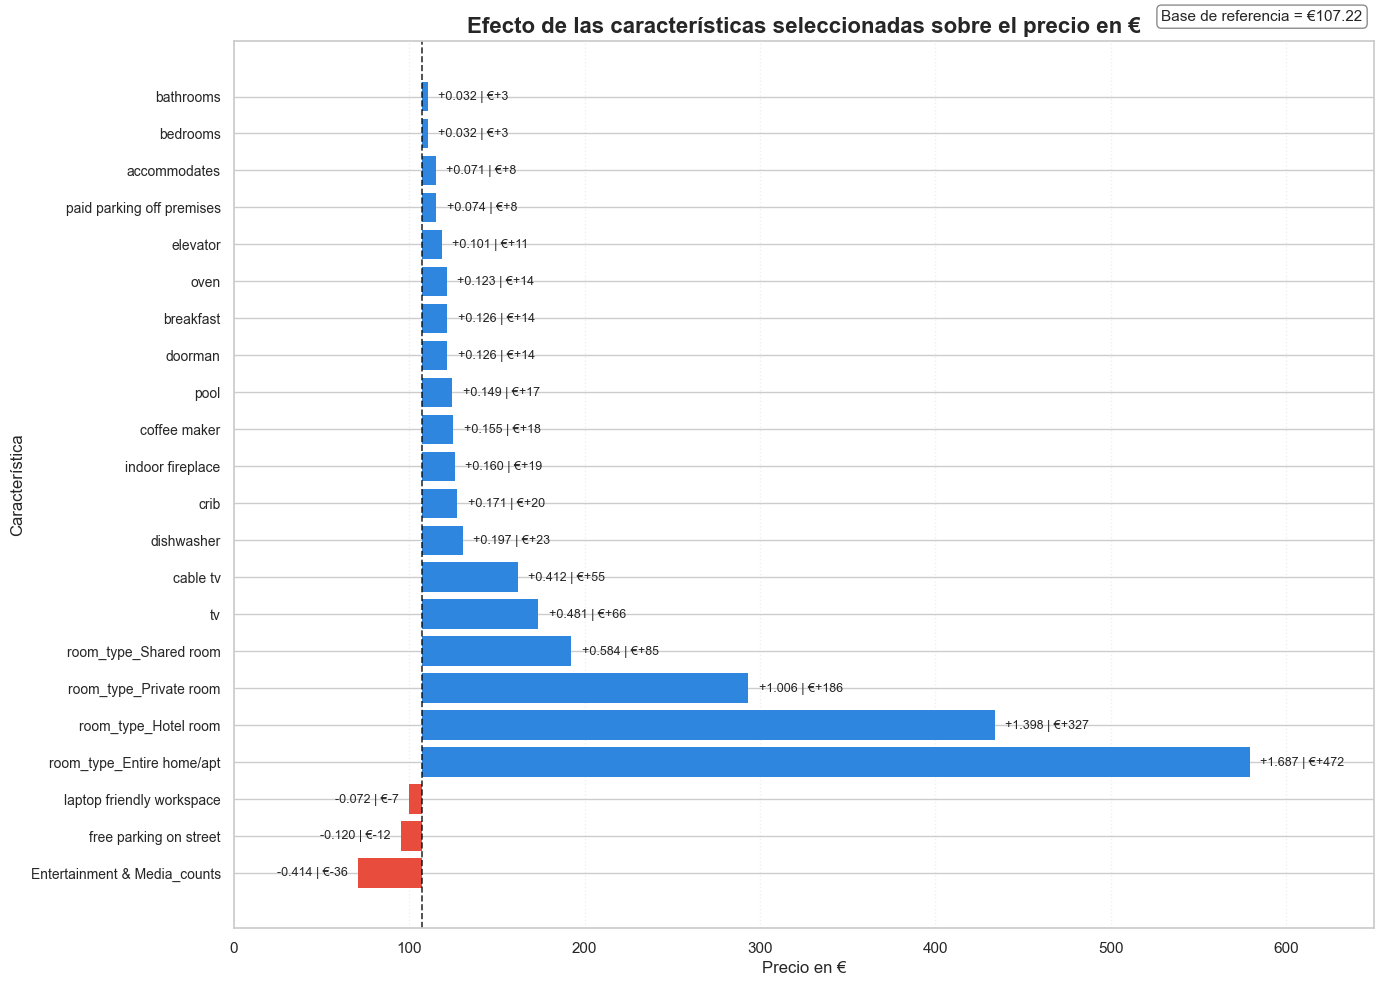

In [231]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------
# Input data
# -------------------------------------------------
data = [
    ("accommodates", 0.0714),
    ("bathrooms", 0.0315),
    ("bedrooms", 0.0315),
    ("breakfast", 0.1255),
    ("cable tv", 0.4124),
    ("coffee maker", 0.1547),
    ("crib", 0.1711),
    ("dishwasher", 0.1970),
    ("doorman", 0.1263),
    ("elevator", 0.1012),
    ("free parking on street", -0.1203),
    ("indoor fireplace", 0.1604),
    ("laptop friendly workspace", -0.0717),
    ("oven", 0.1235),
    ("paid parking off premises", 0.0736),
    ("pool", 0.1495),
    ("tv", 0.4807),
    ("Entertainment & Media_counts", -0.4138),
    ("room_type_Entire home/apt", 1.6868),
    ("room_type_Hotel room", 1.3977),
    ("room_type_Private room", 1.0065),
    ("room_type_Shared room", 0.5839),
]

intercept = 4.6749                  

# -------------------------------------------------
# Data prep
# -------------------------------------------------
features_df = pd.DataFrame(data, columns=["feature", "coef"])

# Baseline price in euro from intercept
baseline_eur = np.exp(intercept)

# Euro effect of each feature relative to baseline
# Interpretation: price change in € when feature is present
features_df["euro_delta"] = baseline_eur * (np.exp(features_df["coef"]) - 1)

features_df["effect"] = np.where(features_df["euro_delta"] >= 0, "positive", "negative")
features_df["abs_euro_delta"] = features_df["euro_delta"].abs()

# Order by signed euro effect, positives first, negatives after
df_pos = features_df[features_df["euro_delta"] >= 0].sort_values("euro_delta", ascending=True)
df_neg = features_df[features_df["euro_delta"] < 0].sort_values("euro_delta", ascending=False)
plot_df = pd.concat([df_pos, df_neg], ignore_index=True)

# X positions centered on intercept in euro
plot_df["x_left"] = np.where(
    plot_df["euro_delta"] >= 0,
    baseline_eur,
    baseline_eur + plot_df["euro_delta"]
)
plot_df["bar_width"] = plot_df["euro_delta"].abs()

# Labels
plot_df["label"] = plot_df.apply(
    lambda r: f'{r["coef"]:+.3f} | €{r["euro_delta"]:+.0f}',
    axis=1
)

# Colors
colors = plot_df["euro_delta"].apply(lambda x: "#2E86DE" if x >= 0 else "#E74C3C")

# -------------------------------------------------
# Plot
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 10))

y = np.arange(len(plot_df))

ax.barh(
    y,
    plot_df["bar_width"],
    left=plot_df["x_left"],
    color=colors,
    edgecolor="none"
)

# Reference line at intercept in euro, not at zero
ax.axvline(baseline_eur, color="black", linewidth=1.2, linestyle="--", alpha=0.8)

# Y labels
ax.set_yticks(y)
ax.set_yticklabels(plot_df["feature"], fontsize=10)

# Value labels
for i, row in plot_df.iterrows():
    x_end = row["x_left"] + row["bar_width"] if row["euro_delta"] >= 0 else row["x_left"]
    if row["euro_delta"] >= 0:
        ax.text(x_end + 6, i, row["label"], va="center", ha="left", fontsize=9)
    else:
        ax.text(x_end - 6, i, row["label"], va="center", ha="right", fontsize=9)

# Title and axes
ax.set_title(
    "Efecto de las características seleccionadas sobre el precio en €",
    fontsize=16,
    weight="bold"
)
ax.set_xlabel("Precio en €")
ax.set_ylabel("Característica")

# X axis fixed range
ax.set_xlim(0, 650)

# Intercept annotation
ax.text(
    0.99, 1.02,
    f"Base de referencia = €{baseline_eur:.2f}",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.9)
)

# Style
ax.invert_yaxis()
ax.grid(axis="x", linestyle=":", alpha=0.3)

plt.tight_layout()
plt.show()

##### **Results Madrid ~ General**

From three modelling approaches, Ordinary Least Squares (OLS) regression demonstrated the highest r2 = 0.642952.
Based on VIF estimation, the following features had highest collinearity:
    feature	VIF
5	bathrooms	inf
3	bedrooms	inf
0	accommodates	15.401490
12	refrigerator	12.482769
1	beds	10.052022
14	microwave	9.246660
19	kitchen	9.165580
13	hangers	8.126017
26	hair dryer	7.024111
9	iron	6.850443
7	tv	6.588189

"accommodates", "bedrooms", "bathrooms" and "beds" represent Capacity characteristics of the accommodation, being highly colinear. It is proposed to use for further estimations **"accommodates"** only.
"refrigerator", "microwave", "kitchen", "hangers", "hair dryer", "iron" may be omitted from modelling, as being colinear with another features, and estimated with p>0.05 in OLS model.

Features with accepted VIF and p<0.05 were:
#--------------------------------------------------------------------------------------------------------
                                           coef    std err          t      P>|t|      [0.025      0.975]
#--------------------------------------------------------------------------------------------------------
const                                    4.6749      0.072     65.045      0.000       4.534       4.816
accommodates                             0.0714      0.012      5.890      0.000       0.048       0.095
bathrooms                                0.0315      0.010      3.169      0.002       0.012       0.051
bedrooms                                 0.0315      0.010      3.169      0.002       0.012       0.051
breakfast                                0.1255      0.053      2.361      0.018       0.021       0.230
cable tv                                 0.4124      0.165      2.496      0.013       0.088       0.737
coffee maker                             0.1547      0.065      2.391      0.017       0.028       0.282
crib                                     0.1711      0.052      3.280      0.001       0.069       0.273
dishwasher                               0.1970      0.058      3.404      0.001       0.083       0.311
doorman                                  0.1263      0.047      2.662      0.008       0.033       0.219
elevator                                 0.1012      0.045      2.252      0.024       0.013       0.189
free parking on street                  -0.1203      0.045     -2.672      0.008      -0.209      -0.032
indoor fireplace                         0.1604      0.081      1.973      0.049       0.001       0.320
laptop friendly workspace               -0.0717      0.036     -1.971      0.049      -0.143      -0.000
oven                                     0.1235      0.059      2.089      0.037       0.008       0.239
paid parking off premises                0.0736      0.034      2.147      0.032       0.006       0.141
pool                                     0.1495      0.066      2.271      0.023       0.020       0.279
tv                                       0.4807      0.166      2.904      0.004       0.156       0.805
Entertainment & Media_counts            -0.4138      0.157     -2.642      0.008      -0.721      -0.107
room_type_Entire home/apt                1.6868      0.048     35.056      0.000       1.592       1.781
room_type_Hotel room                     1.3977      0.115     12.122      0.000       1.172       1.624
room_type_Private room                   1.0065      0.044     23.026      0.000       0.921       1.092
room_type_Shared room                    0.5839      0.092      6.337      0.000       0.403       0.765

##### **Analysis Madrid ~ Entire home/apt**

In [70]:
outdir = Path("output_Madrid_Entire")
outdir.mkdir(exist_ok=True)

In [71]:
log("Starting data preparation")

price_orig = "price"
target = "price_log2"
id_cols = ["apartment_id", "host_id", "insert_date"]
location = ["city", "neighbourhood_district", "neighbourhood_name"]
df_model = df[(df["city"] == 'madrid') & (df["room_type"] == "Entire home/apt")].copy()

X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
y = df_model[target].astype(float)

list_cols = [c for c in X.columns if X[c].apply(lambda v: isinstance(v, list)).any()]
if list_cols:
    log(f"Dropping list-valued columns: {list_cols}")
    X = X.drop(columns=list_cols)

num_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

X[num_cols] = X[num_cols].apply(lambda s: s.astype(float) if s.dtype == "bool" else s)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")
log(f"Numeric cols: {len(num_cols)}, Categorical cols: {len(cat_cols)}")

[13:03:35] Starting data preparation


[13:03:36] Train rows: 839, Test rows: 210
[13:03:36] Numeric cols: 250, Categorical cols: 1


In [72]:
log("Building preprocessors")

preprocess_rf = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

preprocess_enet = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

log("Preprocessors ready")

[13:03:36] Building preprocessors
[13:03:36] Preprocessors ready


In [73]:
log("Fitting Random Forest")

rf = Pipeline(steps=[
    ("preprocess", preprocess_rf),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        max_depth=12,
        min_samples_leaf=5,
        max_features="sqrt"
    ))
])

t0 = time.time()
rf.fit(X_train, y_train)
log(f"Random Forest fit completed in {time.time() - t0:.1f}s")

rf_pred = rf.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
log(f"RF test RMSE={rf_rmse:.4f}, R2={rf_r2:.4f}")

[13:03:36] Fitting Random Forest
[13:03:37] Random Forest fit completed in 0.7s
[13:03:37] RF test RMSE=0.5873, R2=0.2955


In [74]:
log("Computing permutation importance")

X_test_trans = rf.named_steps["preprocess"].transform(X_test)
feature_names = rf.named_steps["preprocess"].get_feature_names_out()

t0 = time.time()
perm = permutation_importance(
    rf.named_steps["model"],
    X_test_trans,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)
log(f"Permutation importance completed in {time.time() - t0:.1f}s")

rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

rf_importance.to_csv(outdir / "rf_permutation_importance.csv", index=False)
log("Saved RF importance to output/rf_permutation_importance.csv")

display(rf_importance.head(20))

[13:03:37] Computing permutation importance
[13:04:26] Permutation importance completed in 49.1s
[13:04:26] Saved RF importance to output/rf_permutation_importance.csv


,feature,importance_mean,importance_std
2,bedrooms,0.068345,0.011733
3,beds,0.051415,0.005907
1,bathrooms,0.047760,0.009640
0,accommodates,0.042568,0.006454
58,dishwasher,0.016430,0.005100
7,air conditioning,0.012175,0.006350
63,dryer,0.011071,0.001845
68,elevator,0.008095,0.004604
235,Accessibility_counts,0.006880,0.002280
242,Laundry & Housekeeping_counts,0.005375,0.001919


In [75]:
log("Fitting Elastic Net")

enet_pipe = Pipeline(steps=[
    ("preprocess", preprocess_enet),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9],
        alphas=np.logspace(-4, 1, 30),
        cv=5,
        random_state=42,
        max_iter=10000
    ))
])

t0 = time.time()
enet_pipe.fit(X_train, y_train)
log(f"Elastic Net fit completed in {time.time() - t0:.1f}s")

enet = enet_pipe.named_steps["model"]
enet_pred = enet_pipe.predict(X_test)
enet_rmse = np.sqrt(mean_squared_error(y_test, enet_pred))

enet_r2 = r2_score(y_test, enet_pred)

enet_features = enet_pipe.named_steps["preprocess"].get_feature_names_out()
enet_coefs = pd.DataFrame({
    "feature": enet_features,
    "coef": enet.coef_
})
enet_coefs["abs_coef"] = enet_coefs["coef"].abs()
enet_selected = enet_coefs[enet_coefs["coef"] != 0].sort_values("abs_coef", ascending=False)

enet_coefs.to_csv(outdir / "elastic_net_coefficients.csv", index=False)
log("Saved Elastic Net coefficients to output/elastic_net_coefficients.csv")

log(f"Elastic Net chosen alpha={enet.alpha_:.6f}, l1_ratio={enet.l1_ratio_}")
log(f"EN test RMSE={enet_rmse:.4f}, R2={enet_r2:.4f}")

display(enet_selected.head(30))

[13:04:26] Fitting Elastic Net
[13:04:37] Elastic Net fit completed in 10.5s
[13:04:37] Saved Elastic Net coefficients to output/elastic_net_coefficients.csv
[13:04:37] Elastic Net chosen alpha=0.188739, l1_ratio=0.1
[13:04:37] EN test RMSE=0.5764, R2=0.3214


,feature,coef,abs_coef
0,accommodates,0.114690,0.114690
1,bathrooms,0.084400,0.084400
2,bedrooms,0.084353,0.084353
58,dishwasher,0.060357,0.060357
7,air conditioning,0.055610,0.055610
89,free parking on street,-0.055219,0.055219
3,beds,0.053347,0.053347
51,crib,0.046406,0.046406
127,microwave,-0.043083,0.043083
150,pets allowed,-0.037899,0.037899


In [76]:
log("Preparing VIF check")

top_rf = rf_importance["feature"].head(25).tolist()
top_en = enet_selected["feature"].head(25).tolist()

candidate_features = list(dict.fromkeys(top_rf + top_en))
log(f"Initial candidate features from RF + EN: {len(candidate_features)}")

base_cols = []
for f in candidate_features:
    base = f.split("_")[0] if "_" in f else f
    if base in X_train.columns:
        base_cols.append(base)

base_cols = list(dict.fromkeys(base_cols))
log(f"Base columns kept for VIF: {base_cols}")

X_vif = X_train[base_cols].copy()
X_vif = pd.get_dummies(X_vif, drop_first=True)

for c in X_vif.columns:
    if X_vif[c].dtype == "bool":
        X_vif[c] = X_vif[c].astype(int)

X_vif = X_vif.fillna(X_vif.median(numeric_only=True))

log(f"VIF matrix shape: {X_vif.shape}")

vif_data = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

vif_data.to_csv(outdir / "vif_results.csv", index=False)
log("Saved VIF results to output/vif_results.csv")

display(vif_data.head(30))

[13:04:37] Preparing VIF check
[13:04:37] Initial candidate features from RF + EN: 34
[13:04:37] Base columns kept for VIF: ['bedrooms', 'beds', 'bathrooms', 'accommodates', 'dishwasher', 'air conditioning', 'dryer', 'elevator', 'crib', 'dishes and silverware', 'oven', 'pets allowed', 'microwave', 'hangers', 'shampoo', 'family kid friendly', 'cable tv', 'smoke alarm', 'free parking on street', 'iron', 'dog', "pack 'n play travel crib", 'heating', 'extra pillows and blankets', 'breakfast', 'safety card']
[13:04:37] VIF matrix shape: (839, 26)
[13:04:37] Saved VIF results to output/vif_results.csv


,feature,VIF
0,bedrooms,inf
2,bathrooms,inf
3,accommodates,19.280542
22,heating,12.081146
9,dishes and silverware,11.624170
1,beds,10.620043
12,microwave,9.291493
13,hangers,9.252357
19,iron,7.919250
5,air conditioning,5.204582


In [77]:
log("Fitting Gamma GLM with log link")

glm_X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
glm_list_cols = [c for c in glm_X.columns if glm_X[c].apply(lambda v: isinstance(v, list)).any()]
if glm_list_cols:
    log(f"Dropping list-valued columns from GLM: {glm_list_cols}")
    glm_X = glm_X.drop(columns=glm_list_cols)

glm_num_cols = glm_X.select_dtypes(include=["number", "bool"]).columns.tolist()
glm_cat_cols = glm_X.select_dtypes(include=["object", "category"]).columns.tolist()

glm_preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), glm_num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), glm_cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

t0 = time.time()
X_glm = glm_preprocess.fit_transform(glm_X)
log(f"GLM preprocessing completed in {time.time() - t0:.1f}s")

glm_feature_names = glm_preprocess.get_feature_names_out()
X_glm_df = pd.DataFrame(X_glm, columns=glm_feature_names, index=df_model.index)
X_glm_df = sm.add_constant(X_glm_df, has_constant="add")

y_glm = df_model[target].astype(float)

t0 = time.time()
gamma_model = sm.GLM(
    y_glm,
    X_glm_df,
    family=sm.families.Gamma(link=sm.families.links.log())
).fit()
log(f"Gamma GLM fit completed in {time.time() - t0:.1f}s")

with open(outdir / "gamma_glm_summary.txt", "w", encoding="utf-8") as f:
    f.write(gamma_model.summary().as_text())

log("Saved Gamma GLM summary to output/gamma_glm_summary.txt")
print(gamma_model.summary())

[13:04:37] Fitting Gamma GLM with log link
[13:04:37] GLM preprocessing completed in 0.0s
[13:04:43] Gamma GLM fit completed in 5.9s
[13:04:43] Saved Gamma GLM summary to output/gamma_glm_summary.txt
                 Generalized Linear Model Regression Results                  
Dep. Variable:             price_log2   No. Observations:                 1049
Model:                            GLM   Df Residuals:                      889
Model Family:                   Gamma   Df Model:                          159
Link Function:                    log   Scale:                       0.0032464
Method:                          IRLS   Log-Likelihood:                -780.25
Date:                Sun, 07 Jun 2026   Deviance:                       2.8631
Time:                        13:04:43   Pearson chi2:                     2.89
No. Iterations:                   100   Pseudo R-squ. (CS):             0.5259
Covariance Type:            nonrobust                                         
          

In [78]:
log("Fitting OLS on log(price)")

if "price" in df_model.columns:
    y_lin = np.log(df_model["price"].astype(float))
    X_lin = X_glm_df.copy()

    t0 = time.time()
    lin_model = sm.OLS(y_lin, X_lin).fit()
    log(f"OLS fit completed in {time.time() - t0:.1f}s")

    with open(outdir / "ols_logprice_summary.txt", "w", encoding="utf-8") as f:
        f.write(lin_model.summary().as_text())

    log("Saved OLS summary to output/ols_logprice_summary.txt")
    print(lin_model.summary())
else:
    lin_model = None
    log("No raw price column found; skipping OLS on log(price)")

[13:04:44] Fitting OLS on log(price)
[13:04:44] OLS fit completed in 0.5s
[13:04:44] Saved OLS summary to output/ols_logprice_summary.txt
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.468
Model:                            OLS   Adj. R-squared:                  0.373
Method:                 Least Squares   F-statistic:                     4.922
Date:                Sun, 07 Jun 2026   Prob (F-statistic):           1.17e-53
Time:                        13:04:44   Log-Likelihood:                -405.49
No. Observations:                1049   AIC:                             1131.
Df Residuals:                     889   BIC:                             1924.
Df Model:                         159                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t   

In [79]:
log("Building comparison table")

results = pd.DataFrame([
    {"model": "Random Forest", "rmse": rf_rmse, "r2": rf_r2},
    {"model": "Elastic Net", "rmse": enet_rmse, "r2": enet_r2},
])

if lin_model is not None:
    results = pd.concat([
        results,
        pd.DataFrame([{
            "model": "OLS log(price)",
            "rmse": np.nan,
            "r2": lin_model.rsquared
        }])
    ], ignore_index=True)

results.to_csv(outdir / "model_comparison.csv", index=False)
log("Saved comparison table to output/model_comparison.csv")
display(results)

[13:04:45] Building comparison table
[13:04:45] Saved comparison table to output/model_comparison.csv


,model,rmse,r2
0,Random Forest,0.587342,0.295474
1,Elastic Net,0.576425,0.321421
2,OLS log(price),NaN,0.468169


##### **Results Madrid ~ Entire home/apt**

##### **Analysis Madrid ~ Private room**

In [80]:
outdir = Path("output_Madrid_Private")
outdir.mkdir(exist_ok=True)

In [81]:
log("Starting data preparation")

price_orig = "price"
target = "price_log2"
id_cols = ["apartment_id", "host_id", "insert_date"]
location = ["city", "neighbourhood_district", "neighbourhood_name"]
df_model = df[(df["city"] == 'madrid') & (df["room_type"] == "Private room")].copy()

X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
y = df_model[target].astype(float)

list_cols = [c for c in X.columns if X[c].apply(lambda v: isinstance(v, list)).any()]
if list_cols:
    log(f"Dropping list-valued columns: {list_cols}")
    X = X.drop(columns=list_cols)

num_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

X[num_cols] = X[num_cols].apply(lambda s: s.astype(float) if s.dtype == "bool" else s)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")
log(f"Numeric cols: {len(num_cols)}, Categorical cols: {len(cat_cols)}")

[13:04:45] Starting data preparation


[13:04:45] Train rows: 448, Test rows: 112
[13:04:45] Numeric cols: 250, Categorical cols: 1


In [82]:
log("Building preprocessors")

preprocess_rf = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

preprocess_enet = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

log("Preprocessors ready")

[13:04:45] Building preprocessors
[13:04:45] Preprocessors ready


In [83]:
log("Fitting Random Forest")

rf = Pipeline(steps=[
    ("preprocess", preprocess_rf),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        max_depth=12,
        min_samples_leaf=5,
        max_features="sqrt"
    ))
])

t0 = time.time()
rf.fit(X_train, y_train)
log(f"Random Forest fit completed in {time.time() - t0:.1f}s")

rf_pred = rf.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
log(f"RF test RMSE={rf_rmse:.4f}, R2={rf_r2:.4f}")

[13:04:45] Fitting Random Forest
[13:04:46] Random Forest fit completed in 0.7s
[13:04:46] RF test RMSE=0.7920, R2=0.0234


In [84]:
log("Computing permutation importance")

X_test_trans = rf.named_steps["preprocess"].transform(X_test)
feature_names = rf.named_steps["preprocess"].get_feature_names_out()

t0 = time.time()
perm = permutation_importance(
    rf.named_steps["model"],
    X_test_trans,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)
log(f"Permutation importance completed in {time.time() - t0:.1f}s")

rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

rf_importance.to_csv(outdir / "rf_permutation_importance.csv", index=False)
log("Saved RF importance to output/rf_permutation_importance.csv")

display(rf_importance.head(20))

[13:04:46] Computing permutation importance
[13:05:35] Permutation importance completed in 48.9s
[13:05:35] Saved RF importance to output/rf_permutation_importance.csv


,feature,importance_mean,importance_std
0,accommodates,0.028075,0.008898
89,free parking on street,0.012081,0.005636
171,shampoo,0.007752,0.003494
201,tv,0.005572,0.001868
240,In-Room Essentials & Comfort_counts,0.004872,0.003269
238,Entertainment & Media_counts,0.004760,0.000909
3,beds,0.003104,0.008363
219,total_number_units,0.002956,0.002086
7,air conditioning,0.002763,0.002660
204,washer,0.002743,0.001087


In [85]:
log("Fitting Elastic Net")

enet_pipe = Pipeline(steps=[
    ("preprocess", preprocess_enet),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9],
        alphas=np.logspace(-4, 1, 30),
        cv=5,
        random_state=42,
        max_iter=10000
    ))
])

t0 = time.time()
enet_pipe.fit(X_train, y_train)
log(f"Elastic Net fit completed in {time.time() - t0:.1f}s")

enet = enet_pipe.named_steps["model"]
enet_pred = enet_pipe.predict(X_test)
enet_rmse = np.sqrt(mean_squared_error(y_test, enet_pred))

enet_r2 = r2_score(y_test, enet_pred)

enet_features = enet_pipe.named_steps["preprocess"].get_feature_names_out()
enet_coefs = pd.DataFrame({
    "feature": enet_features,
    "coef": enet.coef_
})
enet_coefs["abs_coef"] = enet_coefs["coef"].abs()
enet_selected = enet_coefs[enet_coefs["coef"] != 0].sort_values("abs_coef", ascending=False)

enet_coefs.to_csv(outdir / "elastic_net_coefficients.csv", index=False)
log("Saved Elastic Net coefficients to output/elastic_net_coefficients.csv")

log(f"Elastic Net chosen alpha={enet.alpha_:.6f}, l1_ratio={enet.l1_ratio_}")
log(f"EN test RMSE={enet_rmse:.4f}, R2={enet_r2:.4f}")

display(enet_selected.head(30))

[13:05:35] Fitting Elastic Net
[13:05:45] Elastic Net fit completed in 10.3s
[13:05:45] Saved Elastic Net coefficients to output/elastic_net_coefficients.csv
[13:05:45] Elastic Net chosen alpha=0.126896, l1_ratio=0.5
[13:05:45] EN test RMSE=0.8007, R2=0.0018


,feature,coef,abs_coef
0,accommodates,0.087691,0.087691
89,free parking on street,-0.072650,0.072650
68,elevator,0.056889,0.056889
112,indoor fireplace,0.050466,0.050466
44,cleaning before checkout,-0.022458,0.022458
117,kitchen,-0.018136,0.018136
220,Accessibility_name,0.013026,0.013026
60,doorman,0.012297,0.012297
30,breakfast,0.003913,0.003913
225,In-Room Essentials & Comfort_name,-0.002524,0.002524


In [86]:
log("Preparing VIF check")

top_rf = rf_importance["feature"].head(25).tolist()
top_en = enet_selected["feature"].head(25).tolist()

candidate_features = list(dict.fromkeys(top_rf + top_en))
log(f"Initial candidate features from RF + EN: {len(candidate_features)}")

base_cols = []
for f in candidate_features:
    base = f.split("_")[0] if "_" in f else f
    if base in X_train.columns:
        base_cols.append(base)

base_cols = list(dict.fromkeys(base_cols))
log(f"Base columns kept for VIF: {base_cols}")

X_vif = X_train[base_cols].copy()
X_vif = pd.get_dummies(X_vif, drop_first=True)

for c in X_vif.columns:
    if X_vif[c].dtype == "bool":
        X_vif[c] = X_vif[c].astype(int)

X_vif = X_vif.fillna(X_vif.median(numeric_only=True))

log(f"VIF matrix shape: {X_vif.shape}")

vif_data = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

vif_data.to_csv(outdir / "vif_results.csv", index=False)
log("Saved VIF results to output/vif_results.csv")

display(vif_data.head(30))

[13:05:46] Preparing VIF check
[13:05:46] Initial candidate features from RF + EN: 34
[13:05:46] Base columns kept for VIF: ['accommodates', 'free parking on street', 'shampoo', 'tv', 'beds', 'air conditioning', 'washer', 'fire extinguisher', 'paid parking off premises', 'extra pillows and blankets', 'dryer', 'wifi', 'dishwasher', 'safety card', 'laptop friendly workspace', 'elevator', 'indoor fireplace', 'cleaning before checkout', 'kitchen', 'doorman', 'breakfast', 'smoking allowed']
[13:05:46] VIF matrix shape: (448, 22)
[13:05:46] Saved VIF results to output/vif_results.csv


,feature,VIF
0,accommodates,11.676290
11,wifi,11.247358
4,beds,8.852649
18,kitchen,7.442382
6,washer,5.678802
2,shampoo,3.528625
3,tv,2.981103
14,laptop friendly workspace,2.862476
15,elevator,2.824140
9,extra pillows and blankets,1.885850


In [87]:
log("Fitting Gamma GLM with log link")

glm_X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
glm_list_cols = [c for c in glm_X.columns if glm_X[c].apply(lambda v: isinstance(v, list)).any()]
if glm_list_cols:
    log(f"Dropping list-valued columns from GLM: {glm_list_cols}")
    glm_X = glm_X.drop(columns=glm_list_cols)

glm_num_cols = glm_X.select_dtypes(include=["number", "bool"]).columns.tolist()
glm_cat_cols = glm_X.select_dtypes(include=["object", "category"]).columns.tolist()

glm_preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), glm_num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), glm_cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

t0 = time.time()
X_glm = glm_preprocess.fit_transform(glm_X)
log(f"GLM preprocessing completed in {time.time() - t0:.1f}s")

glm_feature_names = glm_preprocess.get_feature_names_out()
X_glm_df = pd.DataFrame(X_glm, columns=glm_feature_names, index=df_model.index)
X_glm_df = sm.add_constant(X_glm_df, has_constant="add")

y_glm = df_model[target].astype(float)

t0 = time.time()
gamma_model = sm.GLM(
    y_glm,
    X_glm_df,
    family=sm.families.Gamma(link=sm.families.links.log())
).fit()
log(f"Gamma GLM fit completed in {time.time() - t0:.1f}s")

with open(outdir / "gamma_glm_summary.txt", "w", encoding="utf-8") as f:
    f.write(gamma_model.summary().as_text())

log("Saved Gamma GLM summary to output/gamma_glm_summary.txt")
print(gamma_model.summary())

[13:05:46] Fitting Gamma GLM with log link
[13:05:47] GLM preprocessing completed in 0.1s
[13:05:51] Gamma GLM fit completed in 4.2s
[13:05:51] Saved Gamma GLM summary to output/gamma_glm_summary.txt
                 Generalized Linear Model Regression Results                  
Dep. Variable:             price_log2   No. Observations:                  560
Model:                            GLM   Df Residuals:                      422
Model Family:                   Gamma   Df Model:                          137
Link Function:                    log   Scale:                       0.0069076
Method:                          IRLS   Log-Likelihood:                -506.78
Date:                Sun, 07 Jun 2026   Deviance:                       2.8015
Time:                        13:05:51   Pearson chi2:                     2.91
No. Iterations:                   100   Pseudo R-squ. (CS):             0.3106
Covariance Type:            nonrobust                                         
          

In [88]:
log("Fitting OLS on log(price)")

if "price" in df_model.columns:
    y_lin = np.log(df_model["price"].astype(float))
    X_lin = X_glm_df.copy()

    t0 = time.time()
    lin_model = sm.OLS(y_lin, X_lin).fit()
    log(f"OLS fit completed in {time.time() - t0:.1f}s")

    with open(outdir / "ols_logprice_summary.txt", "w", encoding="utf-8") as f:
        f.write(lin_model.summary().as_text())

    log("Saved OLS summary to output/ols_logprice_summary.txt")
    print(lin_model.summary())
else:
    lin_model = None
    log("No raw price column found; skipping OLS on log(price)")

[13:05:51] Fitting OLS on log(price)
[13:05:52] OLS fit completed in 0.5s
[13:05:52] Saved OLS summary to output/ols_logprice_summary.txt
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.329
Model:                            OLS   Adj. R-squared:                  0.111
Method:                 Least Squares   F-statistic:                     1.509
Date:                Sun, 07 Jun 2026   Prob (F-statistic):            0.00104
Time:                        13:05:52   Log-Likelihood:                -305.50
No. Observations:                 560   AIC:                             887.0
Df Residuals:                     422   BIC:                             1484.
Df Model:                         137                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t   

In [89]:
log("Building comparison table")

results = pd.DataFrame([
    {"model": "Random Forest", "rmse": rf_rmse, "r2": rf_r2},
    {"model": "Elastic Net", "rmse": enet_rmse, "r2": enet_r2},
])

if lin_model is not None:
    results = pd.concat([
        results,
        pd.DataFrame([{
            "model": "OLS log(price)",
            "rmse": np.nan,
            "r2": lin_model.rsquared
        }])
    ], ignore_index=True)

results.to_csv(outdir / "model_comparison.csv", index=False)
log("Saved comparison table to output/model_comparison.csv")
display(results)

[13:05:52] Building comparison table
[13:05:52] Saved comparison table to output/model_comparison.csv


,model,rmse,r2
0,Random Forest,0.792045,0.023352
1,Elastic Net,0.800744,0.001782
2,OLS log(price),NaN,0.328837


##### **Results Madrid ~ Private room**

##### **Analysis Madrid ~ Hotel room**

In [90]:
outdir = Path("output_Madrid_Hotel")
outdir.mkdir(exist_ok=True)

In [91]:
log("Starting data preparation")

price_orig = "price"
target = "price_log2"
id_cols = ["apartment_id", "host_id", "insert_date"]
location = ["city", "neighbourhood_district", "neighbourhood_name"]
df_model = df[(df["city"] == 'madrid') & (df["room_type"] == "Hotel room")].copy()

X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
y = df_model[target].astype(float)

list_cols = [c for c in X.columns if X[c].apply(lambda v: isinstance(v, list)).any()]
if list_cols:
    log(f"Dropping list-valued columns: {list_cols}")
    X = X.drop(columns=list_cols)

num_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

X[num_cols] = X[num_cols].apply(lambda s: s.astype(float) if s.dtype == "bool" else s)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")
log(f"Numeric cols: {len(num_cols)}, Categorical cols: {len(cat_cols)}")

[13:05:52] Starting data preparation
[13:05:53] Train rows: 8, Test rows: 3
[13:05:53] Numeric cols: 250, Categorical cols: 1


##### **Results Madrid ~ Hotel room**
- too few values for the analysis

##### **Analysis Madrid ~ Shared room**

In [92]:
outdir = Path("output_Madrid_Shared")
outdir.mkdir(exist_ok=True)

In [93]:
log("Starting data preparation")

price_orig = "price"
target = "price_log2"
id_cols = ["apartment_id", "host_id", "insert_date"]
location = ["city", "neighbourhood_district", "neighbourhood_name"]
df_model = df[(df["city"] == 'madrid') & (df["room_type"] == "Shared room")].copy()

X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
y = df_model[target].astype(float)

list_cols = [c for c in X.columns if X[c].apply(lambda v: isinstance(v, list)).any()]
if list_cols:
    log(f"Dropping list-valued columns: {list_cols}")
    X = X.drop(columns=list_cols)

num_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

X[num_cols] = X[num_cols].apply(lambda s: s.astype(float) if s.dtype == "bool" else s)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")
log(f"Numeric cols: {len(num_cols)}, Categorical cols: {len(cat_cols)}")

[13:05:53] Starting data preparation
[13:05:53] Train rows: 14, Test rows: 4
[13:05:53] Numeric cols: 250, Categorical cols: 1


##### **Results Madrid ~ Shared room**
- very few values for the analysis

#### **GIRONA**

##### **Analysis Girona ~ General**

In [232]:
outdir = Path("output_Girona_general")
outdir.mkdir(exist_ok=True)

In [233]:
log("Starting data preparation")

price_orig = "price"
target = "price_log2"
id_cols = ["apartment_id", "host_id", "insert_date"]
location = ["city", "neighbourhood_district", "neighbourhood_name"]
df_model = df[df["city"] == 'girona'].copy()

X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
y = df_model[target].astype(float)

list_cols = [c for c in X.columns if X[c].apply(lambda v: isinstance(v, list)).any()]
if list_cols:
    log(f"Dropping list-valued columns: {list_cols}")
    X = X.drop(columns=list_cols)

num_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

X[num_cols] = X[num_cols].apply(lambda s: s.astype(float) if s.dtype == "bool" else s)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")
log(f"Numeric cols: {len(num_cols)}, Categorical cols: {len(cat_cols)}")

[17:09:58] Starting data preparation
[17:10:00] Dropping list-valued columns: ['Accessibility_name', 'Digital/Tech_name', 'Entertainment & Media_name', 'Family & Pets_name', 'In-Room Essentials & Comfort_name', 'Kitchen & Dining_name', 'Laundry & Housekeeping_name', 'Luxury & Premium_name', 'Other_name', 'Outdoor & Views_name', 'Parking & Transport_name', 'Safety & Security_name', 'Service & Operations_name', 'Wellness & Recreation_name']
[17:10:02] Train rows: 957, Test rows: 240
[17:10:02] Numeric cols: 235, Categorical cols: 2


In [234]:
log("Building preprocessors")

preprocess_rf = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

preprocess_enet = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

log("Preprocessors ready")

[17:10:25] Building preprocessors
[17:10:25] Preprocessors ready


In [235]:
log("Fitting Random Forest")

rf = Pipeline(steps=[
    ("preprocess", preprocess_rf),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        max_depth=12,
        min_samples_leaf=5,
        max_features="sqrt"
    ))
])

t0 = time.time()
rf.fit(X_train, y_train)
log(f"Random Forest fit completed in {time.time() - t0:.1f}s")

rf_pred = rf.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
log(f"RF test RMSE={rf_rmse:.4f}, R2={rf_r2:.4f}")

[17:10:38] Fitting Random Forest
[17:10:40] Random Forest fit completed in 2.6s
[17:10:41] RF test RMSE=0.6596, R2=0.3752


In [236]:
log("Computing permutation importance")

X_test_trans = rf.named_steps["preprocess"].transform(X_test)
feature_names = rf.named_steps["preprocess"].get_feature_names_out()

t0 = time.time()
perm = permutation_importance(
    rf.named_steps["model"],
    X_test_trans,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)
log(f"Permutation importance completed in {time.time() - t0:.1f}s")

rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

rf_importance.to_csv(outdir / "rf_permutation_importance.csv", index=False)
log("Saved RF importance to output/rf_permutation_importance.csv")

display(rf_importance.head(20))

[17:10:53] Computing permutation importance
[17:13:59] Permutation importance completed in 185.6s
[17:13:59] Saved RF importance to output/rf_permutation_importance.csv


,feature,importance_mean,importance_std
0,accommodates,0.056414,0.010584
1,bathrooms,0.038200,0.014114
2,bedrooms,0.037294,0.011354
3,beds,0.032489,0.006766
154,pool,0.025448,0.003868
112,indoor fireplace,0.022365,0.003924
234,Wellness & Recreation_counts,0.016759,0.004288
58,dishwasher,0.008965,0.005003
68,elevator,0.006078,0.002877
229,Other_counts,0.006056,0.001740


In [237]:
log("Fitting Elastic Net")

enet_pipe = Pipeline(steps=[
    ("preprocess", preprocess_enet),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9],
        alphas=np.logspace(-4, 1, 30),
        cv=5,
        random_state=42,
        max_iter=10000
    ))
])

t0 = time.time()
enet_pipe.fit(X_train, y_train)
log(f"Elastic Net fit completed in {time.time() - t0:.1f}s")

enet = enet_pipe.named_steps["model"]
enet_pred = enet_pipe.predict(X_test)
enet_rmse = np.sqrt(mean_squared_error(y_test, enet_pred))

enet_r2 = r2_score(y_test, enet_pred)

enet_features = enet_pipe.named_steps["preprocess"].get_feature_names_out()
enet_coefs = pd.DataFrame({
    "feature": enet_features,
    "coef": enet.coef_
})
enet_coefs["abs_coef"] = enet_coefs["coef"].abs()
enet_selected = enet_coefs[enet_coefs["coef"] != 0].sort_values("abs_coef", ascending=False)

enet_coefs.to_csv(outdir / "elastic_net_coefficients.csv", index=False)
log("Saved Elastic Net coefficients to output/elastic_net_coefficients.csv")

log(f"Elastic Net chosen alpha={enet.alpha_:.6f}, l1_ratio={enet.l1_ratio_}")
log(f"EN test RMSE={enet_rmse:.4f}, R2={enet_r2:.4f}")

display(enet_selected.head(30))

[17:14:08] Fitting Elastic Net
[17:14:16] Elastic Net fit completed in 7.3s
[17:14:16] Saved Elastic Net coefficients to output/elastic_net_coefficients.csv
[17:14:16] Elastic Net chosen alpha=0.057362, l1_ratio=0.5
[17:14:16] EN test RMSE=0.6698, R2=0.3558


,feature,coef,abs_coef
0,accommodates,0.276274,0.276274
112,indoor fireplace,0.095448,0.095448
58,dishwasher,0.091353,0.091353
164,refrigerator,-0.074971,0.074971
154,pool,0.074415,0.074415
1,bathrooms,0.062030,0.062030
2,bedrooms,0.061144,0.061144
204,washer,0.050132,0.050132
68,elevator,-0.048517,0.048517
234,Wellness & Recreation_counts,0.047796,0.047796


In [238]:
log("Preparing VIF check")

top_rf = rf_importance["feature"].head(25).tolist()
top_en = enet_selected["feature"].head(25).tolist()

candidate_features = list(dict.fromkeys(top_rf + top_en))
log(f"Initial candidate features from RF + EN: {len(candidate_features)}")

base_cols = []
for f in candidate_features:
    base = f.split("_")[0] if "_" in f else f
    if base in X_train.columns:
        base_cols.append(base)

base_cols = list(dict.fromkeys(base_cols))
log(f"Base columns kept for VIF: {base_cols}")

X_vif = X_train[base_cols].copy()
X_vif = pd.get_dummies(X_vif, drop_first=True)

for c in X_vif.columns:
    if X_vif[c].dtype == "bool":
        X_vif[c] = X_vif[c].astype(int)

X_vif = X_vif.fillna(X_vif.median(numeric_only=True))

log(f"VIF matrix shape: {X_vif.shape}")

vif_data = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

vif_data.to_csv(outdir / "vif_results.csv", index=False)
log("Saved VIF results to output/vif_results.csv")

display(vif_data.head(30))

[17:14:21] Preparing VIF check
[17:14:21] Initial candidate features from RF + EN: 39
[17:14:21] Base columns kept for VIF: ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'pool', 'indoor fireplace', 'dishwasher', 'elevator', 'free parking on premises', 'dryer', 'laptop friendly workspace', 'refrigerator', 'dishes and silverware', 'garden or backyard', 'private living room', 'coffee maker', 'oven', 'heating', 'washer', 'pets allowed', 'kitchen', 'lock on bedroom door', 'ev charger', 'patio or balcony', 'private entrance', 'free parking on street', 'cable tv', 'babysitter recommendations', 'flat path to front door', '24-hour check-in', 'other']
[17:14:21] VIF matrix shape: (957, 31)
[17:14:21] Saved VIF results to output/vif_results.csv


,feature,VIF
1,bathrooms,inf
2,bedrooms,inf
0,accommodates,24.759235
11,refrigerator,19.120208
12,dishes and silverware,16.036532
20,kitchen,14.464664
3,beds,13.929384
18,washer,10.400570
15,coffee maker,9.581057
16,oven,4.586693


In [239]:
log("Fitting Gamma GLM with log link")

glm_X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
glm_list_cols = [c for c in glm_X.columns if glm_X[c].apply(lambda v: isinstance(v, list)).any()]
if glm_list_cols:
    log(f"Dropping list-valued columns from GLM: {glm_list_cols}")
    glm_X = glm_X.drop(columns=glm_list_cols)

glm_num_cols = glm_X.select_dtypes(include=["number", "bool"]).columns.tolist()
glm_cat_cols = glm_X.select_dtypes(include=["object", "category"]).columns.tolist()

glm_preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), glm_num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), glm_cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

t0 = time.time()
X_glm = glm_preprocess.fit_transform(glm_X)
log(f"GLM preprocessing completed in {time.time() - t0:.1f}s")

glm_feature_names = glm_preprocess.get_feature_names_out()
X_glm_df = pd.DataFrame(X_glm, columns=glm_feature_names, index=df_model.index)
X_glm_df = sm.add_constant(X_glm_df, has_constant="add")

y_glm = df_model[target].astype(float)

t0 = time.time()
gamma_model = sm.GLM(
    y_glm,
    X_glm_df,
    family=sm.families.Gamma(link=sm.families.links.log())
).fit()
log(f"Gamma GLM fit completed in {time.time() - t0:.1f}s")

with open(outdir / "gamma_glm_summary.txt", "w", encoding="utf-8") as f:
    f.write(gamma_model.summary().as_text())

log("Saved Gamma GLM summary to output/gamma_glm_summary.txt")
print(gamma_model.summary())

[17:14:51] Fitting Gamma GLM with log link
[17:14:51] Dropping list-valued columns from GLM: ['Accessibility_name', 'Digital/Tech_name', 'Entertainment & Media_name', 'Family & Pets_name', 'In-Room Essentials & Comfort_name', 'Kitchen & Dining_name', 'Laundry & Housekeeping_name', 'Luxury & Premium_name', 'Other_name', 'Outdoor & Views_name', 'Parking & Transport_name', 'Safety & Security_name', 'Service & Operations_name', 'Wellness & Recreation_name']
[17:14:51] GLM preprocessing completed in 0.1s
[17:14:52] Gamma GLM fit completed in 0.6s
[17:14:52] Saved Gamma GLM summary to output/gamma_glm_summary.txt
                 Generalized Linear Model Regression Results                  
Dep. Variable:             price_log2   No. Observations:                 1197
Model:                            GLM   Df Residuals:                     1056
Model Family:                   Gamma   Df Model:                          140
Link Function:                    log   Scale:                       

In [240]:
log("Fitting OLS on log(price)")

if "price" in df_model.columns:
    y_lin = np.log(df_model["price"].astype(float))
    X_lin = X_glm_df.copy()

    t0 = time.time()
    lin_model = sm.OLS(y_lin, X_lin).fit()
    log(f"OLS fit completed in {time.time() - t0:.1f}s")

    with open(outdir / "ols_logprice_summary.txt", "w", encoding="utf-8") as f:
        f.write(lin_model.summary().as_text())

    log("Saved OLS summary to output/ols_logprice_summary.txt")
    print(lin_model.summary())
else:
    lin_model = None
    log("No raw price column found; skipping OLS on log(price)")

[17:14:57] Fitting OLS on log(price)
[17:14:57] OLS fit completed in 0.1s
[17:14:57] Saved OLS summary to output/ols_logprice_summary.txt
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.515
Model:                            OLS   Adj. R-squared:                  0.451
Method:                 Least Squares   F-statistic:                     8.024
Date:                Sun, 07 Jun 2026   Prob (F-statistic):           3.88e-95
Time:                        17:14:58   Log-Likelihood:                -668.66
No. Observations:                1197   AIC:                             1619.
Df Residuals:                    1056   BIC:                             2337.
Df Model:                         140                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t   

In [241]:
log("Building comparison table")

results = pd.DataFrame([
    {"model": "Random Forest", "rmse": rf_rmse, "r2": rf_r2},
    {"model": "Elastic Net", "rmse": enet_rmse, "r2": enet_r2},
])

if lin_model is not None:
    results = pd.concat([
        results,
        pd.DataFrame([{
            "model": "OLS log(price)",
            "rmse": np.nan,
            "r2": lin_model.rsquared
        }])
    ], ignore_index=True)

results.to_csv(outdir / "model_comparison.csv", index=False)
log("Saved comparison table to output/model_comparison.csv")
display(results)

[17:15:06] Building comparison table
[17:15:06] Saved comparison table to output/model_comparison.csv


,model,rmse,r2
0,Random Forest,0.659601,0.375202
1,Elastic Net,0.669786,0.355757
2,OLS log(price),NaN,0.515451


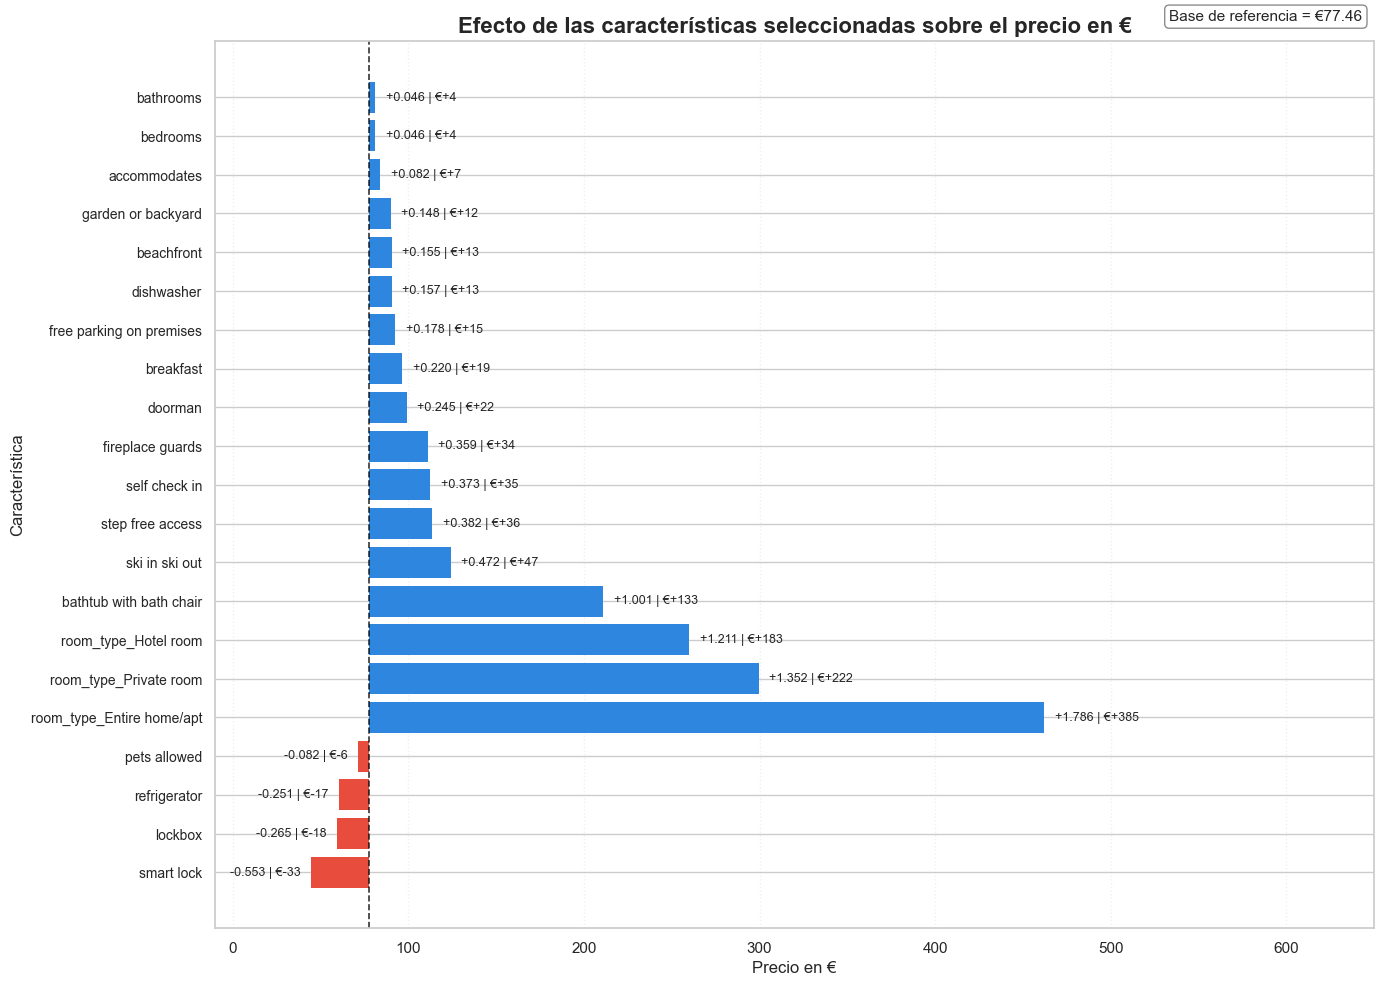

In [243]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------
# Input data
# -------------------------------------------------
data = [
    ("accommodates", 0.0820),
    ("bathrooms", 0.0463),
    ("bedrooms", 0.0463),
    ("bathtub with bath chair", 1.0013),
    ("beachfront", 0.1551),
    ("breakfast", 0.2204),
    ("dishwasher", 0.1572),
    ("doorman", 0.2452),
    ("fireplace guards", 0.3595),
    ("free parking on premises", 0.1785),
    ("garden or backyard", 0.1481),
    ("lockbox", -0.2648),
    ("pets allowed", -0.0816),
    ("refrigerator", -0.2514),
    ("self check in", 0.3733),
    ("ski in ski out", 0.4723),
    ("smart lock", -0.5530),
    ("step free access", 0.3817),
    ("room_type_Entire home/apt", 1.7862),
    ("room_type_Hotel room", 1.2113),
    ("room_type_Private room", 1.3523),

]

intercept = 4.3498                  
                  
# -------------------------------------------------
# Data prep
# -------------------------------------------------
features_df = pd.DataFrame(data, columns=["feature", "coef"])

# Baseline price in euro from intercept
baseline_eur = np.exp(intercept)

# Euro effect of each feature relative to baseline
# Interpretation: price change in € when feature is present
features_df["euro_delta"] = baseline_eur * (np.exp(features_df["coef"]) - 1)

features_df["effect"] = np.where(features_df["euro_delta"] >= 0, "positive", "negative")
features_df["abs_euro_delta"] = features_df["euro_delta"].abs()

# Order by signed euro effect, positives first, negatives after
df_pos = features_df[features_df["euro_delta"] >= 0].sort_values("euro_delta", ascending=True)
df_neg = features_df[features_df["euro_delta"] < 0].sort_values("euro_delta", ascending=False)
plot_df = pd.concat([df_pos, df_neg], ignore_index=True)

# X positions centered on intercept in euro
plot_df["x_left"] = np.where(
    plot_df["euro_delta"] >= 0,
    baseline_eur,
    baseline_eur + plot_df["euro_delta"]
)
plot_df["bar_width"] = plot_df["euro_delta"].abs()

# Labels
plot_df["label"] = plot_df.apply(
    lambda r: f'{r["coef"]:+.3f} | €{r["euro_delta"]:+.0f}',
    axis=1
)

# Colors
colors = plot_df["euro_delta"].apply(lambda x: "#2E86DE" if x >= 0 else "#E74C3C")

# -------------------------------------------------
# Plot
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 10))

y = np.arange(len(plot_df))

ax.barh(
    y,
    plot_df["bar_width"],
    left=plot_df["x_left"],
    color=colors,
    edgecolor="none"
)

# Reference line at intercept in euro, not at zero
ax.axvline(baseline_eur, color="black", linewidth=1.2, linestyle="--", alpha=0.8)

# Y labels
ax.set_yticks(y)
ax.set_yticklabels(plot_df["feature"], fontsize=10)

# Value labels
for i, row in plot_df.iterrows():
    x_end = row["x_left"] + row["bar_width"] if row["euro_delta"] >= 0 else row["x_left"]
    if row["euro_delta"] >= 0:
        ax.text(x_end + 6, i, row["label"], va="center", ha="left", fontsize=9)
    else:
        ax.text(x_end - 6, i, row["label"], va="center", ha="right", fontsize=9)

# Title and axes
ax.set_title(
    "Efecto de las características seleccionadas sobre el precio en €",
    fontsize=16,
    weight="bold"
)
ax.set_xlabel("Precio en €")
ax.set_ylabel("Característica")

# X axis fixed range
ax.set_xlim(-10, 650)

# Intercept annotation
ax.text(
    0.99, 1.02,
    f"Base de referencia = €{baseline_eur:.2f}",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.9)
)

# Style
ax.invert_yaxis()
ax.grid(axis="x", linestyle=":", alpha=0.3)

plt.tight_layout()
plt.show()

##### **Results Girona ~ General**

From three modelling approaches, Ordinary Least Squares (OLS) regression demonstrated the highest r2 = 0.515451.
Based on VIF estimation, the following features had highest collinearity:
    feature	VIF
1	bathrooms	inf
2	bedrooms	inf
0	accommodates	24.759235
11	refrigerator	19.120208
12	dishes and silverware	16.036532
20	kitchen	14.464664
3	beds	13.929384
18	washer	10.400570
15	coffee maker	9.581057

"accommodates", "bedrooms", "bathrooms" and "beds" represent Capacity characteristics of the accommodation, being highly colinear. It is proposed to use for further estimations **"accommodates"** only.
"dishes and silverware", "kitchen", "washer", "coffee maker" may be omitted from modelling, as being colinear with another features, and estimated with p>0.05 in OLS model.
Also, features with very low effect size (coef) were omited.

Features with accepted VIF and p<0.05 were:
#--------------------------------------------------------------------------------------------------------
                                           coef    std err          t      P>|t|      [0.025      0.975]
#--------------------------------------------------------------------------------------------------------
const                                    4.3498      0.089     49.019      0.000       4.176       4.524
accommodates                             0.0820      0.012      6.928      0.000       0.059       0.105
bathrooms                                0.0463      0.010      4.446      0.000       0.026       0.067
bedrooms                                 0.0463      0.010      4.446      0.000       0.026       0.067
bathtub with bath chair                  1.0013      0.444      2.256      0.024       0.130       1.872
beachfront                               0.1551      0.077      2.003      0.045       0.003       0.307
breakfast                                0.2204      0.099      2.232      0.026       0.027       0.414
dishwasher                               0.1572      0.067      2.336      0.020       0.025       0.289
doorman                                  0.2452      0.111      2.208      0.027       0.027       0.463
fireplace guards                         0.3595      0.163      2.207      0.028       0.040       0.679
free parking on premises                 0.1785      0.083      2.155      0.031       0.016       0.341
garden or backyard                       0.1481      0.074      1.995      0.046       0.002       0.294
lockbox                                 -0.2648      0.115     -2.307      0.021      -0.490      -0.040
pets allowed                            -0.0816      0.037     -2.198      0.028      -0.155      -0.009
refrigerator                            -0.2514      0.113     -2.229      0.026      -0.473      -0.030
self check in                            0.3733      0.174      2.148      0.032       0.032       0.714
ski in ski out                           0.4723      0.199      2.368      0.018       0.081       0.864
smart lock                              -0.5530      0.244     -2.264      0.024      -1.032      -0.074
step free access                         0.3817      0.191      2.000      0.046       0.007       0.756
room_type_Entire home/apt                1.7862      0.069     26.064      0.000       1.652       1.921
room_type_Hotel room                     1.2113      0.149      8.107      0.000       0.918       1.504
room_type_Private room                   1.3523      0.074     18.346      0.000       1.208       1.497

##### **Analysis Girona ~ Entire home/apt**

In [94]:
outdir = Path("output_Girona_Entire")
outdir.mkdir(exist_ok=True)

In [95]:
log("Starting data preparation")

price_orig = "price"
target = "price_log2"
id_cols = ["apartment_id", "host_id", "insert_date"]
location = ["city", "neighbourhood_district", "neighbourhood_name"]
df_model = df[(df["city"] == 'girona') & (df["room_type"] == "Entire home/apt")].copy()

X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
y = df_model[target].astype(float)

list_cols = [c for c in X.columns if X[c].apply(lambda v: isinstance(v, list)).any()]
if list_cols:
    log(f"Dropping list-valued columns: {list_cols}")
    X = X.drop(columns=list_cols)

num_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

X[num_cols] = X[num_cols].apply(lambda s: s.astype(float) if s.dtype == "bool" else s)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")
log(f"Numeric cols: {len(num_cols)}, Categorical cols: {len(cat_cols)}")

[13:05:53] Starting data preparation
[13:05:54] Train rows: 902, Test rows: 226
[13:05:54] Numeric cols: 250, Categorical cols: 1


In [96]:
log("Building preprocessors")

preprocess_rf = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

preprocess_enet = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

log("Preprocessors ready")

[13:05:54] Building preprocessors
[13:05:54] Preprocessors ready


In [97]:
log("Fitting Random Forest")

rf = Pipeline(steps=[
    ("preprocess", preprocess_rf),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        max_depth=12,
        min_samples_leaf=5,
        max_features="sqrt"
    ))
])

t0 = time.time()
rf.fit(X_train, y_train)
log(f"Random Forest fit completed in {time.time() - t0:.1f}s")

rf_pred = rf.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
log(f"RF test RMSE={rf_rmse:.4f}, R2={rf_r2:.4f}")

[13:05:54] Fitting Random Forest
[13:05:55] Random Forest fit completed in 0.4s
[13:05:55] RF test RMSE=0.6681, R2=0.3317


In [98]:
log("Computing permutation importance")

X_test_trans = rf.named_steps["preprocess"].transform(X_test)
feature_names = rf.named_steps["preprocess"].get_feature_names_out()

t0 = time.time()
perm = permutation_importance(
    rf.named_steps["model"],
    X_test_trans,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)
log(f"Permutation importance completed in {time.time() - t0:.1f}s")

rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

rf_importance.to_csv(outdir / "rf_permutation_importance.csv", index=False)
log("Saved RF importance to output/rf_permutation_importance.csv")

display(rf_importance.head(20))

[13:05:55] Computing permutation importance
[13:06:45] Permutation importance completed in 49.7s
[13:06:45] Saved RF importance to output/rf_permutation_importance.csv


,feature,importance_mean,importance_std
2,bedrooms,0.041592,0.011968
0,accommodates,0.038824,0.005725
1,bathrooms,0.038631,0.008552
3,beds,0.031875,0.007331
112,indoor fireplace,0.011574,0.005837
57,dishes and silverware,0.009939,0.002559
249,Wellness & Recreation_counts,0.008237,0.002797
164,refrigerator,0.006148,0.002477
154,pool,0.006042,0.001475
234,Wellness & Recreation_name,0.005097,0.002145


In [99]:
log("Fitting Elastic Net")

enet_pipe = Pipeline(steps=[
    ("preprocess", preprocess_enet),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9],
        alphas=np.logspace(-4, 1, 30),
        cv=5,
        random_state=42,
        max_iter=10000
    ))
])

t0 = time.time()
enet_pipe.fit(X_train, y_train)
log(f"Elastic Net fit completed in {time.time() - t0:.1f}s")

enet = enet_pipe.named_steps["model"]
enet_pred = enet_pipe.predict(X_test)
enet_rmse = np.sqrt(mean_squared_error(y_test, enet_pred))

enet_r2 = r2_score(y_test, enet_pred)

enet_features = enet_pipe.named_steps["preprocess"].get_feature_names_out()
enet_coefs = pd.DataFrame({
    "feature": enet_features,
    "coef": enet.coef_
})
enet_coefs["abs_coef"] = enet_coefs["coef"].abs()
enet_selected = enet_coefs[enet_coefs["coef"] != 0].sort_values("abs_coef", ascending=False)

enet_coefs.to_csv(outdir / "elastic_net_coefficients.csv", index=False)
log("Saved Elastic Net coefficients to output/elastic_net_coefficients.csv")

log(f"Elastic Net chosen alpha={enet.alpha_:.6f}, l1_ratio={enet.l1_ratio_}")
log(f"EN test RMSE={enet_rmse:.4f}, R2={enet_r2:.4f}")

display(enet_selected.head(30))

[13:06:45] Fitting Elastic Net
[13:06:50] Elastic Net fit completed in 5.3s
[13:06:50] Saved Elastic Net coefficients to output/elastic_net_coefficients.csv
[13:06:50] Elastic Net chosen alpha=0.038566, l1_ratio=0.9
[13:06:50] EN test RMSE=0.6838, R2=0.2999


,feature,coef,abs_coef
0,accommodates,0.232208,0.232208
112,indoor fireplace,0.116720,0.116720
164,refrigerator,-0.091612,0.091612
1,bathrooms,0.076582,0.076582
2,bedrooms,0.070637,0.070637
68,elevator,-0.065952,0.065952
58,dishwasher,0.058228,0.058228
249,Wellness & Recreation_counts,0.045129,0.045129
154,pool,0.041695,0.041695
94,garden or backyard,0.030912,0.030912


In [100]:
log("Preparing VIF check")

top_rf = rf_importance["feature"].head(25).tolist()
top_en = enet_selected["feature"].head(25).tolist()

candidate_features = list(dict.fromkeys(top_rf + top_en))
log(f"Initial candidate features from RF + EN: {len(candidate_features)}")

base_cols = []
for f in candidate_features:
    base = f.split("_")[0] if "_" in f else f
    if base in X_train.columns:
        base_cols.append(base)

base_cols = list(dict.fromkeys(base_cols))
log(f"Base columns kept for VIF: {base_cols}")

X_vif = X_train[base_cols].copy()
X_vif = pd.get_dummies(X_vif, drop_first=True)

for c in X_vif.columns:
    if X_vif[c].dtype == "bool":
        X_vif[c] = X_vif[c].astype(int)

X_vif = X_vif.fillna(X_vif.median(numeric_only=True))

log(f"VIF matrix shape: {X_vif.shape}")

vif_data = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

vif_data.to_csv(outdir / "vif_results.csv", index=False)
log("Saved VIF results to output/vif_results.csv")

display(vif_data.head(30))

[13:06:50] Preparing VIF check
[13:06:50] Initial candidate features from RF + EN: 39
[13:06:50] Base columns kept for VIF: ['bedrooms', 'accommodates', 'bathrooms', 'beds', 'indoor fireplace', 'dishes and silverware', 'refrigerator', 'pool', 'dishwasher', 'microwave', 'private living room', 'long term stays allowed', 'bbq grill', 'oven', 'coffee maker', 'patio or balcony', 'garden or backyard', 'laptop friendly workspace', 'essentials', 'elevator', 'cable tv', 'washer', 'free parking on premises', '24-hour check-in', 'pets allowed', 'private entrance', 'lockbox', 'game console', 'babysitter recommendations', 'dryer', 'kitchen', 'free parking on street']
[13:06:51] VIF matrix shape: (902, 32)
[13:06:51] Saved VIF results to output/vif_results.csv


,feature,VIF
0,bedrooms,inf
2,bathrooms,inf
1,accommodates,28.022936
30,kitchen,19.936943
6,refrigerator,19.054633
3,beds,13.499022
21,washer,13.349482
5,dishes and silverware,13.014156
14,coffee maker,9.823655
9,microwave,7.644903


In [101]:
log("Fitting Gamma GLM with log link")

glm_X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
glm_list_cols = [c for c in glm_X.columns if glm_X[c].apply(lambda v: isinstance(v, list)).any()]
if glm_list_cols:
    log(f"Dropping list-valued columns from GLM: {glm_list_cols}")
    glm_X = glm_X.drop(columns=glm_list_cols)

glm_num_cols = glm_X.select_dtypes(include=["number", "bool"]).columns.tolist()
glm_cat_cols = glm_X.select_dtypes(include=["object", "category"]).columns.tolist()

glm_preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), glm_num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), glm_cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

t0 = time.time()
X_glm = glm_preprocess.fit_transform(glm_X)
log(f"GLM preprocessing completed in {time.time() - t0:.1f}s")

glm_feature_names = glm_preprocess.get_feature_names_out()
X_glm_df = pd.DataFrame(X_glm, columns=glm_feature_names, index=df_model.index)
X_glm_df = sm.add_constant(X_glm_df, has_constant="add")

y_glm = df_model[target].astype(float)

t0 = time.time()
gamma_model = sm.GLM(
    y_glm,
    X_glm_df,
    family=sm.families.Gamma(link=sm.families.links.log())
).fit()
log(f"Gamma GLM fit completed in {time.time() - t0:.1f}s")

with open(outdir / "gamma_glm_summary.txt", "w", encoding="utf-8") as f:
    f.write(gamma_model.summary().as_text())

log("Saved Gamma GLM summary to output/gamma_glm_summary.txt")
print(gamma_model.summary())

[13:06:52] Fitting Gamma GLM with log link
[13:06:53] GLM preprocessing completed in 0.8s
[13:07:04] Gamma GLM fit completed in 10.9s
[13:07:05] Saved Gamma GLM summary to output/gamma_glm_summary.txt
                 Generalized Linear Model Regression Results                  
Dep. Variable:             price_log2   No. Observations:                 1128
Model:                            GLM   Df Residuals:                      975
Model Family:                   Gamma   Df Model:                          152
Link Function:                    log   Scale:                       0.0040117
Method:                          IRLS   Log-Likelihood:                -1009.1
Date:                Sun, 07 Jun 2026   Deviance:                       3.9513
Time:                        13:07:05   Pearson chi2:                     3.91
No. Iterations:                   100   Pseudo R-squ. (CS):             0.5848
Covariance Type:            nonrobust                                         
         

In [102]:
log("Fitting OLS on log(price)")

if "price" in df_model.columns:
    y_lin = np.log(df_model["price"].astype(float))
    X_lin = X_glm_df.copy()

    t0 = time.time()
    lin_model = sm.OLS(y_lin, X_lin).fit()
    log(f"OLS fit completed in {time.time() - t0:.1f}s")

    with open(outdir / "ols_logprice_summary.txt", "w", encoding="utf-8") as f:
        f.write(lin_model.summary().as_text())

    log("Saved OLS summary to output/ols_logprice_summary.txt")
    print(lin_model.summary())
else:
    lin_model = None
    log("No raw price column found; skipping OLS on log(price)")

[13:07:05] Fitting OLS on log(price)
[13:07:07] OLS fit completed in 2.6s
[13:07:08] Saved OLS summary to output/ols_logprice_summary.txt
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.506
Model:                            OLS   Adj. R-squared:                  0.429
Method:                 Least Squares   F-statistic:                     6.563
Date:                Sun, 07 Jun 2026   Prob (F-statistic):           1.97e-77
Time:                        13:07:08   Log-Likelihood:                -595.79
No. Observations:                1128   AIC:                             1498.
Df Residuals:                     975   BIC:                             2267.
Df Model:                         152                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t   

In [103]:
log("Building comparison table")

results = pd.DataFrame([
    {"model": "Random Forest", "rmse": rf_rmse, "r2": rf_r2},
    {"model": "Elastic Net", "rmse": enet_rmse, "r2": enet_r2},
])

if lin_model is not None:
    results = pd.concat([
        results,
        pd.DataFrame([{
            "model": "OLS log(price)",
            "rmse": np.nan,
            "r2": lin_model.rsquared
        }])
    ], ignore_index=True)

results.to_csv(outdir / "model_comparison.csv", index=False)
log("Saved comparison table to output/model_comparison.csv")
display(results)

[13:07:08] Building comparison table
[13:07:08] Saved comparison table to output/model_comparison.csv


,model,rmse,r2
0,Random Forest,0.668084,0.331660
1,Elastic Net,0.683789,0.299869
2,OLS log(price),NaN,0.505723


##### **Results Girona ~ Entire home/apt**

##### **Analysis Girona ~ Private room**

In [104]:
outdir = Path("output_Girona_Private")
outdir.mkdir(exist_ok=True)

In [105]:
log("Starting data preparation")

price_orig = "price"
target = "price_log2"
id_cols = ["apartment_id", "host_id", "insert_date"]
location = ["city", "neighbourhood_district", "neighbourhood_name"]
df_model = df[(df["city"] == 'girona') & (df["room_type"] == "Private room")].copy()

X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
y = df_model[target].astype(float)

list_cols = [c for c in X.columns if X[c].apply(lambda v: isinstance(v, list)).any()]
if list_cols:
    log(f"Dropping list-valued columns: {list_cols}")
    X = X.drop(columns=list_cols)

num_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

X[num_cols] = X[num_cols].apply(lambda s: s.astype(float) if s.dtype == "bool" else s)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")
log(f"Numeric cols: {len(num_cols)}, Categorical cols: {len(cat_cols)}")

[13:07:09] Starting data preparation
[13:07:10] Train rows: 50, Test rows: 13
[13:07:10] Numeric cols: 250, Categorical cols: 1


In [106]:
log("Building preprocessors")

preprocess_rf = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

preprocess_enet = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

log("Preprocessors ready")

[13:07:10] Building preprocessors
[13:07:10] Preprocessors ready


In [107]:
log("Fitting Random Forest")

rf = Pipeline(steps=[
    ("preprocess", preprocess_rf),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        max_depth=12,
        min_samples_leaf=5,
        max_features="sqrt"
    ))
])

t0 = time.time()
rf.fit(X_train, y_train)
log(f"Random Forest fit completed in {time.time() - t0:.1f}s")

rf_pred = rf.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
log(f"RF test RMSE={rf_rmse:.4f}, R2={rf_r2:.4f}")

[13:07:10] Fitting Random Forest
[13:07:11] Random Forest fit completed in 0.7s
[13:07:11] RF test RMSE=0.8460, R2=0.1431


In [108]:
log("Computing permutation importance")

X_test_trans = rf.named_steps["preprocess"].transform(X_test)
feature_names = rf.named_steps["preprocess"].get_feature_names_out()

t0 = time.time()
perm = permutation_importance(
    rf.named_steps["model"],
    X_test_trans,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)
log(f"Permutation importance completed in {time.time() - t0:.1f}s")

rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

rf_importance.to_csv(outdir / "rf_permutation_importance.csv", index=False)
log("Saved RF importance to output/rf_permutation_importance.csv")

display(rf_importance.head(20))

[13:07:11] Computing permutation importance
[13:08:23] Permutation importance completed in 71.5s
[13:08:23] Saved RF importance to output/rf_permutation_importance.csv


,feature,importance_mean,importance_std
7,air conditioning,0.026175,0.007111
249,Wellness & Recreation_counts,0.024875,0.014626
154,pool,0.020166,0.009567
30,breakfast,0.017883,0.008153
247,Safety & Security_counts,0.012578,0.002673
117,kitchen,0.011146,0.004288
79,fire extinguisher,0.009828,0.006508
241,Kitchen & Dining_counts,0.007978,0.005532
88,free parking on premises,0.007886,0.010545
223,Entertainment & Media_name,0.007470,0.003183


In [109]:
log("Fitting Elastic Net")

enet_pipe = Pipeline(steps=[
    ("preprocess", preprocess_enet),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9],
        alphas=np.logspace(-4, 1, 30),
        cv=5,
        random_state=42,
        max_iter=10000
    ))
])

t0 = time.time()
enet_pipe.fit(X_train, y_train)
log(f"Elastic Net fit completed in {time.time() - t0:.1f}s")

enet = enet_pipe.named_steps["model"]
enet_pred = enet_pipe.predict(X_test)
enet_rmse = np.sqrt(mean_squared_error(y_test, enet_pred))

enet_r2 = r2_score(y_test, enet_pred)

enet_features = enet_pipe.named_steps["preprocess"].get_feature_names_out()
enet_coefs = pd.DataFrame({
    "feature": enet_features,
    "coef": enet.coef_
})
enet_coefs["abs_coef"] = enet_coefs["coef"].abs()
enet_selected = enet_coefs[enet_coefs["coef"] != 0].sort_values("abs_coef", ascending=False)

enet_coefs.to_csv(outdir / "elastic_net_coefficients.csv", index=False)
log("Saved Elastic Net coefficients to output/elastic_net_coefficients.csv")

log(f"Elastic Net chosen alpha={enet.alpha_:.6f}, l1_ratio={enet.l1_ratio_}")
log(f"EN test RMSE={enet_rmse:.4f}, R2={enet_r2:.4f}")

display(enet_selected.head(30))

[13:08:23] Fitting Elastic Net
[13:08:26] Elastic Net fit completed in 2.7s
[13:08:26] Saved Elastic Net coefficients to output/elastic_net_coefficients.csv
[13:08:26] Elastic Net chosen alpha=0.280722, l1_ratio=0.5
[13:08:26] EN test RMSE=0.8144, R2=0.2058


,feature,coef,abs_coef
154,pool,0.104840,0.104840
220,Accessibility_name,-0.100750,0.100750
30,breakfast,0.088623,0.088623
60,doorman,0.081916,0.081916
51,crib,0.067964,0.067964
89,free parking on street,-0.065684,0.065684
34,cable tv,0.064261,0.064261
113,internet,0.051311,0.051311
85,flat path to front door,-0.026749,0.026749
94,garden or backyard,-0.018861,0.018861


In [110]:
log("Preparing VIF check")

top_rf = rf_importance["feature"].head(25).tolist()
top_en = enet_selected["feature"].head(25).tolist()

candidate_features = list(dict.fromkeys(top_rf + top_en))
log(f"Initial candidate features from RF + EN: {len(candidate_features)}")

base_cols = []
for f in candidate_features:
    base = f.split("_")[0] if "_" in f else f
    if base in X_train.columns:
        base_cols.append(base)

base_cols = list(dict.fromkeys(base_cols))
log(f"Base columns kept for VIF: {base_cols}")

X_vif = X_train[base_cols].copy()
X_vif = pd.get_dummies(X_vif, drop_first=True)

for c in X_vif.columns:
    if X_vif[c].dtype == "bool":
        X_vif[c] = X_vif[c].astype(int)

X_vif = X_vif.fillna(X_vif.median(numeric_only=True))

log(f"VIF matrix shape: {X_vif.shape}")

vif_data = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

vif_data.to_csv(outdir / "vif_results.csv", index=False)
log("Saved VIF results to output/vif_results.csv")

display(vif_data.head(30))

[13:08:26] Preparing VIF check
[13:08:26] Initial candidate features from RF + EN: 36
[13:08:26] Base columns kept for VIF: ['air conditioning', 'pool', 'breakfast', 'kitchen', 'fire extinguisher', 'free parking on premises', 'dishes and silverware', 'crib', 'first aid kit', 'heating', 'refrigerator', 'accommodates', 'hangers', 'bathrooms', 'stove', 'doorman', 'free parking on street', 'cable tv', 'internet', 'flat path to front door', 'garden or backyard', 'host greets you', 'indoor fireplace', 'smoking allowed']
[13:08:26] VIF matrix shape: (50, 24)
[13:08:27] Saved VIF results to output/vif_results.csv


,feature,VIF
6,dishes and silverware,37.773731
10,refrigerator,25.194318
9,heating,12.301466
13,bathrooms,10.471313
14,stove,7.295326
12,hangers,6.527290
3,kitchen,6.360095
11,accommodates,5.947937
5,free parking on premises,5.818061
20,garden or backyard,4.682399


In [111]:
log("Fitting Gamma GLM with log link")

glm_X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
glm_list_cols = [c for c in glm_X.columns if glm_X[c].apply(lambda v: isinstance(v, list)).any()]
if glm_list_cols:
    log(f"Dropping list-valued columns from GLM: {glm_list_cols}")
    glm_X = glm_X.drop(columns=glm_list_cols)

glm_num_cols = glm_X.select_dtypes(include=["number", "bool"]).columns.tolist()
glm_cat_cols = glm_X.select_dtypes(include=["object", "category"]).columns.tolist()

glm_preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), glm_num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), glm_cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

t0 = time.time()
X_glm = glm_preprocess.fit_transform(glm_X)
log(f"GLM preprocessing completed in {time.time() - t0:.1f}s")

glm_feature_names = glm_preprocess.get_feature_names_out()
X_glm_df = pd.DataFrame(X_glm, columns=glm_feature_names, index=df_model.index)
X_glm_df = sm.add_constant(X_glm_df, has_constant="add")

y_glm = df_model[target].astype(float)

t0 = time.time()
gamma_model = sm.GLM(
    y_glm,
    X_glm_df,
    family=sm.families.Gamma(link=sm.families.links.log())
).fit()
log(f"Gamma GLM fit completed in {time.time() - t0:.1f}s")

with open(outdir / "gamma_glm_summary.txt", "w", encoding="utf-8") as f:
    f.write(gamma_model.summary().as_text())

log("Saved Gamma GLM summary to output/gamma_glm_summary.txt")
print(gamma_model.summary())

[13:08:27] Fitting Gamma GLM with log link
[13:08:27] GLM preprocessing completed in 0.1s
[13:08:27] Gamma GLM fit completed in 0.0s
[13:08:28] Saved Gamma GLM summary to output/gamma_glm_summary.txt
                 Generalized Linear Model Regression Results                  
Dep. Variable:             price_log2   No. Observations:                   63
Model:                            GLM   Df Residuals:                        0
Model Family:                   Gamma   Df Model:                           62
Link Function:                    log   Scale:                             inf
Method:                          IRLS   Log-Likelihood:                    nan
Date:                Sun, 07 Jun 2026   Deviance:                   0.00017829
Time:                        13:08:28   Pearson chi2:                 0.000178
No. Iterations:                     1   Pseudo R-squ. (CS):                nan
Covariance Type:            nonrobust                                         
          

In [112]:
log("Fitting OLS on log(price)")

if "price" in df_model.columns:
    y_lin = np.log(df_model["price"].astype(float))
    X_lin = X_glm_df.copy()

    t0 = time.time()
    lin_model = sm.OLS(y_lin, X_lin).fit()
    log(f"OLS fit completed in {time.time() - t0:.1f}s")

    with open(outdir / "ols_logprice_summary.txt", "w", encoding="utf-8") as f:
        f.write(lin_model.summary().as_text())

    log("Saved OLS summary to output/ols_logprice_summary.txt")
    print(lin_model.summary())
else:
    lin_model = None
    log("No raw price column found; skipping OLS on log(price)")

[13:08:28] Fitting OLS on log(price)
[13:08:28] OLS fit completed in 0.0s
[13:08:29] Saved OLS summary to output/ols_logprice_summary.txt
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Sun, 07 Jun 2026   Prob (F-statistic):                nan
Time:                        13:08:29   Log-Likelihood:                 1866.8
No. Observations:                  63   AIC:                            -3608.
Df Residuals:                       0   BIC:                            -3473.
Df Model:                          62                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t   

In [113]:
log("Building comparison table")

results = pd.DataFrame([
    {"model": "Random Forest", "rmse": rf_rmse, "r2": rf_r2},
    {"model": "Elastic Net", "rmse": enet_rmse, "r2": enet_r2},
])

if lin_model is not None:
    results = pd.concat([
        results,
        pd.DataFrame([{
            "model": "OLS log(price)",
            "rmse": np.nan,
            "r2": lin_model.rsquared
        }])
    ], ignore_index=True)

results.to_csv(outdir / "model_comparison.csv", index=False)
log("Saved comparison table to output/model_comparison.csv")
display(results)

[13:08:29] Building comparison table
[13:08:29] Saved comparison table to output/model_comparison.csv


,model,rmse,r2
0,Random Forest,0.845951,0.143144
1,Elastic Net,0.814416,0.205835
2,OLS log(price),NaN,1.000000


##### **Results Girona ~ Private room**
- Insufficient data to produce and evaluate the models; another approach is needed

##### **Analysis Girona ~ Hotel room**

In [114]:
outdir = Path("output_Girona_Hotel")
outdir.mkdir(exist_ok=True)

In [115]:
log("Starting data preparation")

price_orig = "price"
target = "price_log2"
id_cols = ["apartment_id", "host_id", "insert_date"]
location = ["city", "neighbourhood_district", "neighbourhood_name"]
df_model = df[(df["city"] == 'girona') & (df["room_type"] == "Hotel room")].copy()

X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
y = df_model[target].astype(float)

list_cols = [c for c in X.columns if X[c].apply(lambda v: isinstance(v, list)).any()]
if list_cols:
    log(f"Dropping list-valued columns: {list_cols}")
    X = X.drop(columns=list_cols)

num_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

X[num_cols] = X[num_cols].apply(lambda s: s.astype(float) if s.dtype == "bool" else s)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")
log(f"Numeric cols: {len(num_cols)}, Categorical cols: {len(cat_cols)}")

[13:08:29] Starting data preparation
[13:08:30] Train rows: 4, Test rows: 2
[13:08:30] Numeric cols: 250, Categorical cols: 1


##### **Results Girona ~ Hotel room**
- very few data for the analysis

##### **Analysis Girona ~ Shared room**

##### **Results Girona ~ Shared room**
- No data

#### **SEVILLA**

##### **Analysis Sevilla ~ General**

In [244]:
outdir = Path("output_Sevilla_general")
outdir.mkdir(exist_ok=True)

In [245]:
log("Starting data preparation")

price_orig = "price"
target = "price_log2"
id_cols = ["apartment_id", "host_id", "insert_date"]
location = ["city", "neighbourhood_district", "neighbourhood_name"]
df_model = df[df["city"] == 'sevilla'].copy()

X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
y = df_model[target].astype(float)

list_cols = [c for c in X.columns if X[c].apply(lambda v: isinstance(v, list)).any()]
if list_cols:
    log(f"Dropping list-valued columns: {list_cols}")
    X = X.drop(columns=list_cols)

num_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

X[num_cols] = X[num_cols].apply(lambda s: s.astype(float) if s.dtype == "bool" else s)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")
log(f"Numeric cols: {len(num_cols)}, Categorical cols: {len(cat_cols)}")

[17:44:54] Starting data preparation
[17:44:55] Dropping list-valued columns: ['Accessibility_name', 'Business & Work_name', 'Digital/Tech_name', 'Entertainment & Media_name', 'Family & Pets_name', 'In-Room Essentials & Comfort_name', 'Kitchen & Dining_name', 'Laundry & Housekeeping_name', 'Luxury & Premium_name', 'Other_name', 'Outdoor & Views_name', 'Parking & Transport_name', 'Safety & Security_name', 'Service & Operations_name', 'Wellness & Recreation_name']
[17:44:56] Train rows: 322, Test rows: 81
[17:44:56] Numeric cols: 235, Categorical cols: 1


In [246]:
log("Building preprocessors")

preprocess_rf = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

preprocess_enet = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

log("Preprocessors ready")

[17:45:15] Building preprocessors
[17:45:15] Preprocessors ready


In [247]:
log("Fitting Random Forest")

rf = Pipeline(steps=[
    ("preprocess", preprocess_rf),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        max_depth=12,
        min_samples_leaf=5,
        max_features="sqrt"
    ))
])

t0 = time.time()
rf.fit(X_train, y_train)
log(f"Random Forest fit completed in {time.time() - t0:.1f}s")

rf_pred = rf.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
log(f"RF test RMSE={rf_rmse:.4f}, R2={rf_r2:.4f}")

[17:45:32] Fitting Random Forest
[17:45:33] Random Forest fit completed in 1.7s
[17:45:34] RF test RMSE=0.8510, R2=0.3771


In [248]:
log("Computing permutation importance")

X_test_trans = rf.named_steps["preprocess"].transform(X_test)
feature_names = rf.named_steps["preprocess"].get_feature_names_out()

t0 = time.time()
perm = permutation_importance(
    rf.named_steps["model"],
    X_test_trans,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)
log(f"Permutation importance completed in {time.time() - t0:.1f}s")

rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

rf_importance.to_csv(outdir / "rf_permutation_importance.csv", index=False)
log("Saved RF importance to output/rf_permutation_importance.csv")

display(rf_importance.head(20))

[17:45:48] Computing permutation importance
[17:49:42] Permutation importance completed in 234.8s
[17:49:42] Saved RF importance to output/rf_permutation_importance.csv


,feature,importance_mean,importance_std
235,room_type_Entire home/apt,0.062000,0.020246
0,accommodates,0.047476,0.005476
237,room_type_Private room,0.041338,0.017594
89,free parking on street,0.022958,0.005663
3,beds,0.021525,0.002980
107,high chair,0.017428,0.002746
51,crib,0.012058,0.004778
2,bedrooms,0.010851,0.003538
7,air conditioning,0.009620,0.002722
224,Family & Pets_counts,0.007045,0.005956


In [250]:
log("Fitting Elastic Net")

enet_pipe = Pipeline(steps=[
    ("preprocess", preprocess_enet),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9],
        alphas=np.logspace(-4, 1, 30),
        cv=5,
        random_state=42,
        max_iter=10000
    ))
])

t0 = time.time()
enet_pipe.fit(X_train, y_train)
log(f"Elastic Net fit completed in {time.time() - t0:.1f}s")

enet = enet_pipe.named_steps["model"]
enet_pred = enet_pipe.predict(X_test)
enet_rmse = np.sqrt(mean_squared_error(y_test, enet_pred))

enet_r2 = r2_score(y_test, enet_pred)

enet_features = enet_pipe.named_steps["preprocess"].get_feature_names_out()
enet_coefs = pd.DataFrame({
    "feature": enet_features,
    "coef": enet.coef_
})
enet_coefs["abs_coef"] = enet_coefs["coef"].abs()
enet_selected = enet_coefs[enet_coefs["coef"] != 0].sort_values("abs_coef", ascending=False)

enet_coefs.to_csv(outdir / "elastic_net_coefficients.csv", index=False)
log("Saved Elastic Net coefficients to output/elastic_net_coefficients.csv")

log(f"Elastic Net chosen alpha={enet.alpha_:.6f}, l1_ratio={enet.l1_ratio_}")
log(f"EN test RMSE={enet_rmse:.4f}, R2={enet_r2:.4f}")

display(enet_selected.head(30))

[17:51:03] Fitting Elastic Net
[17:51:14] Elastic Net fit completed in 11.3s
[17:51:14] Saved Elastic Net coefficients to output/elastic_net_coefficients.csv
[17:51:14] Elastic Net chosen alpha=0.057362, l1_ratio=0.9
[17:51:14] EN test RMSE=0.8381, R2=0.3958


,feature,coef,abs_coef
0,accommodates,0.309809,0.309809
89,free parking on street,-0.172157,0.172157
51,crib,0.131941,0.131941
235,room_type_Entire home/apt,0.118449,0.118449
78,family kid friendly,0.089117,0.089117
122,lock on bedroom door,-0.064998,0.064998
7,air conditioning,0.062262,0.062262
206,well-lit path to entrance,-0.049758,0.049758
154,pool,0.045764,0.045764
116,keypad,0.042954,0.042954


In [251]:
log("Preparing VIF check")

top_rf = rf_importance["feature"].head(25).tolist()
top_en = enet_selected["feature"].head(25).tolist()

candidate_features = list(dict.fromkeys(top_rf + top_en))
log(f"Initial candidate features from RF + EN: {len(candidate_features)}")

base_cols = []
for f in candidate_features:
    base = f.split("_")[0] if "_" in f else f
    if base in X_train.columns:
        base_cols.append(base)

base_cols = list(dict.fromkeys(base_cols))
log(f"Base columns kept for VIF: {base_cols}")

X_vif = X_train[base_cols].copy()
X_vif = pd.get_dummies(X_vif, drop_first=True)

for c in X_vif.columns:
    if X_vif[c].dtype == "bool":
        X_vif[c] = X_vif[c].astype(int)

X_vif = X_vif.fillna(X_vif.median(numeric_only=True))

log(f"VIF matrix shape: {X_vif.shape}")

vif_data = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

vif_data.to_csv(outdir / "vif_results.csv", index=False)
log("Saved VIF results to output/vif_results.csv")

display(vif_data.head(30))

[18:13:53] Preparing VIF check
[18:13:53] Initial candidate features from RF + EN: 40
[18:13:53] Base columns kept for VIF: ['accommodates', 'free parking on street', 'beds', 'high chair', 'crib', 'bedrooms', 'air conditioning', 'family kid friendly', 'dryer', 'bathrooms', 'tv', 'dishwasher', 'extra pillows and blankets', 'shampoo', 'oven', 'smoking allowed', 'laptop friendly workspace', 'lock on bedroom door', 'well-lit path to entrance', 'pool', 'keypad', 'iron', 'buzzer wireless intercom', 'first aid kit', "children's books and toys", 'bathtub with bath chair', 'washer', 'dedicated workspace', 'wide hallways', 'beachfront', 'bathroom essentials', 'bath towel', 'indoor fireplace']
[18:13:53] VIF matrix shape: (322, 33)
[18:13:53] Saved VIF results to output/vif_results.csv


,feature,VIF
5,bedrooms,inf
31,bath towel,inf
9,bathrooms,inf
30,bathroom essentials,inf
0,accommodates,21.731371
6,air conditioning,16.317514
10,tv,13.099543
2,beds,12.208302
21,iron,11.073421
26,washer,8.768621


In [252]:
log("Fitting Gamma GLM with log link")

glm_X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
glm_list_cols = [c for c in glm_X.columns if glm_X[c].apply(lambda v: isinstance(v, list)).any()]
if glm_list_cols:
    log(f"Dropping list-valued columns from GLM: {glm_list_cols}")
    glm_X = glm_X.drop(columns=glm_list_cols)

glm_num_cols = glm_X.select_dtypes(include=["number", "bool"]).columns.tolist()
glm_cat_cols = glm_X.select_dtypes(include=["object", "category"]).columns.tolist()

glm_preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), glm_num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), glm_cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

t0 = time.time()
X_glm = glm_preprocess.fit_transform(glm_X)
log(f"GLM preprocessing completed in {time.time() - t0:.1f}s")

glm_feature_names = glm_preprocess.get_feature_names_out()
X_glm_df = pd.DataFrame(X_glm, columns=glm_feature_names, index=df_model.index)
X_glm_df = sm.add_constant(X_glm_df, has_constant="add")

y_glm = df_model[target].astype(float)

t0 = time.time()
gamma_model = sm.GLM(
    y_glm,
    X_glm_df,
    family=sm.families.Gamma(link=sm.families.links.log())
).fit()
log(f"Gamma GLM fit completed in {time.time() - t0:.1f}s")

with open(outdir / "gamma_glm_summary.txt", "w", encoding="utf-8") as f:
    f.write(gamma_model.summary().as_text())

log("Saved Gamma GLM summary to output/gamma_glm_summary.txt")
print(gamma_model.summary())

[18:14:17] Fitting Gamma GLM with log link
[18:14:17] Dropping list-valued columns from GLM: ['Accessibility_name', 'Business & Work_name', 'Digital/Tech_name', 'Entertainment & Media_name', 'Family & Pets_name', 'In-Room Essentials & Comfort_name', 'Kitchen & Dining_name', 'Laundry & Housekeeping_name', 'Luxury & Premium_name', 'Other_name', 'Outdoor & Views_name', 'Parking & Transport_name', 'Safety & Security_name', 'Service & Operations_name', 'Wellness & Recreation_name']
[18:14:17] GLM preprocessing completed in 0.1s
[18:14:19] Gamma GLM fit completed in 1.3s
[18:14:20] Saved Gamma GLM summary to output/gamma_glm_summary.txt
                 Generalized Linear Model Regression Results                  
Dep. Variable:             price_log2   No. Observations:                  403
Model:                            GLM   Df Residuals:                      272
Model Family:                   Gamma   Df Model:                          130
Link Function:                    log   Scale

In [253]:
log("Fitting OLS on log(price)")

if "price" in df_model.columns:
    y_lin = np.log(df_model["price"].astype(float))
    X_lin = X_glm_df.copy()

    t0 = time.time()
    lin_model = sm.OLS(y_lin, X_lin).fit()
    log(f"OLS fit completed in {time.time() - t0:.1f}s")

    with open(outdir / "ols_logprice_summary.txt", "w", encoding="utf-8") as f:
        f.write(lin_model.summary().as_text())

    log("Saved OLS summary to output/ols_logprice_summary.txt")
    print(lin_model.summary())
else:
    lin_model = None
    log("No raw price column found; skipping OLS on log(price)")

[18:14:24] Fitting OLS on log(price)
[18:14:24] OLS fit completed in 0.4s
[18:14:25] Saved OLS summary to output/ols_logprice_summary.txt
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.643
Model:                            OLS   Adj. R-squared:                  0.473
Method:                 Least Squares   F-statistic:                     3.772
Date:                Sun, 07 Jun 2026   Prob (F-statistic):           1.67e-20
Time:                        18:14:25   Log-Likelihood:                -215.27
No. Observations:                 403   AIC:                             692.5
Df Residuals:                     272   BIC:                             1216.
Df Model:                         130                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t   

In [254]:
log("Building comparison table")

results = pd.DataFrame([
    {"model": "Random Forest", "rmse": rf_rmse, "r2": rf_r2},
    {"model": "Elastic Net", "rmse": enet_rmse, "r2": enet_r2},
])

if lin_model is not None:
    results = pd.concat([
        results,
        pd.DataFrame([{
            "model": "OLS log(price)",
            "rmse": np.nan,
            "r2": lin_model.rsquared
        }])
    ], ignore_index=True)

results.to_csv(outdir / "model_comparison.csv", index=False)
log("Saved comparison table to output/model_comparison.csv")
display(results)

[18:14:33] Building comparison table
[18:14:33] Saved comparison table to output/model_comparison.csv


,model,rmse,r2
0,Random Forest,0.850989,0.377067
1,Elastic Net,0.838075,0.395830
2,OLS log(price),NaN,0.643213


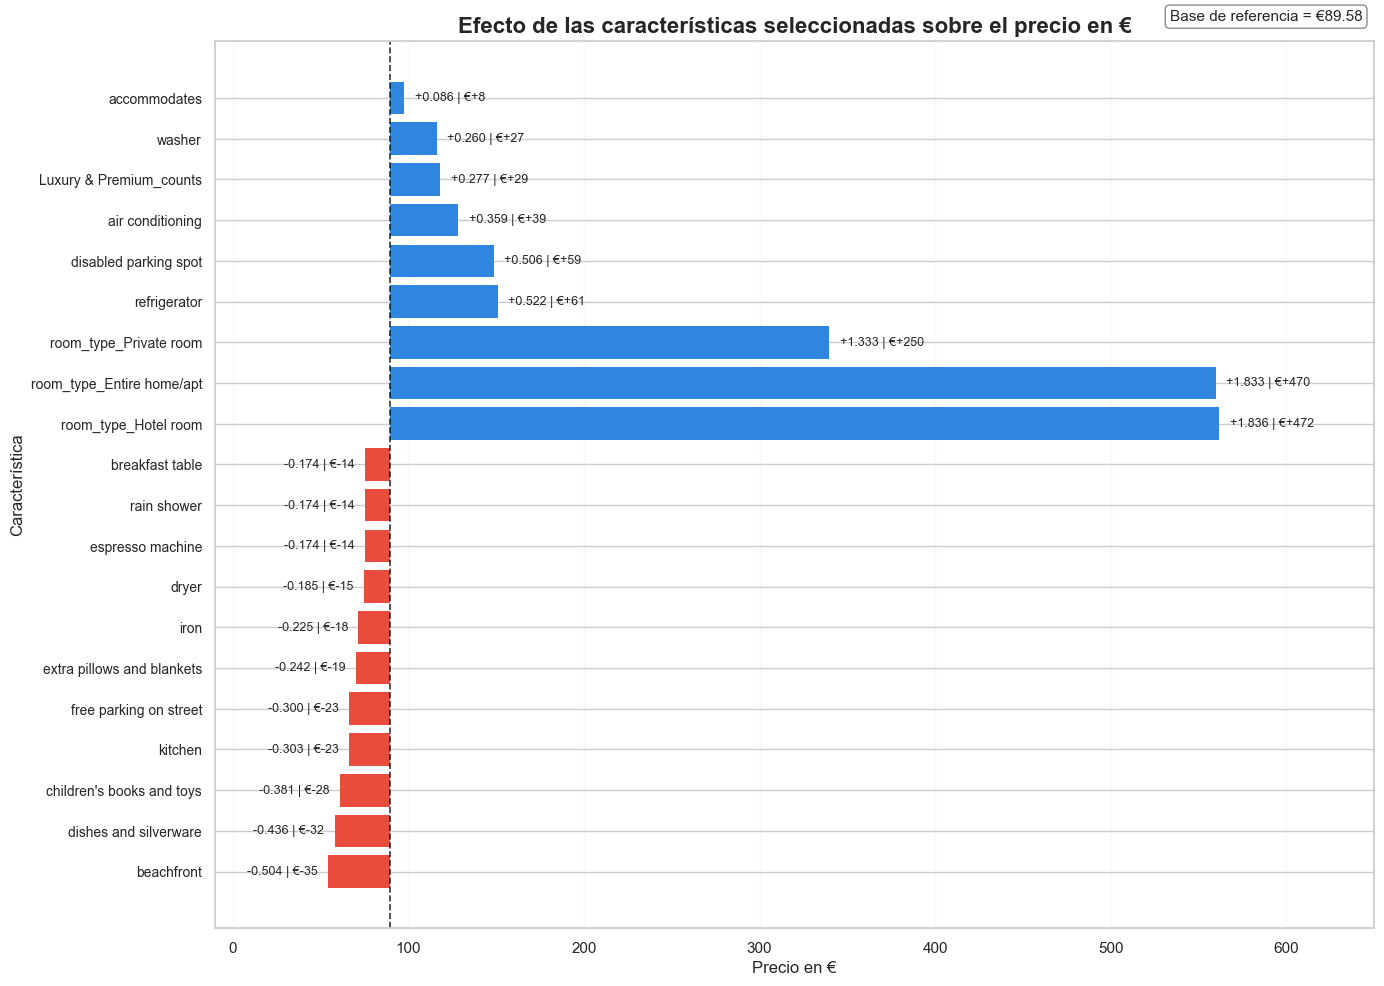

In [255]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------
# Input data
# -------------------------------------------------
data = [
    ("accommodates", 0.0856),
    ("air conditioning", 0.3590),
    ("beachfront", -0.5039),
    ("breakfast table", -0.1743),

    ("children's books and toys", -0.3811),
    ("disabled parking spot", 0.5058),
    ("dishes and silverware", -0.4359),
    ("dryer", -0.1847),
    ("espresso machine", -0.1743),
    ("extra pillows and blankets", -0.2417),
    ("free parking on street", -0.2998),
    ("iron", -0.2246),
    ("kitchen", -0.3026),
    ("rain shower", -0.1743),
    ("refrigerator", 0.5220),
    ("washer", 0.2604),
    ("Luxury & Premium_counts", 0.2773),
    ("room_type_Entire home/apt", 1.8325),
    ("room_type_Hotel room", 1.8364),
    ("room_type_Private room", 1.3332),

]

intercept = 4.4951                  
              
# -------------------------------------------------
# Data prep
# -------------------------------------------------
features_df = pd.DataFrame(data, columns=["feature", "coef"])

# Baseline price in euro from intercept
baseline_eur = np.exp(intercept)

# Euro effect of each feature relative to baseline
# Interpretation: price change in € when feature is present
features_df["euro_delta"] = baseline_eur * (np.exp(features_df["coef"]) - 1)

features_df["effect"] = np.where(features_df["euro_delta"] >= 0, "positive", "negative")
features_df["abs_euro_delta"] = features_df["euro_delta"].abs()

# Order by signed euro effect, positives first, negatives after
df_pos = features_df[features_df["euro_delta"] >= 0].sort_values("euro_delta", ascending=True)
df_neg = features_df[features_df["euro_delta"] < 0].sort_values("euro_delta", ascending=False)
plot_df = pd.concat([df_pos, df_neg], ignore_index=True)

# X positions centered on intercept in euro
plot_df["x_left"] = np.where(
    plot_df["euro_delta"] >= 0,
    baseline_eur,
    baseline_eur + plot_df["euro_delta"]
)
plot_df["bar_width"] = plot_df["euro_delta"].abs()

# Labels
plot_df["label"] = plot_df.apply(
    lambda r: f'{r["coef"]:+.3f} | €{r["euro_delta"]:+.0f}',
    axis=1
)

# Colors
colors = plot_df["euro_delta"].apply(lambda x: "#2E86DE" if x >= 0 else "#E74C3C")

# -------------------------------------------------
# Plot
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 10))

y = np.arange(len(plot_df))

ax.barh(
    y,
    plot_df["bar_width"],
    left=plot_df["x_left"],
    color=colors,
    edgecolor="none"
)

# Reference line at intercept in euro, not at zero
ax.axvline(baseline_eur, color="black", linewidth=1.2, linestyle="--", alpha=0.8)

# Y labels
ax.set_yticks(y)
ax.set_yticklabels(plot_df["feature"], fontsize=10)

# Value labels
for i, row in plot_df.iterrows():
    x_end = row["x_left"] + row["bar_width"] if row["euro_delta"] >= 0 else row["x_left"]
    if row["euro_delta"] >= 0:
        ax.text(x_end + 6, i, row["label"], va="center", ha="left", fontsize=9)
    else:
        ax.text(x_end - 6, i, row["label"], va="center", ha="right", fontsize=9)

# Title and axes
ax.set_title(
    "Efecto de las características seleccionadas sobre el precio en €",
    fontsize=16,
    weight="bold"
)
ax.set_xlabel("Precio en €")
ax.set_ylabel("Característica")

# X axis fixed range
ax.set_xlim(-10, 650)

# Intercept annotation
ax.text(
    0.99, 1.02,
    f"Base de referencia = €{baseline_eur:.2f}",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.9)
)

# Style
ax.invert_yaxis()
ax.grid(axis="x", linestyle=":", alpha=0.3)

plt.tight_layout()
plt.show()

##### **Results Sevilla ~ General**

From three modelling approaches, Ordinary Least Squares (OLS) regression demonstrated the highest r2 = 0.643213.
Based on VIF estimation, the following features had highest collinearity:
    feature	VIF
5	bedrooms	inf
31	bath towel	inf
9	bathrooms	inf
30	bathroom essentials	inf
0	accommodates	21.731371
6	air conditioning	16.317514
10	tv	13.099543
2	beds	12.208302
21	iron	11.073421
26	washer	8.768621
13	shampoo	5.141025

"accommodates", "bedrooms", "bathrooms" and "beds" represent Capacity characteristics of the accommodation, being highly colinear. It is proposed to use for further estimations **"accommodates"** only.
"bath towel", "bathroom essentials", "tv", "shampoo" may be omitted from modelling, as being colinear with another features, and estimated with p>0.05 in OLS model.
Also, features with very low effect size (coef) were omited.

Features with accepted VIF and p<0.05 were:
#--------------------------------------------------------------------------------------------------------
                                           coef    std err          t      P>|t|      [0.025      0.975]
#--------------------------------------------------------------------------------------------------------
const                                    4.4951      0.234     19.215      0.000       4.035       4.956
accommodates                             0.0856      0.034      2.543      0.012       0.019       0.152
air conditioning                         0.3590      0.137      2.624      0.009       0.090       0.628
beachfront                              -0.5039      0.237     -2.127      0.034      -0.970      -0.038
breakfast table                         -0.1743      0.087     -2.001      0.046      -0.346      -0.003
children's books and toys               -0.3811      0.170     -2.236      0.026      -0.717      -0.046
disabled parking spot                    0.5058      0.253      2.002      0.046       0.008       1.003
dishes and silverware                   -0.4359      0.186     -2.346      0.020      -0.802      -0.070
dryer                                   -0.1847      0.090     -2.044      0.042      -0.363      -0.007
espresso machine                        -0.1743      0.087     -2.001      0.046      -0.346      -0.003
extra pillows and blankets              -0.2417      0.120     -2.008      0.046      -0.479      -0.005
free parking on street                  -0.2998      0.089     -3.370      0.001      -0.475      -0.125
iron                                    -0.2246      0.107     -2.096      0.037      -0.435      -0.014
kitchen                                 -0.3026      0.145     -2.092      0.037      -0.587      -0.018
rain shower                             -0.1743      0.087     -2.001      0.046      -0.346      -0.003
refrigerator                             0.5220      0.169      3.088      0.002       0.189       0.855
washer                                   0.2604      0.100      2.613      0.009       0.064       0.457
Luxury & Premium_counts                  0.2773      0.134      2.075      0.039       0.014       0.540
room_type_Entire home/apt                1.8325      0.147     12.490      0.000       1.544       2.121
room_type_Hotel room                     1.8364      0.222      8.283      0.000       1.400       2.273
room_type_Private room                   1.3332      0.143      9.296      0.000       1.051       1.616

##### **Analysis Sevilla ~ Entire**

In [116]:
outdir = Path("output_Sevilla_Entire")
outdir.mkdir(exist_ok=True)

In [117]:
log("Starting data preparation")

price_orig = "price"
target = "price_log2"
id_cols = ["apartment_id", "host_id", "insert_date"]
location = ["city", "neighbourhood_district", "neighbourhood_name"]
df_model = df[(df["city"] == 'sevilla') & (df["room_type"] == "Entire home/apt")].copy()

X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
y = df_model[target].astype(float)

list_cols = [c for c in X.columns if X[c].apply(lambda v: isinstance(v, list)).any()]
if list_cols:
    log(f"Dropping list-valued columns: {list_cols}")
    X = X.drop(columns=list_cols)

num_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

X[num_cols] = X[num_cols].apply(lambda s: s.astype(float) if s.dtype == "bool" else s)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")
log(f"Numeric cols: {len(num_cols)}, Categorical cols: {len(cat_cols)}")

[13:08:30] Starting data preparation
[13:08:31] Train rows: 247, Test rows: 62
[13:08:31] Numeric cols: 250, Categorical cols: 1


In [118]:
log("Building preprocessors")

preprocess_rf = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

preprocess_enet = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

log("Preprocessors ready")

[13:08:31] Building preprocessors
[13:08:31] Preprocessors ready


In [119]:
log("Fitting Random Forest")

rf = Pipeline(steps=[
    ("preprocess", preprocess_rf),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        max_depth=12,
        min_samples_leaf=5,
        max_features="sqrt"
    ))
])

t0 = time.time()
rf.fit(X_train, y_train)
log(f"Random Forest fit completed in {time.time() - t0:.1f}s")

rf_pred = rf.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
log(f"RF test RMSE={rf_rmse:.4f}, R2={rf_r2:.4f}")

[13:08:31] Fitting Random Forest
[13:08:32] Random Forest fit completed in 1.1s
[13:08:32] RF test RMSE=0.6566, R2=0.2459


In [120]:
log("Computing permutation importance")

X_test_trans = rf.named_steps["preprocess"].transform(X_test)
feature_names = rf.named_steps["preprocess"].get_feature_names_out()

t0 = time.time()
perm = permutation_importance(
    rf.named_steps["model"],
    X_test_trans,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)
log(f"Permutation importance completed in {time.time() - t0:.1f}s")

rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

rf_importance.to_csv(outdir / "rf_permutation_importance.csv", index=False)
log("Saved RF importance to output/rf_permutation_importance.csv")

display(rf_importance.head(20))

[13:08:32] Computing permutation importance
[13:09:47] Permutation importance completed in 74.3s
[13:09:47] Saved RF importance to output/rf_permutation_importance.csv


,feature,importance_mean,importance_std
0,accommodates,0.055437,0.013802
1,bathrooms,0.049020,0.014313
89,free parking on street,0.034979,0.010390
2,bedrooms,0.028580,0.010740
3,beds,0.017373,0.014125
107,high chair,0.016196,0.005195
246,Parking & Transport_counts,0.010833,0.002547
101,hangers,0.008436,0.002293
33,buzzer wireless intercom,0.006116,0.003627
164,refrigerator,0.005733,0.004591


In [121]:
log("Fitting Elastic Net")

enet_pipe = Pipeline(steps=[
    ("preprocess", preprocess_enet),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9],
        alphas=np.logspace(-4, 1, 30),
        cv=5,
        random_state=42,
        max_iter=10000
    ))
])

t0 = time.time()
enet_pipe.fit(X_train, y_train)
log(f"Elastic Net fit completed in {time.time() - t0:.1f}s")

enet = enet_pipe.named_steps["model"]
enet_pred = enet_pipe.predict(X_test)
enet_rmse = np.sqrt(mean_squared_error(y_test, enet_pred))

enet_r2 = r2_score(y_test, enet_pred)

enet_features = enet_pipe.named_steps["preprocess"].get_feature_names_out()
enet_coefs = pd.DataFrame({
    "feature": enet_features,
    "coef": enet.coef_
})
enet_coefs["abs_coef"] = enet_coefs["coef"].abs()
enet_selected = enet_coefs[enet_coefs["coef"] != 0].sort_values("abs_coef", ascending=False)

enet_coefs.to_csv(outdir / "elastic_net_coefficients.csv", index=False)
log("Saved Elastic Net coefficients to output/elastic_net_coefficients.csv")

log(f"Elastic Net chosen alpha={enet.alpha_:.6f}, l1_ratio={enet.l1_ratio_}")
log(f"EN test RMSE={enet_rmse:.4f}, R2={enet_r2:.4f}")

display(enet_selected.head(30))

[13:09:47] Fitting Elastic Net
[13:10:30] Elastic Net fit completed in 42.4s
[13:10:30] Saved Elastic Net coefficients to output/elastic_net_coefficients.csv
[13:10:30] Elastic Net chosen alpha=0.417532, l1_ratio=0.1
[13:10:30] EN test RMSE=0.6241, R2=0.3187


,feature,coef,abs_coef
0,accommodates,0.097007,0.097007
89,free parking on street,-0.096670,0.096670
1,bathrooms,0.072424,0.072424
2,bedrooms,0.072423,0.072423
51,crib,0.064942,0.064942
213,wide entrance,-0.041879,0.041879
107,high chair,0.040675,0.040675
63,dryer,-0.040551,0.040551
50,cooking basics,-0.040546,0.040546
3,beds,0.039387,0.039387


In [122]:
log("Preparing VIF check")

top_rf = rf_importance["feature"].head(25).tolist()
top_en = enet_selected["feature"].head(25).tolist()

candidate_features = list(dict.fromkeys(top_rf + top_en))
log(f"Initial candidate features from RF + EN: {len(candidate_features)}")

base_cols = []
for f in candidate_features:
    base = f.split("_")[0] if "_" in f else f
    if base in X_train.columns:
        base_cols.append(base)

base_cols = list(dict.fromkeys(base_cols))
log(f"Base columns kept for VIF: {base_cols}")

X_vif = X_train[base_cols].copy()
X_vif = pd.get_dummies(X_vif, drop_first=True)

for c in X_vif.columns:
    if X_vif[c].dtype == "bool":
        X_vif[c] = X_vif[c].astype(int)

X_vif = X_vif.fillna(X_vif.median(numeric_only=True))

log(f"VIF matrix shape: {X_vif.shape}")

vif_data = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

vif_data.to_csv(outdir / "vif_results.csv", index=False)
log("Saved VIF results to output/vif_results.csv")

display(vif_data.head(30))

[13:10:30] Preparing VIF check
[13:10:30] Initial candidate features from RF + EN: 37
[13:10:30] Base columns kept for VIF: ['accommodates', 'bathrooms', 'free parking on street', 'bedrooms', 'beds', 'high chair', 'hangers', 'buzzer wireless intercom', 'refrigerator', 'cooking basics', 'bed linens', 'oven', 'crib', 'carbon monoxide alarm', 'fire extinguisher', 'breakfast', 'dishwasher', 'pool', 'wide entrance', 'dryer', 'keypad', 'lockbox', 'full kitchen', 'dishes and silverware', 'wide doorway to guest bathroom', 'extra pillows and blankets', 'other']
[13:10:30] VIF matrix shape: (247, 27)
[13:10:30] Saved VIF results to output/vif_results.csv


,feature,VIF
1,bathrooms,inf
3,bedrooms,inf
8,refrigerator,24.158540
0,accommodates,24.149494
23,dishes and silverware,23.809325
9,cooking basics,14.185532
4,beds,12.464170
6,hangers,9.704550
10,bed linens,5.953826
25,extra pillows and blankets,3.457662


In [123]:
log("Fitting Gamma GLM with log link")

glm_X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
glm_list_cols = [c for c in glm_X.columns if glm_X[c].apply(lambda v: isinstance(v, list)).any()]
if glm_list_cols:
    log(f"Dropping list-valued columns from GLM: {glm_list_cols}")
    glm_X = glm_X.drop(columns=glm_list_cols)

glm_num_cols = glm_X.select_dtypes(include=["number", "bool"]).columns.tolist()
glm_cat_cols = glm_X.select_dtypes(include=["object", "category"]).columns.tolist()

glm_preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), glm_num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), glm_cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

t0 = time.time()
X_glm = glm_preprocess.fit_transform(glm_X)
log(f"GLM preprocessing completed in {time.time() - t0:.1f}s")

glm_feature_names = glm_preprocess.get_feature_names_out()
X_glm_df = pd.DataFrame(X_glm, columns=glm_feature_names, index=df_model.index)
X_glm_df = sm.add_constant(X_glm_df, has_constant="add")

y_glm = df_model[target].astype(float)

t0 = time.time()
gamma_model = sm.GLM(
    y_glm,
    X_glm_df,
    family=sm.families.Gamma(link=sm.families.links.log())
).fit()
log(f"Gamma GLM fit completed in {time.time() - t0:.1f}s")

with open(outdir / "gamma_glm_summary.txt", "w", encoding="utf-8") as f:
    f.write(gamma_model.summary().as_text())

log("Saved Gamma GLM summary to output/gamma_glm_summary.txt")
print(gamma_model.summary())

[13:10:30] Fitting Gamma GLM with log link
[13:10:31] GLM preprocessing completed in 0.0s
[13:10:34] Gamma GLM fit completed in 3.2s
[13:10:34] Saved Gamma GLM summary to output/gamma_glm_summary.txt
                 Generalized Linear Model Regression Results                  
Dep. Variable:             price_log2   No. Observations:                  309
Model:                            GLM   Df Residuals:                      173
Model Family:                   Gamma   Df Model:                          135
Link Function:                    log   Scale:                       0.0043028
Method:                          IRLS   Log-Likelihood:                -229.97
Date:                Sun, 07 Jun 2026   Deviance:                      0.72855
Time:                        13:10:34   Pearson chi2:                    0.744
No. Iterations:                   100   Pseudo R-squ. (CS):             0.6317
Covariance Type:            nonrobust                                         
          

In [124]:
log("Fitting OLS on log(price)")

if "price" in df_model.columns:
    y_lin = np.log(df_model["price"].astype(float))
    X_lin = X_glm_df.copy()

    t0 = time.time()
    lin_model = sm.OLS(y_lin, X_lin).fit()
    log(f"OLS fit completed in {time.time() - t0:.1f}s")

    with open(outdir / "ols_logprice_summary.txt", "w", encoding="utf-8") as f:
        f.write(lin_model.summary().as_text())

    log("Saved OLS summary to output/ols_logprice_summary.txt")
    print(lin_model.summary())
else:
    lin_model = None
    log("No raw price column found; skipping OLS on log(price)")

[13:10:34] Fitting OLS on log(price)
[13:10:35] OLS fit completed in 0.2s
[13:10:35] Saved OLS summary to output/ols_logprice_summary.txt
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.634
Model:                            OLS   Adj. R-squared:                  0.349
Method:                 Least Squares   F-statistic:                     2.221
Date:                Sun, 07 Jun 2026   Prob (F-statistic):           4.17e-07
Time:                        13:10:35   Log-Likelihood:                -105.31
No. Observations:                 309   AIC:                             482.6
Df Residuals:                     173   BIC:                             990.3
Df Model:                         135                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t   

In [125]:
log("Building comparison table")

results = pd.DataFrame([
    {"model": "Random Forest", "rmse": rf_rmse, "r2": rf_r2},
    {"model": "Elastic Net", "rmse": enet_rmse, "r2": enet_r2},
])

if lin_model is not None:
    results = pd.concat([
        results,
        pd.DataFrame([{
            "model": "OLS log(price)",
            "rmse": np.nan,
            "r2": lin_model.rsquared
        }])
    ], ignore_index=True)

results.to_csv(outdir / "model_comparison.csv", index=False)
log("Saved comparison table to output/model_comparison.csv")
display(results)

[13:10:36] Building comparison table
[13:10:36] Saved comparison table to output/model_comparison.csv


,model,rmse,r2
0,Random Forest,0.656564,0.245889
1,Elastic Net,0.624083,0.318657
2,OLS log(price),NaN,0.634091


##### **Results Sevilla ~ Entire**

##### **Analysis Sevilla ~ Private room**

In [126]:
outdir = Path("output_Sevilla_Private")
outdir.mkdir(exist_ok=True)

In [127]:
log("Starting data preparation")

price_orig = "price"
target = "price_log2"
id_cols = ["apartment_id", "host_id", "insert_date"]
location = ["city", "neighbourhood_district", "neighbourhood_name"]
df_model = df[(df["city"] == 'sevilla') & (df["room_type"] == "Private room")].copy()

X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
y = df_model[target].astype(float)

list_cols = [c for c in X.columns if X[c].apply(lambda v: isinstance(v, list)).any()]
if list_cols:
    log(f"Dropping list-valued columns: {list_cols}")
    X = X.drop(columns=list_cols)

num_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

X[num_cols] = X[num_cols].apply(lambda s: s.astype(float) if s.dtype == "bool" else s)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")
log(f"Numeric cols: {len(num_cols)}, Categorical cols: {len(cat_cols)}")

[13:10:36] Starting data preparation
[13:10:36] Train rows: 67, Test rows: 17
[13:10:36] Numeric cols: 250, Categorical cols: 1


In [128]:
log("Building preprocessors")

preprocess_rf = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

preprocess_enet = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

log("Preprocessors ready")

[13:10:36] Building preprocessors
[13:10:36] Preprocessors ready


In [129]:
log("Fitting Random Forest")

rf = Pipeline(steps=[
    ("preprocess", preprocess_rf),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        max_depth=12,
        min_samples_leaf=5,
        max_features="sqrt"
    ))
])

t0 = time.time()
rf.fit(X_train, y_train)
log(f"Random Forest fit completed in {time.time() - t0:.1f}s")

rf_pred = rf.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
log(f"RF test RMSE={rf_rmse:.4f}, R2={rf_r2:.4f}")

[13:10:36] Fitting Random Forest


[13:10:37] Random Forest fit completed in 0.8s
[13:10:37] RF test RMSE=0.8735, R2=0.0951


In [130]:
log("Computing permutation importance")

X_test_trans = rf.named_steps["preprocess"].transform(X_test)
feature_names = rf.named_steps["preprocess"].get_feature_names_out()

t0 = time.time()
perm = permutation_importance(
    rf.named_steps["model"],
    X_test_trans,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)
log(f"Permutation importance completed in {time.time() - t0:.1f}s")

rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

rf_importance.to_csv(outdir / "rf_permutation_importance.csv", index=False)
log("Saved RF importance to output/rf_permutation_importance.csv")

display(rf_importance.head(20))

[13:10:37] Computing permutation importance
[13:11:27] Permutation importance completed in 49.9s
[13:11:27] Saved RF importance to output/rf_permutation_importance.csv


,feature,importance_mean,importance_std
171,shampoo,0.039467,0.032356
7,air conditioning,0.018919,0.007239
239,Family & Pets_counts,0.018587,0.005511
0,accommodates,0.012945,0.018349
224,Family & Pets_name,0.011736,0.003889
120,laptop friendly workspace,0.009958,0.007914
117,kitchen,0.008105,0.014347
247,Safety & Security_counts,0.008067,0.003917
24,bed linens,0.007258,0.002038
98,hair dryer,0.006971,0.013668


In [131]:
log("Fitting Elastic Net")

enet_pipe = Pipeline(steps=[
    ("preprocess", preprocess_enet),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9],
        alphas=np.logspace(-4, 1, 30),
        cv=5,
        random_state=42,
        max_iter=10000
    ))
])

t0 = time.time()
enet_pipe.fit(X_train, y_train)
log(f"Elastic Net fit completed in {time.time() - t0:.1f}s")

enet = enet_pipe.named_steps["model"]
enet_pred = enet_pipe.predict(X_test)
enet_rmse = np.sqrt(mean_squared_error(y_test, enet_pred))

enet_r2 = r2_score(y_test, enet_pred)

enet_features = enet_pipe.named_steps["preprocess"].get_feature_names_out()
enet_coefs = pd.DataFrame({
    "feature": enet_features,
    "coef": enet.coef_
})
enet_coefs["abs_coef"] = enet_coefs["coef"].abs()
enet_selected = enet_coefs[enet_coefs["coef"] != 0].sort_values("abs_coef", ascending=False)

enet_coefs.to_csv(outdir / "elastic_net_coefficients.csv", index=False)
log("Saved Elastic Net coefficients to output/elastic_net_coefficients.csv")

log(f"Elastic Net chosen alpha={enet.alpha_:.6f}, l1_ratio={enet.l1_ratio_}")
log(f"EN test RMSE={enet_rmse:.4f}, R2={enet_r2:.4f}")

display(enet_selected.head(30))

[13:11:27] Fitting Elastic Net
[13:11:32] Elastic Net fit completed in 4.1s
[13:11:32] Saved Elastic Net coefficients to output/elastic_net_coefficients.csv
[13:11:32] Elastic Net chosen alpha=0.126896, l1_ratio=0.9
[13:11:32] EN test RMSE=0.8528, R2=0.1376


,feature,coef,abs_coef
226,Kitchen & Dining_name,-0.406108,0.406108
7,air conditioning,0.210520,0.210520
114,iron,-0.165405,0.165405
154,pool,0.145037,0.145037
182,smoking allowed,-0.116148,0.116148
208,wide clearance to bed,0.111855,0.111855
60,doorman,-0.094480,0.094480
227,Laundry & Housekeeping_name,0.077880,0.077880
0,accommodates,0.072033,0.072033
98,hair dryer,-0.067110,0.067110


In [132]:
log("Preparing VIF check")

top_rf = rf_importance["feature"].head(25).tolist()
top_en = enet_selected["feature"].head(25).tolist()

candidate_features = list(dict.fromkeys(top_rf + top_en))
log(f"Initial candidate features from RF + EN: {len(candidate_features)}")

base_cols = []
for f in candidate_features:
    base = f.split("_")[0] if "_" in f else f
    if base in X_train.columns:
        base_cols.append(base)

base_cols = list(dict.fromkeys(base_cols))
log(f"Base columns kept for VIF: {base_cols}")

X_vif = X_train[base_cols].copy()
X_vif = pd.get_dummies(X_vif, drop_first=True)

for c in X_vif.columns:
    if X_vif[c].dtype == "bool":
        X_vif[c] = X_vif[c].astype(int)

X_vif = X_vif.fillna(X_vif.median(numeric_only=True))

log(f"VIF matrix shape: {X_vif.shape}")

vif_data = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

vif_data.to_csv(outdir / "vif_results.csv", index=False)
log("Saved VIF results to output/vif_results.csv")

display(vif_data.head(30))

[13:11:32] Preparing VIF check
[13:11:32] Initial candidate features from RF + EN: 38
[13:11:32] Base columns kept for VIF: ['shampoo', 'air conditioning', 'accommodates', 'laptop friendly workspace', 'kitchen', 'bed linens', 'hair dryer', 'family kid friendly', 'free parking on street', 'hot water', 'beds', 'host greets you', 'paid parking off premises', 'dryer', 'paid parking on premises', 'washer', 'iron', 'pool', 'smoking allowed', 'wide clearance to bed', 'doorman', 'hangers', 'essentials', 'bathtub with bath chair', 'baby bath', 'bbq grill']
[13:11:32] VIF matrix shape: (67, 26)
[13:11:32] Saved VIF results to output/vif_results.csv


,feature,VIF
23,bathtub with bath chair,inf
25,bbq grill,inf
24,baby bath,inf
21,hangers,49.524519
22,essentials,48.944076
2,accommodates,19.586068
10,beds,15.241966
16,iron,12.363494
9,hot water,10.818865
6,hair dryer,10.331585


In [133]:
log("Fitting Gamma GLM with log link")

glm_X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
glm_list_cols = [c for c in glm_X.columns if glm_X[c].apply(lambda v: isinstance(v, list)).any()]
if glm_list_cols:
    log(f"Dropping list-valued columns from GLM: {glm_list_cols}")
    glm_X = glm_X.drop(columns=glm_list_cols)

glm_num_cols = glm_X.select_dtypes(include=["number", "bool"]).columns.tolist()
glm_cat_cols = glm_X.select_dtypes(include=["object", "category"]).columns.tolist()

glm_preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), glm_num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), glm_cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

t0 = time.time()
X_glm = glm_preprocess.fit_transform(glm_X)
log(f"GLM preprocessing completed in {time.time() - t0:.1f}s")

glm_feature_names = glm_preprocess.get_feature_names_out()
X_glm_df = pd.DataFrame(X_glm, columns=glm_feature_names, index=df_model.index)
X_glm_df = sm.add_constant(X_glm_df, has_constant="add")

y_glm = df_model[target].astype(float)

t0 = time.time()
gamma_model = sm.GLM(
    y_glm,
    X_glm_df,
    family=sm.families.Gamma(link=sm.families.links.log())
).fit()
log(f"Gamma GLM fit completed in {time.time() - t0:.1f}s")

with open(outdir / "gamma_glm_summary.txt", "w", encoding="utf-8") as f:
    f.write(gamma_model.summary().as_text())

log("Saved Gamma GLM summary to output/gamma_glm_summary.txt")
print(gamma_model.summary())

[13:11:32] Fitting Gamma GLM with log link
[13:11:32] GLM preprocessing completed in 0.1s
[13:11:33] Gamma GLM fit completed in 0.0s
[13:11:33] Saved Gamma GLM summary to output/gamma_glm_summary.txt
                 Generalized Linear Model Regression Results                  
Dep. Variable:             price_log2   No. Observations:                   84
Model:                            GLM   Df Residuals:                        0
Model Family:                   Gamma   Df Model:                           83
Link Function:                    log   Scale:                             inf
Method:                          IRLS   Log-Likelihood:                    nan
Date:                Sun, 07 Jun 2026   Deviance:                   0.00084448
Time:                        13:11:33   Pearson chi2:                 0.000838
No. Iterations:                     1   Pseudo R-squ. (CS):                nan
Covariance Type:            nonrobust                                         
          

In [134]:
log("Fitting OLS on log(price)")

if "price" in df_model.columns:
    y_lin = np.log(df_model["price"].astype(float))
    X_lin = X_glm_df.copy()

    t0 = time.time()
    lin_model = sm.OLS(y_lin, X_lin).fit()
    log(f"OLS fit completed in {time.time() - t0:.1f}s")

    with open(outdir / "ols_logprice_summary.txt", "w", encoding="utf-8") as f:
        f.write(lin_model.summary().as_text())

    log("Saved OLS summary to output/ols_logprice_summary.txt")
    print(lin_model.summary())
else:
    lin_model = None
    log("No raw price column found; skipping OLS on log(price)")

[13:11:33] Fitting OLS on log(price)
[13:11:33] OLS fit completed in 0.5s
[13:11:34] Saved OLS summary to output/ols_logprice_summary.txt
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Sun, 07 Jun 2026   Prob (F-statistic):                nan
Time:                        13:11:34   Log-Likelihood:                 2535.4
No. Observations:                  84   AIC:                            -4903.
Df Residuals:                       0   BIC:                            -4699.
Df Model:                          83                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t   

In [135]:
log("Building comparison table")

results = pd.DataFrame([
    {"model": "Random Forest", "rmse": rf_rmse, "r2": rf_r2},
    {"model": "Elastic Net", "rmse": enet_rmse, "r2": enet_r2},
])

if lin_model is not None:
    results = pd.concat([
        results,
        pd.DataFrame([{
            "model": "OLS log(price)",
            "rmse": np.nan,
            "r2": lin_model.rsquared
        }])
    ], ignore_index=True)

results.to_csv(outdir / "model_comparison.csv", index=False)
log("Saved comparison table to output/model_comparison.csv")
display(results)

[13:11:34] Building comparison table
[13:11:34] Saved comparison table to output/model_comparison.csv


,model,rmse,r2
0,Random Forest,0.873540,0.095128
1,Elastic Net,0.852782,0.137622
2,OLS log(price),NaN,1.000000


##### **Results Sevilla ~ Private room**
- Not sufficient data for modelling

##### **Analysis Sevilla ~ Hotel room**

In [136]:
outdir = Path("output_Sevilla_Hotel")
outdir.mkdir(exist_ok=True)

In [137]:
log("Starting data preparation")

price_orig = "price"
target = "price_log2"
id_cols = ["apartment_id", "host_id", "insert_date"]
location = ["city", "neighbourhood_district", "neighbourhood_name"]
df_model = df[(df["city"] == 'sevilla') & (df["room_type"] == "Hotel room")].copy()

X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
y = df_model[target].astype(float)

list_cols = [c for c in X.columns if X[c].apply(lambda v: isinstance(v, list)).any()]
if list_cols:
    log(f"Dropping list-valued columns: {list_cols}")
    X = X.drop(columns=list_cols)

num_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

X[num_cols] = X[num_cols].apply(lambda s: s.astype(float) if s.dtype == "bool" else s)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")
log(f"Numeric cols: {len(num_cols)}, Categorical cols: {len(cat_cols)}")

[13:11:34] Starting data preparation
[13:11:34] Train rows: 7, Test rows: 2
[13:11:34] Numeric cols: 250, Categorical cols: 1


##### **Results Sevilla ~ Hotel room**
- Very few data for analysis

##### **Analysis Sevilla ~ Shared room**

In [138]:
outdir = Path("output_Sevilla_Shared")
outdir.mkdir(exist_ok=True)

In [ ]:
log("Starting data preparation")

price_orig = "price"
target = "price_log2"
id_cols = ["apartment_id", "host_id", "insert_date"]
location = ["city", "neighbourhood_district", "neighbourhood_name"]
df_model = df[(df["city"] == 'sevilla') & (df["room_type"] == "Shared room")].copy()

X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
y = df_model[target].astype(float)

list_cols = [c for c in X.columns if X[c].apply(lambda v: isinstance(v, list)).any()]
if list_cols:
    log(f"Dropping list-valued columns: {list_cols}")
    X = X.drop(columns=list_cols)

num_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

X[num_cols] = X[num_cols].apply(lambda s: s.astype(float) if s.dtype == "bool" else s)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")
log(f"Numeric cols: {len(num_cols)}, Categorical cols: {len(cat_cols)}")

##### **Results Sevilla ~ Shared room**
- Only 1 value, not possible to perform the analysis

#### **MALAGA**

##### **Analysis Malaga ~ General**

In [256]:
outdir = Path("output_Malaga_general")
outdir.mkdir(exist_ok=True)

In [257]:
log("Starting data preparation")

price_orig = "price"
target = "price_log2"
id_cols = ["apartment_id", "host_id", "insert_date"]
location = ["city", "neighbourhood_district", "neighbourhood_name"]
df_model = df[df["city"] == 'malaga'].copy()

X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
y = df_model[target].astype(float)

list_cols = [c for c in X.columns if X[c].apply(lambda v: isinstance(v, list)).any()]
if list_cols:
    log(f"Dropping list-valued columns: {list_cols}")
    X = X.drop(columns=list_cols)

num_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

X[num_cols] = X[num_cols].apply(lambda s: s.astype(float) if s.dtype == "bool" else s)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")
log(f"Numeric cols: {len(num_cols)}, Categorical cols: {len(cat_cols)}")

[18:40:58] Starting data preparation
[18:40:59] Dropping list-valued columns: ['Accessibility_name', 'Digital/Tech_name', 'Entertainment & Media_name', 'Family & Pets_name', 'In-Room Essentials & Comfort_name', 'Kitchen & Dining_name', 'Laundry & Housekeeping_name', 'Luxury & Premium_name', 'Other_name', 'Outdoor & Views_name', 'Parking & Transport_name', 'Safety & Security_name', 'Service & Operations_name', 'Wellness & Recreation_name']
[18:41:00] Train rows: 314, Test rows: 79
[18:41:00] Numeric cols: 235, Categorical cols: 2


In [258]:
log("Building preprocessors")

preprocess_rf = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

preprocess_enet = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

log("Preprocessors ready")

[18:41:23] Building preprocessors
[18:41:23] Preprocessors ready


In [259]:
log("Fitting Random Forest")

rf = Pipeline(steps=[
    ("preprocess", preprocess_rf),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        max_depth=12,
        min_samples_leaf=5,
        max_features="sqrt"
    ))
])

t0 = time.time()
rf.fit(X_train, y_train)
log(f"Random Forest fit completed in {time.time() - t0:.1f}s")

rf_pred = rf.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
log(f"RF test RMSE={rf_rmse:.4f}, R2={rf_r2:.4f}")

[18:41:40] Fitting Random Forest
[18:41:43] Random Forest fit completed in 2.8s
[18:41:46] RF test RMSE=0.6866, R2=0.4073


In [260]:
log("Computing permutation importance")

X_test_trans = rf.named_steps["preprocess"].transform(X_test)
feature_names = rf.named_steps["preprocess"].get_feature_names_out()

t0 = time.time()
perm = permutation_importance(
    rf.named_steps["model"],
    X_test_trans,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)
log(f"Permutation importance completed in {time.time() - t0:.1f}s")

rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

rf_importance.to_csv(outdir / "rf_permutation_importance.csv", index=False)
log("Saved RF importance to output/rf_permutation_importance.csv")

display(rf_importance.head(20))

[18:42:03] Computing permutation importance
[18:44:36] Permutation importance completed in 152.2s
[18:44:36] Saved RF importance to output/rf_permutation_importance.csv


,feature,importance_mean,importance_std
235,room_type_Entire home/apt,0.058927,0.022572
3,beds,0.056992,0.007436
237,room_type_Private room,0.046194,0.015452
0,accommodates,0.041815,0.014163
2,bedrooms,0.016673,0.005989
1,bathrooms,0.013270,0.003953
122,lock on bedroom door,0.010234,0.007091
7,air conditioning,0.010135,0.007786
224,Family & Pets_counts,0.007828,0.003836
110,hot water,0.005865,0.002319


In [261]:
log("Fitting Elastic Net")

enet_pipe = Pipeline(steps=[
    ("preprocess", preprocess_enet),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9],
        alphas=np.logspace(-4, 1, 30),
        cv=5,
        random_state=42,
        max_iter=10000
    ))
])

t0 = time.time()
enet_pipe.fit(X_train, y_train)
log(f"Elastic Net fit completed in {time.time() - t0:.1f}s")

enet = enet_pipe.named_steps["model"]
enet_pred = enet_pipe.predict(X_test)
enet_rmse = np.sqrt(mean_squared_error(y_test, enet_pred))

enet_r2 = r2_score(y_test, enet_pred)

enet_features = enet_pipe.named_steps["preprocess"].get_feature_names_out()
enet_coefs = pd.DataFrame({
    "feature": enet_features,
    "coef": enet.coef_
})
enet_coefs["abs_coef"] = enet_coefs["coef"].abs()
enet_selected = enet_coefs[enet_coefs["coef"] != 0].sort_values("abs_coef", ascending=False)

enet_coefs.to_csv(outdir / "elastic_net_coefficients.csv", index=False)
log("Saved Elastic Net coefficients to output/elastic_net_coefficients.csv")

log(f"Elastic Net chosen alpha={enet.alpha_:.6f}, l1_ratio={enet.l1_ratio_}")
log(f"EN test RMSE={enet_rmse:.4f}, R2={enet_r2:.4f}")

display(enet_selected.head(30))

[18:49:26] Fitting Elastic Net
[18:49:37] Elastic Net fit completed in 11.3s
[18:49:37] Saved Elastic Net coefficients to output/elastic_net_coefficients.csv
[18:49:37] Elastic Net chosen alpha=0.038566, l1_ratio=0.9
[18:49:37] EN test RMSE=0.6469, R2=0.4739


,feature,coef,abs_coef
235,room_type_Entire home/apt,0.458343,0.458343
0,accommodates,0.202014,0.202014
110,hot water,-0.095128,0.095128
7,air conditioning,0.082328,0.082328
122,lock on bedroom door,-0.077463,0.077463
78,family kid friendly,0.066922,0.066922
98,hair dryer,0.066213,0.066213
109,hot tub,0.061519,0.061519
170,self check in,0.054426,0.054426
23,beachfront,0.054135,0.054135


In [262]:
log("Preparing VIF check")

top_rf = rf_importance["feature"].head(25).tolist()
top_en = enet_selected["feature"].head(25).tolist()

candidate_features = list(dict.fromkeys(top_rf + top_en))
log(f"Initial candidate features from RF + EN: {len(candidate_features)}")

base_cols = []
for f in candidate_features:
    base = f.split("_")[0] if "_" in f else f
    if base in X_train.columns:
        base_cols.append(base)

base_cols = list(dict.fromkeys(base_cols))
log(f"Base columns kept for VIF: {base_cols}")

X_vif = X_train[base_cols].copy()
X_vif = pd.get_dummies(X_vif, drop_first=True)

for c in X_vif.columns:
    if X_vif[c].dtype == "bool":
        X_vif[c] = X_vif[c].astype(int)

X_vif = X_vif.fillna(X_vif.median(numeric_only=True))

log(f"VIF matrix shape: {X_vif.shape}")

vif_data = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

vif_data.to_csv(outdir / "vif_results.csv", index=False)
log("Saved VIF results to output/vif_results.csv")

display(vif_data.head(30))

[18:49:41] Preparing VIF check
[18:49:41] Initial candidate features from RF + EN: 38
[18:49:41] Base columns kept for VIF: ['beds', 'accommodates', 'bedrooms', 'bathrooms', 'lock on bedroom door', 'air conditioning', 'hot water', 'family kid friendly', 'dryer', 'tv', 'crib', 'extra pillows and blankets', 'pool', 'long term stays allowed', 'oven', 'hair dryer', 'dedicated workspace', 'wide doorway', 'cable tv', 'hot tub', 'self check in', 'beachfront', 'private living room', 'buzzer wireless intercom', 'safety card', 'garden or backyard', 'free parking on premises', 'freezer', 'essentials', 'accessible-height toilet', 'toilet', 'pets allowed']
[18:49:41] VIF matrix shape: (314, 32)
[18:49:41] Saved VIF results to output/vif_results.csv


,feature,VIF
3,bathrooms,inf
2,bedrooms,inf
1,accommodates,19.796595
28,essentials,14.316746
0,beds,13.629870
9,tv,12.362035
15,hair dryer,7.527268
5,air conditioning,6.348658
6,hot water,4.876040
13,long term stays allowed,2.820848


In [263]:
log("Fitting Gamma GLM with log link")

glm_X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
glm_list_cols = [c for c in glm_X.columns if glm_X[c].apply(lambda v: isinstance(v, list)).any()]
if glm_list_cols:
    log(f"Dropping list-valued columns from GLM: {glm_list_cols}")
    glm_X = glm_X.drop(columns=glm_list_cols)

glm_num_cols = glm_X.select_dtypes(include=["number", "bool"]).columns.tolist()
glm_cat_cols = glm_X.select_dtypes(include=["object", "category"]).columns.tolist()

glm_preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), glm_num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), glm_cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

t0 = time.time()
X_glm = glm_preprocess.fit_transform(glm_X)
log(f"GLM preprocessing completed in {time.time() - t0:.1f}s")

glm_feature_names = glm_preprocess.get_feature_names_out()
X_glm_df = pd.DataFrame(X_glm, columns=glm_feature_names, index=df_model.index)
X_glm_df = sm.add_constant(X_glm_df, has_constant="add")

y_glm = df_model[target].astype(float)

t0 = time.time()
gamma_model = sm.GLM(
    y_glm,
    X_glm_df,
    family=sm.families.Gamma(link=sm.families.links.log())
).fit()
log(f"Gamma GLM fit completed in {time.time() - t0:.1f}s")

with open(outdir / "gamma_glm_summary.txt", "w", encoding="utf-8") as f:
    f.write(gamma_model.summary().as_text())

log("Saved Gamma GLM summary to output/gamma_glm_summary.txt")
print(gamma_model.summary())

[18:50:07] Fitting Gamma GLM with log link
[18:50:07] Dropping list-valued columns from GLM: ['Accessibility_name', 'Digital/Tech_name', 'Entertainment & Media_name', 'Family & Pets_name', 'In-Room Essentials & Comfort_name', 'Kitchen & Dining_name', 'Laundry & Housekeeping_name', 'Luxury & Premium_name', 'Other_name', 'Outdoor & Views_name', 'Parking & Transport_name', 'Safety & Security_name', 'Service & Operations_name', 'Wellness & Recreation_name']
[18:50:07] GLM preprocessing completed in 0.1s
[18:50:07] Gamma GLM fit completed in 0.3s
[18:50:08] Saved Gamma GLM summary to output/gamma_glm_summary.txt
                 Generalized Linear Model Regression Results                  
Dep. Variable:             price_log2   No. Observations:                  393
Model:                            GLM   Df Residuals:                      245
Model Family:                   Gamma   Df Model:                          147
Link Function:                    log   Scale:                       

In [264]:
log("Fitting OLS on log(price)")

if "price" in df_model.columns:
    y_lin = np.log(df_model["price"].astype(float))
    X_lin = X_glm_df.copy()

    t0 = time.time()
    lin_model = sm.OLS(y_lin, X_lin).fit()
    log(f"OLS fit completed in {time.time() - t0:.1f}s")

    with open(outdir / "ols_logprice_summary.txt", "w", encoding="utf-8") as f:
        f.write(lin_model.summary().as_text())

    log("Saved OLS summary to output/ols_logprice_summary.txt")
    print(lin_model.summary())
else:
    lin_model = None
    log("No raw price column found; skipping OLS on log(price)")

[18:50:14] Fitting OLS on log(price)
[18:50:14] OLS fit completed in 0.1s
[18:50:14] Saved OLS summary to output/ols_logprice_summary.txt
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.693
Model:                            OLS   Adj. R-squared:                  0.509
Method:                 Least Squares   F-statistic:                     3.770
Date:                Sun, 07 Jun 2026   Prob (F-statistic):           2.28e-20
Time:                        18:50:14   Log-Likelihood:                -116.15
No. Observations:                 393   AIC:                             528.3
Df Residuals:                     245   BIC:                             1116.
Df Model:                         147                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t   

In [265]:
log("Building comparison table")

results = pd.DataFrame([
    {"model": "Random Forest", "rmse": rf_rmse, "r2": rf_r2},
    {"model": "Elastic Net", "rmse": enet_rmse, "r2": enet_r2},
])

if lin_model is not None:
    results = pd.concat([
        results,
        pd.DataFrame([{
            "model": "OLS log(price)",
            "rmse": np.nan,
            "r2": lin_model.rsquared
        }])
    ], ignore_index=True)

results.to_csv(outdir / "model_comparison.csv", index=False)
log("Saved comparison table to output/model_comparison.csv")
display(results)

[18:50:18] Building comparison table
[18:50:18] Saved comparison table to output/model_comparison.csv


,model,rmse,r2
0,Random Forest,0.686649,0.407293
1,Elastic Net,0.646904,0.473922
2,OLS log(price),NaN,0.693432


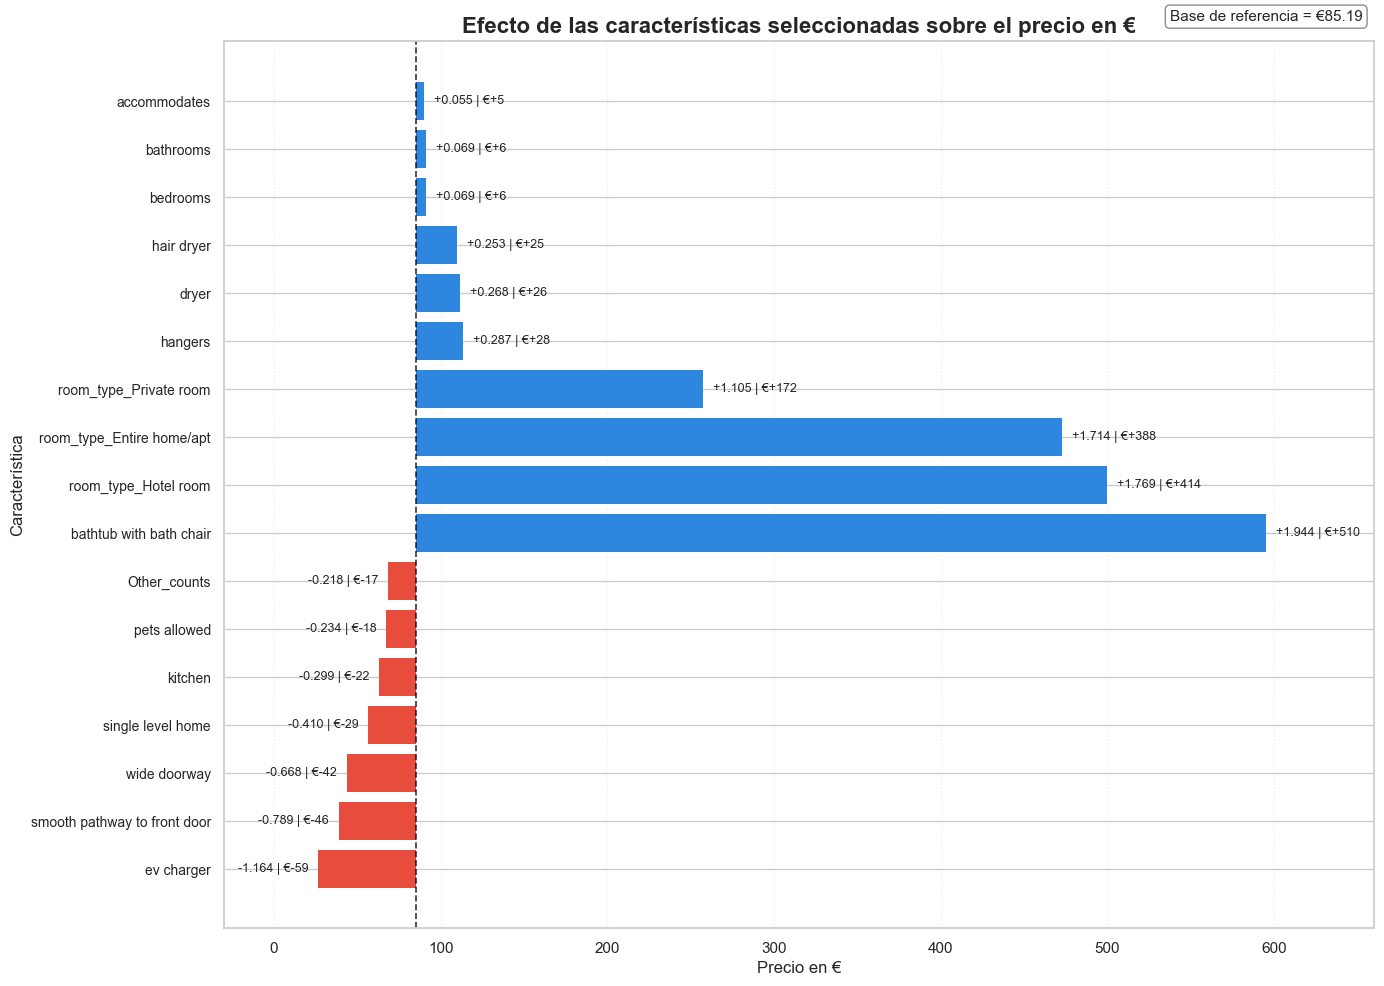

In [268]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------
# Input data
# -------------------------------------------------
data = [
    ("accommodates", 0.0550),
    ("bathrooms", 0.0689),
    ("bedrooms", 0.0689),
    ("bathtub with bath chair", 1.9438),
    ("dryer", 0.2682),
    ("ev charger", -1.1637),
    ("hair dryer", 0.2529),
    ("hangers", 0.2869),
    ("kitchen", -0.2986),
    ("pets allowed", -0.2337),
    ("single level home", -0.4098),
    ("smooth pathway to front door", -0.7890),
    ("wide doorway", -0.6680),
    ("Other_counts", -0.2179),
    ("room_type_Entire home/apt", 1.7142),
    ("room_type_Hotel room", 1.7688),
    ("room_type_Private room", 1.1052),

]

intercept = 4.4449                  

            
# -------------------------------------------------
# Data prep
# -------------------------------------------------
features_df = pd.DataFrame(data, columns=["feature", "coef"])

# Baseline price in euro from intercept
baseline_eur = np.exp(intercept)

# Euro effect of each feature relative to baseline
# Interpretation: price change in € when feature is present
features_df["euro_delta"] = baseline_eur * (np.exp(features_df["coef"]) - 1)

features_df["effect"] = np.where(features_df["euro_delta"] >= 0, "positive", "negative")
features_df["abs_euro_delta"] = features_df["euro_delta"].abs()

# Order by signed euro effect, positives first, negatives after
df_pos = features_df[features_df["euro_delta"] >= 0].sort_values("euro_delta", ascending=True)
df_neg = features_df[features_df["euro_delta"] < 0].sort_values("euro_delta", ascending=False)
plot_df = pd.concat([df_pos, df_neg], ignore_index=True)

# X positions centered on intercept in euro
plot_df["x_left"] = np.where(
    plot_df["euro_delta"] >= 0,
    baseline_eur,
    baseline_eur + plot_df["euro_delta"]
)
plot_df["bar_width"] = plot_df["euro_delta"].abs()

# Labels
plot_df["label"] = plot_df.apply(
    lambda r: f'{r["coef"]:+.3f} | €{r["euro_delta"]:+.0f}',
    axis=1
)

# Colors
colors = plot_df["euro_delta"].apply(lambda x: "#2E86DE" if x >= 0 else "#E74C3C")

# -------------------------------------------------
# Plot
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 10))

y = np.arange(len(plot_df))

ax.barh(
    y,
    plot_df["bar_width"],
    left=plot_df["x_left"],
    color=colors,
    edgecolor="none"
)

# Reference line at intercept in euro, not at zero
ax.axvline(baseline_eur, color="black", linewidth=1.2, linestyle="--", alpha=0.8)

# Y labels
ax.set_yticks(y)
ax.set_yticklabels(plot_df["feature"], fontsize=10)

# Value labels
for i, row in plot_df.iterrows():
    x_end = row["x_left"] + row["bar_width"] if row["euro_delta"] >= 0 else row["x_left"]
    if row["euro_delta"] >= 0:
        ax.text(x_end + 6, i, row["label"], va="center", ha="left", fontsize=9)
    else:
        ax.text(x_end - 6, i, row["label"], va="center", ha="right", fontsize=9)

# Title and axes
ax.set_title(
    "Efecto de las características seleccionadas sobre el precio en €",
    fontsize=16,
    weight="bold"
)
ax.set_xlabel("Precio en €")
ax.set_ylabel("Característica")

# X axis fixed range
ax.set_xlim(-30, 660)

# Intercept annotation
ax.text(
    0.99, 1.02,
    f"Base de referencia = €{baseline_eur:.2f}",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.9)
)

# Style
ax.invert_yaxis()
ax.grid(axis="x", linestyle=":", alpha=0.3)

plt.tight_layout()
plt.show()

##### **Results Malaga ~ General**

From three modelling approaches, Ordinary Least Squares (OLS) regression demonstrated the highest r2 = 0.693432.
Based on VIF estimation, the following features had highest collinearity:
    feature	VIF
3	bathrooms	inf
2	bedrooms	inf
1	accommodates	19.796595
28	essentials	14.316746
0	beds	13.629870
9	tv	12.362035
15	hair dryer	7.527268
5	air conditioning	6.348658

"accommodates", "bedrooms", "bathrooms" and "beds" represent Capacity characteristics of the accommodation, being highly colinear. It is proposed to use for further estimations **"accommodates"** only.
"essentials", "tv", "air conditioning" may be omitted from modelling, as being colinear with another features, and estimated with p>0.05 in OLS model.
Also, features with very low effect size (coef) were omited.

Features with accepted VIF and p<0.05 were:
#--------------------------------------------------------------------------------------------------------
                                           coef    std err          t      P>|t|      [0.025      0.975]
#--------------------------------------------------------------------------------------------------------
const                                    4.4449      0.181     24.511      0.000       4.088       4.802
accommodates                             0.0550      0.028      1.974      0.050       0.000       0.110
bathrooms                                0.0689      0.028      2.493      0.013       0.014       0.123
bedrooms                                 0.0689      0.028      2.493      0.013       0.014       0.123
bathtub with bath chair                  1.9438      0.971      2.001      0.046       0.031       3.857
dryer                                    0.2682      0.120      2.241      0.026       0.033       0.504
ev charger                              -1.1637      0.524     -2.219      0.027      -2.197      -0.131
hair dryer                               0.2529      0.109      2.325      0.021       0.039       0.467
hangers                                  0.2869      0.114      2.511      0.013       0.062       0.512
kitchen                                 -0.2986      0.132     -2.256      0.025      -0.559      -0.038
pets allowed                            -0.2337      0.112     -2.096      0.037      -0.453      -0.014
single level home                       -0.4098      0.196     -2.091      0.038      -0.796      -0.024
smooth pathway to front door            -0.7890      0.345     -2.285      0.023      -1.469      -0.109
wide doorway                            -0.6680      0.334     -2.003      0.046      -1.325      -0.011
Other_counts                            -0.2179      0.108     -2.016      0.045      -0.431      -0.005
room_type_Entire home/apt                1.7142      0.125     13.672      0.000       1.467       1.961
room_type_Hotel room                     1.7688      0.245      7.232      0.000       1.287       2.251
room_type_Private room                   1.1052      0.129      8.586      0.000       0.852       1.359

##### **Analysis Malaga ~ Entire home/apt**

In [ ]:
outdir = Path("output_Malaga_Entire")
outdir.mkdir(exist_ok=True)

In [ ]:
log("Starting data preparation")

price_orig = "price"
target = "price_log2"
id_cols = ["apartment_id", "host_id", "insert_date"]
location = ["city", "neighbourhood_district", "neighbourhood_name"]
df_model = df[(df["city"] == 'malaga') & (df["room_type"] == "Entire home/apt")].copy()

X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
y = df_model[target].astype(float)

list_cols = [c for c in X.columns if X[c].apply(lambda v: isinstance(v, list)).any()]
if list_cols:
    log(f"Dropping list-valued columns: {list_cols}")
    X = X.drop(columns=list_cols)

num_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

X[num_cols] = X[num_cols].apply(lambda s: s.astype(float) if s.dtype == "bool" else s)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")
log(f"Numeric cols: {len(num_cols)}, Categorical cols: {len(cat_cols)}")

[14:07:00] Starting data preparation
[14:07:01] Train rows: 259, Test rows: 65
[14:07:01] Numeric cols: 261, Categorical cols: 1


In [ ]:
log("Building preprocessors")

preprocess_rf = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

preprocess_enet = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

log("Preprocessors ready")

[14:07:21] Building preprocessors
[14:07:21] Preprocessors ready


In [ ]:
log("Fitting Random Forest")

rf = Pipeline(steps=[
    ("preprocess", preprocess_rf),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        max_depth=12,
        min_samples_leaf=5,
        max_features="sqrt"
    ))
])

t0 = time.time()
rf.fit(X_train, y_train)
log(f"Random Forest fit completed in {time.time() - t0:.1f}s")

rf_pred = rf.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
log(f"RF test RMSE={rf_rmse:.4f}, R2={rf_r2:.4f}")

[14:07:34] Fitting Random Forest
[14:07:35] Random Forest fit completed in 0.8s
[14:07:35] RF test RMSE=0.6772, R2=0.2563


In [ ]:
log("Computing permutation importance")

X_test_trans = rf.named_steps["preprocess"].transform(X_test)
feature_names = rf.named_steps["preprocess"].get_feature_names_out()

t0 = time.time()
perm = permutation_importance(
    rf.named_steps["model"],
    X_test_trans,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)
log(f"Permutation importance completed in {time.time() - t0:.1f}s")

rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

rf_importance.to_csv(outdir / "rf_permutation_importance.csv", index=False)
log("Saved RF importance to output/rf_permutation_importance.csv")

display(rf_importance.head(20))

[14:07:48] Computing permutation importance
[14:10:53] Permutation importance completed in 185.7s
[14:10:54] Saved RF importance to output/rf_permutation_importance.csv


,feature,importance_mean,importance_std
0,accommodates,0.043420,0.015348
2,bedrooms,0.033893,0.006396
1,bathrooms,0.031632,0.008285
3,beds,0.028470,0.004474
64,dryer,0.016044,0.005150
250,Family & Pets_y,0.010519,0.006050
260,Wellness & Recreation_y,0.007356,0.002801
148,oven,0.006187,0.003130
80,family kid friendly,0.005471,0.001832
113,hot water,0.005386,0.001569


In [ ]:
log("Fitting Elastic Net")

enet_pipe = Pipeline(steps=[
    ("preprocess", preprocess_enet),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9],
        alphas=np.logspace(-4, 1, 30),
        cv=5,
        random_state=42,
        max_iter=10000
    ))
])

t0 = time.time()
enet_pipe.fit(X_train, y_train)
log(f"Elastic Net fit completed in {time.time() - t0:.1f}s")

enet = enet_pipe.named_steps["model"]
enet_pred = enet_pipe.predict(X_test)
enet_rmse = np.sqrt(mean_squared_error(y_test, enet_pred))

enet_r2 = r2_score(y_test, enet_pred)

enet_features = enet_pipe.named_steps["preprocess"].get_feature_names_out()
enet_coefs = pd.DataFrame({
    "feature": enet_features,
    "coef": enet.coef_
})
enet_coefs["abs_coef"] = enet_coefs["coef"].abs()
enet_selected = enet_coefs[enet_coefs["coef"] != 0].sort_values("abs_coef", ascending=False)

enet_coefs.to_csv(outdir / "elastic_net_coefficients.csv", index=False)
log("Saved Elastic Net coefficients to output/elastic_net_coefficients.csv")

log(f"Elastic Net chosen alpha={enet.alpha_:.6f}, l1_ratio={enet.l1_ratio_}")
log(f"EN test RMSE={enet_rmse:.4f}, R2={enet_r2:.4f}")

display(enet_selected.head(30))

[14:12:31] Fitting Elastic Net
[14:14:26] Elastic Net fit completed in 114.9s
[14:14:26] Saved Elastic Net coefficients to output/elastic_net_coefficients.csv
[14:14:26] Elastic Net chosen alpha=0.280722, l1_ratio=0.1
[14:14:26] EN test RMSE=0.6650, R2=0.2829


,feature,coef,abs_coef
3,beds,0.095171,0.095171
121,kitchen,-0.094397,0.094397
0,accommodates,0.093097,0.093097
155,pets allowed,-0.063065,0.063065
2,bedrooms,0.058877,0.058877
1,bathrooms,0.058872,0.058872
173,safety card,0.055789,0.055789
159,pool,0.044542,0.044542
241,Outdoor & Views_x,0.044208,0.044208
237,Kitchen & Dining_x,-0.038579,0.038579


In [ ]:
log("Preparing VIF check")

top_rf = rf_importance["feature"].head(25).tolist()
top_en = enet_selected["feature"].head(25).tolist()

candidate_features = list(dict.fromkeys(top_rf + top_en))
log(f"Initial candidate features from RF + EN: {len(candidate_features)}")

base_cols = []
for f in candidate_features:
    base = f.split("_")[0] if "_" in f else f
    if base in X_train.columns:
        base_cols.append(base)

base_cols = list(dict.fromkeys(base_cols))
log(f"Base columns kept for VIF: {base_cols}")

X_vif = X_train[base_cols].copy()
X_vif = pd.get_dummies(X_vif, drop_first=True)

for c in X_vif.columns:
    if X_vif[c].dtype == "bool":
        X_vif[c] = X_vif[c].astype(int)

X_vif = X_vif.fillna(X_vif.median(numeric_only=True))

log(f"VIF matrix shape: {X_vif.shape}")

vif_data = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

vif_data.to_csv(outdir / "vif_results.csv", index=False)
log("Saved VIF results to output/vif_results.csv")

display(vif_data.head(30))

[14:14:33] Preparing VIF check
[14:14:33] Initial candidate features from RF + EN: 43
[14:14:33] Base columns kept for VIF: ['accommodates', 'bedrooms', 'bathrooms', 'beds', 'dryer', 'oven', 'family kid friendly', 'hot water', 'free parking on street', 'first aid kit', 'microwave', 'free parking on premises', 'garden or backyard', 'crib', 'extra pillows and blankets', 'stove', 'essentials', 'cooking basics', 'kitchen', 'pets allowed', 'safety card', 'pool', 'doorman', 'gym', 'self check in', 'cleaning before checkout', 'buzzer wireless intercom', 'pocket wifi', 'beach essentials', 'dedicated workspace', 'accessible-height toilet', 'washer', 'lock on bedroom door']
[14:14:33] VIF matrix shape: (259, 33)
[14:14:33] Saved VIF results to output/vif_results.csv


,feature,VIF
1,bedrooms,inf
2,bathrooms,inf
18,kitchen,27.425006
16,essentials,25.843755
0,accommodates,25.569137
3,beds,16.349915
31,washer,12.496856
17,cooking basics,8.063802
10,microwave,6.903514
7,hot water,5.991459


In [ ]:
log("Fitting Gamma GLM with log link")

glm_X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
glm_list_cols = [c for c in glm_X.columns if glm_X[c].apply(lambda v: isinstance(v, list)).any()]
if glm_list_cols:
    log(f"Dropping list-valued columns from GLM: {glm_list_cols}")
    glm_X = glm_X.drop(columns=glm_list_cols)

glm_num_cols = glm_X.select_dtypes(include=["number", "bool"]).columns.tolist()
glm_cat_cols = glm_X.select_dtypes(include=["object", "category"]).columns.tolist()

glm_preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), glm_num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), glm_cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

t0 = time.time()
X_glm = glm_preprocess.fit_transform(glm_X)
log(f"GLM preprocessing completed in {time.time() - t0:.1f}s")

glm_feature_names = glm_preprocess.get_feature_names_out()
X_glm_df = pd.DataFrame(X_glm, columns=glm_feature_names, index=df_model.index)
X_glm_df = sm.add_constant(X_glm_df, has_constant="add")

y_glm = df_model[target].astype(float)

t0 = time.time()
gamma_model = sm.GLM(
    y_glm,
    X_glm_df,
    family=sm.families.Gamma(link=sm.families.links.log())
).fit()
log(f"Gamma GLM fit completed in {time.time() - t0:.1f}s")

with open(outdir / "gamma_glm_summary.txt", "w", encoding="utf-8") as f:
    f.write(gamma_model.summary().as_text())

log("Saved Gamma GLM summary to output/gamma_glm_summary.txt")
print(gamma_model.summary())

[14:14:40] Fitting Gamma GLM with log link
[14:14:40] GLM preprocessing completed in 0.1s
[14:14:46] Gamma GLM fit completed in 5.5s
[14:14:48] Saved Gamma GLM summary to output/gamma_glm_summary.txt
                 Generalized Linear Model Regression Results                  
Dep. Variable:             price_log2   No. Observations:                  324
Model:                            GLM   Df Residuals:                      165
Model Family:                   Gamma   Df Model:                          158
Link Function:                    log   Scale:                       0.0033136
Method:                          IRLS   Log-Likelihood:                -181.15
Date:                Fri, 05 Jun 2026   Deviance:                      0.53772
Time:                        14:14:48   Pearson chi2:                    0.547
No. Iterations:                    65   Pseudo R-squ. (CS):             0.6861
Covariance Type:            nonrobust                                         
          

In [ ]:
log("Fitting OLS on log(price)")

if "price" in df_model.columns:
    y_lin = np.log(df_model["price"].astype(float))
    X_lin = X_glm_df.copy()

    t0 = time.time()
    lin_model = sm.OLS(y_lin, X_lin).fit()
    log(f"OLS fit completed in {time.time() - t0:.1f}s")

    with open(outdir / "ols_logprice_summary.txt", "w", encoding="utf-8") as f:
        f.write(lin_model.summary().as_text())

    log("Saved OLS summary to output/ols_logprice_summary.txt")
    print(lin_model.summary())
else:
    lin_model = None
    log("No raw price column found; skipping OLS on log(price)")

[14:14:53] Fitting OLS on log(price)
[14:14:53] OLS fit completed in 0.2s
[14:14:54] Saved OLS summary to output/ols_logprice_summary.txt
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.698
Model:                            OLS   Adj. R-squared:                  0.409
Method:                 Least Squares   F-statistic:                     2.415
Date:                Fri, 05 Jun 2026   Prob (F-statistic):           1.67e-08
Time:                        14:14:54   Log-Likelihood:                -36.761
No. Observations:                 324   AIC:                             391.5
Df Residuals:                     165   BIC:                             992.7
Df Model:                         158                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t   

In [ ]:
log("Building comparison table")

results = pd.DataFrame([
    {"model": "Random Forest", "rmse": rf_rmse, "r2": rf_r2},
    {"model": "Elastic Net", "rmse": enet_rmse, "r2": enet_r2},
])

if lin_model is not None:
    results = pd.concat([
        results,
        pd.DataFrame([{
            "model": "OLS log(price)",
            "rmse": np.nan,
            "r2": lin_model.rsquared
        }])
    ], ignore_index=True)

results.to_csv(outdir / "model_comparison.csv", index=False)
log("Saved comparison table to output/model_comparison.csv")
display(results)

[14:14:57] Building comparison table
[14:14:57] Saved comparison table to output/model_comparison.csv


,model,rmse,r2
0,Random Forest,0.677225,0.256285
1,Elastic Net,0.665002,0.282890
2,OLS log(price),NaN,0.698093


##### **Results Malaga ~ Entire home/apt**

##### **Analysis Malaga ~ Private room**

In [ ]:
outdir = Path("output_Malaga_Private")
outdir.mkdir(exist_ok=True)

In [ ]:
log("Starting data preparation")

price_orig = "price"
target = "price_log2"
id_cols = ["apartment_id", "host_id", "insert_date"]
location = ["city", "neighbourhood_district", "neighbourhood_name"]
df_model = df[(df["city"] == 'malaga') & (df["room_type"] == "Private room")].copy()

X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
y = df_model[target].astype(float)

list_cols = [c for c in X.columns if X[c].apply(lambda v: isinstance(v, list)).any()]
if list_cols:
    log(f"Dropping list-valued columns: {list_cols}")
    X = X.drop(columns=list_cols)

num_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

X[num_cols] = X[num_cols].apply(lambda s: s.astype(float) if s.dtype == "bool" else s)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")
log(f"Numeric cols: {len(num_cols)}, Categorical cols: {len(cat_cols)}")

[14:16:05] Starting data preparation
[14:16:11] Train rows: 50, Test rows: 13
[14:16:11] Numeric cols: 261, Categorical cols: 1


In [ ]:
log("Building preprocessors")

preprocess_rf = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

preprocess_enet = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

log("Preprocessors ready")

[14:16:28] Building preprocessors
[14:16:28] Preprocessors ready


In [ ]:
log("Fitting Random Forest")

rf = Pipeline(steps=[
    ("preprocess", preprocess_rf),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        max_depth=12,
        min_samples_leaf=5,
        max_features="sqrt"
    ))
])

t0 = time.time()
rf.fit(X_train, y_train)
log(f"Random Forest fit completed in {time.time() - t0:.1f}s")

rf_pred = rf.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
log(f"RF test RMSE={rf_rmse:.4f}, R2={rf_r2:.4f}")

[14:16:58] Fitting Random Forest
[14:17:00] Random Forest fit completed in 1.2s
[14:17:00] RF test RMSE=0.6419, R2=-0.0695


In [ ]:
log("Computing permutation importance")

X_test_trans = rf.named_steps["preprocess"].transform(X_test)
feature_names = rf.named_steps["preprocess"].get_feature_names_out()

t0 = time.time()
perm = permutation_importance(
    rf.named_steps["model"],
    X_test_trans,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)
log(f"Permutation importance completed in {time.time() - t0:.1f}s")

rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

rf_importance.to_csv(outdir / "rf_permutation_importance.csv", index=False)
log("Saved RF importance to output/rf_permutation_importance.csv")

display(rf_importance.head(20))

[14:17:21] Computing permutation importance
[14:21:00] Permutation importance completed in 218.5s
[14:21:00] Saved RF importance to output/rf_permutation_importance.csv


,feature,importance_mean,importance_std
92,free parking on street,0.025444,0.018874
0,accommodates,0.006005,0.010290
235,Family & Pets_x,0.005958,0.006513
118,iron,0.004519,0.006010
253,Laundry & Housekeeping_y,0.003164,0.002023
188,smoking allowed,0.003082,0.001090
210,tv,0.003051,0.001367
131,microwave,0.002763,0.002398
252,Kitchen & Dining_y,0.002466,0.002268
159,pool,0.001893,0.009689


In [ ]:
log("Fitting Elastic Net")

enet_pipe = Pipeline(steps=[
    ("preprocess", preprocess_enet),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9],
        alphas=np.logspace(-4, 1, 30),
        cv=5,
        random_state=42,
        max_iter=10000
    ))
])

t0 = time.time()
enet_pipe.fit(X_train, y_train)
log(f"Elastic Net fit completed in {time.time() - t0:.1f}s")

enet = enet_pipe.named_steps["model"]
enet_pred = enet_pipe.predict(X_test)
enet_rmse = np.sqrt(mean_squared_error(y_test, enet_pred))

enet_r2 = r2_score(y_test, enet_pred)

enet_features = enet_pipe.named_steps["preprocess"].get_feature_names_out()
enet_coefs = pd.DataFrame({
    "feature": enet_features,
    "coef": enet.coef_
})
enet_coefs["abs_coef"] = enet_coefs["coef"].abs()
enet_selected = enet_coefs[enet_coefs["coef"] != 0].sort_values("abs_coef", ascending=False)

enet_coefs.to_csv(outdir / "elastic_net_coefficients.csv", index=False)
log("Saved Elastic Net coefficients to output/elastic_net_coefficients.csv")

log(f"Elastic Net chosen alpha={enet.alpha_:.6f}, l1_ratio={enet.l1_ratio_}")
log(f"EN test RMSE={enet_rmse:.4f}, R2={enet_r2:.4f}")

display(enet_selected.head(30))

[14:24:15] Fitting Elastic Net
[14:24:17] Elastic Net fit completed in 2.0s
[14:24:17] Saved Elastic Net coefficients to output/elastic_net_coefficients.csv
[14:24:17] Elastic Net chosen alpha=0.188739, l1_ratio=0.5
[14:24:17] EN test RMSE=0.6737, R2=-0.1783


,feature,coef,abs_coef
30,breakfast,0.137570,0.137570
0,accommodates,0.118716,0.118716
109,heating,0.091633,0.091633
97,garden or backyard,0.067320,0.067320
7,air conditioning,0.056813,0.056813
112,hot tub,0.056399,0.056399
216,wheelchair accessible,0.042359,0.042359
127,lockbox,-0.028275,0.028275
246,Accessibility_y,-0.023351,0.023351
118,iron,-0.015206,0.015206


In [ ]:
log("Preparing VIF check")

top_rf = rf_importance["feature"].head(25).tolist()
top_en = enet_selected["feature"].head(25).tolist()

candidate_features = list(dict.fromkeys(top_rf + top_en))
log(f"Initial candidate features from RF + EN: {len(candidate_features)}")

base_cols = []
for f in candidate_features:
    base = f.split("_")[0] if "_" in f else f
    if base in X_train.columns:
        base_cols.append(base)

base_cols = list(dict.fromkeys(base_cols))
log(f"Base columns kept for VIF: {base_cols}")

X_vif = X_train[base_cols].copy()
X_vif = pd.get_dummies(X_vif, drop_first=True)

for c in X_vif.columns:
    if X_vif[c].dtype == "bool":
        X_vif[c] = X_vif[c].astype(int)

X_vif = X_vif.fillna(X_vif.median(numeric_only=True))

log(f"VIF matrix shape: {X_vif.shape}")

vif_data = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

vif_data.to_csv(outdir / "vif_results.csv", index=False)
log("Saved VIF results to output/vif_results.csv")

display(vif_data.head(30))

[14:24:22] Preparing VIF check
[14:24:22] Initial candidate features from RF + EN: 39
[14:24:22] Base columns kept for VIF: ['free parking on street', 'accommodates', 'iron', 'smoking allowed', 'tv', 'microwave', 'pool', 'hair dryer', 'paid parking on premises', 'shampoo', 'hot water', 'fire extinguisher', 'extra pillows and blankets', 'stove', 'kitchen', 'patio or balcony', 'free parking on premises', 'smoke detector', 'bedrooms', 'breakfast', 'heating', 'garden or backyard', 'air conditioning', 'hot tub', 'wheelchair accessible', 'lockbox', 'accessible-height toilet', 'washer', "children's books and toys", 'dedicated workspace']
[14:24:22] VIF matrix shape: (50, 30)
[14:24:22] Saved VIF results to output/vif_results.csv


,feature,VIF
18,bedrooms,21.108410
7,hair dryer,18.756234
14,kitchen,18.497005
27,washer,18.248264
4,tv,15.099325
1,accommodates,13.865751
2,iron,12.064242
25,lockbox,10.268774
13,stove,9.318761
12,extra pillows and blankets,9.245953


In [ ]:
log("Fitting Gamma GLM with log link")

glm_X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
glm_list_cols = [c for c in glm_X.columns if glm_X[c].apply(lambda v: isinstance(v, list)).any()]
if glm_list_cols:
    log(f"Dropping list-valued columns from GLM: {glm_list_cols}")
    glm_X = glm_X.drop(columns=glm_list_cols)

glm_num_cols = glm_X.select_dtypes(include=["number", "bool"]).columns.tolist()
glm_cat_cols = glm_X.select_dtypes(include=["object", "category"]).columns.tolist()

glm_preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), glm_num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), glm_cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

t0 = time.time()
X_glm = glm_preprocess.fit_transform(glm_X)
log(f"GLM preprocessing completed in {time.time() - t0:.1f}s")

glm_feature_names = glm_preprocess.get_feature_names_out()
X_glm_df = pd.DataFrame(X_glm, columns=glm_feature_names, index=df_model.index)
X_glm_df = sm.add_constant(X_glm_df, has_constant="add")

y_glm = df_model[target].astype(float)

t0 = time.time()
gamma_model = sm.GLM(
    y_glm,
    X_glm_df,
    family=sm.families.Gamma(link=sm.families.links.log())
).fit()
log(f"Gamma GLM fit completed in {time.time() - t0:.1f}s")

with open(outdir / "gamma_glm_summary.txt", "w", encoding="utf-8") as f:
    f.write(gamma_model.summary().as_text())

log("Saved Gamma GLM summary to output/gamma_glm_summary.txt")
print(gamma_model.summary())

[14:24:27] Fitting Gamma GLM with log link
[14:24:27] GLM preprocessing completed in 0.2s
[14:24:28] Gamma GLM fit completed in 0.0s
[14:24:29] Saved Gamma GLM summary to output/gamma_glm_summary.txt
                 Generalized Linear Model Regression Results                  
Dep. Variable:             price_log2   No. Observations:                   63
Model:                            GLM   Df Residuals:                        0
Model Family:                   Gamma   Df Model:                           62
Link Function:                    log   Scale:                             inf
Method:                          IRLS   Log-Likelihood:                    nan
Date:                Fri, 05 Jun 2026   Deviance:                   0.00016283
Time:                        14:24:29   Pearson chi2:                 0.000162
No. Iterations:                     1   Pseudo R-squ. (CS):                nan
Covariance Type:            nonrobust                                         
          

In [ ]:
log("Fitting OLS on log(price)")

if "price" in df_model.columns:
    y_lin = np.log(df_model["price"].astype(float))
    X_lin = X_glm_df.copy()

    t0 = time.time()
    lin_model = sm.OLS(y_lin, X_lin).fit()
    log(f"OLS fit completed in {time.time() - t0:.1f}s")

    with open(outdir / "ols_logprice_summary.txt", "w", encoding="utf-8") as f:
        f.write(lin_model.summary().as_text())

    log("Saved OLS summary to output/ols_logprice_summary.txt")
    print(lin_model.summary())
else:
    lin_model = None
    log("No raw price column found; skipping OLS on log(price)")

[14:24:38] Fitting OLS on log(price)
[14:24:38] OLS fit completed in 0.0s
[14:24:38] Saved OLS summary to output/ols_logprice_summary.txt
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Fri, 05 Jun 2026   Prob (F-statistic):                nan
Time:                        14:24:38   Log-Likelihood:                 1769.4
No. Observations:                  63   AIC:                            -3413.
Df Residuals:                       0   BIC:                            -3278.
Df Model:                          62                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t   

In [ ]:
log("Building comparison table")

results = pd.DataFrame([
    {"model": "Random Forest", "rmse": rf_rmse, "r2": rf_r2},
    {"model": "Elastic Net", "rmse": enet_rmse, "r2": enet_r2},
])

if lin_model is not None:
    results = pd.concat([
        results,
        pd.DataFrame([{
            "model": "OLS log(price)",
            "rmse": np.nan,
            "r2": lin_model.rsquared
        }])
    ], ignore_index=True)

results.to_csv(outdir / "model_comparison.csv", index=False)
log("Saved comparison table to output/model_comparison.csv")
display(results)

[14:24:51] Building comparison table
[14:24:51] Saved comparison table to output/model_comparison.csv


,model,rmse,r2
0,Random Forest,0.641859,-0.069500
1,Elastic Net,0.673704,-0.178255
2,OLS log(price),NaN,1.000000


##### **Results Malaga ~ Private room**
- Insufficient data for modelling

##### **Analysis Malaga ~ Hotel room**

In [ ]:
outdir = Path("output_Malaga_Hotel")
outdir.mkdir(exist_ok=True)

In [ ]:
log("Starting data preparation")

price_orig = "price"
target = "price_log2"
id_cols = ["apartment_id", "host_id", "insert_date"]
location = ["city", "neighbourhood_district", "neighbourhood_name"]
df_model = df[(df["city"] == 'malaga') & (df["room_type"] == "Hotel room")].copy()

X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
y = df_model[target].astype(float)

list_cols = [c for c in X.columns if X[c].apply(lambda v: isinstance(v, list)).any()]
if list_cols:
    log(f"Dropping list-valued columns: {list_cols}")
    X = X.drop(columns=list_cols)

num_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

X[num_cols] = X[num_cols].apply(lambda s: s.astype(float) if s.dtype == "bool" else s)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")
log(f"Numeric cols: {len(num_cols)}, Categorical cols: {len(cat_cols)}")

[14:30:51] Starting data preparation
[14:30:52] Train rows: 2, Test rows: 1
[14:30:52] Numeric cols: 261, Categorical cols: 1


##### **Results Malaga ~ Hotel room**
- Very few data for analysis

##### **Analysis Malaga ~ Shared room**

In [ ]:
outdir = Path("output_Malaga_Shared")
outdir.mkdir(exist_ok=True)

In [ ]:
log("Starting data preparation")

price_orig = "price"
target = "price_log2"
id_cols = ["apartment_id", "host_id", "insert_date"]
location = ["city", "neighbourhood_district", "neighbourhood_name"]
df_model = df[(df["city"] == 'malaga') & (df["room_type"] == "Shared room")].copy()

X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
y = df_model[target].astype(float)

list_cols = [c for c in X.columns if X[c].apply(lambda v: isinstance(v, list)).any()]
if list_cols:
    log(f"Dropping list-valued columns: {list_cols}")
    X = X.drop(columns=list_cols)

num_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

X[num_cols] = X[num_cols].apply(lambda s: s.astype(float) if s.dtype == "bool" else s)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")
log(f"Numeric cols: {len(num_cols)}, Categorical cols: {len(cat_cols)}")

[14:31:50] Starting data preparation
[14:31:50] Train rows: 2, Test rows: 1
[14:31:50] Numeric cols: 261, Categorical cols: 1


##### **Results Malaga ~ Shared room**
- Very few data for the analysis

#### **VALENCIA**

##### **Analysis Valencia ~ General**

In [269]:
outdir = Path("output_Valencia_general")
outdir.mkdir(exist_ok=True)

In [270]:
log("Starting data preparation")

price_orig = "price"
target = "price_log2"
id_cols = ["apartment_id", "host_id", "insert_date"]
location = ["city", "neighbourhood_district", "neighbourhood_name"]
df_model = df[df["city"] == 'valencia'].copy()

X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
y = df_model[target].astype(float)

list_cols = [c for c in X.columns if X[c].apply(lambda v: isinstance(v, list)).any()]
if list_cols:
    log(f"Dropping list-valued columns: {list_cols}")
    X = X.drop(columns=list_cols)

num_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

X[num_cols] = X[num_cols].apply(lambda s: s.astype(float) if s.dtype == "bool" else s)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")
log(f"Numeric cols: {len(num_cols)}, Categorical cols: {len(cat_cols)}")

[21:12:20] Starting data preparation
[21:12:20] Dropping list-valued columns: ['Accessibility_name', 'Digital/Tech_name', 'Entertainment & Media_name', 'Family & Pets_name', 'In-Room Essentials & Comfort_name', 'Kitchen & Dining_name', 'Laundry & Housekeeping_name', 'Luxury & Premium_name', 'Other_name', 'Outdoor & Views_name', 'Parking & Transport_name', 'Safety & Security_name', 'Service & Operations_name', 'Wellness & Recreation_name']
[21:12:22] Train rows: 288, Test rows: 72
[21:12:22] Numeric cols: 235, Categorical cols: 2


In [271]:
log("Building preprocessors")

preprocess_rf = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

preprocess_enet = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

log("Preprocessors ready")

[21:12:38] Building preprocessors
[21:12:38] Preprocessors ready


In [272]:
log("Fitting Random Forest")

rf = Pipeline(steps=[
    ("preprocess", preprocess_rf),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        max_depth=12,
        min_samples_leaf=5,
        max_features="sqrt"
    ))
])

t0 = time.time()
rf.fit(X_train, y_train)
log(f"Random Forest fit completed in {time.time() - t0:.1f}s")

rf_pred = rf.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
log(f"RF test RMSE={rf_rmse:.4f}, R2={rf_r2:.4f}")

[21:12:52] Fitting Random Forest
[21:12:58] Random Forest fit completed in 6.0s
[21:12:59] RF test RMSE=0.6090, R2=0.4414


In [273]:
log("Computing permutation importance")

X_test_trans = rf.named_steps["preprocess"].transform(X_test)
feature_names = rf.named_steps["preprocess"].get_feature_names_out()

t0 = time.time()
perm = permutation_importance(
    rf.named_steps["model"],
    X_test_trans,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)
log(f"Permutation importance completed in {time.time() - t0:.1f}s")

rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

rf_importance.to_csv(outdir / "rf_permutation_importance.csv", index=False)
log("Saved RF importance to output/rf_permutation_importance.csv")

display(rf_importance.head(20))

[21:13:06] Computing permutation importance
[21:18:14] Permutation importance completed in 308.0s
[21:18:14] Saved RF importance to output/rf_permutation_importance.csv


,feature,importance_mean,importance_std
235,room_type_Entire home/apt,0.110303,0.032453
0,accommodates,0.088859,0.006968
237,room_type_Private room,0.060342,0.019386
106,heating,0.032966,0.007961
3,beds,0.029586,0.004804
58,dishwasher,0.025015,0.008816
1,bathrooms,0.016034,0.007933
7,air conditioning,0.011834,0.003590
2,bedrooms,0.006375,0.004089
229,Other_counts,0.005321,0.005184


In [274]:
log("Fitting Elastic Net")

enet_pipe = Pipeline(steps=[
    ("preprocess", preprocess_enet),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9],
        alphas=np.logspace(-4, 1, 30),
        cv=5,
        random_state=42,
        max_iter=10000
    ))
])

t0 = time.time()
enet_pipe.fit(X_train, y_train)
log(f"Elastic Net fit completed in {time.time() - t0:.1f}s")

enet = enet_pipe.named_steps["model"]
enet_pred = enet_pipe.predict(X_test)
enet_rmse = np.sqrt(mean_squared_error(y_test, enet_pred))

enet_r2 = r2_score(y_test, enet_pred)

enet_features = enet_pipe.named_steps["preprocess"].get_feature_names_out()
enet_coefs = pd.DataFrame({
    "feature": enet_features,
    "coef": enet.coef_
})
enet_coefs["abs_coef"] = enet_coefs["coef"].abs()
enet_selected = enet_coefs[enet_coefs["coef"] != 0].sort_values("abs_coef", ascending=False)

enet_coefs.to_csv(outdir / "elastic_net_coefficients.csv", index=False)
log("Saved Elastic Net coefficients to output/elastic_net_coefficients.csv")

log(f"Elastic Net chosen alpha={enet.alpha_:.6f}, l1_ratio={enet.l1_ratio_}")
log(f"EN test RMSE={enet_rmse:.4f}, R2={enet_r2:.4f}")

display(enet_selected.head(30))

[21:19:21] Fitting Elastic Net
[21:20:33] Elastic Net fit completed in 72.1s
[21:20:33] Saved Elastic Net coefficients to output/elastic_net_coefficients.csv
[21:20:33] Elastic Net chosen alpha=0.038566, l1_ratio=0.9
[21:20:33] EN test RMSE=0.5897, R2=0.4762


,feature,coef,abs_coef
235,room_type_Entire home/apt,0.545395,0.545395
0,accommodates,0.349738,0.349738
58,dishwasher,0.078862,0.078862
106,heating,0.077548,0.077548
222,Digital/Tech_counts,-0.071974,0.071974
110,hot water,-0.070879,0.070879
149,patio or balcony,0.060450,0.060450
89,free parking on street,-0.052069,0.052069
191,stove,-0.052056,0.052056
189,step free access,-0.044095,0.044095


In [275]:
log("Preparing VIF check")

top_rf = rf_importance["feature"].head(25).tolist()
top_en = enet_selected["feature"].head(25).tolist()

candidate_features = list(dict.fromkeys(top_rf + top_en))
log(f"Initial candidate features from RF + EN: {len(candidate_features)}")

base_cols = []
for f in candidate_features:
    base = f.split("_")[0] if "_" in f else f
    if base in X_train.columns:
        base_cols.append(base)

base_cols = list(dict.fromkeys(base_cols))
log(f"Base columns kept for VIF: {base_cols}")

X_vif = X_train[base_cols].copy()
X_vif = pd.get_dummies(X_vif, drop_first=True)

for c in X_vif.columns:
    if X_vif[c].dtype == "bool":
        X_vif[c] = X_vif[c].astype(int)

X_vif = X_vif.fillna(X_vif.median(numeric_only=True))

log(f"VIF matrix shape: {X_vif.shape}")

vif_data = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

vif_data.to_csv(outdir / "vif_results.csv", index=False)
log("Saved VIF results to output/vif_results.csv")

display(vif_data.head(30))

[21:21:06] Preparing VIF check
[21:21:06] Initial candidate features from RF + EN: 39
[21:21:06] Base columns kept for VIF: ['accommodates', 'heating', 'beds', 'dishwasher', 'bathrooms', 'air conditioning', 'bedrooms', 'safety card', 'elevator', 'smoking allowed', 'iron', 'coffee maker', 'family kid friendly', 'free parking on street', 'private living room', 'internet', 'pets allowed', 'patio or balcony', 'hair dryer', 'washer', 'hot water', 'stove', 'step free access', 'pets live on this property', 'building staff', 'cat', 'step free shower', 'dryer', 'paid parking off premises', 'lockbox', 'laptop friendly workspace', 'private entrance', 'doorman']
[21:21:06] VIF matrix shape: (288, 33)
[21:21:07] Saved VIF results to output/vif_results.csv


,feature,VIF
4,bathrooms,inf
6,bedrooms,inf
0,accommodates,23.602997
2,beds,14.084255
19,washer,9.584045
18,hair dryer,8.299996
10,iron,7.402752
20,hot water,6.835802
11,coffee maker,5.196043
1,heating,5.173750


In [276]:
log("Fitting Gamma GLM with log link")

glm_X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
glm_list_cols = [c for c in glm_X.columns if glm_X[c].apply(lambda v: isinstance(v, list)).any()]
if glm_list_cols:
    log(f"Dropping list-valued columns from GLM: {glm_list_cols}")
    glm_X = glm_X.drop(columns=glm_list_cols)

glm_num_cols = glm_X.select_dtypes(include=["number", "bool"]).columns.tolist()
glm_cat_cols = glm_X.select_dtypes(include=["object", "category"]).columns.tolist()

glm_preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), glm_num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), glm_cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

t0 = time.time()
X_glm = glm_preprocess.fit_transform(glm_X)
log(f"GLM preprocessing completed in {time.time() - t0:.1f}s")

glm_feature_names = glm_preprocess.get_feature_names_out()
X_glm_df = pd.DataFrame(X_glm, columns=glm_feature_names, index=df_model.index)
X_glm_df = sm.add_constant(X_glm_df, has_constant="add")

y_glm = df_model[target].astype(float)

t0 = time.time()
gamma_model = sm.GLM(
    y_glm,
    X_glm_df,
    family=sm.families.Gamma(link=sm.families.links.log())
).fit()
log(f"Gamma GLM fit completed in {time.time() - t0:.1f}s")

with open(outdir / "gamma_glm_summary.txt", "w", encoding="utf-8") as f:
    f.write(gamma_model.summary().as_text())

log("Saved Gamma GLM summary to output/gamma_glm_summary.txt")
print(gamma_model.summary())

[21:21:33] Fitting Gamma GLM with log link
[21:21:33] Dropping list-valued columns from GLM: ['Accessibility_name', 'Digital/Tech_name', 'Entertainment & Media_name', 'Family & Pets_name', 'In-Room Essentials & Comfort_name', 'Kitchen & Dining_name', 'Laundry & Housekeeping_name', 'Luxury & Premium_name', 'Other_name', 'Outdoor & Views_name', 'Parking & Transport_name', 'Safety & Security_name', 'Service & Operations_name', 'Wellness & Recreation_name']
[21:21:33] GLM preprocessing completed in 0.1s
[21:21:42] Gamma GLM fit completed in 8.1s
[21:21:42] Saved Gamma GLM summary to output/gamma_glm_summary.txt
                 Generalized Linear Model Regression Results                  
Dep. Variable:             price_log2   No. Observations:                  360
Model:                            GLM   Df Residuals:                      216
Model Family:                   Gamma   Df Model:                          143
Link Function:                    log   Scale:                       

In [277]:
log("Fitting OLS on log(price)")

if "price" in df_model.columns:
    y_lin = np.log(df_model["price"].astype(float))
    X_lin = X_glm_df.copy()

    t0 = time.time()
    lin_model = sm.OLS(y_lin, X_lin).fit()
    log(f"OLS fit completed in {time.time() - t0:.1f}s")

    with open(outdir / "ols_logprice_summary.txt", "w", encoding="utf-8") as f:
        f.write(lin_model.summary().as_text())

    log("Saved OLS summary to output/ols_logprice_summary.txt")
    print(lin_model.summary())
else:
    lin_model = None
    log("No raw price column found; skipping OLS on log(price)")

[21:21:48] Fitting OLS on log(price)
[21:21:48] OLS fit completed in 0.1s
[21:21:49] Saved OLS summary to output/ols_logprice_summary.txt
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.701
Model:                            OLS   Adj. R-squared:                  0.504
Method:                 Least Squares   F-statistic:                     3.548
Date:                Sun, 07 Jun 2026   Prob (F-statistic):           2.43e-17
Time:                        21:21:50   Log-Likelihood:                -132.16
No. Observations:                 360   AIC:                             552.3
Df Residuals:                     216   BIC:                             1112.
Df Model:                         143                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t   

In [278]:
log("Building comparison table")

results = pd.DataFrame([
    {"model": "Random Forest", "rmse": rf_rmse, "r2": rf_r2},
    {"model": "Elastic Net", "rmse": enet_rmse, "r2": enet_r2},
])

if lin_model is not None:
    results = pd.concat([
        results,
        pd.DataFrame([{
            "model": "OLS log(price)",
            "rmse": np.nan,
            "r2": lin_model.rsquared
        }])
    ], ignore_index=True)

results.to_csv(outdir / "model_comparison.csv", index=False)
log("Saved comparison table to output/model_comparison.csv")
display(results)

[21:23:01] Building comparison table
[21:23:01] Saved comparison table to output/model_comparison.csv


,model,rmse,r2
0,Random Forest,0.608990,0.441431
1,Elastic Net,0.589731,0.476202
2,OLS log(price),NaN,0.701386


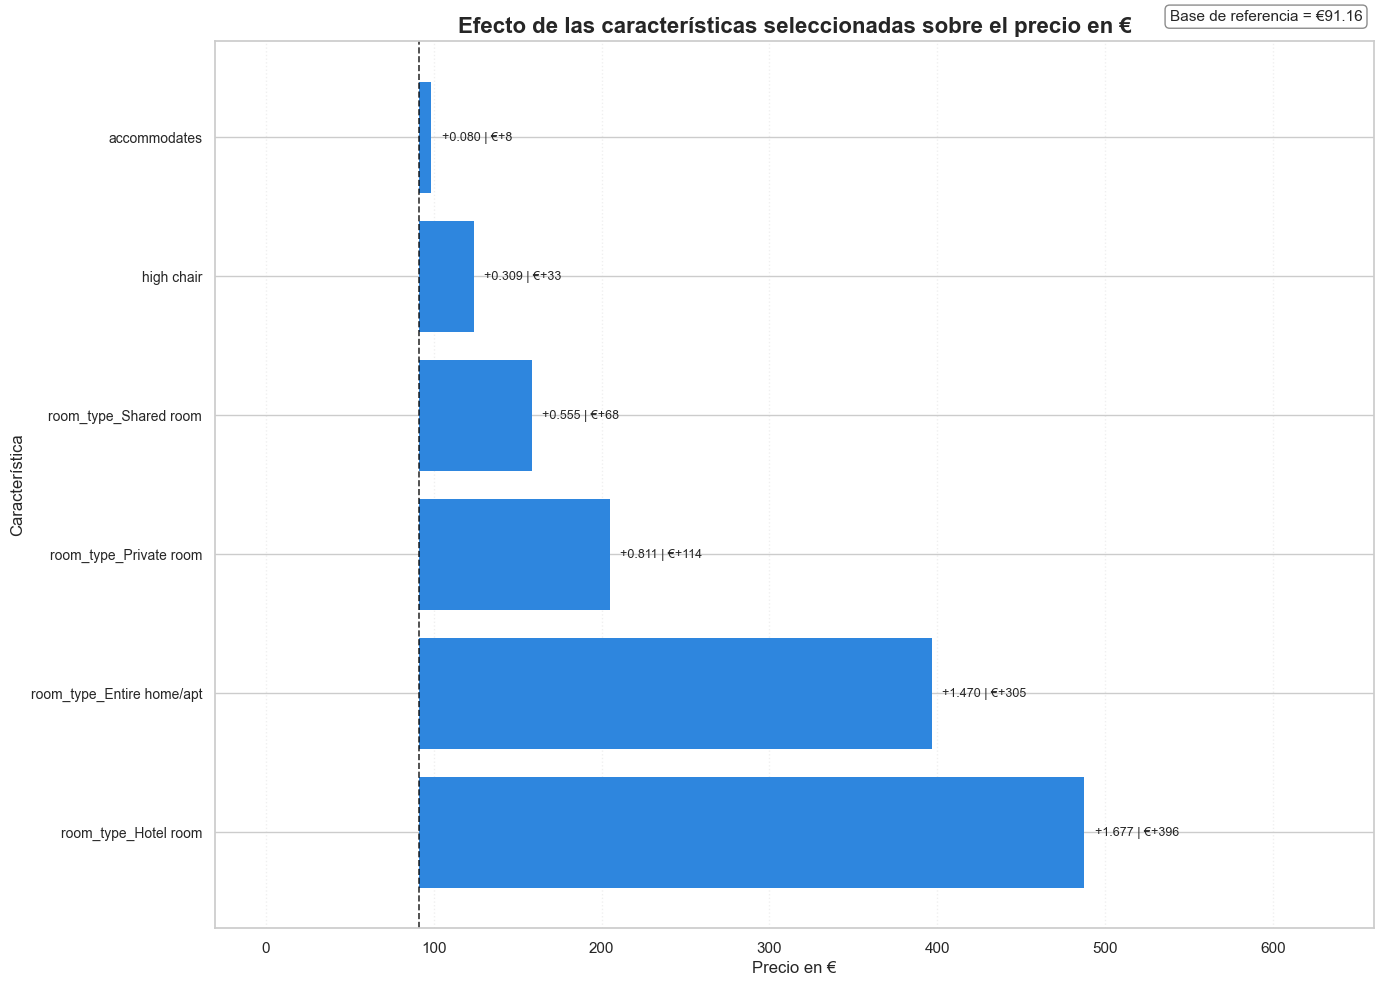

In [279]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------
# Input data
# -------------------------------------------------
data = [
    ("accommodates", 0.0798),
    ("high chair", 0.3092),

    ("room_type_Entire home/apt", 1.4703),
    ("room_type_Hotel room", 1.6769),
    ("room_type_Private room", 0.8109),
    ("room_type_Shared room", 0.5546),

]

intercept = 4.5126                  

            
# -------------------------------------------------
# Data prep
# -------------------------------------------------
features_df = pd.DataFrame(data, columns=["feature", "coef"])

# Baseline price in euro from intercept
baseline_eur = np.exp(intercept)

# Euro effect of each feature relative to baseline
# Interpretation: price change in € when feature is present
features_df["euro_delta"] = baseline_eur * (np.exp(features_df["coef"]) - 1)

features_df["effect"] = np.where(features_df["euro_delta"] >= 0, "positive", "negative")
features_df["abs_euro_delta"] = features_df["euro_delta"].abs()

# Order by signed euro effect, positives first, negatives after
df_pos = features_df[features_df["euro_delta"] >= 0].sort_values("euro_delta", ascending=True)
df_neg = features_df[features_df["euro_delta"] < 0].sort_values("euro_delta", ascending=False)
plot_df = pd.concat([df_pos, df_neg], ignore_index=True)

# X positions centered on intercept in euro
plot_df["x_left"] = np.where(
    plot_df["euro_delta"] >= 0,
    baseline_eur,
    baseline_eur + plot_df["euro_delta"]
)
plot_df["bar_width"] = plot_df["euro_delta"].abs()

# Labels
plot_df["label"] = plot_df.apply(
    lambda r: f'{r["coef"]:+.3f} | €{r["euro_delta"]:+.0f}',
    axis=1
)

# Colors
colors = plot_df["euro_delta"].apply(lambda x: "#2E86DE" if x >= 0 else "#E74C3C")

# -------------------------------------------------
# Plot
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 10))

y = np.arange(len(plot_df))

ax.barh(
    y,
    plot_df["bar_width"],
    left=plot_df["x_left"],
    color=colors,
    edgecolor="none"
)

# Reference line at intercept in euro, not at zero
ax.axvline(baseline_eur, color="black", linewidth=1.2, linestyle="--", alpha=0.8)

# Y labels
ax.set_yticks(y)
ax.set_yticklabels(plot_df["feature"], fontsize=10)

# Value labels
for i, row in plot_df.iterrows():
    x_end = row["x_left"] + row["bar_width"] if row["euro_delta"] >= 0 else row["x_left"]
    if row["euro_delta"] >= 0:
        ax.text(x_end + 6, i, row["label"], va="center", ha="left", fontsize=9)
    else:
        ax.text(x_end - 6, i, row["label"], va="center", ha="right", fontsize=9)

# Title and axes
ax.set_title(
    "Efecto de las características seleccionadas sobre el precio en €",
    fontsize=16,
    weight="bold"
)
ax.set_xlabel("Precio en €")
ax.set_ylabel("Característica")

# X axis fixed range
ax.set_xlim(-30, 660)

# Intercept annotation
ax.text(
    0.99, 1.02,
    f"Base de referencia = €{baseline_eur:.2f}",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.9)
)

# Style
ax.invert_yaxis()
ax.grid(axis="x", linestyle=":", alpha=0.3)

plt.tight_layout()
plt.show()

##### **Results Valencia ~ General**

From three modelling approaches, Ordinary Least Squares (OLS) regression demonstrated the highest r2 = 0.701386.
Based on VIF estimation, the following features had highest collinearity:
    feature	VIF
4	bathrooms	inf
6	bedrooms	inf
0	accommodates	23.602997
2	beds	14.084255
19	washer	9.584045
18	hair dryer	8.299996
10	iron	7.402752
20	hot water	6.835802
11	coffee maker	5.196043
1	heating	5.173750
5	air conditioning	5.041969

"accommodates", "bedrooms", "bathrooms" and "beds" represent Capacity characteristics of the accommodation, being highly colinear. It is proposed to use for further estimations **"accommodates"** only.
"washer", "hair dryer", "iron", "hot water", "coffee maker", "heating", "air conditioning"  may be omitted from modelling, as being colinear with another features, and estimated with p>0.05 in OLS model.
Also, features with very low effect size (coef) were omited.

Features with accepted VIF and p<0.05 were:
#--------------------------------------------------------------------------------------------------------
                                           coef    std err          t      P>|t|      [0.025      0.975]
#--------------------------------------------------------------------------------------------------------
const                                    4.5126      0.240     18.790      0.000       4.039       4.986
accommodates                             0.0798      0.035      2.286      0.023       0.011       0.149
high chair                               0.3092      0.141      2.186      0.030       0.030       0.588
room_type_Entire home/apt                1.4703      0.139     10.612      0.000       1.197       1.743
room_type_Hotel room                     1.6769      0.366      4.578      0.000       0.955       2.399
room_type_Private room                   0.8109      0.143      5.669      0.000       0.529       1.093
room_type_Shared room                    0.5546      0.259      2.143      0.033       0.045       1.065

##### **Analysis Valencia ~ Entire home/apt**

In [ ]:
outdir = Path("output_Valencia_Entire")
outdir.mkdir(exist_ok=True)

In [ ]:
log("Starting data preparation")

price_orig = "price"
target = "price_log2"
id_cols = ["apartment_id", "host_id", "insert_date"]
location = ["city", "neighbourhood_district", "neighbourhood_name"]
df_model = df[(df["city"] == 'valencia') & (df["room_type"] == "Entire home/apt")].copy()

X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
y = df_model[target].astype(float)

list_cols = [c for c in X.columns if X[c].apply(lambda v: isinstance(v, list)).any()]
if list_cols:
    log(f"Dropping list-valued columns: {list_cols}")
    X = X.drop(columns=list_cols)

num_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

X[num_cols] = X[num_cols].apply(lambda s: s.astype(float) if s.dtype == "bool" else s)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")
log(f"Numeric cols: {len(num_cols)}, Categorical cols: {len(cat_cols)}")

[14:35:05] Starting data preparation
[14:35:06] Train rows: 216, Test rows: 55
[14:35:06] Numeric cols: 261, Categorical cols: 1


In [ ]:
log("Building preprocessors")

preprocess_rf = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

preprocess_enet = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

log("Preprocessors ready")

[14:36:06] Building preprocessors
[14:36:06] Preprocessors ready


In [ ]:
log("Fitting Random Forest")

rf = Pipeline(steps=[
    ("preprocess", preprocess_rf),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        max_depth=12,
        min_samples_leaf=5,
        max_features="sqrt"
    ))
])

t0 = time.time()
rf.fit(X_train, y_train)
log(f"Random Forest fit completed in {time.time() - t0:.1f}s")

rf_pred = rf.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
log(f"RF test RMSE={rf_rmse:.4f}, R2={rf_r2:.4f}")

[14:36:19] Fitting Random Forest
[14:36:20] Random Forest fit completed in 0.9s
[14:36:20] RF test RMSE=0.6007, R2=0.1747


In [ ]:
log("Computing permutation importance")

X_test_trans = rf.named_steps["preprocess"].transform(X_test)
feature_names = rf.named_steps["preprocess"].get_feature_names_out()

t0 = time.time()
perm = permutation_importance(
    rf.named_steps["model"],
    X_test_trans,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)
log(f"Permutation importance completed in {time.time() - t0:.1f}s")

rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

rf_importance.to_csv(outdir / "rf_permutation_importance.csv", index=False)
log("Saved RF importance to output/rf_permutation_importance.csv")

display(rf_importance.head(20))

[14:36:36] Computing permutation importance
[14:38:06] Permutation importance completed in 90.3s
[14:38:06] Saved RF importance to output/rf_permutation_importance.csv


,feature,importance_mean,importance_std
1,bathrooms,0.043190,0.014386
2,bedrooms,0.034373,0.015176
3,beds,0.020193,0.008723
59,dishwasher,0.018491,0.002875
0,accommodates,0.016677,0.010548
246,Accessibility_y,0.008694,0.002622
259,Service & Operations_y,0.008126,0.003849
92,free parking on street,0.007751,0.006615
252,Kitchen & Dining_y,0.005837,0.006320
154,patio or balcony,0.005099,0.002455


In [ ]:
log("Fitting Elastic Net")

enet_pipe = Pipeline(steps=[
    ("preprocess", preprocess_enet),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9],
        alphas=np.logspace(-4, 1, 30),
        cv=5,
        random_state=42,
        max_iter=10000
    ))
])

t0 = time.time()
enet_pipe.fit(X_train, y_train)
log(f"Elastic Net fit completed in {time.time() - t0:.1f}s")

enet = enet_pipe.named_steps["model"]
enet_pred = enet_pipe.predict(X_test)
enet_rmse = np.sqrt(mean_squared_error(y_test, enet_pred))

enet_r2 = r2_score(y_test, enet_pred)

enet_features = enet_pipe.named_steps["preprocess"].get_feature_names_out()
enet_coefs = pd.DataFrame({
    "feature": enet_features,
    "coef": enet.coef_
})
enet_coefs["abs_coef"] = enet_coefs["coef"].abs()
enet_selected = enet_coefs[enet_coefs["coef"] != 0].sort_values("abs_coef", ascending=False)

enet_coefs.to_csv(outdir / "elastic_net_coefficients.csv", index=False)
log("Saved Elastic Net coefficients to output/elastic_net_coefficients.csv")

log(f"Elastic Net chosen alpha={enet.alpha_:.6f}, l1_ratio={enet.l1_ratio_}")
log(f"EN test RMSE={enet_rmse:.4f}, R2={enet_r2:.4f}")

display(enet_selected.head(30))

[14:38:22] Fitting Elastic Net
[14:39:12] Elastic Net fit completed in 50.6s
[14:39:12] Saved Elastic Net coefficients to output/elastic_net_coefficients.csv
[14:39:12] Elastic Net chosen alpha=0.085317, l1_ratio=0.5
[14:39:12] EN test RMSE=0.5872, R2=0.2114


,feature,coef,abs_coef
0,accommodates,0.090582,0.090582
1,bathrooms,0.084201,0.084201
2,bedrooms,0.084016,0.084016
59,dishwasher,0.069811,0.069811
92,free parking on street,-0.059312,0.059312
244,Service & Operations_x,-0.052975,0.052975
155,pets allowed,-0.043849,0.043849
255,Other_y,-0.043532,0.043532
127,lockbox,-0.038999,0.038999
113,hot water,-0.038336,0.038336


In [ ]:
log("Preparing VIF check")

top_rf = rf_importance["feature"].head(25).tolist()
top_en = enet_selected["feature"].head(25).tolist()

candidate_features = list(dict.fromkeys(top_rf + top_en))
log(f"Initial candidate features from RF + EN: {len(candidate_features)}")

base_cols = []
for f in candidate_features:
    base = f.split("_")[0] if "_" in f else f
    if base in X_train.columns:
        base_cols.append(base)

base_cols = list(dict.fromkeys(base_cols))
log(f"Base columns kept for VIF: {base_cols}")

X_vif = X_train[base_cols].copy()
X_vif = pd.get_dummies(X_vif, drop_first=True)

for c in X_vif.columns:
    if X_vif[c].dtype == "bool":
        X_vif[c] = X_vif[c].astype(int)

X_vif = X_vif.fillna(X_vif.median(numeric_only=True))

log(f"VIF matrix shape: {X_vif.shape}")

vif_data = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

vif_data.to_csv(outdir / "vif_results.csv", index=False)
log("Saved VIF results to output/vif_results.csv")

display(vif_data.head(30))

[14:39:24] Preparing VIF check
[14:39:24] Initial candidate features from RF + EN: 38
[14:39:24] Base columns kept for VIF: ['bathrooms', 'bedrooms', 'beds', 'dishwasher', 'accommodates', 'free parking on street', 'patio or balcony', 'safety card', 'iron', 'heating', 'shampoo', 'crib', 'lockbox', 'private entrance', 'pets allowed', 'hot water', 'wide hallway clearance', 'nespresso machine', 'handheld shower head', 'bed linens', 'doorman', 'room darkening shades', 'family kid friendly', 'indoor fireplace', 'internet']
[14:39:24] VIF matrix shape: (216, 25)
[14:39:24] Saved VIF results to output/vif_results.csv


,feature,VIF
0,bathrooms,inf
1,bedrooms,inf
4,accommodates,23.199117
2,beds,12.600165
15,hot water,7.075026
8,iron,7.000854
9,heating,4.662058
19,bed linens,3.962724
10,shampoo,3.668786
5,free parking on street,3.233067


In [ ]:
log("Fitting Gamma GLM with log link")

glm_X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
glm_list_cols = [c for c in glm_X.columns if glm_X[c].apply(lambda v: isinstance(v, list)).any()]
if glm_list_cols:
    log(f"Dropping list-valued columns from GLM: {glm_list_cols}")
    glm_X = glm_X.drop(columns=glm_list_cols)

glm_num_cols = glm_X.select_dtypes(include=["number", "bool"]).columns.tolist()
glm_cat_cols = glm_X.select_dtypes(include=["object", "category"]).columns.tolist()

glm_preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), glm_num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), glm_cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

t0 = time.time()
X_glm = glm_preprocess.fit_transform(glm_X)
log(f"GLM preprocessing completed in {time.time() - t0:.1f}s")

glm_feature_names = glm_preprocess.get_feature_names_out()
X_glm_df = pd.DataFrame(X_glm, columns=glm_feature_names, index=df_model.index)
X_glm_df = sm.add_constant(X_glm_df, has_constant="add")

y_glm = df_model[target].astype(float)

t0 = time.time()
gamma_model = sm.GLM(
    y_glm,
    X_glm_df,
    family=sm.families.Gamma(link=sm.families.links.log())
).fit()
log(f"Gamma GLM fit completed in {time.time() - t0:.1f}s")

with open(outdir / "gamma_glm_summary.txt", "w", encoding="utf-8") as f:
    f.write(gamma_model.summary().as_text())

log("Saved Gamma GLM summary to output/gamma_glm_summary.txt")
print(gamma_model.summary())

[14:39:28] Fitting Gamma GLM with log link
[14:39:29] GLM preprocessing completed in 0.1s
[14:39:29] Gamma GLM fit completed in 0.5s
[14:39:29] Saved Gamma GLM summary to output/gamma_glm_summary.txt
                 Generalized Linear Model Regression Results                  
Dep. Variable:             price_log2   No. Observations:                  271
Model:                            GLM   Df Residuals:                      123
Model Family:                   Gamma   Df Model:                          147
Link Function:                    log   Scale:                       0.0039042
Method:                          IRLS   Log-Likelihood:                -165.48
Date:                Fri, 05 Jun 2026   Deviance:                      0.47396
Time:                        14:39:29   Pearson chi2:                    0.480
No. Iterations:                    24   Pseudo R-squ. (CS):             0.5550
Covariance Type:            nonrobust                                         
          

In [ ]:
log("Fitting OLS on log(price)")

if "price" in df_model.columns:
    y_lin = np.log(df_model["price"].astype(float))
    X_lin = X_glm_df.copy()

    t0 = time.time()
    lin_model = sm.OLS(y_lin, X_lin).fit()
    log(f"OLS fit completed in {time.time() - t0:.1f}s")

    with open(outdir / "ols_logprice_summary.txt", "w", encoding="utf-8") as f:
        f.write(lin_model.summary().as_text())

    log("Saved OLS summary to output/ols_logprice_summary.txt")
    print(lin_model.summary())
else:
    lin_model = None
    log("No raw price column found; skipping OLS on log(price)")

[14:39:32] Fitting OLS on log(price)
[14:39:33] OLS fit completed in 0.5s
[14:39:33] Saved OLS summary to output/ols_logprice_summary.txt
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.630
Model:                            OLS   Adj. R-squared:                  0.187
Method:                 Least Squares   F-statistic:                     1.422
Date:                Fri, 05 Jun 2026   Prob (F-statistic):             0.0221
Time:                        14:39:33   Log-Likelihood:                -42.448
No. Observations:                 271   AIC:                             380.9
Df Residuals:                     123   BIC:                             914.0
Df Model:                         147                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t   

In [ ]:
log("Building comparison table")

results = pd.DataFrame([
    {"model": "Random Forest", "rmse": rf_rmse, "r2": rf_r2},
    {"model": "Elastic Net", "rmse": enet_rmse, "r2": enet_r2},
])

if lin_model is not None:
    results = pd.concat([
        results,
        pd.DataFrame([{
            "model": "OLS log(price)",
            "rmse": np.nan,
            "r2": lin_model.rsquared
        }])
    ], ignore_index=True)

results.to_csv(outdir / "model_comparison.csv", index=False)
log("Saved comparison table to output/model_comparison.csv")
display(results)

[14:39:36] Building comparison table
[14:39:36] Saved comparison table to output/model_comparison.csv


,model,rmse,r2
0,Random Forest,0.600722,0.174744
1,Elastic Net,0.587216,0.211435
2,OLS log(price),NaN,0.629519


##### **Results Valencia ~ Entire home/apt**

##### **Analysis Valencia ~ Private room**

In [ ]:
outdir = Path("output_Valencia_Private")
outdir.mkdir(exist_ok=True)

In [ ]:
log("Starting data preparation")

price_orig = "price"
target = "price_log2"
id_cols = ["apartment_id", "host_id", "insert_date"]
location = ["city", "neighbourhood_district", "neighbourhood_name"]
df_model = df[(df["city"] == 'valencia') & (df["room_type"] == "Private room")].copy()

X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
y = df_model[target].astype(float)

list_cols = [c for c in X.columns if X[c].apply(lambda v: isinstance(v, list)).any()]
if list_cols:
    log(f"Dropping list-valued columns: {list_cols}")
    X = X.drop(columns=list_cols)

num_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

X[num_cols] = X[num_cols].apply(lambda s: s.astype(float) if s.dtype == "bool" else s)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")
log(f"Numeric cols: {len(num_cols)}, Categorical cols: {len(cat_cols)}")

[14:41:06] Starting data preparation
[14:41:07] Train rows: 67, Test rows: 17
[14:41:07] Numeric cols: 261, Categorical cols: 1


In [ ]:
log("Building preprocessors")

preprocess_rf = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

preprocess_enet = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

log("Preprocessors ready")

[14:41:19] Building preprocessors
[14:41:19] Preprocessors ready


In [ ]:
log("Fitting Random Forest")

rf = Pipeline(steps=[
    ("preprocess", preprocess_rf),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        max_depth=12,
        min_samples_leaf=5,
        max_features="sqrt"
    ))
])

t0 = time.time()
rf.fit(X_train, y_train)
log(f"Random Forest fit completed in {time.time() - t0:.1f}s")

rf_pred = rf.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
log(f"RF test RMSE={rf_rmse:.4f}, R2={rf_r2:.4f}")

[14:41:30] Fitting Random Forest
[14:41:31] Random Forest fit completed in 0.8s
[14:41:31] RF test RMSE=0.5516, R2=0.1203


In [ ]:
log("Computing permutation importance")

X_test_trans = rf.named_steps["preprocess"].transform(X_test)
feature_names = rf.named_steps["preprocess"].get_feature_names_out()

t0 = time.time()
perm = permutation_importance(
    rf.named_steps["model"],
    X_test_trans,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)
log(f"Permutation importance completed in {time.time() - t0:.1f}s")

rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

rf_importance.to_csv(outdir / "rf_permutation_importance.csv", index=False)
log("Saved RF importance to output/rf_permutation_importance.csv")

display(rf_importance.head(20))

[14:41:47] Computing permutation importance
[14:43:57] Permutation importance completed in 129.7s
[14:43:57] Saved RF importance to output/rf_permutation_importance.csv


,feature,importance_mean,importance_std
0,accommodates,0.201478,0.030080
109,heating,0.035021,0.024360
3,beds,0.031116,0.006994
176,shampoo,0.026640,0.013858
1,bathrooms,0.009116,0.004756
210,tv,0.006429,0.006059
230,total_number_units,0.006345,0.003672
200,stove,0.006342,0.014192
48,coffee maker,0.006072,0.001329
30,breakfast,0.005608,0.004623


In [ ]:
log("Fitting Elastic Net")

enet_pipe = Pipeline(steps=[
    ("preprocess", preprocess_enet),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9],
        alphas=np.logspace(-4, 1, 30),
        cv=5,
        random_state=42,
        max_iter=10000
    ))
])

t0 = time.time()
enet_pipe.fit(X_train, y_train)
log(f"Elastic Net fit completed in {time.time() - t0:.1f}s")

enet = enet_pipe.named_steps["model"]
enet_pred = enet_pipe.predict(X_test)
enet_rmse = np.sqrt(mean_squared_error(y_test, enet_pred))

enet_r2 = r2_score(y_test, enet_pred)

enet_features = enet_pipe.named_steps["preprocess"].get_feature_names_out()
enet_coefs = pd.DataFrame({
    "feature": enet_features,
    "coef": enet.coef_
})
enet_coefs["abs_coef"] = enet_coefs["coef"].abs()
enet_selected = enet_coefs[enet_coefs["coef"] != 0].sort_values("abs_coef", ascending=False)

enet_coefs.to_csv(outdir / "elastic_net_coefficients.csv", index=False)
log("Saved Elastic Net coefficients to output/elastic_net_coefficients.csv")

log(f"Elastic Net chosen alpha={enet.alpha_:.6f}, l1_ratio={enet.l1_ratio_}")
log(f"EN test RMSE={enet_rmse:.4f}, R2={enet_r2:.4f}")

display(enet_selected.head(30))

[14:44:12] Fitting Elastic Net
[14:44:15] Elastic Net fit completed in 3.3s
[14:44:16] Saved Elastic Net coefficients to output/elastic_net_coefficients.csv
[14:44:16] Elastic Net chosen alpha=0.417532, l1_ratio=0.5
[14:44:16] EN test RMSE=0.5695, R2=0.0624


,feature,coef,abs_coef
0,accommodates,0.119332,0.119332
109,heating,0.047173,0.047173


In [ ]:
log("Preparing VIF check")

top_rf = rf_importance["feature"].head(25).tolist()
top_en = enet_selected["feature"].head(25).tolist()

candidate_features = list(dict.fromkeys(top_rf + top_en))
log(f"Initial candidate features from RF + EN: {len(candidate_features)}")

base_cols = []
for f in candidate_features:
    base = f.split("_")[0] if "_" in f else f
    if base in X_train.columns:
        base_cols.append(base)

base_cols = list(dict.fromkeys(base_cols))
log(f"Base columns kept for VIF: {base_cols}")

X_vif = X_train[base_cols].copy()
X_vif = pd.get_dummies(X_vif, drop_first=True)

for c in X_vif.columns:
    if X_vif[c].dtype == "bool":
        X_vif[c] = X_vif[c].astype(int)

X_vif = X_vif.fillna(X_vif.median(numeric_only=True))

log(f"VIF matrix shape: {X_vif.shape}")

vif_data = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

vif_data.to_csv(outdir / "vif_results.csv", index=False)
log("Saved VIF results to output/vif_results.csv")

display(vif_data.head(30))

[14:44:21] Preparing VIF check
[14:44:21] Initial candidate features from RF + EN: 25
[14:44:21] Base columns kept for VIF: ['accommodates', 'heating', 'beds', 'shampoo', 'bathrooms', 'tv', 'stove', 'coffee maker', 'breakfast', 'laptop friendly workspace', 'air conditioning', 'bedrooms', 'private living room', 'refrigerator', 'smoking allowed', 'iron', 'cooking basics']
[14:44:21] VIF matrix shape: (67, 17)
[14:44:21] Saved VIF results to output/vif_results.csv


,feature,VIF
4,bathrooms,inf
11,bedrooms,inf
16,cooking basics,11.411984
0,accommodates,11.360470
13,refrigerator,8.225495
6,stove,8.030309
2,beds,7.840484
3,shampoo,6.008124
15,iron,4.647214
7,coffee maker,3.493904


In [ ]:
log("Fitting Gamma GLM with log link")

glm_X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
glm_list_cols = [c for c in glm_X.columns if glm_X[c].apply(lambda v: isinstance(v, list)).any()]
if glm_list_cols:
    log(f"Dropping list-valued columns from GLM: {glm_list_cols}")
    glm_X = glm_X.drop(columns=glm_list_cols)

glm_num_cols = glm_X.select_dtypes(include=["number", "bool"]).columns.tolist()
glm_cat_cols = glm_X.select_dtypes(include=["object", "category"]).columns.tolist()

glm_preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), glm_num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), glm_cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

t0 = time.time()
X_glm = glm_preprocess.fit_transform(glm_X)
log(f"GLM preprocessing completed in {time.time() - t0:.1f}s")

glm_feature_names = glm_preprocess.get_feature_names_out()
X_glm_df = pd.DataFrame(X_glm, columns=glm_feature_names, index=df_model.index)
X_glm_df = sm.add_constant(X_glm_df, has_constant="add")

y_glm = df_model[target].astype(float)

t0 = time.time()
gamma_model = sm.GLM(
    y_glm,
    X_glm_df,
    family=sm.families.Gamma(link=sm.families.links.log())
).fit()
log(f"Gamma GLM fit completed in {time.time() - t0:.1f}s")

with open(outdir / "gamma_glm_summary.txt", "w", encoding="utf-8") as f:
    f.write(gamma_model.summary().as_text())

log("Saved Gamma GLM summary to output/gamma_glm_summary.txt")
print(gamma_model.summary())

[14:44:29] Fitting Gamma GLM with log link
[14:44:29] GLM preprocessing completed in 0.0s
[14:44:29] Gamma GLM fit completed in 0.0s
[14:44:30] Saved Gamma GLM summary to output/gamma_glm_summary.txt
                 Generalized Linear Model Regression Results                  
Dep. Variable:             price_log2   No. Observations:                   84
Model:                            GLM   Df Residuals:                        0
Model Family:                   Gamma   Df Model:                           83
Link Function:                    log   Scale:                             inf
Method:                          IRLS   Log-Likelihood:                    nan
Date:                Fri, 05 Jun 2026   Deviance:                   0.00046249
Time:                        14:44:30   Pearson chi2:                 0.000460
No. Iterations:                     1   Pseudo R-squ. (CS):                nan
Covariance Type:            nonrobust                                         
          

In [ ]:
log("Fitting OLS on log(price)")

if "price" in df_model.columns:
    y_lin = np.log(df_model["price"].astype(float))
    X_lin = X_glm_df.copy()

    t0 = time.time()
    lin_model = sm.OLS(y_lin, X_lin).fit()
    log(f"OLS fit completed in {time.time() - t0:.1f}s")

    with open(outdir / "ols_logprice_summary.txt", "w", encoding="utf-8") as f:
        f.write(lin_model.summary().as_text())

    log("Saved OLS summary to output/ols_logprice_summary.txt")
    print(lin_model.summary())
else:
    lin_model = None
    log("No raw price column found; skipping OLS on log(price)")

[14:44:36] Fitting OLS on log(price)
[14:44:36] OLS fit completed in 0.0s
[14:44:37] Saved OLS summary to output/ols_logprice_summary.txt
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Fri, 05 Jun 2026   Prob (F-statistic):                nan
Time:                        14:44:37   Log-Likelihood:                 2589.4
No. Observations:                  84   AIC:                            -5011.
Df Residuals:                       0   BIC:                            -4807.
Df Model:                          83                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t   

In [ ]:
log("Building comparison table")

results = pd.DataFrame([
    {"model": "Random Forest", "rmse": rf_rmse, "r2": rf_r2},
    {"model": "Elastic Net", "rmse": enet_rmse, "r2": enet_r2},
])

if lin_model is not None:
    results = pd.concat([
        results,
        pd.DataFrame([{
            "model": "OLS log(price)",
            "rmse": np.nan,
            "r2": lin_model.rsquared
        }])
    ], ignore_index=True)

results.to_csv(outdir / "model_comparison.csv", index=False)
log("Saved comparison table to output/model_comparison.csv")
display(results)

[14:44:40] Building comparison table
[14:44:40] Saved comparison table to output/model_comparison.csv


,model,rmse,r2
0,Random Forest,0.551646,0.120317
1,Elastic Net,0.569521,0.062385
2,OLS log(price),NaN,1.000000


##### **Results Valencia ~ Private room**
- Insufficient data for modelling

##### **Analysis Valencia ~ Hotel room**

In [ ]:
outdir = Path("output_Valencia_Hotel")
outdir.mkdir(exist_ok=True)

In [ ]:
log("Starting data preparation")

price_orig = "price"
target = "price_log2"
id_cols = ["apartment_id", "host_id", "insert_date"]
location = ["city", "neighbourhood_district", "neighbourhood_name"]
df_model = df[(df["city"] == 'valencia') & (df["room_type"] == "Hotel room")].copy()

X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
y = df_model[target].astype(float)

list_cols = [c for c in X.columns if X[c].apply(lambda v: isinstance(v, list)).any()]
if list_cols:
    log(f"Dropping list-valued columns: {list_cols}")
    X = X.drop(columns=list_cols)

num_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

X[num_cols] = X[num_cols].apply(lambda s: s.astype(float) if s.dtype == "bool" else s)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")
log(f"Numeric cols: {len(num_cols)}, Categorical cols: {len(cat_cols)}")

[14:45:55] Starting data preparation
[14:45:56] Train rows: 1, Test rows: 1
[14:45:56] Numeric cols: 261, Categorical cols: 1


##### **Results Valencia ~ Hotel room**
- only 1 value, not possible to implement the analysis

##### **Analysis Valencia ~ Shared room**

In [ ]:
outdir = Path("output_Valencia_Shared")
outdir.mkdir(exist_ok=True)

In [ ]:
log("Starting data preparation")

price_orig = "price"
target = "price_log2"
id_cols = ["apartment_id", "host_id", "insert_date"]
location = ["city", "neighbourhood_district", "neighbourhood_name"]
df_model = df[(df["city"] == 'valencia') & (df["room_type"] == "Shared room")].copy()

X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
y = df_model[target].astype(float)

list_cols = [c for c in X.columns if X[c].apply(lambda v: isinstance(v, list)).any()]
if list_cols:
    log(f"Dropping list-valued columns: {list_cols}")
    X = X.drop(columns=list_cols)

num_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

X[num_cols] = X[num_cols].apply(lambda s: s.astype(float) if s.dtype == "bool" else s)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")
log(f"Numeric cols: {len(num_cols)}, Categorical cols: {len(cat_cols)}")

[14:47:00] Starting data preparation
[14:47:00] Train rows: 2, Test rows: 1
[14:47:00] Numeric cols: 261, Categorical cols: 1


##### **Results Valencia ~ Shared room**
- Insufficient data for modelling

#### **MENORCA**

##### **Analysis Menorca ~ General**

In [280]:
outdir = Path("output_Menorca_general")
outdir.mkdir(exist_ok=True)

In [281]:
log("Starting data preparation")

price_orig = "price"
target = "price_log2"
id_cols = ["apartment_id", "host_id", "insert_date"]
location = ["city", "neighbourhood_district", "neighbourhood_name"]
df_model = df[df["city"] == 'menorca'].copy()

X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
y = df_model[target].astype(float)

list_cols = [c for c in X.columns if X[c].apply(lambda v: isinstance(v, list)).any()]
if list_cols:
    log(f"Dropping list-valued columns: {list_cols}")
    X = X.drop(columns=list_cols)

num_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

X[num_cols] = X[num_cols].apply(lambda s: s.astype(float) if s.dtype == "bool" else s)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")
log(f"Numeric cols: {len(num_cols)}, Categorical cols: {len(cat_cols)}")

[00:34:01] Starting data preparation
[00:34:02] Dropping list-valued columns: ['Accessibility_name', 'Digital/Tech_name', 'Entertainment & Media_name', 'Family & Pets_name', 'In-Room Essentials & Comfort_name', 'Kitchen & Dining_name', 'Laundry & Housekeeping_name', 'Luxury & Premium_name', 'Other_name', 'Outdoor & Views_name', 'Parking & Transport_name', 'Safety & Security_name', 'Service & Operations_name', 'Wellness & Recreation_name']
[00:34:05] Train rows: 132, Test rows: 34
[00:34:05] Numeric cols: 235, Categorical cols: 2


In [282]:
log("Building preprocessors")

preprocess_rf = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

preprocess_enet = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

log("Preprocessors ready")

[00:34:29] Building preprocessors
[00:34:29] Preprocessors ready


In [283]:
log("Fitting Random Forest")

rf = Pipeline(steps=[
    ("preprocess", preprocess_rf),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        max_depth=12,
        min_samples_leaf=5,
        max_features="sqrt"
    ))
])

t0 = time.time()
rf.fit(X_train, y_train)
log(f"Random Forest fit completed in {time.time() - t0:.1f}s")

rf_pred = rf.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
log(f"RF test RMSE={rf_rmse:.4f}, R2={rf_r2:.4f}")

[00:34:50] Fitting Random Forest
[00:34:53] Random Forest fit completed in 2.9s
[00:34:59] RF test RMSE=0.7208, R2=0.3918


In [284]:
log("Computing permutation importance")

X_test_trans = rf.named_steps["preprocess"].transform(X_test)
feature_names = rf.named_steps["preprocess"].get_feature_names_out()

t0 = time.time()
perm = permutation_importance(
    rf.named_steps["model"],
    X_test_trans,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)
log(f"Permutation importance completed in {time.time() - t0:.1f}s")

rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

rf_importance.to_csv(outdir / "rf_permutation_importance.csv", index=False)
log("Saved RF importance to output/rf_permutation_importance.csv")

display(rf_importance.head(20))

[00:35:15] Computing permutation importance
[00:40:34] Permutation importance completed in 319.7s
[00:40:35] Saved RF importance to output/rf_permutation_importance.csv


,feature,importance_mean,importance_std
0,accommodates,0.086313,0.017989
3,beds,0.072815,0.021094
1,bathrooms,0.055684,0.016603
2,bedrooms,0.046058,0.014883
89,free parking on street,0.015956,0.002176
57,dishes and silverware,0.012879,0.009690
7,air conditioning,0.012248,0.007187
234,Wellness & Recreation_counts,0.011253,0.008200
204,washer,0.008720,0.005722
112,indoor fireplace,0.007748,0.002715


In [285]:
log("Fitting Elastic Net")

enet_pipe = Pipeline(steps=[
    ("preprocess", preprocess_enet),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9],
        alphas=np.logspace(-4, 1, 30),
        cv=5,
        random_state=42,
        max_iter=10000
    ))
])

t0 = time.time()
enet_pipe.fit(X_train, y_train)
log(f"Elastic Net fit completed in {time.time() - t0:.1f}s")

enet = enet_pipe.named_steps["model"]
enet_pred = enet_pipe.predict(X_test)
enet_rmse = np.sqrt(mean_squared_error(y_test, enet_pred))

enet_r2 = r2_score(y_test, enet_pred)

enet_features = enet_pipe.named_steps["preprocess"].get_feature_names_out()
enet_coefs = pd.DataFrame({
    "feature": enet_features,
    "coef": enet.coef_
})
enet_coefs["abs_coef"] = enet_coefs["coef"].abs()
enet_selected = enet_coefs[enet_coefs["coef"] != 0].sort_values("abs_coef", ascending=False)

enet_coefs.to_csv(outdir / "elastic_net_coefficients.csv", index=False)
log("Saved Elastic Net coefficients to output/elastic_net_coefficients.csv")

log(f"Elastic Net chosen alpha={enet.alpha_:.6f}, l1_ratio={enet.l1_ratio_}")
log(f"EN test RMSE={enet_rmse:.4f}, R2={enet_r2:.4f}")

display(enet_selected.head(30))

[00:40:35] Fitting Elastic Net
[00:42:14] Elastic Net fit completed in 98.9s
[00:42:14] Saved Elastic Net coefficients to output/elastic_net_coefficients.csv
[00:42:14] Elastic Net chosen alpha=0.126896, l1_ratio=0.9
[00:42:14] EN test RMSE=0.7576, R2=0.3281


,feature,coef,abs_coef
0,accommodates,0.333851,0.333851
1,bathrooms,0.105011,0.105011
2,bedrooms,0.102479,0.102479
7,air conditioning,0.075267,0.075267
227,Laundry & Housekeeping_counts,0.056903,0.056903
63,dryer,0.019004,0.019004
57,dishes and silverware,-0.014753,0.014753
58,dishwasher,0.010884,0.010884
204,washer,0.002798,0.002798


In [286]:
log("Preparing VIF check")

top_rf = rf_importance["feature"].head(25).tolist()
top_en = enet_selected["feature"].head(25).tolist()

candidate_features = list(dict.fromkeys(top_rf + top_en))
log(f"Initial candidate features from RF + EN: {len(candidate_features)}")

base_cols = []
for f in candidate_features:
    base = f.split("_")[0] if "_" in f else f
    if base in X_train.columns:
        base_cols.append(base)

base_cols = list(dict.fromkeys(base_cols))
log(f"Base columns kept for VIF: {base_cols}")

X_vif = X_train[base_cols].copy()
X_vif = pd.get_dummies(X_vif, drop_first=True)

for c in X_vif.columns:
    if X_vif[c].dtype == "bool":
        X_vif[c] = X_vif[c].astype(int)

X_vif = X_vif.fillna(X_vif.median(numeric_only=True))

log(f"VIF matrix shape: {X_vif.shape}")

vif_data = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

vif_data.to_csv(outdir / "vif_results.csv", index=False)
log("Saved VIF results to output/vif_results.csv")

display(vif_data.head(30))

[00:42:19] Preparing VIF check
[00:42:19] Initial candidate features from RF + EN: 26
[00:42:19] Base columns kept for VIF: ['accommodates', 'beds', 'bathrooms', 'bedrooms', 'free parking on street', 'dishes and silverware', 'air conditioning', 'washer', 'indoor fireplace', 'dryer', 'private entrance', 'pool', 'high chair', 'fire extinguisher', 'essentials', 'free parking on premises', 'hot water', 'dishwasher']
[00:42:19] VIF matrix shape: (132, 18)
[00:42:20] Saved VIF results to output/vif_results.csv


,feature,VIF
3,bedrooms,inf
2,bathrooms,inf
0,accommodates,31.522289
1,beds,13.869425
7,washer,13.235079
14,essentials,9.461980
11,pool,4.641349
16,hot water,4.349619
4,free parking on street,3.235500
5,dishes and silverware,3.167988


In [287]:
log("Fitting Gamma GLM with log link")

glm_X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
glm_list_cols = [c for c in glm_X.columns if glm_X[c].apply(lambda v: isinstance(v, list)).any()]
if glm_list_cols:
    log(f"Dropping list-valued columns from GLM: {glm_list_cols}")
    glm_X = glm_X.drop(columns=glm_list_cols)

glm_num_cols = glm_X.select_dtypes(include=["number", "bool"]).columns.tolist()
glm_cat_cols = glm_X.select_dtypes(include=["object", "category"]).columns.tolist()

glm_preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), glm_num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), glm_cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

t0 = time.time()
X_glm = glm_preprocess.fit_transform(glm_X)
log(f"GLM preprocessing completed in {time.time() - t0:.1f}s")

glm_feature_names = glm_preprocess.get_feature_names_out()
X_glm_df = pd.DataFrame(X_glm, columns=glm_feature_names, index=df_model.index)
X_glm_df = sm.add_constant(X_glm_df, has_constant="add")

y_glm = df_model[target].astype(float)

t0 = time.time()
gamma_model = sm.GLM(
    y_glm,
    X_glm_df,
    family=sm.families.Gamma(link=sm.families.links.log())
).fit()
log(f"Gamma GLM fit completed in {time.time() - t0:.1f}s")

with open(outdir / "gamma_glm_summary.txt", "w", encoding="utf-8") as f:
    f.write(gamma_model.summary().as_text())

log("Saved Gamma GLM summary to output/gamma_glm_summary.txt")
print(gamma_model.summary())

[00:42:45] Fitting Gamma GLM with log link
[00:42:46] Dropping list-valued columns from GLM: ['Accessibility_name', 'Digital/Tech_name', 'Entertainment & Media_name', 'Family & Pets_name', 'In-Room Essentials & Comfort_name', 'Kitchen & Dining_name', 'Laundry & Housekeeping_name', 'Luxury & Premium_name', 'Other_name', 'Outdoor & Views_name', 'Parking & Transport_name', 'Safety & Security_name', 'Service & Operations_name', 'Wellness & Recreation_name']
[00:42:46] GLM preprocessing completed in 0.4s
[00:42:55] Gamma GLM fit completed in 7.9s
[00:42:56] Saved Gamma GLM summary to output/gamma_glm_summary.txt
                 Generalized Linear Model Regression Results                  
Dep. Variable:             price_log2   No. Observations:                  166
Model:                            GLM   Df Residuals:                       60
Model Family:                   Gamma   Df Model:                          105
Link Function:                    log   Scale:                       

In [288]:
log("Fitting OLS on log(price)")

if "price" in df_model.columns:
    y_lin = np.log(df_model["price"].astype(float))
    X_lin = X_glm_df.copy()

    t0 = time.time()
    lin_model = sm.OLS(y_lin, X_lin).fit()
    log(f"OLS fit completed in {time.time() - t0:.1f}s")

    with open(outdir / "ols_logprice_summary.txt", "w", encoding="utf-8") as f:
        f.write(lin_model.summary().as_text())

    log("Saved OLS summary to output/ols_logprice_summary.txt")
    print(lin_model.summary())
else:
    lin_model = None
    log("No raw price column found; skipping OLS on log(price)")

[00:43:48] Fitting OLS on log(price)
[00:43:48] OLS fit completed in 0.1s
[00:43:49] Saved OLS summary to output/ols_logprice_summary.txt
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.748
Model:                            OLS   Adj. R-squared:                  0.308
Method:                 Least Squares   F-statistic:                     1.698
Date:                Mon, 08 Jun 2026   Prob (F-statistic):             0.0132
Time:                        00:43:49   Log-Likelihood:                -62.059
No. Observations:                 166   AIC:                             336.1
Df Residuals:                      60   BIC:                             666.0
Df Model:                         105                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t   

In [289]:
log("Building comparison table")

results = pd.DataFrame([
    {"model": "Random Forest", "rmse": rf_rmse, "r2": rf_r2},
    {"model": "Elastic Net", "rmse": enet_rmse, "r2": enet_r2},
])

if lin_model is not None:
    results = pd.concat([
        results,
        pd.DataFrame([{
            "model": "OLS log(price)",
            "rmse": np.nan,
            "r2": lin_model.rsquared
        }])
    ], ignore_index=True)

results.to_csv(outdir / "model_comparison.csv", index=False)
log("Saved comparison table to output/model_comparison.csv")
display(results)

[00:44:08] Building comparison table
[00:44:08] Saved comparison table to output/model_comparison.csv


,model,rmse,r2
0,Random Forest,0.720765,0.391811
1,Elastic Net,0.757562,0.328126
2,OLS log(price),NaN,0.748214


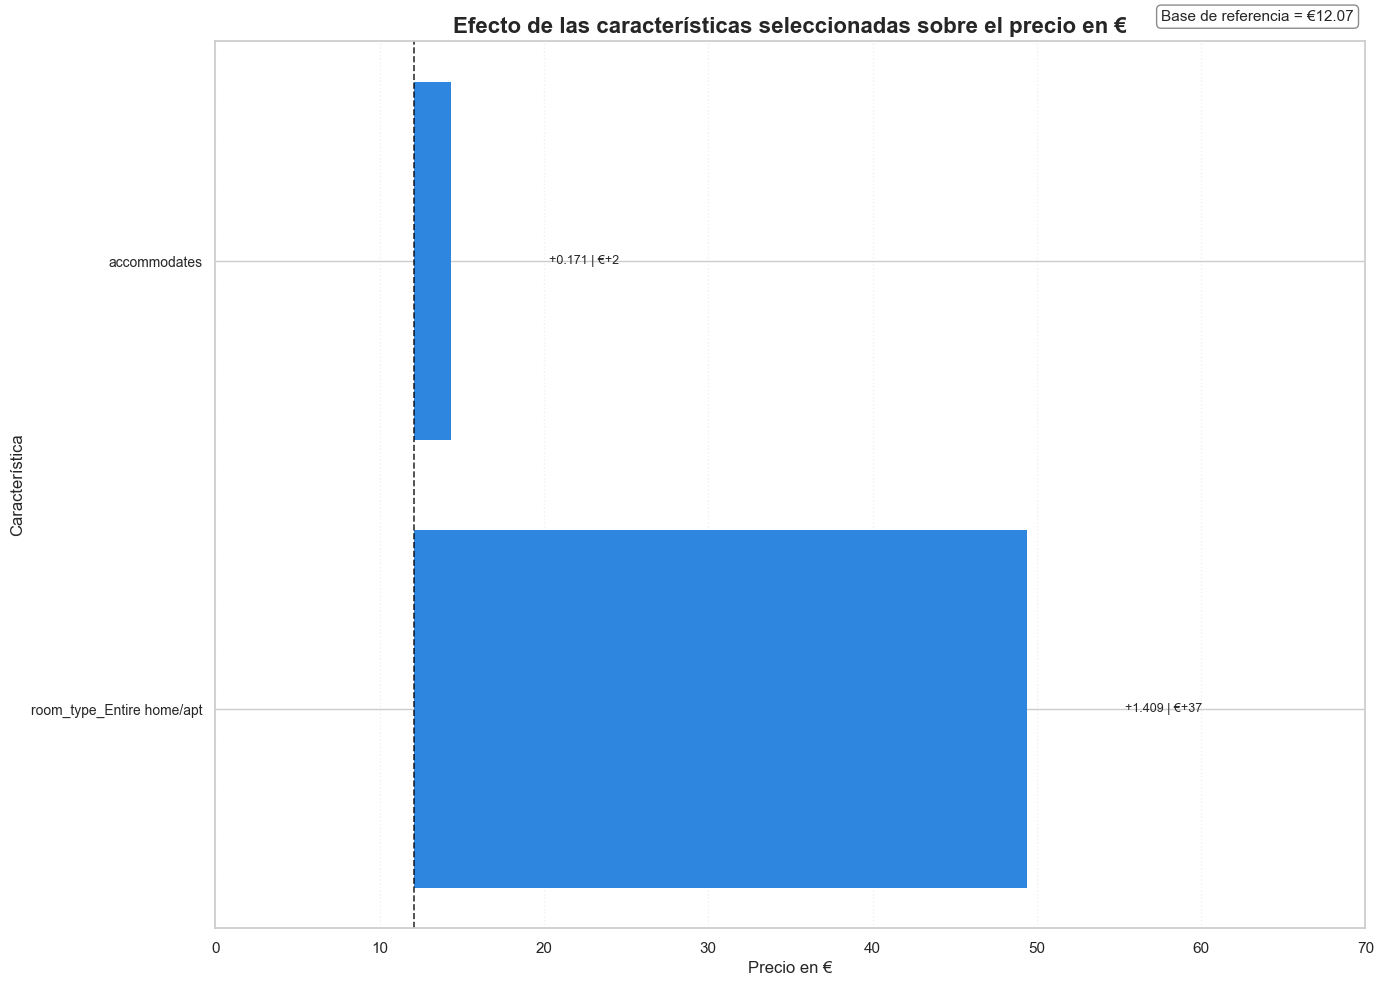

In [292]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------
# Input data
# -------------------------------------------------
data = [
    ("accommodates", 0.1710),
    ("room_type_Entire home/apt", 1.4088),

]

intercept = 2.4908                  

            
# -------------------------------------------------
# Data prep
# -------------------------------------------------
features_df = pd.DataFrame(data, columns=["feature", "coef"])

# Baseline price in euro from intercept
baseline_eur = np.exp(intercept)

# Euro effect of each feature relative to baseline
# Interpretation: price change in € when feature is present
features_df["euro_delta"] = baseline_eur * (np.exp(features_df["coef"]) - 1)

features_df["effect"] = np.where(features_df["euro_delta"] >= 0, "positive", "negative")
features_df["abs_euro_delta"] = features_df["euro_delta"].abs()

# Order by signed euro effect, positives first, negatives after
df_pos = features_df[features_df["euro_delta"] >= 0].sort_values("euro_delta", ascending=True)
df_neg = features_df[features_df["euro_delta"] < 0].sort_values("euro_delta", ascending=False)
plot_df = pd.concat([df_pos, df_neg], ignore_index=True)

# X positions centered on intercept in euro
plot_df["x_left"] = np.where(
    plot_df["euro_delta"] >= 0,
    baseline_eur,
    baseline_eur + plot_df["euro_delta"]
)
plot_df["bar_width"] = plot_df["euro_delta"].abs()

# Labels
plot_df["label"] = plot_df.apply(
    lambda r: f'{r["coef"]:+.3f} | €{r["euro_delta"]:+.0f}',
    axis=1
)

# Colors
colors = plot_df["euro_delta"].apply(lambda x: "#2E86DE" if x >= 0 else "#E74C3C")

# -------------------------------------------------
# Plot
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 10))

y = np.arange(len(plot_df))

ax.barh(
    y,
    plot_df["bar_width"],
    left=plot_df["x_left"],
    color=colors,
    edgecolor="none"
)

# Reference line at intercept in euro, not at zero
ax.axvline(baseline_eur, color="black", linewidth=1.2, linestyle="--", alpha=0.8)

# Y labels
ax.set_yticks(y)
ax.set_yticklabels(plot_df["feature"], fontsize=10)

# Value labels
for i, row in plot_df.iterrows():
    x_end = row["x_left"] + row["bar_width"] if row["euro_delta"] >= 0 else row["x_left"]
    if row["euro_delta"] >= 0:
        ax.text(x_end + 6, i, row["label"], va="center", ha="left", fontsize=9)
    else:
        ax.text(x_end - 6, i, row["label"], va="center", ha="right", fontsize=9)

# Title and axes
ax.set_title(
    "Efecto de las características seleccionadas sobre el precio en €",
    fontsize=16,
    weight="bold"
)
ax.set_xlabel("Precio en €")
ax.set_ylabel("Característica")

# X axis fixed range
ax.set_xlim(0, 70)

# Intercept annotation
ax.text(
    0.99, 1.02,
    f"Base de referencia = €{baseline_eur:.2f}",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.9)
)

# Style
ax.invert_yaxis()
ax.grid(axis="x", linestyle=":", alpha=0.3)

plt.tight_layout()
plt.show()

##### **Results Menorca ~ General**

From three modelling approaches, Ordinary Least Squares (OLS) regression demonstrated the highest r2 = 0.748214.
Based on VIF estimation, the following features had highest collinearity:
    feature	VIF
3	bedrooms	inf
2	bathrooms	inf
0	accommodates	31.522289
1	beds	13.869425
7	washer	13.235079
14	essentials	9.461980

"accommodates", "bedrooms", "bathrooms" and "beds" represent Capacity characteristics of the accommodation, being highly colinear. It is proposed to use for further estimations **"accommodates"** only.
"washer", "essentials"  may be omitted from modelling, as being colinear with another features, and estimated with p>0.05 in OLS model.
Also, features with very low effect size (coef) were omited.

Features with accepted VIF and p<0.05 were:
#--------------------------------------------------------------------------------------------------------
                                           coef    std err          t      P>|t|      [0.025      0.975]
#--------------------------------------------------------------------------------------------------------
const                                    2.4908      1.060      2.350      0.022       0.370       4.611
accommodates                             0.1710      0.070      2.452      0.017       0.031       0.311
room_type_Entire home/apt                1.4088      0.587      2.401      0.019       0.235       2.582


##### **Analysis Menorca ~ Entire home/apt**

In [ ]:
outdir = Path("output_Menorca_Entire")
outdir.mkdir(exist_ok=True)

In [ ]:
log("Starting data preparation")

price_orig = "price"
target = "price_log2"
id_cols = ["apartment_id", "host_id", "insert_date"]
location = ["city", "neighbourhood_district", "neighbourhood_name"]
df_model = df[(df["city"] == 'menorca') & (df["room_type"] == "Entire home/apt")].copy()

X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
y = df_model[target].astype(float)

list_cols = [c for c in X.columns if X[c].apply(lambda v: isinstance(v, list)).any()]
if list_cols:
    log(f"Dropping list-valued columns: {list_cols}")
    X = X.drop(columns=list_cols)

num_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

X[num_cols] = X[num_cols].apply(lambda s: s.astype(float) if s.dtype == "bool" else s)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")
log(f"Numeric cols: {len(num_cols)}, Categorical cols: {len(cat_cols)}")

[14:52:40] Starting data preparation
[14:52:40] Train rows: 124, Test rows: 32
[14:52:40] Numeric cols: 261, Categorical cols: 1


In [ ]:
log("Building preprocessors")

preprocess_rf = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

preprocess_enet = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

log("Preprocessors ready")

[14:53:10] Building preprocessors
[14:53:10] Preprocessors ready


In [ ]:
log("Fitting Random Forest")

rf = Pipeline(steps=[
    ("preprocess", preprocess_rf),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        max_depth=12,
        min_samples_leaf=5,
        max_features="sqrt"
    ))
])

t0 = time.time()
rf.fit(X_train, y_train)
log(f"Random Forest fit completed in {time.time() - t0:.1f}s")

rf_pred = rf.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
log(f"RF test RMSE={rf_rmse:.4f}, R2={rf_r2:.4f}")

[14:53:21] Fitting Random Forest
[14:53:22] Random Forest fit completed in 0.8s
[14:53:22] RF test RMSE=0.8849, R2=0.2577


In [ ]:
log("Computing permutation importance")

X_test_trans = rf.named_steps["preprocess"].transform(X_test)
feature_names = rf.named_steps["preprocess"].get_feature_names_out()

t0 = time.time()
perm = permutation_importance(
    rf.named_steps["model"],
    X_test_trans,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)
log(f"Permutation importance completed in {time.time() - t0:.1f}s")

rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

rf_importance.to_csv(outdir / "rf_permutation_importance.csv", index=False)
log("Saved RF importance to output/rf_permutation_importance.csv")

display(rf_importance.head(20))

[14:53:33] Computing permutation importance
[14:55:02] Permutation importance completed in 89.5s
[14:55:03] Saved RF importance to output/rf_permutation_importance.csv


,feature,importance_mean,importance_std
2,bedrooms,0.088148,0.026934
0,accommodates,0.086747,0.014199
1,bathrooms,0.067519,0.019483
3,beds,0.021703,0.010927
213,washer,0.018178,0.001831
243,Safety & Security_x,0.013038,0.001916
84,first aid kit,0.010834,0.007679
253,Laundry & Housekeeping_y,0.008051,0.001316
92,free parking on street,0.006996,0.002356
254,Luxury & Premium_y,0.006611,0.008519


In [ ]:
log("Fitting Elastic Net")

enet_pipe = Pipeline(steps=[
    ("preprocess", preprocess_enet),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9],
        alphas=np.logspace(-4, 1, 30),
        cv=5,
        random_state=42,
        max_iter=10000
    ))
])

t0 = time.time()
enet_pipe.fit(X_train, y_train)
log(f"Elastic Net fit completed in {time.time() - t0:.1f}s")

enet = enet_pipe.named_steps["model"]
enet_pred = enet_pipe.predict(X_test)
enet_rmse = np.sqrt(mean_squared_error(y_test, enet_pred))

enet_r2 = r2_score(y_test, enet_pred)

enet_features = enet_pipe.named_steps["preprocess"].get_feature_names_out()
enet_coefs = pd.DataFrame({
    "feature": enet_features,
    "coef": enet.coef_
})
enet_coefs["abs_coef"] = enet_coefs["coef"].abs()
enet_selected = enet_coefs[enet_coefs["coef"] != 0].sort_values("abs_coef", ascending=False)

enet_coefs.to_csv(outdir / "elastic_net_coefficients.csv", index=False)
log("Saved Elastic Net coefficients to output/elastic_net_coefficients.csv")

log(f"Elastic Net chosen alpha={enet.alpha_:.6f}, l1_ratio={enet.l1_ratio_}")
log(f"EN test RMSE={enet_rmse:.4f}, R2={enet_r2:.4f}")

display(enet_selected.head(30))

[14:55:39] Fitting Elastic Net
[14:56:25] Elastic Net fit completed in 46.3s
[14:56:26] Saved Elastic Net coefficients to output/elastic_net_coefficients.csv
[14:56:26] Elastic Net chosen alpha=0.188739, l1_ratio=0.9
[14:56:26] EN test RMSE=0.8704, R2=0.2818


,feature,coef,abs_coef
0,accommodates,0.186286,0.186286
1,bathrooms,0.109211,0.109211
2,bedrooms,0.108283,0.108283
58,dishes and silverware,-0.056816,0.056816
238,Laundry & Housekeeping_x,0.021629,0.021629


In [ ]:
log("Preparing VIF check")

top_rf = rf_importance["feature"].head(25).tolist()
top_en = enet_selected["feature"].head(25).tolist()

candidate_features = list(dict.fromkeys(top_rf + top_en))
log(f"Initial candidate features from RF + EN: {len(candidate_features)}")

base_cols = []
for f in candidate_features:
    base = f.split("_")[0] if "_" in f else f
    if base in X_train.columns:
        base_cols.append(base)

base_cols = list(dict.fromkeys(base_cols))
log(f"Base columns kept for VIF: {base_cols}")

X_vif = X_train[base_cols].copy()
X_vif = pd.get_dummies(X_vif, drop_first=True)

for c in X_vif.columns:
    if X_vif[c].dtype == "bool":
        X_vif[c] = X_vif[c].astype(int)

X_vif = X_vif.fillna(X_vif.median(numeric_only=True))

log(f"VIF matrix shape: {X_vif.shape}")

vif_data = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

vif_data.to_csv(outdir / "vif_results.csv", index=False)
log("Saved VIF results to output/vif_results.csv")

display(vif_data.head(30))

[14:56:59] Preparing VIF check
[14:56:59] Initial candidate features from RF + EN: 27
[14:56:59] Base columns kept for VIF: ['bedrooms', 'accommodates', 'bathrooms', 'beds', 'washer', 'first aid kit', 'free parking on street', 'fire extinguisher', 'dryer', 'iron', 'air conditioning', 'shampoo', 'private entrance', 'free parking on premises', 'garden or backyard', 'heating', 'dishwasher', 'long term stays allowed', 'dishes and silverware']
[14:56:59] VIF matrix shape: (124, 19)
[14:56:59] Saved VIF results to output/vif_results.csv


,feature,VIF
0,bedrooms,inf
2,bathrooms,inf
1,accommodates,38.428618
3,beds,12.708376
4,washer,12.619600
9,iron,5.591374
18,dishes and silverware,3.827126
10,air conditioning,3.245284
16,dishwasher,2.792626
7,fire extinguisher,2.790449


In [ ]:
log("Fitting Gamma GLM with log link")

glm_X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
glm_list_cols = [c for c in glm_X.columns if glm_X[c].apply(lambda v: isinstance(v, list)).any()]
if glm_list_cols:
    log(f"Dropping list-valued columns from GLM: {glm_list_cols}")
    glm_X = glm_X.drop(columns=glm_list_cols)

glm_num_cols = glm_X.select_dtypes(include=["number", "bool"]).columns.tolist()
glm_cat_cols = glm_X.select_dtypes(include=["object", "category"]).columns.tolist()

glm_preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), glm_num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), glm_cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

t0 = time.time()
X_glm = glm_preprocess.fit_transform(glm_X)
log(f"GLM preprocessing completed in {time.time() - t0:.1f}s")

glm_feature_names = glm_preprocess.get_feature_names_out()
X_glm_df = pd.DataFrame(X_glm, columns=glm_feature_names, index=df_model.index)
X_glm_df = sm.add_constant(X_glm_df, has_constant="add")

y_glm = df_model[target].astype(float)

t0 = time.time()
gamma_model = sm.GLM(
    y_glm,
    X_glm_df,
    family=sm.families.Gamma(link=sm.families.links.log())
).fit()
log(f"Gamma GLM fit completed in {time.time() - t0:.1f}s")

with open(outdir / "gamma_glm_summary.txt", "w", encoding="utf-8") as f:
    f.write(gamma_model.summary().as_text())

log("Saved Gamma GLM summary to output/gamma_glm_summary.txt")
print(gamma_model.summary())

[14:57:06] Fitting Gamma GLM with log link
[14:57:06] GLM preprocessing completed in 0.1s
[14:57:07] Gamma GLM fit completed in 0.4s
[14:57:07] Saved Gamma GLM summary to output/gamma_glm_summary.txt
                 Generalized Linear Model Regression Results                  
Dep. Variable:             price_log2   No. Observations:                  156
Model:                            GLM   Df Residuals:                       40
Model Family:                   Gamma   Df Model:                          115
Link Function:                    log   Scale:                       0.0066274
Method:                          IRLS   Log-Likelihood:                -136.34
Date:                Fri, 05 Jun 2026   Deviance:                      0.26262
Time:                        14:57:07   Pearson chi2:                    0.265
No. Iterations:                    10   Pseudo R-squ. (CS):             0.6862
Covariance Type:            nonrobust                                         
          

In [ ]:
log("Fitting OLS on log(price)")

if "price" in df_model.columns:
    y_lin = np.log(df_model["price"].astype(float))
    X_lin = X_glm_df.copy()

    t0 = time.time()
    lin_model = sm.OLS(y_lin, X_lin).fit()
    log(f"OLS fit completed in {time.time() - t0:.1f}s")

    with open(outdir / "ols_logprice_summary.txt", "w", encoding="utf-8") as f:
        f.write(lin_model.summary().as_text())

    log("Saved OLS summary to output/ols_logprice_summary.txt")
    print(lin_model.summary())
else:
    lin_model = None
    log("No raw price column found; skipping OLS on log(price)")

[14:57:11] Fitting OLS on log(price)
[14:57:11] OLS fit completed in 0.0s
[14:57:11] Saved OLS summary to output/ols_logprice_summary.txt
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.833
Model:                            OLS   Adj. R-squared:                  0.354
Method:                 Least Squares   F-statistic:                     1.737
Date:                Fri, 05 Jun 2026   Prob (F-statistic):             0.0239
Time:                        14:57:11   Log-Likelihood:                -20.189
No. Observations:                 156   AIC:                             272.4
Df Residuals:                      40   BIC:                             626.2
Df Model:                         115                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t   

In [ ]:
log("Building comparison table")

results = pd.DataFrame([
    {"model": "Random Forest", "rmse": rf_rmse, "r2": rf_r2},
    {"model": "Elastic Net", "rmse": enet_rmse, "r2": enet_r2},
])

if lin_model is not None:
    results = pd.concat([
        results,
        pd.DataFrame([{
            "model": "OLS log(price)",
            "rmse": np.nan,
            "r2": lin_model.rsquared
        }])
    ], ignore_index=True)

results.to_csv(outdir / "model_comparison.csv", index=False)
log("Saved comparison table to output/model_comparison.csv")
display(results)

[14:57:16] Building comparison table
[14:57:16] Saved comparison table to output/model_comparison.csv


,model,rmse,r2
0,Random Forest,0.884852,0.257741
1,Elastic Net,0.870394,0.281800
2,OLS log(price),NaN,0.833185


##### **Results Menorca ~ Entire home/apt**

##### **Analysis Menorca ~ Private room**

In [ ]:
outdir = Path("output_Malaga_Private")
outdir.mkdir(exist_ok=True)

In [ ]:
log("Starting data preparation")

price_orig = "price"
target = "price_log2"
id_cols = ["apartment_id", "host_id", "insert_date"]
location = ["city", "neighbourhood_district", "neighbourhood_name"]
df_model = df[(df["city"] == 'malaga') & (df["room_type"] == "Private room")].copy()

X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
y = df_model[target].astype(float)

list_cols = [c for c in X.columns if X[c].apply(lambda v: isinstance(v, list)).any()]
if list_cols:
    log(f"Dropping list-valued columns: {list_cols}")
    X = X.drop(columns=list_cols)

num_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

X[num_cols] = X[num_cols].apply(lambda s: s.astype(float) if s.dtype == "bool" else s)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")
log(f"Numeric cols: {len(num_cols)}, Categorical cols: {len(cat_cols)}")

[14:59:17] Starting data preparation
[14:59:26] Train rows: 50, Test rows: 13
[14:59:26] Numeric cols: 261, Categorical cols: 1


In [ ]:
log("Building preprocessors")

preprocess_rf = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

preprocess_enet = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

log("Preprocessors ready")

[14:59:45] Building preprocessors
[14:59:45] Preprocessors ready


In [ ]:
log("Fitting Random Forest")

rf = Pipeline(steps=[
    ("preprocess", preprocess_rf),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        max_depth=12,
        min_samples_leaf=5,
        max_features="sqrt"
    ))
])

t0 = time.time()
rf.fit(X_train, y_train)
log(f"Random Forest fit completed in {time.time() - t0:.1f}s")

rf_pred = rf.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
log(f"RF test RMSE={rf_rmse:.4f}, R2={rf_r2:.4f}")

[15:00:12] Fitting Random Forest
[15:00:16] Random Forest fit completed in 4.1s
[15:00:17] RF test RMSE=0.6419, R2=-0.0695


In [ ]:
log("Computing permutation importance")

X_test_trans = rf.named_steps["preprocess"].transform(X_test)
feature_names = rf.named_steps["preprocess"].get_feature_names_out()

t0 = time.time()
perm = permutation_importance(
    rf.named_steps["model"],
    X_test_trans,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)
log(f"Permutation importance completed in {time.time() - t0:.1f}s")

rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

rf_importance.to_csv(outdir / "rf_permutation_importance.csv", index=False)
log("Saved RF importance to output/rf_permutation_importance.csv")

display(rf_importance.head(20))

[15:00:30] Computing permutation importance
[15:04:04] Permutation importance completed in 213.8s
[15:04:04] Saved RF importance to output/rf_permutation_importance.csv


,feature,importance_mean,importance_std
92,free parking on street,0.025444,0.018874
0,accommodates,0.006005,0.010290
235,Family & Pets_x,0.005958,0.006513
118,iron,0.004519,0.006010
253,Laundry & Housekeeping_y,0.003164,0.002023
188,smoking allowed,0.003082,0.001090
210,tv,0.003051,0.001367
131,microwave,0.002763,0.002398
252,Kitchen & Dining_y,0.002466,0.002268
159,pool,0.001893,0.009689


In [ ]:
log("Fitting Elastic Net")

enet_pipe = Pipeline(steps=[
    ("preprocess", preprocess_enet),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9],
        alphas=np.logspace(-4, 1, 30),
        cv=5,
        random_state=42,
        max_iter=10000
    ))
])

t0 = time.time()
enet_pipe.fit(X_train, y_train)
log(f"Elastic Net fit completed in {time.time() - t0:.1f}s")

enet = enet_pipe.named_steps["model"]
enet_pred = enet_pipe.predict(X_test)
enet_rmse = np.sqrt(mean_squared_error(y_test, enet_pred))

enet_r2 = r2_score(y_test, enet_pred)

enet_features = enet_pipe.named_steps["preprocess"].get_feature_names_out()
enet_coefs = pd.DataFrame({
    "feature": enet_features,
    "coef": enet.coef_
})
enet_coefs["abs_coef"] = enet_coefs["coef"].abs()
enet_selected = enet_coefs[enet_coefs["coef"] != 0].sort_values("abs_coef", ascending=False)

enet_coefs.to_csv(outdir / "elastic_net_coefficients.csv", index=False)
log("Saved Elastic Net coefficients to output/elastic_net_coefficients.csv")

log(f"Elastic Net chosen alpha={enet.alpha_:.6f}, l1_ratio={enet.l1_ratio_}")
log(f"EN test RMSE={enet_rmse:.4f}, R2={enet_r2:.4f}")

display(enet_selected.head(30))

[15:06:41] Fitting Elastic Net
[15:06:53] Elastic Net fit completed in 11.5s
[15:06:53] Saved Elastic Net coefficients to output/elastic_net_coefficients.csv
[15:06:53] Elastic Net chosen alpha=0.188739, l1_ratio=0.5
[15:06:53] EN test RMSE=0.6737, R2=-0.1783


,feature,coef,abs_coef
30,breakfast,0.137570,0.137570
0,accommodates,0.118716,0.118716
109,heating,0.091633,0.091633
97,garden or backyard,0.067320,0.067320
7,air conditioning,0.056813,0.056813
112,hot tub,0.056399,0.056399
216,wheelchair accessible,0.042359,0.042359
127,lockbox,-0.028275,0.028275
246,Accessibility_y,-0.023351,0.023351
118,iron,-0.015206,0.015206


In [ ]:
log("Preparing VIF check")

top_rf = rf_importance["feature"].head(25).tolist()
top_en = enet_selected["feature"].head(25).tolist()

candidate_features = list(dict.fromkeys(top_rf + top_en))
log(f"Initial candidate features from RF + EN: {len(candidate_features)}")

base_cols = []
for f in candidate_features:
    base = f.split("_")[0] if "_" in f else f
    if base in X_train.columns:
        base_cols.append(base)

base_cols = list(dict.fromkeys(base_cols))
log(f"Base columns kept for VIF: {base_cols}")

X_vif = X_train[base_cols].copy()
X_vif = pd.get_dummies(X_vif, drop_first=True)

for c in X_vif.columns:
    if X_vif[c].dtype == "bool":
        X_vif[c] = X_vif[c].astype(int)

X_vif = X_vif.fillna(X_vif.median(numeric_only=True))

log(f"VIF matrix shape: {X_vif.shape}")

vif_data = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

vif_data.to_csv(outdir / "vif_results.csv", index=False)
log("Saved VIF results to output/vif_results.csv")

display(vif_data.head(30))

[15:07:00] Preparing VIF check
[15:07:00] Initial candidate features from RF + EN: 39
[15:07:00] Base columns kept for VIF: ['free parking on street', 'accommodates', 'iron', 'smoking allowed', 'tv', 'microwave', 'pool', 'hair dryer', 'paid parking on premises', 'shampoo', 'hot water', 'fire extinguisher', 'extra pillows and blankets', 'stove', 'kitchen', 'patio or balcony', 'free parking on premises', 'smoke detector', 'bedrooms', 'breakfast', 'heating', 'garden or backyard', 'air conditioning', 'hot tub', 'wheelchair accessible', 'lockbox', 'accessible-height toilet', 'washer', "children's books and toys", 'dedicated workspace']
[15:07:00] VIF matrix shape: (50, 30)
[15:07:00] Saved VIF results to output/vif_results.csv


,feature,VIF
18,bedrooms,21.108410
7,hair dryer,18.756234
14,kitchen,18.497005
27,washer,18.248264
4,tv,15.099325
1,accommodates,13.865751
2,iron,12.064242
25,lockbox,10.268774
13,stove,9.318761
12,extra pillows and blankets,9.245953


In [ ]:
log("Fitting Gamma GLM with log link")

glm_X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
glm_list_cols = [c for c in glm_X.columns if glm_X[c].apply(lambda v: isinstance(v, list)).any()]
if glm_list_cols:
    log(f"Dropping list-valued columns from GLM: {glm_list_cols}")
    glm_X = glm_X.drop(columns=glm_list_cols)

glm_num_cols = glm_X.select_dtypes(include=["number", "bool"]).columns.tolist()
glm_cat_cols = glm_X.select_dtypes(include=["object", "category"]).columns.tolist()

glm_preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), glm_num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), glm_cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

t0 = time.time()
X_glm = glm_preprocess.fit_transform(glm_X)
log(f"GLM preprocessing completed in {time.time() - t0:.1f}s")

glm_feature_names = glm_preprocess.get_feature_names_out()
X_glm_df = pd.DataFrame(X_glm, columns=glm_feature_names, index=df_model.index)
X_glm_df = sm.add_constant(X_glm_df, has_constant="add")

y_glm = df_model[target].astype(float)

t0 = time.time()
gamma_model = sm.GLM(
    y_glm,
    X_glm_df,
    family=sm.families.Gamma(link=sm.families.links.log())
).fit()
log(f"Gamma GLM fit completed in {time.time() - t0:.1f}s")

with open(outdir / "gamma_glm_summary.txt", "w", encoding="utf-8") as f:
    f.write(gamma_model.summary().as_text())

log("Saved Gamma GLM summary to output/gamma_glm_summary.txt")
print(gamma_model.summary())

[15:07:10] Fitting Gamma GLM with log link
[15:07:13] GLM preprocessing completed in 0.2s
[15:07:14] Gamma GLM fit completed in 0.2s
[15:07:17] Saved Gamma GLM summary to output/gamma_glm_summary.txt
                 Generalized Linear Model Regression Results                  
Dep. Variable:             price_log2   No. Observations:                   63
Model:                            GLM   Df Residuals:                        0
Model Family:                   Gamma   Df Model:                           62
Link Function:                    log   Scale:                             inf
Method:                          IRLS   Log-Likelihood:                    nan
Date:                Fri, 05 Jun 2026   Deviance:                   0.00016283
Time:                        15:07:17   Pearson chi2:                 0.000162
No. Iterations:                     1   Pseudo R-squ. (CS):                nan
Covariance Type:            nonrobust                                         
          

In [ ]:
log("Fitting OLS on log(price)")

if "price" in df_model.columns:
    y_lin = np.log(df_model["price"].astype(float))
    X_lin = X_glm_df.copy()

    t0 = time.time()
    lin_model = sm.OLS(y_lin, X_lin).fit()
    log(f"OLS fit completed in {time.time() - t0:.1f}s")

    with open(outdir / "ols_logprice_summary.txt", "w", encoding="utf-8") as f:
        f.write(lin_model.summary().as_text())

    log("Saved OLS summary to output/ols_logprice_summary.txt")
    print(lin_model.summary())
else:
    lin_model = None
    log("No raw price column found; skipping OLS on log(price)")

[15:07:23] Fitting OLS on log(price)
[15:07:23] OLS fit completed in 0.1s
[15:07:26] Saved OLS summary to output/ols_logprice_summary.txt
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Fri, 05 Jun 2026   Prob (F-statistic):                nan
Time:                        15:07:26   Log-Likelihood:                 1769.4
No. Observations:                  63   AIC:                            -3413.
Df Residuals:                       0   BIC:                            -3278.
Df Model:                          62                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t   

In [ ]:
log("Building comparison table")

results = pd.DataFrame([
    {"model": "Random Forest", "rmse": rf_rmse, "r2": rf_r2},
    {"model": "Elastic Net", "rmse": enet_rmse, "r2": enet_r2},
])

if lin_model is not None:
    results = pd.concat([
        results,
        pd.DataFrame([{
            "model": "OLS log(price)",
            "rmse": np.nan,
            "r2": lin_model.rsquared
        }])
    ], ignore_index=True)

results.to_csv(outdir / "model_comparison.csv", index=False)
log("Saved comparison table to output/model_comparison.csv")
display(results)

[15:07:34] Building comparison table
[15:07:34] Saved comparison table to output/model_comparison.csv


,model,rmse,r2
0,Random Forest,0.641859,-0.069500
1,Elastic Net,0.673704,-0.178255
2,OLS log(price),NaN,1.000000


##### **Results Menorca ~ Private room**
- Insufficient data to perform modelling

##### **Analysis Menorca ~ Hotel room**

In [ ]:
outdir = Path("output_Menorca_Hotel")
outdir.mkdir(exist_ok=True)

In [ ]:
log("Starting data preparation")

price_orig = "price"
target = "price_log2"
id_cols = ["apartment_id", "host_id", "insert_date"]
location = ["city", "neighbourhood_district", "neighbourhood_name"]
df_model = df[(df["city"] == 'menorca') & (df["room_type"] == "Hotel room")].copy()

X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
y = df_model[target].astype(float)

list_cols = [c for c in X.columns if X[c].apply(lambda v: isinstance(v, list)).any()]
if list_cols:
    log(f"Dropping list-valued columns: {list_cols}")
    X = X.drop(columns=list_cols)

num_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

X[num_cols] = X[num_cols].apply(lambda s: s.astype(float) if s.dtype == "bool" else s)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")
log(f"Numeric cols: {len(num_cols)}, Categorical cols: {len(cat_cols)}")

[15:09:17] Starting data preparation


ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

##### **Results Menorca ~ Hotel room**
- No data to perform the analysis

##### **Analysis Menorca ~ Shared room**

In [ ]:
outdir = Path("output_Menorca_Shared")
outdir.mkdir(exist_ok=True)

In [ ]:
log("Starting data preparation")

price_orig = "price"
target = "price_log2"
id_cols = ["apartment_id", "host_id", "insert_date"]
location = ["city", "neighbourhood_district", "neighbourhood_name"]
df_model = df[(df["city"] == 'menorca') & (df["room_type"] == "Shared room")].copy()

X = df_model.drop(columns=[target, price_orig] + id_cols + location).copy()
y = df_model[target].astype(float)

list_cols = [c for c in X.columns if X[c].apply(lambda v: isinstance(v, list)).any()]
if list_cols:
    log(f"Dropping list-valued columns: {list_cols}")
    X = X.drop(columns=list_cols)

num_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

X[num_cols] = X[num_cols].apply(lambda s: s.astype(float) if s.dtype == "bool" else s)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")
log(f"Numeric cols: {len(num_cols)}, Categorical cols: {len(cat_cols)}")

[15:14:31] Starting data preparation


ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

##### **Results Menorca ~ Shared room**
- No data to perform the analysis

city

valencia      360
menorca       167

Entire home/apt    5453
Private room       2138
Hotel room           53
Shared room          49

### Description of the Price

In [ ]:
# Price values distribution preview
alojamentos_profile_df.columns

Index(['apartment_id', 'host_id', 'insert_date', 'price', 'room_type', 'city',
       'neighbourhood_name', 'neighbourhood_district', 'accommodates',
       'bathrooms', 'bedrooms', 'beds', 'amenities_list'],
      dtype='object')

Cleaned data set includes 'price' column and is characterised by lack of normal distribution. As it was demonstrated at EDA, log(2) transformation determines symmetric distribution of data

<Axes: >

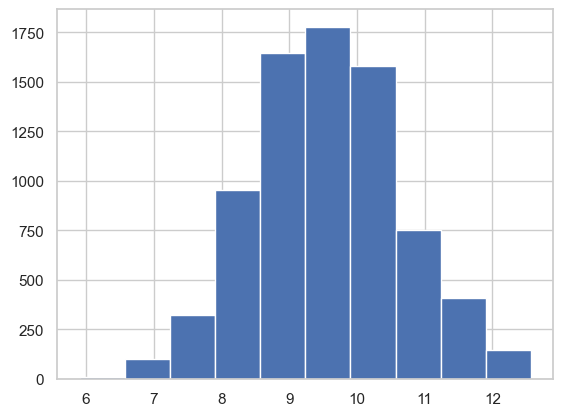

In [ ]:
# Price values LOG transformation for normal distribution preview
np.log2(alojamentos_df["price"]).hist()

In [ ]:
alojamentos_df["price_log"] = np.log2(alojamentos_df["price"])

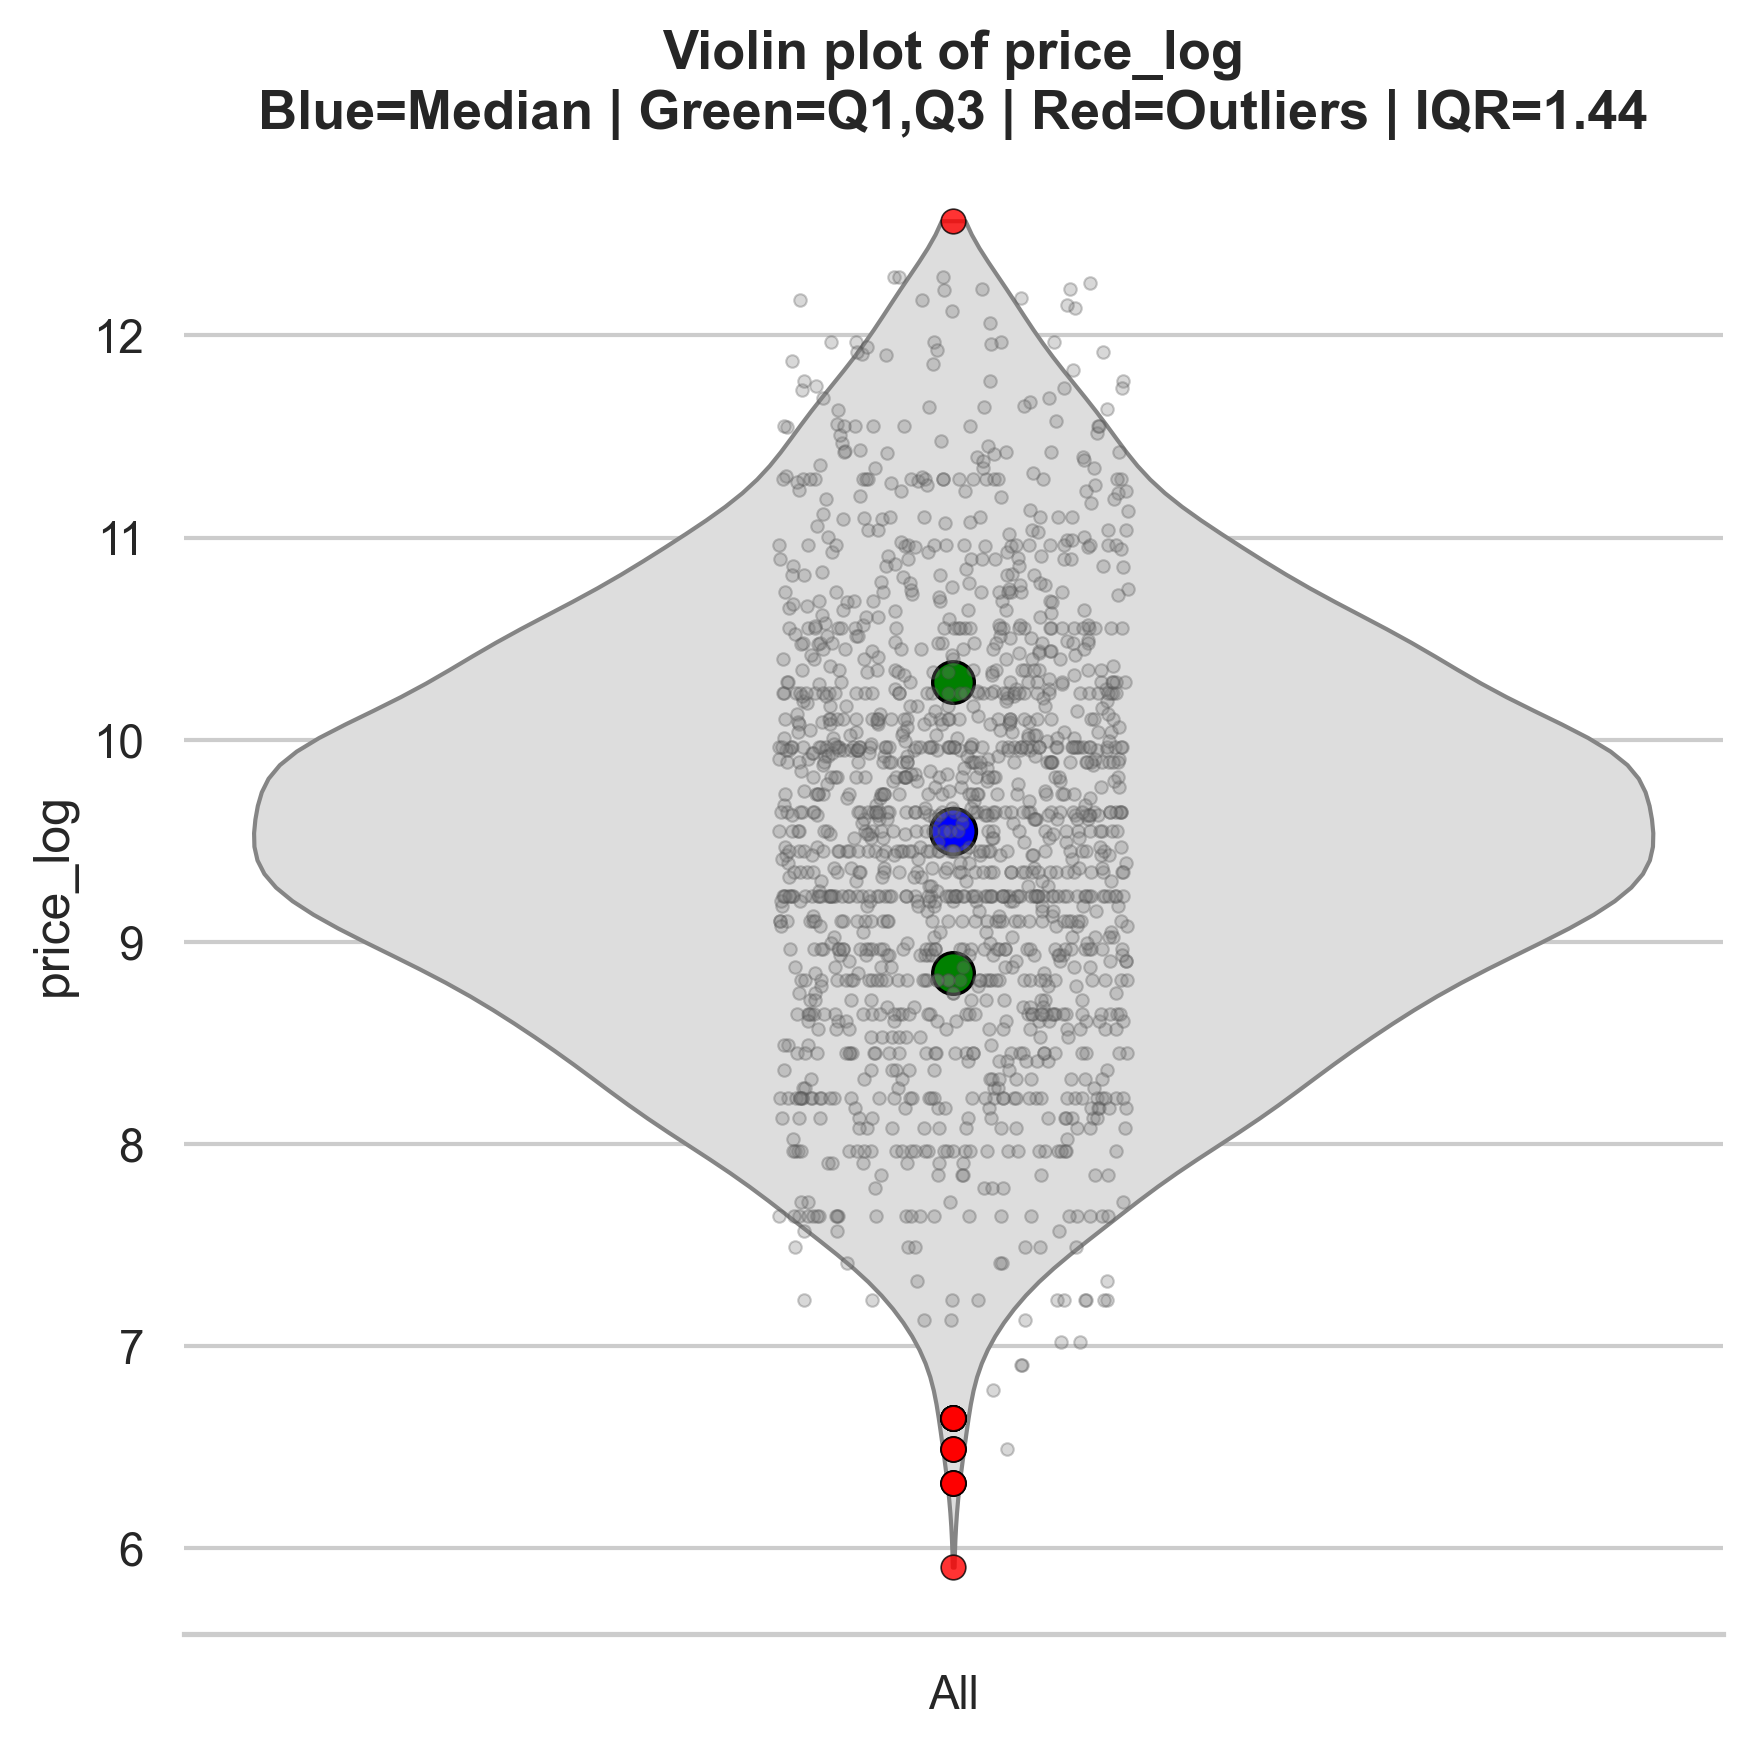

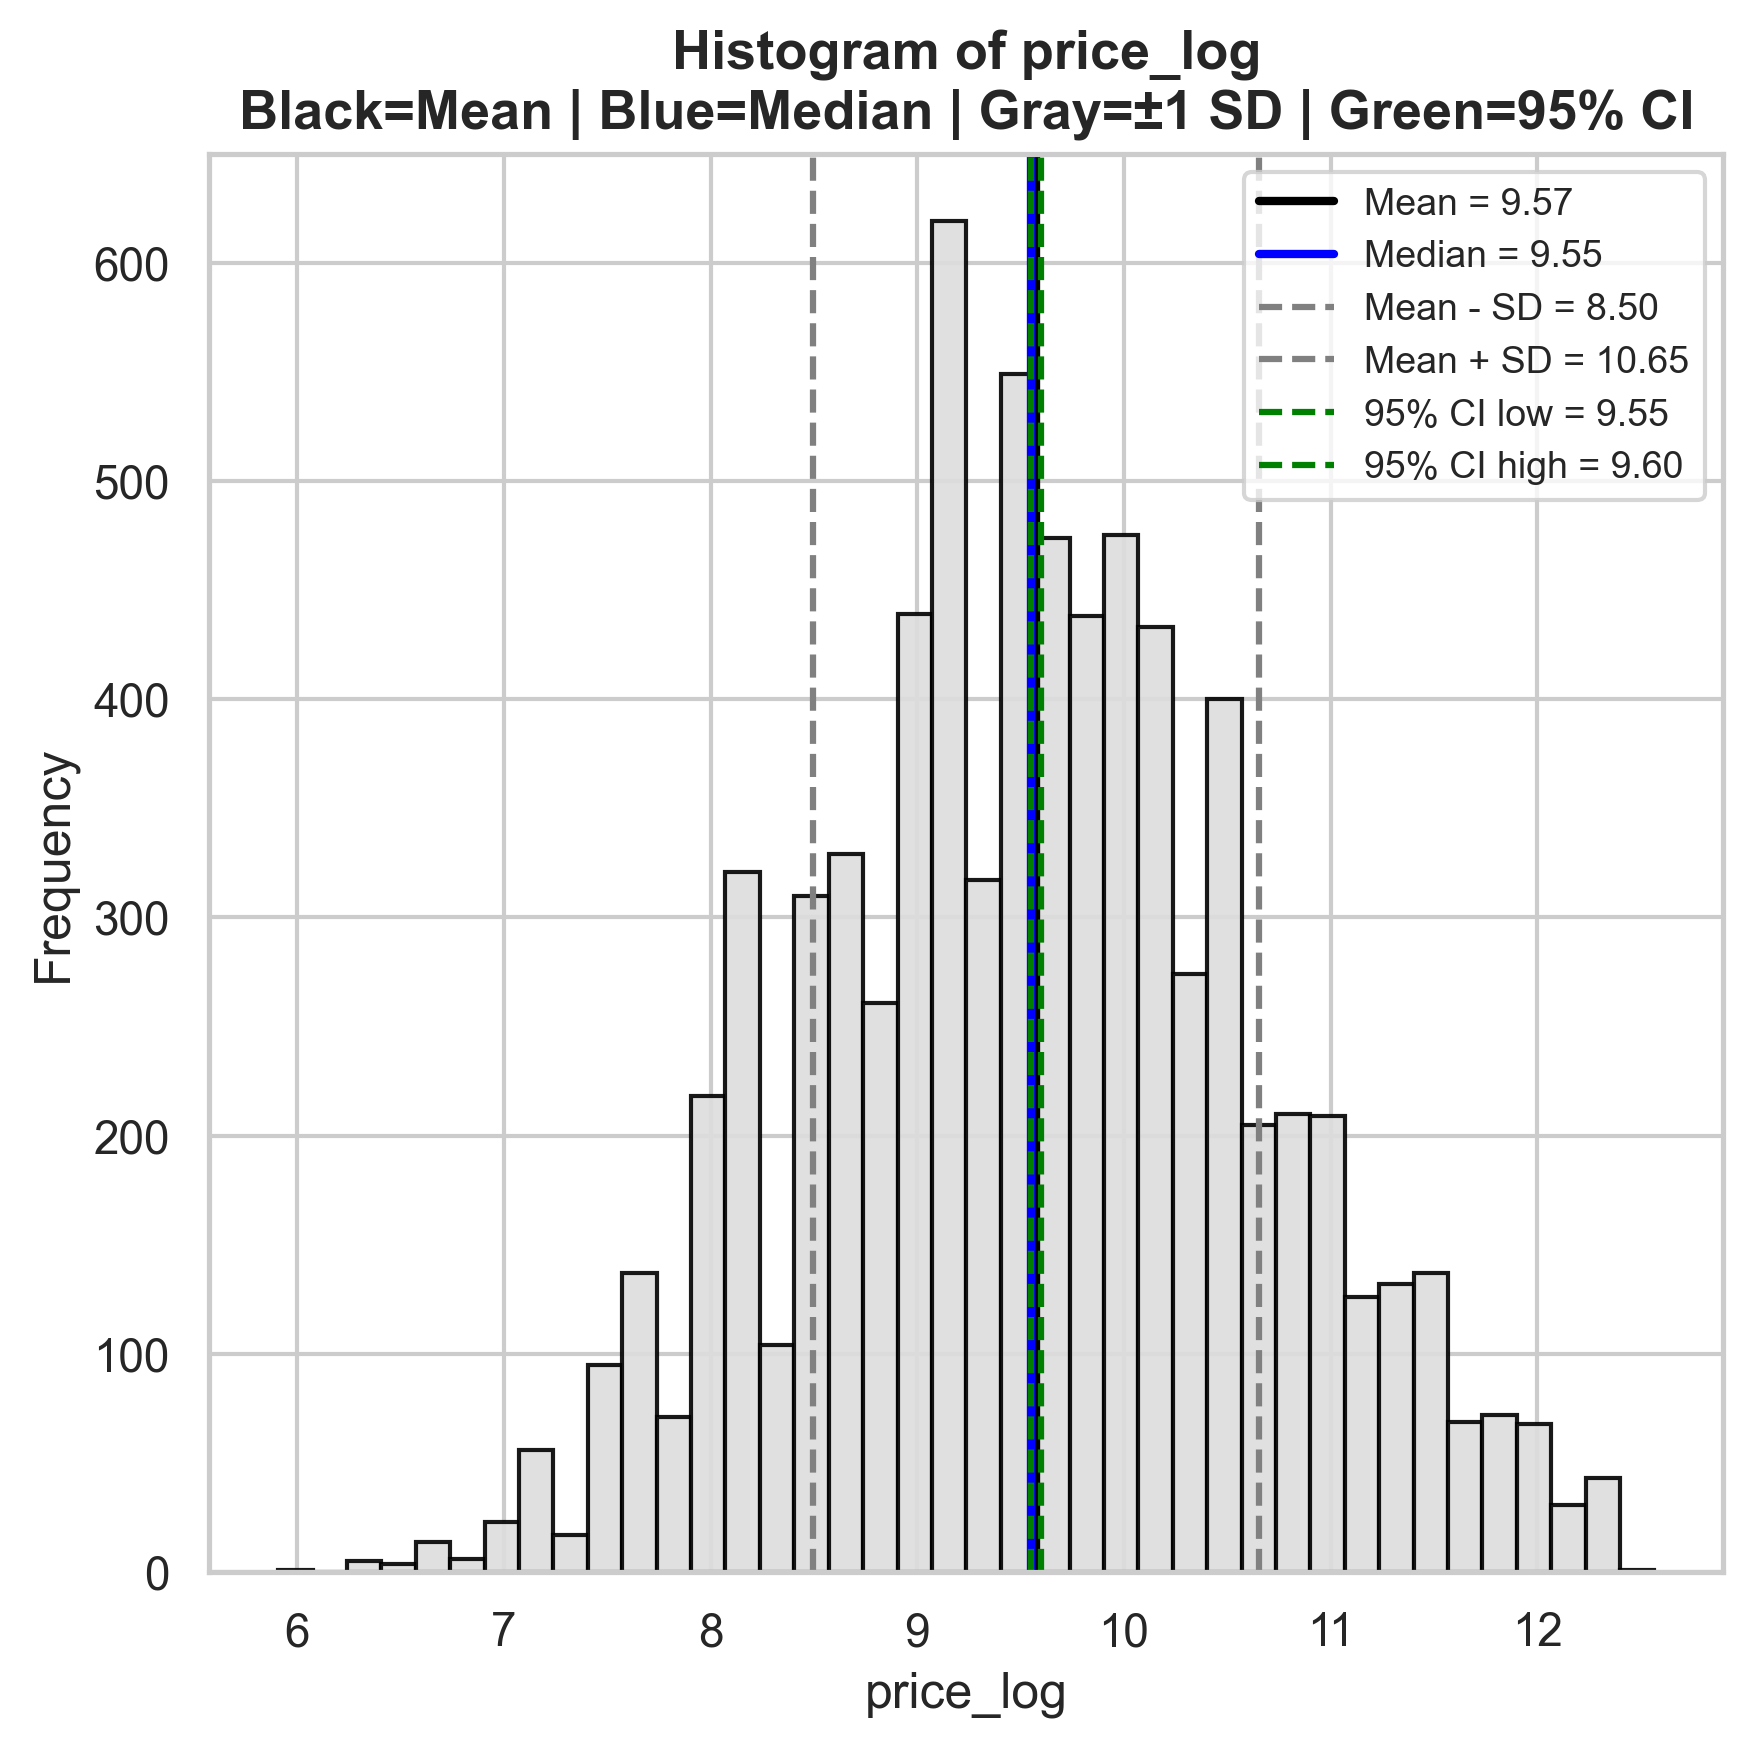

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,price_log,7693,9.574346,9.550747,1.077594,9.550263,9.59843,8.84549,10.287712,1.442222,6.682157,12.451046,25,0.050486,Approximately symmetric.



Unique values table
Number of non-nulls: 7693
Number of unique values: 391


,column,value,count,frequency_non_null
0,price_log,5.906890595608519,1,0.00013
1,price_log,6.321928094887363,5,0.00065
2,price_log,6.491853096329675,4,0.00052
3,price_log,6.643856189774724,14,0.00182
4,price_log,6.78135971352466,6,0.00078
...,...,...,...,...
386,price_log,12.27029532647204,1,0.00013
387,price_log,12.284824100224624,3,0.00039
388,price_log,12.287712379549449,33,0.00429
389,price_log,12.300066509957324,1,0.00013



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,price_log,numeric,apartment_id,numeric,Pearson,-0.002603,0.819445,Not significant,Not statistically significant at p < 0.05.,
1,price_log,numeric,name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,price_log,numeric,description,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
3,price_log,numeric,host_id,numeric,Pearson,-0.020800,0.068113,Not significant,Not statistically significant at p < 0.05.,
4,price_log,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
...,...,...,...,...,...,...,...,...,...,...
267,price_log,numeric,has_table_corner_guards,ordinal,Spearman,NaN,NaN,Not available,P-value not available.,
268,price_log,numeric,has_ev_charger,ordinal,Spearman,NaN,NaN,Not available,P-value not available.,
269,price_log,numeric,has_children�s_dinnerware,ordinal,Spearman,NaN,NaN,Not available,P-value not available.,
270,price_log,numeric,has_wide_entryway,ordinal,Spearman,NaN,NaN,Not available,P-value not available.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,0.050486,Approximately symmetric.,Baseline.
1,Log Transformation,-0.261612,Approximately symmetric.,Did not improve normality; skewness increased.
2,Square Root Transformation,-0.103230,Approximately symmetric.,Little change in skewness.
3,Box-Cox Transformation,-0.006262,Approximately symmetric.,Little change in skewness. Improved using lamb...


In [ ]:
analysis = analyze_single_field(alojamentos_df, 
                                target_col="price_log", 
                                results_dir=RESULTS_DIR, 
                                show_in_notebook=True)

In [ ]:
report = price_analysis_report(alojamentos_df[['name', 'description', 
                                               'neighbourhood_name',
       'neighbourhood_district', 'room_type', 'accommodates', 'bathrooms',
       'bedrooms', 'beds', 'price','city', 'price_log']])

## Accommodation Price Decomposition Analysis

### General Price analysis

As it was revealed, the Price is strongly determined by Location (City, Neighbourhood) and Accommodation type. To evaluate the impact of such components as Amenities, these factors will be excluded to implement Price Decomposition analysis and demonstrate the influence of Amenities and Capacity parameters.

##### Expected outcome:
- Classification of the Amenities in:
    * Basic amenities - represents entry requirements/recommendations for the host to provide when placing the announcement.
    * Value-driving amenities - includes features with measurable association to higher prices.
    * Segment-specific effects - features associated with lower-priced market segments.
- Accommodation + City segmentation of the announcements
- Pricing recommendations with features that support a higher or lower price proposal in each city and room type.
- Platform implementation of Pricing recommendations for hosts: amenities explained as mandatory, other as recommended as a value upgrade, and those that can be left as optional.
- Evidences for future implementation (e.g., amenities classification for Premium segment)

##### Solution elaborated:
- Application of a threshold for the number of cases in each segment:
    * < 30 cases: too unstable; treat only as _descriptive_, not inferential.
    * 30–50 cases: minimum for _exploratory_ insights, but fragile.
    * 50–100 cases: acceptable for cautious _segmentation_.
    * 100+ cases: much better for reliable _comparison and communication_.
    * 200+ cases: strong enough for more _confident marketing guidance_.
    
- Random Forest model to evaluate the importance of each variable for price value, to captures nonlinearities and interactions
- Elastic Net modelling to to evaluate the importance of each variable for price value, as it imposes sparsity and a more linear structure, and cross-validate with the results from RF modelling step
- Elaborate the list of "candidate" variables for further analysis
- VIF estimation to reveal variables with colinearity and codetermination, using the following thresholds: VIF < 5: acceptable; VIF 5–10: possible collinearity concern; VIF > 10: serious concern.
    * Note: Discharge of a variable is done based on it's business significance and VIF > 10 value.
- Comparison between Gamma GLM vs log(price) OLS:
    * Gamma GLM with log link is applied because price data are positive and skewed.
    * Log(price) OLS allows easier explaination of the result.
    
    * Note: the resultw are compared based on AIC, RMSE, and residual patterns. Model selection will be done based on either easier interpretability or facil way of communication.

##### Graphics
For the data analyst version, use more diagnostic visuals:
- Sorted effect bar charts for the main positive and negative drivers.
- City × feature heatmaps to compare where features matter.
- Interaction plots for selected amenities across room types.
- Price distribution plots by amenity presence and by tier.
- Prevalence vs price uplift scatterplots to separate common basics from rare differentiators.

For the executive version, reduce this to a smaller set:
- one summary ranking of the strongest drivers,
- one city comparison heatmap,
- one host action matrix showing “must-have / recommended / optional”.

#### Summary

This analysis evaluates accommodation pricing behavior across multiple Spanish cities and accommodation types using statistical, correlation, and segmentation methods.

The study identifies:

* average accommodation prices by city and room type
* premium and low-cost market segments
* demand indicators
* customer segmentation opportunities
* pricing optimization opportunities
* strategic positioning recommendations

The dataset includes 6,733 accommodation listings distributed across:

* Barcelona
* Girona
* Madrid
* Malaga
* Mallorca
* Menorca
* Sevilla
* Valencia

Accommodation categories analyzed:

* Entire home/apartment
* Hotel room
* Private room
* Shared room

#### Hypotheses to test
A platform tool could guide hosts through three outputs:
- Minimum readiness score: whether the listing meets baseline guest expectations.
- Price-support score: how strong the listing is on structural premium factors.
- Upgrade recommendations: which missing features are most likely to strengthen positioning in that host’s segment.
For example, the tool could say: “Your listing meets the essential standard, but compared with similar entire-home listings, stronger kitchen equipment, self check-in, and family-oriented features are more common among higher-priced units.” That kind of recommendation is aligned with industry guidance that some amenities are basic necessities while others are differentiators that can support higher ADR and stronger guest appeal.



**Basic amenities***
A practical “mandatory” host checklist should include:
- Clean linens and one pillow per guest.
- Towels, toilet paper, and soap/body-wash basics.
- Reliable Wi‑Fi.
- Heating or cooling appropriate to the market.
- A minimally functional bathroom and sleep setup.
- If a kitchen is offered, basic cooking and dining equipment.

These items are best treated as entry requirements, because guests broadly expect them and platforms explicitly frame many of them as essentials; failing here is more likely to hurt conversion and reviews than to create pricing power. In your modelling context, this also explains why some apparently useful amenities have weak coefficients: they may be hygiene factors, meaning expected by guests but not sufficient to command a premium on their own.

**Features pushing price up**
Your file suggests that the strongest upward forces are not random extras, but a hierarchy of listing characteristics:

Room type, especially entire home/apartment versus shared options.

Capacity variables such as accommodates, bedrooms, and bathrooms.

Select amenity/value markers such as pool, dishwasher, doorman, TV, self check-in, and some kitchen-related features.

Some family-oriented features, like crib and family-friendly signals, also show positive contribution in parts of the modelling output.

Random Forest ranked room type, accommodates, beds, bedrooms, bathrooms, pool, air conditioning, and dishwasher among the strongest variables, while the GLM and OLS showed significant positive effects for accommodates, bathrooms, bedrooms, dishwasher, doorman, TV, family kid friendly, self check-in, and some kitchen-group signals. This is exactly the kind of evidence you can turn into a host-facing “what increases pricing power” explanation, with the caveat that the value of each feature depends on city and room type.

**Features linked to lower price**
You can also identify features associated with lower price support, but these should be communicated carefully. In your outputs, shared room status is clearly associated with lower prices, and some variables such as free parking on street, kitchen, kitchenette, and some digital or wellness grouped features appear with negative coefficients after controlling for the rest of the listing structure.

That does not mean hosts should remove those amenities. It means those features are more common in lower-priced segments, or they are not strong premium signals once stronger variables are already accounted for. For Marketing, the right wording is “features associated with lower-priced market segments” rather than “features that reduce value”.


**Marketing use case**
From the Marketing side, this can support both supply growth and host education. First, it helps attract more hosts by giving them a transparent framework for how the platform evaluates listing readiness and price potential. Second, it helps target desired supply, for example by prioritizing acquisition of entire homes with larger capacity or listings with high-value amenities in segments where those features show consistent uplift.
The most effective positioning message is not “add everything,” but “meet the essentials, then invest in the few features that matter most for your city and property type.” Your own results strongly support that strategy, because only a subset of amenities shows stable contribution once room type and capacity are controlled for.



#### Average Price by Accommodation Type and City

In [ ]:
price_profles = report['stats_table'][['room_type', 'city', 'price_n', 'price_mean',
       'price_median', 'price_q1', 'price_q3', 'price_iqr', 'price_min', 'price_max']]
price_profles['city'] = price_profles['city'].str.capitalize()
price_profles['price_mean'] = price_profles['price_mean'].round(2)
price_profles = price_profles.rename(columns={
       'city': 'City',
       'price_n': 'Number of accommodations',
       'price_mean': 'Mean price (€)',
       'price_median': 'Median price (€)',
       'price_iqr': 'Price variation, (€)'
})

**Average price of accomodations was 1012 €, and the median was 750 €**

##### **Category: Entire Home / Apartment** 

The pricing structure and accommodation mix suggest positioning toward higher-value tourism segments. Further demand data would be required to confirm occupancy and international demand patterns.

Mallorca and Menorca clearly dominate the premium accommodation market. These destinations support significantly higher prices (over 1471 €) and larger price variation (interquartile ranges 1118 € and 1303 €, correspondingly), indicating strong luxury segmentation, being at least 63% higher that general mean.


Barcelona and Girone represents a mid-range, urban, tourism profile with high occupancy potential and strong international demand. Price variation was similar, within 750 and 780 €.

Valencia and Malaga appear to be competitively priced and accessible to price-sensitive customers, thus potentially attractive for market expansion.

In [ ]:
price_profles[price_profles["room_type"] == "Entire home/apt"][
    [
        "City",
        "Number of accommodations",
        "Mean price (€)",
        "Median price (€)",
        "Price variation, (€)",
    ]
].sort_values("Median price (€)", ascending=False)

,City,Number of accommodations,Mean price (€),Median price (€),"Price variation, (€)"
4,Mallorca,1006,1693.77,1450.0,1117.5
5,Menorca,128,1649.61,1435.0,1302.5
0,Barcelona,950,1293.36,1000.0,750.0
1,Girona,1029,1222.18,950.0,780.0
6,Sevilla,262,1032.67,790.0,650.0
2,Madrid,901,938.10,790.0,450.0
7,Valencia,226,793.60,685.0,322.5
3,Malaga,278,815.00,650.0,407.5


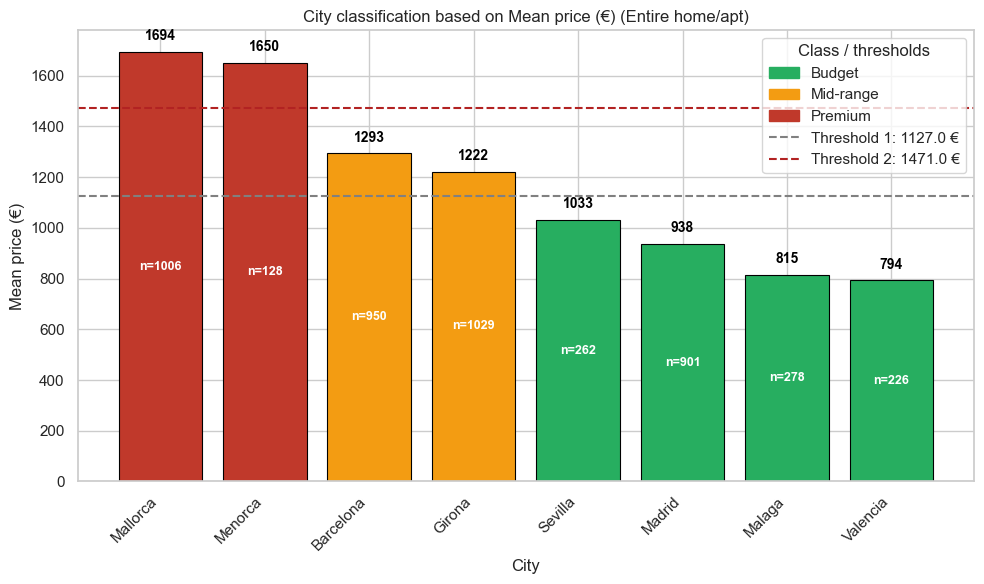


Estimated thresholds for Entire home/apt using 'Mean price (€)':
Budget: 793.60 to 1127.00
Mid-range: 1127.00 to 1471.00
Premium: 1471.00 to 1693.77
Done


In [ ]:
plot_city_price_classification(
    df=price_profles,
    classifyer='Mean price (€)',
    room_type='Entire home/apt',
    stat_details=False
)

##### **Category: Hotel room** 

- Interpretation

In [ ]:
price_profles[price_profles["room_type"] == "Hotel room"][
    [
        "City",
        "Number of accommodations",
        "Mean price (€)",
        "Median price (€)",
        "Price variation, (€)",
    ]
].sort_values("Median price (€)", ascending=False)

,City,Number of accommodations,Mean price (€),Median price (€),"Price variation, (€)"
8,Barcelona,7,1444.29,1500.0,485.0
12,Mallorca,7,1410.00,1460.0,180.0
14,Valencia,2,955.00,955.0,195.0
11,Malaga,3,703.33,720.0,295.0
13,Sevilla,7,918.57,700.0,825.0
10,Madrid,5,857.00,675.0,330.0
9,Girona,4,625.00,615.0,440.0


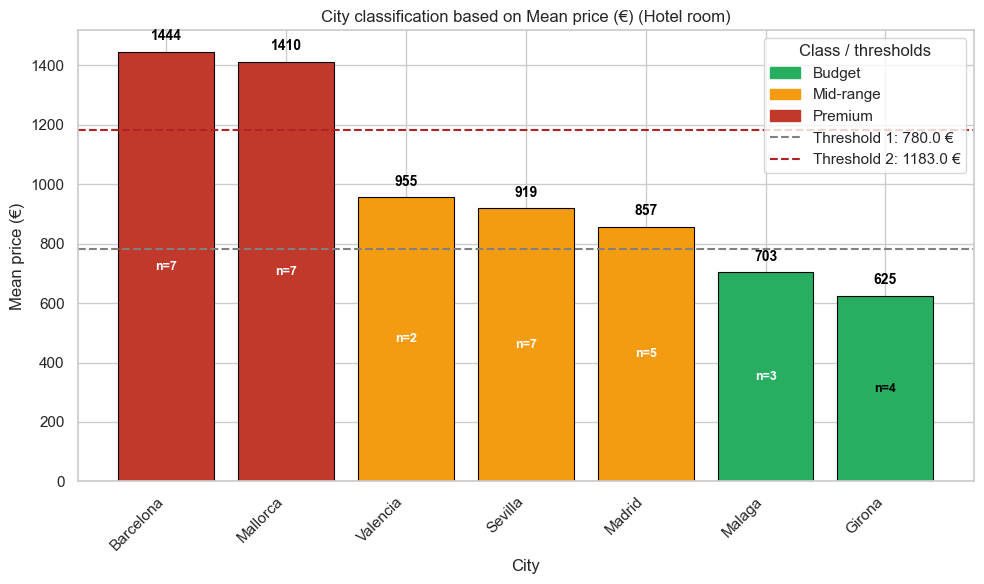


Estimated thresholds for Hotel room using 'Mean price (€)':
Budget: 625.00 to 780.00
Mid-range: 780.00 to 1183.00
Premium: 1183.00 to 1444.29
Done


In [ ]:
plot_city_price_classification(
    df=price_profles,
    classifyer='Mean price (€)',
    room_type='Hotel room',
    stat_details=False
)

##### **Category: Private room** 

Private rooms reveal a strong affordability segment.

Barcelona and Madrid maintain relatively affordable shared accommodation despite premium entire-home pricing, suggesting:

* strong backpacker demand
* digital nomad opportunities
* student and temporary-worker segments

Valencia demonstrates the strongest low-cost competitive positioning.

In [ ]:
price_profles[price_profles["room_type"] == "Private room"][
    [
        "City",
        "Number of accommodations",
        "Mean price (€)",
        "Median price (€)",
        "Price variation, (€)",
    ]
].sort_values("Median price (€)", ascending=False)

,City,Number of accommodations,Mean price (€),Median price (€),"Price variation, (€)"
20,Menorca,10,610.00,550.0,425.0
19,Mallorca,80,697.75,500.0,375.0
16,Girona,52,602.12,450.0,442.5
15,Barcelona,1066,454.53,390.0,230.0
21,Sevilla,71,602.39,350.0,250.0
17,Madrid,475,372.88,300.0,185.0
18,Malaga,55,356.73,300.0,150.0
22,Valencia,66,339.39,250.0,157.5


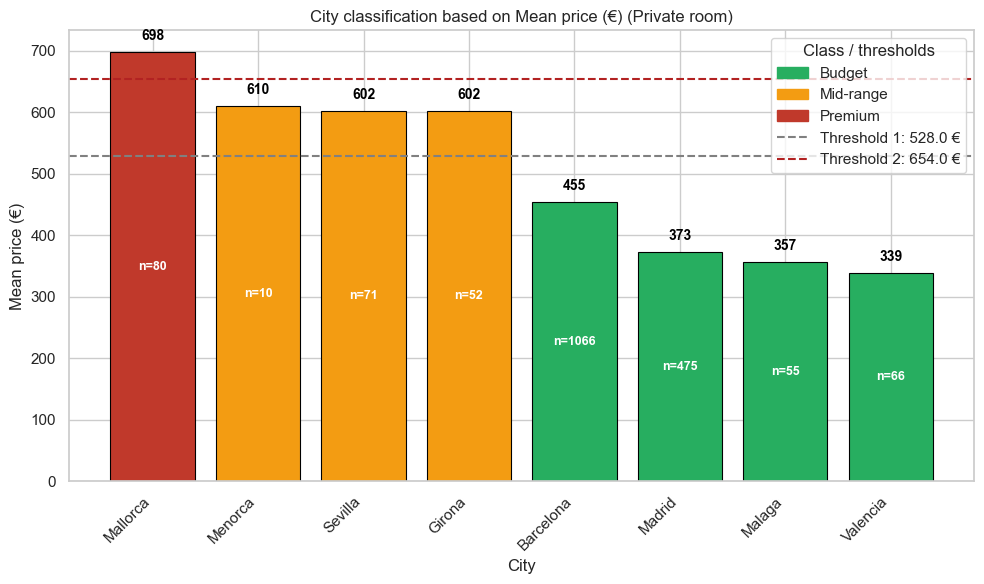


Estimated thresholds for Private room using 'Mean price (€)':
Budget: 339.39 to 528.00
Mid-range: 528.00 to 654.00
Premium: 654.00 to 697.75
Done


In [ ]:
plot_city_price_classification(
    df=price_profles,
    classifyer='Mean price (€)',
    room_type='Private room',
    stat_details=False
)

##### **Category: Shared room** 

This segment primarily targets:

* low-budget travelers
* students
* short-term backpackers
* seasonal workers

Malaga and Sevilla are highly competitive in budget accommodation.

In [ ]:
price_profles[price_profles["room_type"] == "Shared room"][
    [
        "City",
        "Number of accommodations",
        "Mean price (€)",
        "Median price (€)",
        "Price variation, (€)",
    ]
].sort_values("Median price (€)", ascending=False)

,City,Number of accommodations,Mean price (€),Median price (€),"Price variation, (€)"
26,Mallorca,3,493.33,470.0,85.0
23,Barcelona,18,369.44,350.0,240.0
28,Valencia,3,203.33,220.0,55.0
24,Madrid,15,313.33,170.0,250.0
25,Malaga,3,143.33,140.0,5.0
27,Sevilla,1,120.00,120.0,0.0


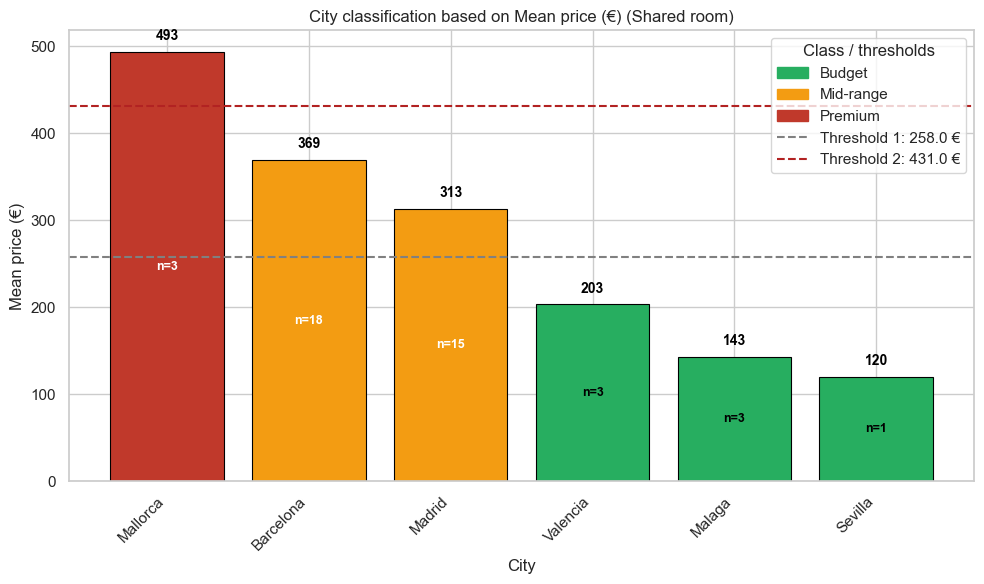


Estimated thresholds for Shared room using 'Mean price (€)':
Budget: 120.00 to 258.00
Mid-range: 258.00 to 431.00
Premium: 431.00 to 493.33
Done


In [ ]:
plot_city_price_classification(
    df=price_profles,
    classifyer='Mean price (€)',
    room_type='Shared room',
    stat_details=False
)

#### Association of the price with accomodation type and city location (heatplot)

### Generalisation

**Accommodation Type is the Strongest Pricing Driver**

Kruskal-Wallis test:
- H = 2684.29
- p < 0.000001

This indicates that accommodation type strongly determines pricing.

The market naturally separates into:

* luxury entire-home segment
* mid-tier private-room segment
* budget shared-room segment

This segmentation should become the foundation of pricing strategy and marketing campaigns.
___
_Mallorca_
- Premium Market
    * highest prices overall
    * largest IQR
    * strong luxury tourism behavior
    * strong willingness-to-pay

- Recommended strategy:
    * premium branding
    * luxury upselling
    * experiential tourism packages
    * high-end dynamic pricing
___
_Barcelona_
- Urban Premium to Mid-range Market
    * premium entire-home prices
    * affordable private rooms
    * wide segmentation spectrum

- Recommended strategy:
    * differentiated marketing funnels
    * neighborhood-specific pricing
    * dynamic occupancy pricing
___
_Madrid_
- Business Tourism Market
    * moderate premium pricing
    * lower luxury positioning than Barcelona
    * strong business-travel profile

- Recommended strategy:
    * weekday/weekend pricing differentiation
    * corporate partnerships
    * long-stay optimization
___
_Valencia & Malaga_
- Emerging Value Markets
    * lowest entire-home prices
    * affordable private rooms
    * strong tourism growth potential

- Recommended strategy:
    * aggressive market penetration
    * occupancy optimization
    * international low-cost tourism targeting

**Correlation analysis — Pricing Drivers**

_Positive correlations_

| Variable | Pearson r | Interpretation |
|----------|:---------:|----------------|
|accommodates|0.65|Larger properties strongly increase price|
|beds|0.57|Capacity strongly impacts revenue|
|bathrooms|0.43|Comfort/luxury factor|
|bedrooms|0.43|Property size matters|
|availability_365|0.16|Higher-priced properties remain available more often|

Strategic Meaning

Property capacity is one of the strongest monetization drivers.

Upselling strategies should emphasize:
* group travel
* family accommodation
* premium large-apartment positioning


_Negative correlations_
| Variable | Correlation |
|----------| :---------: |
|reviews_per_month|-0.20|
|number_of_reviews|-0.16|

Interpretation

Higher-priced listings tend to receive fewer reviews.

Possible explanation:
* luxury accommodations have lower booking frequency
* premium customers travel less frequently
* high-end inventory targets niche travelers

#### Business Opportunities

**Dynamic Pricing Optimization**

Many premium listings show:
- high prices
- high availability

_This suggests pricing inefficiency._

Recommended:
* seasonal dynamic pricing
* occupancy-based repricing
* competitor benchmarking

especially in **Mallorca** and **Barcelona** luxury segment.
___
**Valencia Growth Market**

Accomodations shows:
- relatively low pricing
- growing attractiveness
- strong affordability advantage

Recommended:
* international digital nomad positioning
* remote-work tourism
* medium-term stay products

___
**Premium Experience Bundling**

Luxury destinations:
- Mallorca
- Menorca
- Barcelona

Recommended:
* concierge services
* local experiences
* wellness packages
* transportation bundles

___
**Underpriced Private Room Markets**

Several cities show relatively low private-room pricing compared to entire-home premiums.

Recommended:
* optimize occupancy
* introduce co-living concepts
* target long-stay remote workers

### Limitations

* Price values a strongly biased by 'date' type parameters
* Lack of seasonality analysis
* Geographic distribution induce unequal sample sizes across the market
* Neighbourhood effect is not analysed
* Available price values are not the real transaction prices
* Statistical tools application is limited due to asymetric distribution of most of the numeric parameters
* Snapshot rather than longitudinal data
* No customer information, at least type and travel purpose
* Availability data are imperfect to understand the demand
* Absence of external data for results validation 


### Recommendations

* elaborate accommodation profile for each type in each location, using the following parameters: price, accomodates, bedrooms, bathrooms, beds, availability_90, availability_365, reviews per month, number of reviews, is_instant_bookable;
* seasonality analysis using as proxy first_review_date and insert_date;
* availability analysis based on complete year periods using as proxies first_review_date, availability (30, 60, 90, 365), insert_date;
* perform geographic segmentation and consider distance between the cities, as well as a detailed analysis of their neighbourhood names and districts
* detailed analysis of accomodations by instant booking option availability
* elaborate rating system and classification approach